# BC4 Early Warning System Models

## Notebook Structure

- Imports and setup
- Exploratory Data Analysis
- Part 1. Isolation Forest
- Part 2. COPOD
- Part 3. Deep Learning Models
- Part 4. Ensemble Model
- Part 5. Conclusion and Risk-managed equity curve


## Imports and setup

Shared imports are collected here so the model sections below focus on data preparation, modelling, evaluation, and portfolio diagnostics.


In [1]:
from __future__ import annotations

from pathlib import Path
import random
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from pyod.models.copod import COPOD
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.feature_selection import VarianceThreshold
from sklearn.inspection import permutation_importance
from sklearn.manifold import TSNE
from sklearn.metrics import (
    auc,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import umap
import pacmap

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = [10, 6]

FIGURE_DIR = Path("BC4/figures") if Path("BC4").is_dir() else Path("figures")
FIGURE_FORMATS = ("png", "pdf")


def safe_filename(name: str) -> str:
    slug = re.sub(r"[^a-z0-9]+", "_", str(name).lower()).strip("_")
    return slug or "figure"


def export_figure(fig, filename: str, dpi: int = 300):
    """Save a matplotlib figure as PNG and PDF with a stable notebook-local name."""
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    stem = safe_filename(filename)
    exported_paths = []
    for extension in FIGURE_FORMATS:
        output_path = FIGURE_DIR / f"{stem}.{extension}"
        save_kwargs = {"bbox_inches": "tight"}
        if extension == "png":
            save_kwargs["dpi"] = dpi
        fig.savefig(output_path, **save_kwargs)
        exported_paths.append(output_path)
    return exported_paths


def chronological_split(n_obs, train_ratio=0.60, cv_ratio=0.20):
    """Index slices for a strict past -> validation -> recent test partition.

    Assumes the data is already sorted in chronological order. Fitting only on the
    train slice therefore never sees future data, which removes the look-ahead bias a
    randomly shuffled split would introduce. Returns (train_slice, cv_slice, test_slice).
    """
    train_end = int(train_ratio * n_obs)
    cv_end = int((train_ratio + cv_ratio) * n_obs)
    return slice(0, train_end), slice(train_end, cv_end), slice(cv_end, n_obs)


def apply_execution_lag(signal):
    """Shift a 0/1 (or boolean) risk-off signal forward by one period.

    A flag raised on the close of week t can only change the allocation for week t+1, so
    the backtest never avoids a loss using that same week's already-realised return. The
    first observation starts fully invested (no prior signal yet).
    """
    signal = np.asarray(signal)
    lagged = np.zeros_like(signal)
    lagged[1:] = signal[:-1]
    return lagged


c:\Users\shour\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Exploratory Data Analysis

This section explores the raw Bloomberg market dataset and the stationarity
transformation before any model-specific preparation. It is shared context for all
three modelling approaches in Parts 1-3.

- The label `Y = 1` marks risk-on/risk-off stress windows; plotting it against
  `MXUS` is a quick sanity check that stress labels cluster around market drawdowns
  or volatility regimes.
- Market indices, currencies, commodities, and bond indices are treated as positive
  price/index series and transformed with log differences.
- Interest rates and yields can be near zero or negative, so they are transformed
  with first differences rather than log differences.
- `ECSURPUS` is kept in levels because the source notebook treats it as already
  roughly stationary.
- A compact multivariate check compares normal vs anomalous periods after the
  stationarity transformation; large standardized mean shifts indicate features
  that carry risk-regime information.


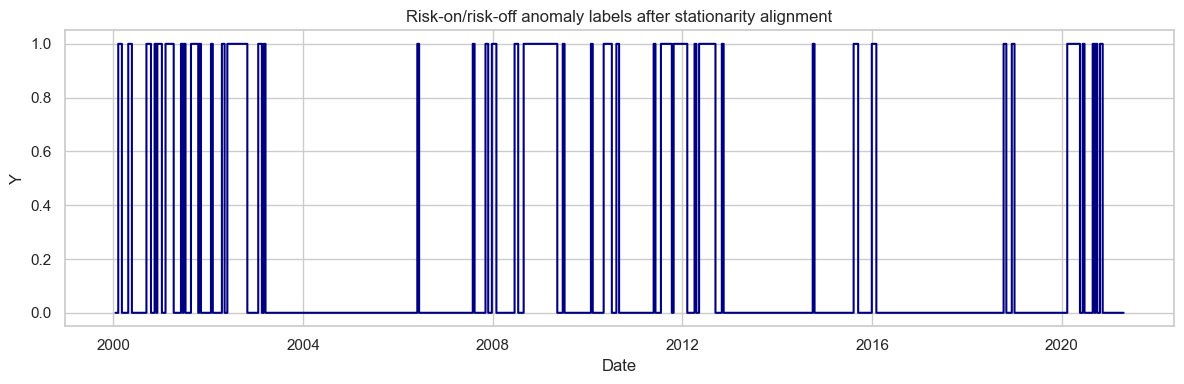

In [2]:
# Load the raw BC4 market dataset and build the stationary feature matrix used for EDA.
dataset_path = Path("Dataset4_EWS.xlsx")

data_df = pd.read_excel(dataset_path, sheet_name="Markets")
metadata_df = pd.read_excel(dataset_path, sheet_name="Metadata")

date_col = "Date" if "Date" in data_df.columns else data_df.columns[0]
y_col = "Y" if "Y" in data_df.columns else None
if y_col is None:
    raise ValueError("Expected an anomaly label column named 'Y' in the Markets sheet.")

data_df[date_col] = pd.to_datetime(data_df[date_col], dayfirst=True)
data_df = data_df.set_index(date_col).sort_index()

X_df = data_df.drop(columns=[y_col])
y_raw = data_df[y_col].astype(int).values

indices_currencies = [col for col in X_df.columns if col in [
    "XAUBGNL", "BDIY", "CRY", "Cl1", "DXY", "EMUSTRUU", "GBP", "JPY", "LF94TRUU",
    "LF98TRUU", "LG30TRUU", "LMBITR", "LP01TREU", "LUACTRUU", "LUMSTRUU",
    "MXBR", "MXCN", "MXEU", "MXIN", "MXJP", "MXRU", "MXUS", "VIX"
]]

interest_rates = [col for col in X_df.columns if col in [
    "EONIA", "GTDEM10Y", "GTDEM2Y", "GTDEM30Y", "GTGBP20Y", "GTGBP2Y", "GTGBP30Y",
    "GTITL10YR", "GTITL2YR", "GTITL30YR", "GTJPY10YR", "GTJPY2YR", "GTJPY30YR",
    "US0001M", "USGG3M", "USGG2YR", "GT10", "USGG30YR"
]]

stationary_df = pd.DataFrame(index=X_df.index[1:])

for col in indices_currencies:
    stationary_df[col] = np.diff(np.log(X_df[col].astype(float)))

for col in interest_rates:
    stationary_df[col] = np.diff(X_df[col].astype(float))

if "ECSURPUS" in X_df.columns:
    stationary_df["ECSURPUS"] = X_df["ECSURPUS"].astype(float).values[1:]

y_stationary = y_raw[1:]
stationary_df = stationary_df.replace([np.inf, -np.inf], np.nan)
valid_mask = stationary_df.notna().all(axis=1)
stationary_df = stationary_df.loc[valid_mask]
y_stationary = y_stationary[valid_mask.to_numpy()].astype(int)

plt.figure(figsize=(12, 4))
plt.plot(stationary_df.index, y_stationary, drawstyle="steps-post", color="navy")
plt.title("Risk-on/risk-off anomaly labels after stationarity alignment")
plt.xlabel("Date")
plt.ylabel("Y")
plt.tight_layout()
export_figure(plt.gcf(), "01_stationary_anomaly_labels")
plt.show()


**Graph interpretation.**  
The opening label timeline verifies that the transformed feature matrix remains aligned with the risk-on/risk-off target after the stationarity step. Abnormal observations appear in visible clusters rather than as uniformly scattered points, which is consistent with market stress occurring as persistent regimes.

This plot supports the overall business framing of the notebook. The task is not simply to classify independent weekly observations; it is to detect transitions into risk-off states early enough to reduce portfolio damage. The chronological structure must therefore be preserved when interpreting the later validation, test, and backtest results.

,item,value
0,raw observations,1111
1,raw variables,42
2,stationary observations,1110
3,stationary variables,42
4,raw anomaly count,237
5,stationary anomaly rate,21.35%
6,sample start,2000-01-11
7,sample end,2021-04-20


Missing data check: no missing values in the raw feature matrix.


,ticker,description,mean,std,min,max
0,BDIY,Baltic Dry Index,2259.860486,2017.811888,291.0000,11793.0000
1,CRY,TR/CC CRB ER Index,245.247649,68.278081,106.2929,467.5700
2,Cl1,Generic 1st 'CL' Future,60.708101,25.900813,10.0100,140.9700
3,DXY,DOLLAR INDEX SPOT,90.934982,11.379095,71.3290,119.8200
4,ECSURPUS,Bloomberg ECO US Surprise Inde,0.036153,0.349453,-0.9740,0.9910
5,EMUSTRUU,EM USD Aggregate,704.379495,309.951768,230.5267,1286.3530
6,EONIA,EMMI EURO OverNight Index Aver,1.363676,1.721894,-0.4980,5.7300
7,GBP,British Pound Spot,1.569618,0.212340,1.1723,2.0852
8,GT10,US TREASURY N/B,3.266748,1.332464,0.5080,6.7480
9,GTDEM10Y,BUNDESREPUB. DEUTSCHLAND,2.448365,1.851558,-0.7940,5.6440


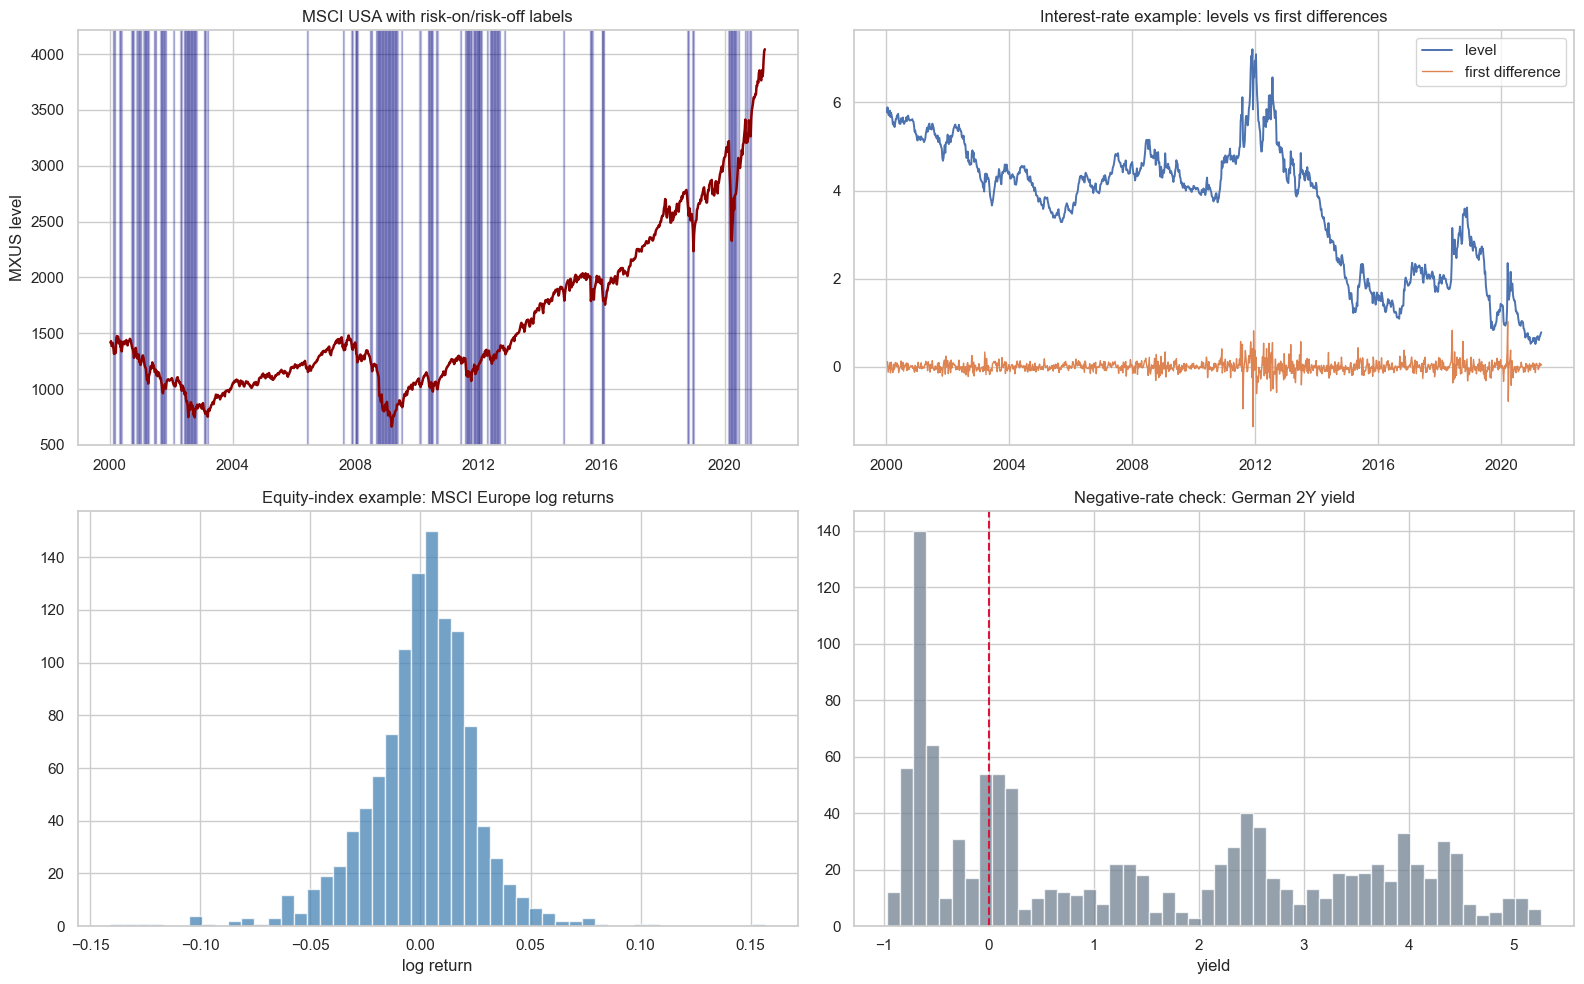

,standardized_mean_shift
MXUS,-0.591327
MXEU,-0.503453
MXJP,-0.481096
MXCN,-0.407085
GT10,-0.376902
VIX,0.317834
GTDEM10Y,-0.291944
Cl1,-0.227272
ECSURPUS,-0.221304
GTJPY10YR,-0.177913


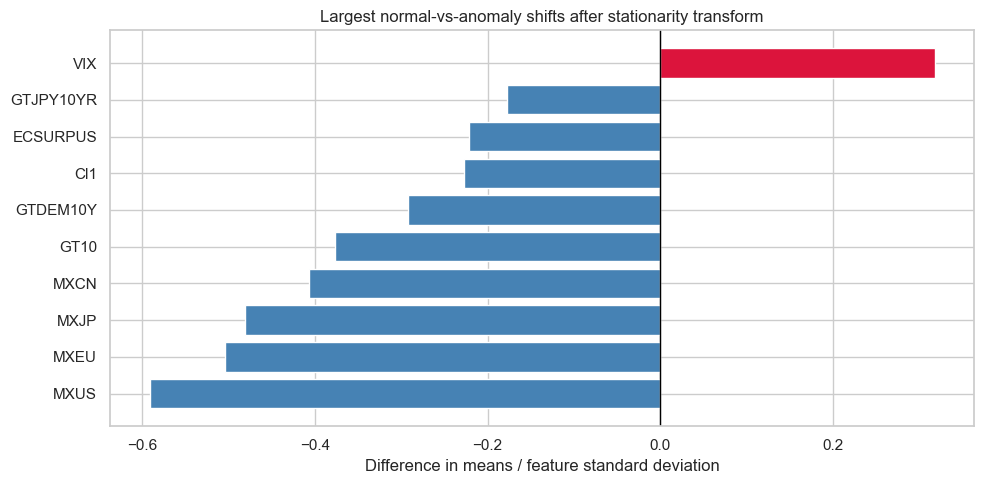

In [3]:
# Compact EDA retained from the original EarlyWarningSystemPoliMI notebook.
eda_summary = pd.DataFrame({
    "item": [
        "raw observations",
        "raw variables",
        "stationary observations",
        "stationary variables",
        "raw anomaly count",
        "stationary anomaly rate",
        "sample start",
        "sample end",
    ],
    "value": [
        len(X_df),
        X_df.shape[1],
        stationary_df.shape[0],
        stationary_df.shape[1],
        int(np.sum(y_raw == 1)),
        f"{np.mean(y_stationary == 1) * 100:.2f}%",
        X_df.index.min().strftime("%Y-%m-%d"),
        X_df.index.max().strftime("%Y-%m-%d"),
    ],
})
display(eda_summary)

missing_pct = X_df.isna().mean().mul(100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
if missing_pct.empty:
    print("Missing data check: no missing values in the raw feature matrix.")
else:
    display(missing_pct.head(10).rename("missing_pct").to_frame())

# Metadata + raw descriptive statistics, kept compact for scanability.
ticker_col = "ticker" if "ticker" in metadata_df.columns else metadata_df.columns[0]
desc_col = (
    "description"
    if "description" in metadata_df.columns
    else metadata_df.columns[1]
    if len(metadata_df.columns) > 1
    else ticker_col
)
metadata_lookup = metadata_df.set_index(ticker_col)[desc_col].to_dict()
eda_feature_snapshot = pd.DataFrame({
    "ticker": X_df.columns,
    "description": [metadata_lookup.get(col, col) for col in X_df.columns],
    "mean": X_df.mean(numeric_only=True).reindex(X_df.columns).to_numpy(),
    "std": X_df.std(numeric_only=True).reindex(X_df.columns).to_numpy(),
    "min": X_df.min(numeric_only=True).reindex(X_df.columns).to_numpy(),
    "max": X_df.max(numeric_only=True).reindex(X_df.columns).to_numpy(),
})
display(eda_feature_snapshot.head(12))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

if "MXUS" in X_df.columns:
    axes[0].plot(X_df.index, X_df["MXUS"], color="darkred", linewidth=1.8)
    anomaly_dates = X_df.index[y_raw == 1]
    for date in anomaly_dates:
        axes[0].axvspan(date, date + pd.Timedelta(days=7), color="navy", alpha=0.16)
    axes[0].set_title("MSCI USA with risk-on/risk-off labels")
    axes[0].set_ylabel("MXUS level")
else:
    axes[0].text(0.5, 0.5, "MXUS unavailable", ha="center", va="center")
    axes[0].set_axis_off()

if "GTITL10YR" in X_df.columns:
    axes[1].plot(X_df.index, X_df["GTITL10YR"], label="level", linewidth=1.4)
    axes[1].plot(X_df.index[1:], np.diff(X_df["GTITL10YR"].astype(float)), label="first difference", linewidth=1.0)
    axes[1].set_title("Interest-rate example: levels vs first differences")
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, "GTITL10YR unavailable", ha="center", va="center")
    axes[1].set_axis_off()

if "MXEU" in X_df.columns:
    mxeu_log_returns = np.diff(np.log(X_df["MXEU"].astype(float)))
    axes[2].hist(mxeu_log_returns, bins=50, alpha=0.75, color="steelblue")
    axes[2].set_title("Equity-index example: MSCI Europe log returns")
    axes[2].set_xlabel("log return")
else:
    axes[2].text(0.5, 0.5, "MXEU unavailable", ha="center", va="center")
    axes[2].set_axis_off()

if "GTDEM2Y" in X_df.columns:
    axes[3].hist(X_df["GTDEM2Y"], bins=50, alpha=0.75, color="slategray")
    axes[3].axvline(0, color="crimson", linestyle="--", linewidth=1.5)
    axes[3].set_title("Negative-rate check: German 2Y yield")
    axes[3].set_xlabel("yield")
else:
    axes[3].text(0.5, 0.5, "GTDEM2Y unavailable", ha="center", va="center")
    axes[3].set_axis_off()

plt.tight_layout()
export_figure(fig, "02_compact_eda_panels")
plt.show()

selected_eda_features = [
    col for col in [
        "GT10", "GTDEM10Y", "GTITL10YR", "GTJPY10YR", "DXY", "XAUBGNL",
        "Cl1", "MXUS", "MXEU", "MXJP", "MXCN", "VIX", "ECSURPUS",
    ]
    if col in stationary_df.columns
]

if len(selected_eda_features) > 0 and np.any(y_stationary == 1) and np.any(y_stationary == 0):
    normal_means = stationary_df.loc[y_stationary == 0, selected_eda_features].mean()
    anomaly_means = stationary_df.loc[y_stationary == 1, selected_eda_features].mean()
    pooled_std = stationary_df[selected_eda_features].std().replace(0, np.nan)
    standardized_shift = ((anomaly_means - normal_means) / pooled_std).dropna()
    shift_df = (
        standardized_shift.rename("standardized_mean_shift")
        .to_frame()
        .assign(abs_shift=lambda df: df["standardized_mean_shift"].abs())
        .sort_values("abs_shift", ascending=False)
        .drop(columns="abs_shift")
    )
    display(shift_df.head(10))

    plt.figure(figsize=(10, 5))
    plot_shift = shift_df.head(10).sort_values("standardized_mean_shift")
    colors = np.where(plot_shift["standardized_mean_shift"] >= 0, "crimson", "steelblue")
    plt.barh(plot_shift.index, plot_shift["standardized_mean_shift"], color=colors)
    plt.axvline(0, color="black", linewidth=1)
    plt.title("Largest normal-vs-anomaly shifts after stationarity transform")
    plt.xlabel("Difference in means / feature standard deviation")
    plt.tight_layout()
    export_figure(plt.gcf(), "03_eda_largest_feature_shifts")
    plt.show()
else:
    print("Skipping multivariate EDA shift plot: selected features or both classes are unavailable.")


**Graph interpretation.**  
The EDA figure contains four checks. The MSCI USA panel shows a strongly trending equity level with risk-off labels overlaid, which confirms that raw market levels should not be used directly as stationary model inputs. The interest-rate panel compares a yield level with its first difference, showing why rates are differenced while price-like variables are transformed through log changes.

The equity-return distribution is centered but visibly heavy-tailed, which is typical of financial returns and supports anomaly detection. The German 2Y yield histogram confirms that negative rates exist in the dataset, so log transforms would be inappropriate for rate variables. The separate standardized mean-shift chart then gives the economic story: abnormal regimes have lower equity-index features such as MXUS, MXEU, MXJP, and MXCN, while VIX shifts upward. This is a coherent risk-off pattern and validates the direction of the signal before modelling.

## Part 1. Isolation Forest


### Goal

The first part of the notebook uses **Isolation Forest**, a widely used anomaly detection algorithm based on the idea that abnormal observations are easier to isolate than normal ones. By recursively partitioning the feature space, the algorithm assigns an anomaly score to each observation: market periods that are isolated in fewer splits are considered more unusual and may correspond to financial stress episodes.

In a second step, the notebook extends this approach with an **Isolation Mondrian Forest**. Mondrian forests are based on random recursive partitions that can adapt efficiently and naturally handle sequential data. This makes them particularly relevant for financial time series, where new observations arrive over time and market conditions evolve continuously. Compared with a standard Isolation Forest, the Mondrian-based approach is better suited to an online or dynamic setting, allowing the model to adapt more flexibly to changing market regimes while preserving the core intuition of anomaly detection through isolation.

### 1. Loading and exploration of Bloomberg data

The Bloomberg dataset contains weekly data on:

- Equity indices (MSCI USA, Europe, Japan, EM...)
- Bond indices (IG, HY, Inflation-linked, MBS...)
- Interest rates (US, Germany, UK, Japan, Italy)
- Currencies (USD, GBP, JPY)
- Commodities (oil, gold, CRB)
- Leading indicators (VIX, Baltic Dry Index, Economic Surprise)

A `label` column indicates **abnormal** weeks (risk-off = 1) vs. **normal** weeks (risk-on = 0).


In [4]:
DATA_PATH = Path("Dataset4_EWS.xlsx")
if not DATA_PATH.exists() and Path("BC4/Dataset4_EWS.xlsx").exists():
    DATA_PATH = Path("BC4/Dataset4_EWS.xlsx")

data_df = pd.read_excel(DATA_PATH, sheet_name="Markets")
metadata_df = pd.read_excel(DATA_PATH, sheet_name="Metadata")

date_col = "Date" if "Date" in data_df.columns else data_df.columns[0]
LABEL_COL = "Y" if "Y" in data_df.columns else None
if LABEL_COL is None:
    raise ValueError("Expected an anomaly label column named 'Y' in the Markets sheet.")

data_df[date_col] = pd.to_datetime(data_df[date_col], dayfirst=True)
df_raw = data_df.set_index(date_col).sort_index()
df_raw[LABEL_COL] = df_raw[LABEL_COL].astype(int)
df_raw.index.name = "Date"

print(f"Dataset path: {DATA_PATH}")
print(f"Shape : {df_raw.shape}")
print(f"Period from : {df_raw.index.min().date()} to {df_raw.index.max().date()}")
print(f"Metadata rows: {len(metadata_df)}")
print(f"\nColumns ({len(df_raw.columns)}) :")
df_raw.head(10)


Dataset path: Dataset4_EWS.xlsx
Shape : (1111, 43)
Period from : 2000-01-11 to 2021-04-20
Metadata rows: 59

Columns (43) :


,BDIY,CRY,Cl1,DXY,ECSURPUS,EMUSTRUU,EONIA,GBP,GT10,GTDEM10Y,...,MXJP,MXRU,MXUS,US0001M,USGG2YR,USGG30YR,USGG3M,VIX,XAUBGNL,Y
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-11,1388,157.26,25.77,100.56,0.077,230.5267,2.89,1.6460,6.657,5.541,...,990.59,224.33,1416.12,5.78125,6.428,6.671,5.426,22.50,283.25,0
2000-01-18,1405,165.01,28.85,101.86,0.043,231.3770,3.03,1.6383,6.748,5.644,...,993.98,234.37,1428.79,5.80250,6.465,6.747,5.378,21.50,287.65,0
2000-01-25,1368,167.24,28.28,102.41,0.135,232.3895,3.15,1.6496,6.692,5.515,...,974.83,216.82,1385.93,5.81875,6.432,6.634,5.562,23.02,287.15,0
2000-02-01,1311,166.85,28.22,104.92,0.191,231.9417,3.30,1.6106,6.619,5.459,...,1007.12,201.89,1385.31,5.88500,6.574,6.423,5.708,23.45,282.75,0
2000-02-08,1277,165.43,28.02,104.22,0.312,237.8117,3.26,1.6108,6.613,5.482,...,1034.58,218.00,1411.95,5.89125,6.678,6.231,5.677,21.25,298.40,1
2000-02-15,1393,169.58,30.06,104.69,0.391,240.1163,3.25,1.5966,6.552,5.562,...,1007.86,204.59,1369.47,5.88000,6.628,6.246,5.740,22.92,303.90,1
2000-02-22,1481,168.86,29.62,103.28,0.497,240.1438,3.20,1.6166,6.361,5.415,...,987.38,206.14,1315.93,5.88000,6.551,6.086,5.764,25.86,305.50,1
2000-02-29,1531,170.20,30.43,105.92,0.497,243.1049,3.34,1.5802,6.409,5.500,...,1014.69,199.23,1333.28,5.91250,6.521,6.140,5.781,23.37,293.30,1
2000-03-07,1602,179.94,34.13,106.01,0.484,246.5223,3.28,1.5756,6.373,5.432,...,994.72,234.18,1319.95,5.95000,6.486,6.145,5.834,24.31,292.00,0


In [5]:
# Overall statistics
df_raw.describe().T.round(3)


,count,mean,std,min,25%,50%,75%,max
BDIY,1111.0,2259.860,2017.812,291.000,990.000,1518.000,2685.500,11793.000
CRY,1111.0,245.248,68.278,106.293,184.706,234.560,301.539,467.570
Cl1,1111.0,60.708,25.901,10.010,39.625,57.400,79.640,140.970
DXY,1111.0,90.935,11.379,71.329,81.240,89.716,97.404,119.820
ECSURPUS,1111.0,0.036,0.349,-0.974,-0.191,0.035,0.260,0.991
EMUSTRUU,1111.0,704.379,309.952,230.527,434.661,714.807,939.825,1286.353
EONIA,1111.0,1.364,1.722,-0.498,-0.230,0.437,2.890,5.730
GBP,1111.0,1.570,0.212,1.172,1.418,1.562,1.677,2.085
GT10,1111.0,3.267,1.332,0.508,2.196,3.115,4.345,6.748
GTDEM10Y,1111.0,2.448,1.852,-0.794,0.539,2.994,4.080,5.644


#### Checking for missing values:


In [6]:
missing = df_raw.isnull().sum()
print("Missing values per column :")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values")

Missing values per column :
No missing values


#### Analysis of dependent variables: 

distribution of dependent variables :
Y
0    874
1    237
Name: count, dtype: int64

Anomaly rate : 21.33%


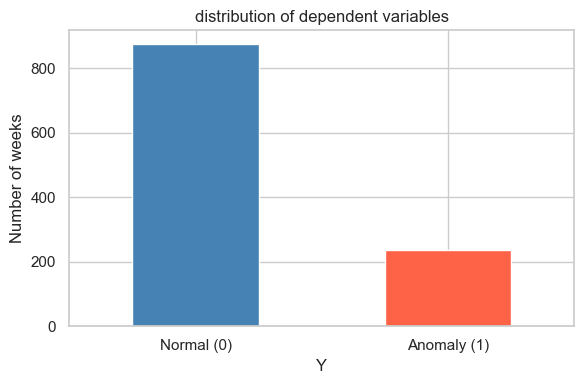

In [7]:
LABEL_COL = "Y"

label_counts = df_raw[LABEL_COL].value_counts().sort_index()
print("distribution of dependent variables :")
print(label_counts)
print(f"\nAnomaly rate : {label_counts.get(1, 0) / len(df_raw):.2%}")

fig, ax = plt.subplots(figsize=(6, 4))
label_counts.plot(kind="bar", ax=ax, color=["steelblue", "tomato"], edgecolor="white")
ax.set_xticklabels(["Normal (0)", "Anomaly (1)"], rotation=0)
ax.set_title("distribution of dependent variables")
ax.set_ylabel("Number of weeks")
plt.tight_layout()
plt.show()

**Graph interpretation.**  
The target-distribution chart shows 874 normal observations and 237 abnormal observations, giving an anomaly rate of 21.33%. The abnormal class is a minority, so a naive model could look acceptable on accuracy while still missing many crisis weeks.

For this reason, later evaluation must emphasize recall, false-negative rate, F2, and precision-recall curves. In the business setting, an undetected abnormal regime can lead to portfolio drawdowns, while a false alarm mainly causes opportunity cost from moving defensively too early.

#### Temporal visualization of the label:


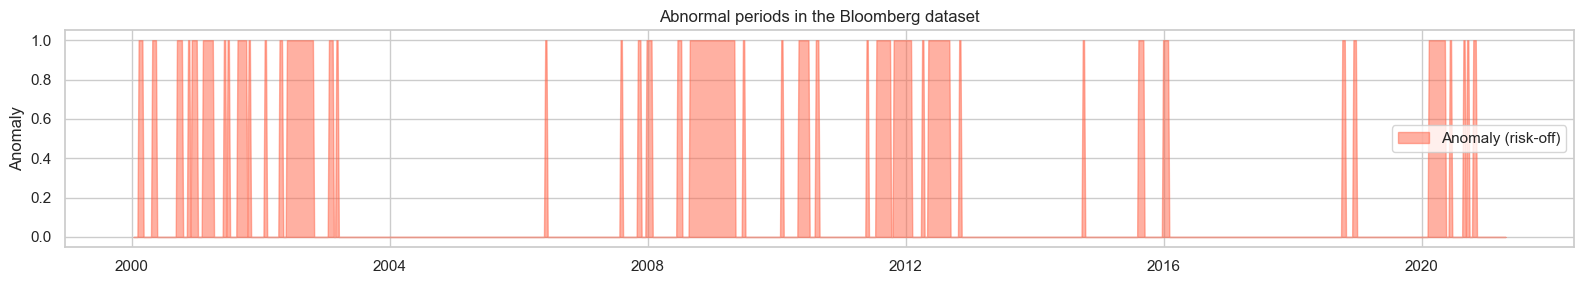

In [8]:
fig, ax = plt.subplots(figsize=(16, 3))
ax.fill_between(
    df_raw.index,
    df_raw[LABEL_COL],
    alpha=0.5,
    color="tomato",
    label="Anomaly (risk-off)"
)
ax.set_title("Abnormal periods in the Bloomberg dataset")
ax.set_ylabel("Anomaly")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend()
plt.tight_layout()
plt.show()

**Graph interpretation.**  
The abnormal-period timeline shows that the label is clustered in distinct historical stress episodes. This matters because the Early Warning System should identify risk-off regimes as market states, not merely classify isolated weeks.

The plot also provides a qualitative benchmark for temporal diagnostics later in the notebook. A useful detector should fire near these stress clusters and should avoid producing many alerts during long normal-market stretches.

### 2. Feature Engineering

Raw price series are generally non-stationary, which makes them less suitable for machine learning models. To obtain more stable and stationary features, we compute **weekly log-returns** for price-based assets:

$$r_t = \log\left(\frac{P_t}{P_{t-1}}\right)$$

For interest rates and spreads, log-returns are not appropriate because these variables are already expressed in levels or percentage points. Therefore, we use **simple differences**:

$$\Delta X_t = X_t - X_{t-1}$$

Finally, some indicators such as the Economic Surprise Index can be kept in levels, depending on their interpretation, since they already reflect changes in macroeconomic conditions.


In [9]:
feature_cols = [col for col in df_raw.columns if col != LABEL_COL]

RATE_COLS = [
    'EONIA', 'GTDEM10Y', 'GTDEM2Y', 'GTDEM30Y', 'GTGBP20Y', 'GTGBP2Y', 'GTGBP30Y',
    'GTITL10YR', 'GTITL2YR', 'GTITL30YR', 'GTJPY10YR', 'GTJPY2YR', 'GTJPY30YR',
    'US0001M', 'USGG3M', 'USGG2YR', 'GT10', 'USGG30YR'
]

LEVEL_COLS = ["ECSURPUS"]

PRICE_COLS = [
    'XAUBGNL', 'BDIY', 'CRY', 'Cl1', 'DXY', 'EMUSTRUU', 'GBP', 'JPY', 'LF94TRUU',
    'LF98TRUU', 'LG30TRUU', 'LMBITR', 'LP01TREU', 'LUACTRUU', 'LUMSTRUU',
    'MXBR', 'MXCN', 'MXEU', 'MXIN', 'MXJP', 'MXRU', 'MXUS', 'VIX'
]

print(f"Log-return columns  ({len(PRICE_COLS)}) :  {PRICE_COLS}")
print("\n")
print(f"Simple difference columns ({len(RATE_COLS)})  :  {RATE_COLS}")
print("\n")
print(f"Columns not modified ({len(LEVEL_COLS)})  :  {LEVEL_COLS}")


Log-return columns  (23) :  ['XAUBGNL', 'BDIY', 'CRY', 'Cl1', 'DXY', 'EMUSTRUU', 'GBP', 'JPY', 'LF94TRUU', 'LF98TRUU', 'LG30TRUU', 'LMBITR', 'LP01TREU', 'LUACTRUU', 'LUMSTRUU', 'MXBR', 'MXCN', 'MXEU', 'MXIN', 'MXJP', 'MXRU', 'MXUS', 'VIX']


Simple difference columns (18)  :  ['EONIA', 'GTDEM10Y', 'GTDEM2Y', 'GTDEM30Y', 'GTGBP20Y', 'GTGBP2Y', 'GTGBP30Y', 'GTITL10YR', 'GTITL2YR', 'GTITL30YR', 'GTJPY10YR', 'GTJPY2YR', 'GTJPY30YR', 'US0001M', 'USGG3M', 'USGG2YR', 'GT10', 'USGG30YR']


Columns not modified (1)  :  ['ECSURPUS']


In [10]:
returns_prices = pd.DataFrame(index=df_raw.index[1:])
for col in PRICE_COLS:
    returns_prices[col] = np.diff(np.log(df_raw[col].astype(float)))

returns_rates = pd.DataFrame(index=df_raw.index[1:])
for col in RATE_COLS:
    returns_rates[col] = np.diff(df_raw[col].astype(float))

returns_levels = pd.DataFrame(index=df_raw.index[1:])
for col in LEVEL_COLS:
    returns_levels[col] = df_raw[col].astype(float).values[1:]

returns_df_base = pd.concat(
    [
        returns_prices,
        returns_rates,
        returns_levels,
    ],
    axis=1,
)

returns_df_base = returns_df_base.replace([np.inf, -np.inf], np.nan)
returns_df_global = returns_df_base.copy()
stationary_df = returns_df_base.copy()
y_stationary = df_raw[LABEL_COL].reindex(stationary_df.index).astype(int).to_numpy()

print(f"Stationary base feature matrix: {stationary_df.shape[0]} observations x {stationary_df.shape[1]} features")
print(f"Aligned anomaly labels: {int(y_stationary.sum())} anomalies ({y_stationary.mean() * 100:.2f}%)")
returns_df_base.head()


Stationary base feature matrix: 1110 observations x 42 features
Aligned anomaly labels: 237 anomalies (21.35%)


,XAUBGNL,BDIY,CRY,Cl1,DXY,EMUSTRUU,GBP,JPY,LF94TRUU,LF98TRUU,...,GTITL30YR,GTJPY10YR,GTJPY2YR,GTJPY30YR,US0001M,USGG3M,USGG2YR,GT10,USGG30YR,ECSURPUS
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-18,0.015415,0.012173,0.048106,0.112899,0.012845,0.003682,-0.004689,-0.003691,0.00000,-0.000660,...,0.138,0.056,0.003,-0.004,0.02125,-0.048,0.037,0.091,0.076,0.043
2000-01-25,-0.001740,-0.026687,0.013424,-0.019955,0.005385,0.004366,0.006874,0.005390,0.00000,0.001867,...,-0.178,-0.140,-0.056,-0.159,0.01625,0.184,-0.033,-0.056,-0.113,0.135
2000-02-01,-0.015442,-0.042560,-0.002335,-0.002124,0.024214,-0.001929,-0.023926,0.016925,-0.01165,0.001243,...,-0.093,0.145,0.071,0.071,0.06625,0.146,0.142,-0.073,-0.211,0.191
2000-02-08,0.053872,-0.026277,-0.008547,-0.007112,-0.006694,0.024993,0.000124,0.013355,0.00000,0.001588,...,-0.070,0.149,-0.005,0.151,0.00625,-0.031,0.104,-0.006,-0.192,0.312
2000-02-15,0.018264,0.086946,0.024777,0.070277,0.004500,0.009644,-0.008855,-0.005229,0.00000,-0.000146,...,0.053,-0.118,-0.026,-0.172,-0.01125,0.063,-0.050,-0.061,0.015,0.391


#### Distribution of yields for some key features :


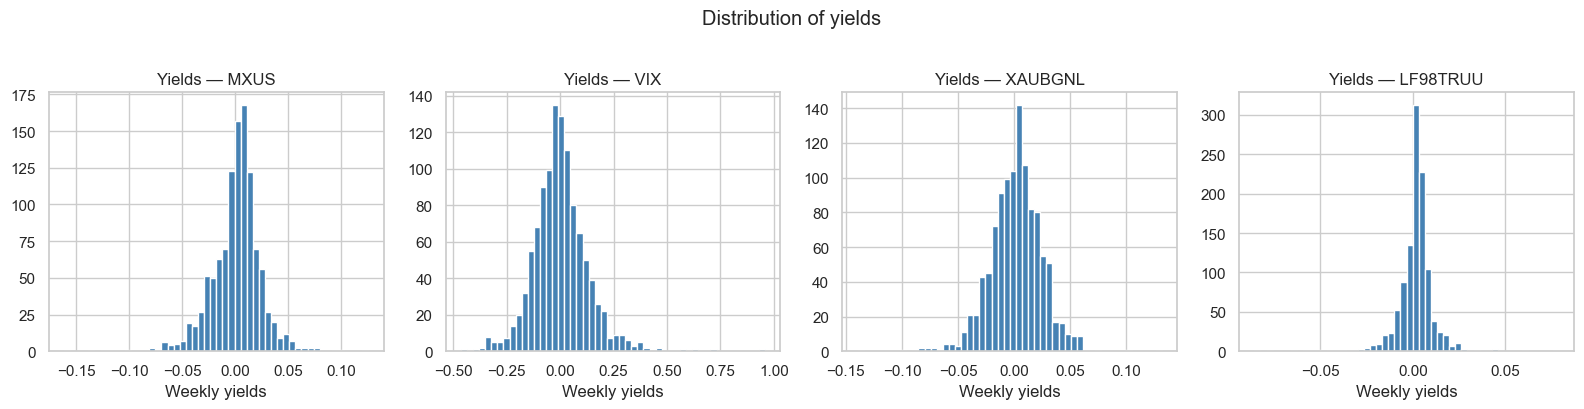

In [11]:
KEY_FEATURES = ["MXUS", "VIX", "XAUBGNL", "LF98TRUU"]
key_features_available = [f for f in KEY_FEATURES if f in returns_df_base.columns]

if key_features_available:
    fig, axes = plt.subplots(1, len(key_features_available), figsize=(16, 4))
    for ax, col in zip(axes, key_features_available):
        returns_df_base[col].hist(bins=50, ax=ax, color="steelblue", edgecolor="white")
        ax.set_title(f"Yields — {col}")
        ax.set_xlabel("Weekly yields")
    plt.suptitle("Distribution of yields", y=1.02)
    plt.tight_layout()
    plt.show()


**Graph interpretation.**  
The four feature-distribution panels show that representative market variables have different dispersion, skewness, and tail behaviour. MXUS, VIX, gold, and credit-related variables do not follow identical distributions, which means the model must rely on standardized inputs and robust anomaly scores rather than raw magnitudes.

The presence of heavy tails is economically important. Crisis weeks are often characterized by large volatility jumps, equity moves, safe-haven flows, or credit stress. These plots therefore support the use of methods such as Isolation Forest, COPOD, and reconstruction-based deep learning models.

In this step, we enrich the dataset by creating additional financial indicators from the transformed series. The goal is to give the model more information about market dynamics than simple returns alone.

For price-based assets, we compute rolling volatility, momentum, and drawdown over different time windows. These features help capture changes in risk, trend direction, and cumulative losses. For interest rates and macro-level variables, we add lagged differences and rolling volatility to measure recent changes in their levels.

We also include VIX-specific features, since the VIX is a key indicator of market stress, and rolling correlations with the US equity index to capture changes in market co-movements.

Overall, these engineered features are designed to help the Early Warning System better identify abnormal market regimes and potential crisis periods.


In [12]:
engineered_blocks = []

# Volatility, momentum and drawdown for price series
for col in PRICE_COLS:
    if col in df_raw.columns:
        ret = returns_prices[col]

        block = pd.DataFrame({
            f"{col}_vol_4w": ret.rolling(4).std(),
            f"{col}_vol_12w": ret.rolling(12).std(),
            f"{col}_vol_26w": ret.rolling(26).std(),

            f"{col}_mom_4w": ret.rolling(4).sum(),
            f"{col}_mom_12w": ret.rolling(12).sum(),
            f"{col}_mom_26w": ret.rolling(26).sum(),

            f"{col}_drawdown_26w": df_raw[col] / df_raw[col].rolling(26).max() - 1,
            f"{col}_drawdown_52w": df_raw[col] / df_raw[col].rolling(52).max() - 1,
        }, index=df_raw.index)

        engineered_blocks.append(block)

# Additional rate features
for col in RATE_COLS:
    if col in df_raw.columns:
        block = pd.DataFrame({
            f"{col}_diff_4w": df_raw[col].diff(4),
            f"{col}_diff_12w": df_raw[col].diff(12),
        }, index=df_raw.index)

        engineered_blocks.append(block)

# Additional level features
for col in LEVEL_COLS:
    if col in df_raw.columns:
        block = pd.DataFrame({
            f"{col}_level_diff_1w": df_raw[col].diff(),
            f"{col}_level_diff_4w": df_raw[col].diff(4),
            f"{col}_level_diff_12w": df_raw[col].diff(12),
            f"{col}_level_vol_4w": df_raw[col].rolling(4).std(),
            f"{col}_level_vol_12w": df_raw[col].rolling(12).std(),
        }, index=df_raw.index)

        engineered_blocks.append(block)

# VIX-specific features
if "VIX" in df_raw.columns:
    vix_block = pd.DataFrame({
        "VIX_change_4w": df_raw["VIX"].diff(4),
        "VIX_change_12w": df_raw["VIX"].diff(12),
        "VIX_vol_4w": df_raw["VIX"].rolling(4).std(),
        "VIX_vol_12w": df_raw["VIX"].rolling(12).std(),
    }, index=df_raw.index)

    engineered_blocks.append(vix_block)

# Rolling correlations with MXUS
REFERENCE_INDEX = "MXUS"

if REFERENCE_INDEX in PRICE_COLS and REFERENCE_INDEX in df_raw.columns:
    ref_ret = returns_prices[REFERENCE_INDEX]

    corr_blocks = []

    for col in PRICE_COLS:
        if col in df_raw.columns and col != REFERENCE_INDEX:
            asset_ret = returns_prices[col]

            corr_block = pd.DataFrame({
                f"{col}_corr_{REFERENCE_INDEX}_12w": asset_ret.rolling(12).corr(ref_ret),
                f"{col}_corr_{REFERENCE_INDEX}_26w": asset_ret.rolling(26).corr(ref_ret),
            }, index=df_raw.index)

            corr_blocks.append(corr_block)

    if len(corr_blocks) > 0:
        engineered_blocks.extend(corr_blocks)


if len(engineered_blocks) > 0:
    engineered_features = pd.concat(engineered_blocks, axis=1)
else:
    engineered_features = pd.DataFrame(index=df_raw.index)

returns_df = pd.concat(
    [
        returns_df_global,
        engineered_features
    ],
    axis=1
)

returns_df[LABEL_COL] = df_raw[LABEL_COL]

returns_df = returns_df.replace([np.inf, -np.inf], np.nan)
returns_df = returns_df.dropna().copy()

feature_cols = [col for col in returns_df.columns if col != LABEL_COL]

n_inf = np.isinf(returns_df[feature_cols].to_numpy()).sum()
n_nan = np.isnan(returns_df[feature_cols].to_numpy()).sum()

print("returns_df shape:", returns_df.shape)
print("Number of features:", len(feature_cols))
print(f"Valeurs inf : {n_inf}")
print(f"Valeurs NaN : {n_nan}")

print("\nFirst 20 features:")
print(feature_cols[:20])


returns_df shape: (1060, 316)
Number of features: 315
Valeurs inf : 0
Valeurs NaN : 0

First 20 features:
['XAUBGNL', 'BDIY', 'CRY', 'Cl1', 'DXY', 'EMUSTRUU', 'GBP', 'JPY', 'LF94TRUU', 'LF98TRUU', 'LG30TRUU', 'LMBITR', 'LP01TREU', 'LUACTRUU', 'LUMSTRUU', 'MXBR', 'MXCN', 'MXEU', 'MXIN', 'MXJP']


C:\Users\shour\AppData\Local\Temp\ipykernel_14068\2080448020.py:85: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  returns_df = pd.concat(


### 3. Train / Validation / Test Split

We use a **strict chronological split** (no shuffling) to avoid look-ahead bias: the
time-ordered series is sliced into past -> validation -> recent test.

- **Train**: earliest 60% of the timeline, normal observations only
- **Validation**: the next 20% of the timeline (all labels)
- **Test**: the most recent 20% of the timeline (all labels)

We use Isolation Forest in a semi-supervised novelty detection setting: the model is
fitted only on past normal observations, so feature selection, scaling, and the model
itself never see future data. This is more faithful to live deployment, where at any
date only past history is available.


Strict chronological split applied to Isolation Forest:
Normal observations: 842; anomalies: 218
Train window  : 2001-01-02 -> 2013-03-05 (459 normal obs)
Validation    : 2013-03-12 -> 2017-03-28 (212 obs, 12 anomalies)
Test          : 2017-04-04 -> 2021-04-20 (212 obs, 29 anomalies)
Test anomaly rate  : 13.68%


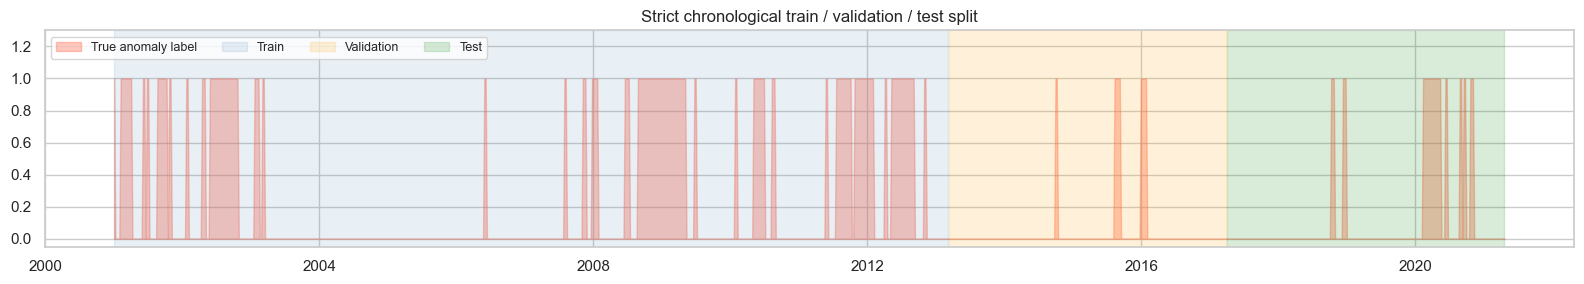

In [13]:
# Strict chronological split (no shuffling): the index is time-ordered, so we slice the
# timeline into past -> validation -> recent test. Feature selection, the scaler, and the
# model are fit on PAST normal observations only, so no future data leaks into training.
TRAIN_RATIO = 0.60
CV_RATIO = 0.20  # test = remaining 0.20

# Drop the label column directly instead of selecting by feature_cols because
# engineered features can contain duplicate names, and list-based selection
# expands duplicate columns in pandas.
feature_matrix = returns_df.drop(columns=[LABEL_COL])
feature_cols = feature_matrix.columns.to_list()
label_series = returns_df[LABEL_COL].astype(int)

train_slice, cv_slice, test_slice = chronological_split(len(feature_matrix), TRAIN_RATIO, CV_RATIO)

train_block = feature_matrix.iloc[train_slice]
train_block_labels = label_series.iloc[train_slice]
# Semi-supervised novelty detection: fit only on PAST normal observations.
X_train_full = train_block[train_block_labels == 0].copy()
y_train_full = pd.Series(np.zeros(len(X_train_full), dtype=int), index=X_train_full.index, name=LABEL_COL)
X_train_normal = X_train_full.copy()

X_val = feature_matrix.iloc[cv_slice].copy()
y_val = label_series.iloc[cv_slice].rename(LABEL_COL)

X_test = feature_matrix.iloc[test_slice].copy()
y_test = label_series.iloc[test_slice].rename(LABEL_COL)

n_normal = int((label_series == 0).sum())
n_anomaly = int((label_series == 1).sum())
if int((y_val == 1).sum()) < 1 or int((y_test == 1).sum()) < 1:
    raise ValueError("Chronological split left a validation/test block with no anomalies; adjust the ratios.")

# Backward-compatible frames used by the original visualisation cells.
df_train_full = X_train_full.copy()
df_train_full[LABEL_COL] = y_train_full
df_val = X_val.copy()
df_val[LABEL_COL] = y_val
df_test = X_test.copy()
df_test[LABEL_COL] = y_test

print("Strict chronological split applied to Isolation Forest:")
print(f"Normal observations: {n_normal}; anomalies: {n_anomaly}")
print(f"Train window  : {train_block.index.min():%Y-%m-%d} -> {train_block.index.max():%Y-%m-%d} "
      f"({len(X_train_full)} normal obs)")
print(f"Validation    : {X_val.index.min():%Y-%m-%d} -> {X_val.index.max():%Y-%m-%d} "
      f"({len(X_val)} obs, {int((y_val == 1).sum())} anomalies)")
print(f"Test          : {X_test.index.min():%Y-%m-%d} -> {X_test.index.max():%Y-%m-%d} "
      f"({len(X_test)} obs, {int((y_test == 1).sum())} anomalies)")
print(f"Test anomaly rate  : {y_test.mean():.2%}")

# Split visualisation: contiguous chronological spans.
fig, ax = plt.subplots(figsize=(16, 3))
ax.fill_between(returns_df.index, returns_df[LABEL_COL].values, color="tomato", alpha=0.35,
                label="True anomaly label")
ax.axvspan(train_block.index.min(), train_block.index.max(), color="steelblue", alpha=0.12, label="Train")
ax.axvspan(X_val.index.min(), X_val.index.max(), color="orange", alpha=0.15, label="Validation")
ax.axvspan(X_test.index.min(), X_test.index.max(), color="green", alpha=0.15, label="Test")
ax.set_ylim(-0.05, 1.3)
ax.set_title("Strict chronological train / validation / test split")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(loc="upper left", ncol=4, fontsize=9)
plt.tight_layout()
plt.show()


**Graph interpretation.**  
The chronological split chart shows that the Isolation Forest section uses a past-to-future evaluation design. The model is trained on 459 normal observations from 2001 to 2013, calibrated on the 2013–2017 validation window, and tested on the 2017–2021 window. This prevents future information from leaking into the training process.

The test window contains 29 anomalies out of 212 observations, giving a 13.68% anomaly rate. Because the out-of-sample anomaly base rate is much lower than in the shuffled deep-learning split, precision becomes harder to maintain and precision-recall metrics become more informative than accuracy.

### 4. Remove redundant features


#### Remove the near-constant features :


Now, let's proceed with the feature selection based solely on the training set. The idea is to avoid data leakage: if we also use the validation set or the test set to decide which features to keep, then we are indirectly giving the model information about the future.


In [14]:
selector = VarianceThreshold(threshold=1e-5)

# Fit only on the training set to avoid data leakage
selector.fit(X_train_full[feature_cols])

# Boolean mask: True = kept, False = removed
mask_variance = selector.get_support()

# Selected and removed features
feature_cols_filtered = [
    feature for feature, keep in zip(feature_cols, mask_variance) if keep
]

removed_low_variance_features = [
    feature for feature, keep in zip(feature_cols, mask_variance) if not keep
]

print(f"Features after variance filtering: {len(feature_cols_filtered)} / {len(feature_cols)}")
print(f"Removed low-variance features: {len(removed_low_variance_features)}")

print("\nList of removed low-variance features:")
for feature in removed_low_variance_features:
    print(f"- {feature}")


Features after variance filtering: 297 / 315
Removed low-variance features: 18

List of removed low-variance features:
- DXY_vol_12w
- DXY_vol_26w
- GBP_vol_12w
- GBP_vol_26w
- JPY_vol_12w
- JPY_vol_26w
- LF94TRUU_vol_12w
- LF94TRUU_vol_26w
- LG30TRUU_vol_12w
- LMBITR_vol_4w
- LMBITR_vol_12w
- LMBITR_vol_26w
- LUACTRUU_vol_4w
- LUACTRUU_vol_12w
- LUACTRUU_vol_26w
- LUMSTRUU_vol_4w
- LUMSTRUU_vol_12w
- LUMSTRUU_vol_26w


#### Remove features that are too closely correlated with each other :


In [15]:
# Correlation matrix computed only on the filtered training features
corr_matrix = X_train_full[feature_cols_filtered].corr().abs()

# Keep only the upper triangle of the correlation matrix
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Features to remove because they are highly correlated with another feature
removed_correlated_features = [
    col for col in upper.columns 
    if any(upper[col] > 0.95)
]

# Final feature list after variance and correlation filtering
feature_cols_decorr = [
    feature for feature in feature_cols_filtered 
    if feature not in removed_correlated_features
]

print(f"\nFeatures after decorrelation: {len(feature_cols_decorr)} / {len(feature_cols_filtered)}")
print(f"Removed highly correlated features: {len(removed_correlated_features)}")

print("\nList of removed highly correlated features:")
for feature in removed_correlated_features:
    print(f"- {feature}")



Features after decorrelation: 280 / 297
Removed highly correlated features: 21

List of removed highly correlated features:
- GTGBP30Y
- EMUSTRUU_drawdown_52w
- LG30TRUU_vol_26w
- LG30TRUU_mom_12w
- LG30TRUU_mom_26w
- LMBITR_drawdown_52w
- LUACTRUU_drawdown_52w
- LUMSTRUU_drawdown_52w
- VIX_vol_4w
- VIX_vol_4w
- VIX_vol_12w
- VIX_vol_12w
- GTGBP30Y_diff_4w
- GTGBP30Y_diff_12w
- VIX_change_4w
- VIX_change_12w
- VIX_vol_4w
- VIX_vol_4w
- VIX_vol_12w
- VIX_vol_12w
- Cl1_corr_MXUS_26w


In [16]:
X_train_full = X_train_full[feature_cols_decorr].copy()
X_val = X_val[feature_cols_decorr].copy()
X_test = X_test[feature_cols_decorr].copy()

X_train_normal = X_train_full[y_train_full == 0].copy()

# Update the final feature list
feature_cols = feature_cols_decorr

print("\nFinal datasets after feature selection:")
print(f"X_train_full shape : {X_train_full.shape}")
print(f"X_train_normal shape: {X_train_normal.shape}")
print(f"X_val shape        : {X_val.shape}")
print(f"X_test shape       : {X_test.shape}")



Final datasets after feature selection:
X_train_full shape : (459, 280)
X_train_normal shape: (459, 280)
X_val shape        : (212, 280)
X_test shape       : (212, 280)


### 5. Standardisation

The Isolation Forest is theoretically not very sensitive to scale (it makes random cuts), but standardization improves numerical stability and facilitates comparisons between features.


In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_normal)
X_train_full_scaled = scaler.transform(X_train_full)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train_normal.index)
X_train_full_scaled_df = pd.DataFrame(X_train_full_scaled, columns=feature_cols, index=X_train_full.index)
X_val_scaled_df = pd.DataFrame(X_val_scaled, columns=feature_cols, index=X_val.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_cols, index=X_test.index)

print(f"X_train_scaled (normal) : {X_train_scaled.shape}")
print(f"X_val_scaled : {X_val_scaled.shape}")
print(f"X_test_scaled : {X_test_scaled.shape}")


X_train_scaled (normal) : (459, 280)
X_val_scaled : (212, 280)
X_test_scaled : (212, 280)


### 6. Isolation Forest

Isolation Forest is an unsupervised anomaly detection algorithm based on a simple intuition: anomalous observations are easier to isolate than normal ones.

The algorithm builds several random isolation trees. At each split, it randomly selects a feature and a split value within its range. This process is repeated until each observation is isolated. The key signal is the average path length needed to isolate a point:

* a short path length means that the observation is isolated quickly and is therefore more suspicious;
* a long path length means that the observation is harder to isolate and is more likely to be normal.

The `decision_function` returns an anomaly score. In this notebook, lower scores indicate more abnormal market conditions.

To convert anomaly scores into crisis alerts, we do not rely directly on the `contamination` parameter. Instead, we tune the decision threshold using the validation set. Several hyperparameter combinations are tested, including the number of trees, the maximum sample size, and the percentile used to define the anomaly threshold. The best configuration is selected according to validation performance, with a particular focus on recall and F2-score, since missing a crisis is more costly than generating a few false alerts.

Once the best hyperparameters and threshold have been selected on the validation set, the final performance is evaluated only once on the test set. This ensures a more realistic assessment of the Early Warning System on unseen data.


#### Key hyperparameters

| Parameter | Role |
|---|---|
| `n_estimators` | Number of isolation trees. A larger value generally improves stability. |
| `max_samples` | Number of observations sampled to build each tree. `"auto"` uses `min(256, n_samples)`. |
| `score_percentile` | Percentile of validation anomaly scores used to define the alert threshold. |
| `contamination` | Not directly used here, since the threshold is tuned manually on the validation set. |
| `random_state` | Ensures reproducibility of the results. |


#### To begin, we test a simple Isolation Forest algorithm with a percentile score of 5%.


In [18]:
def run_isolation_forest_percentile(
    X_train_scaled, X_train_full_scaled, X_val_scaled, X_test_scaled,
    X_train_full, X_val, X_test,
    score_percentile: float = 5.0,
    n_estimators: int = 600,
    max_samples="auto",
    random_state: int = 42
):

    iso = IsolationForest(
        n_estimators=n_estimators,
        max_samples=max_samples,
        random_state=random_state
    )
    iso.fit(X_train_scaled)

    scores_train = iso.decision_function(X_train_full_scaled)
    scores_val = iso.decision_function(X_val_scaled)
    scores_test = iso.decision_function(X_test_scaled)

    scores_train_s = pd.Series(scores_train, index=X_train_full.index, name="AnomalyScore")
    scores_val_s = pd.Series(scores_val,   index=X_val.index, name="AnomalyScore")
    scores_test_s = pd.Series(scores_test,  index=X_test.index, name="AnomalyScore")

    # Threshold calibration on the validation set
    score_threshold = np.percentile(scores_val, score_percentile)

    y_pred_val  = (scores_val  <= score_threshold).astype(int)
    y_pred_test = (scores_test <= score_threshold).astype(int)

    print(f" Percentile ({score_percentile}%)")
    print(f"Average score train: {scores_train.mean():.4f}")
    print(f"Average score val: {scores_val.mean():.4f}")
    print(f"Average score test: {scores_test.mean():.4f}")
    print(f"Threshold ({score_percentile}% percentile on validation set): {score_threshold:.6f}")
    print(f"Validation predictions: {y_pred_val.sum()} anomalies / {len(y_pred_val)} weeks")
    print(f"Test predictions: {y_pred_test.sum()} anomalies / {len(y_pred_test)} weeks")

    return iso, score_threshold, scores_val_s, scores_test_s, scores_train_s, y_pred_val, y_pred_test


### 7. Model evaluation

In an Early Warning System, the key evaluation metrics are:

- Recall or sensitivity: avoiding missed crises is the main priority.
- Precision: limiting false alarms, which can be costly in practice.
- F2-score: a useful compromise that gives more weight to recall than precision.
- ROC-AUC: a threshold-independent measure of the model’s overall ability to separate crisis and non-crisis periods.


In [19]:
def evaluate_model(y_true, y_pred, scores, split_name, method_label=""):

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f2 = fbeta_score(y_true, y_pred, beta=2, zero_division=0)
    title = f"{split_name} — {method_label}" if method_label else split_name

    print(f"\n{'='*55}")
    print(f" {title}")
    print(f"{'='*55}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F2 Score: {f2:.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=["Normal", "Anomaly"]))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Normal", "Anomaly"],
        yticklabels=["Normal", "Anomaly"],
        ax=axes[0]
    )
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Real")
    axes[0].set_title(f"Confusion Matrix — {title}")

    # ROC Curve
    scores_arr = np.array(scores)
    fpr, tpr, _ = roc_curve(y_true, -scores_arr)
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color="darkorange", lw=2, label=f"AUC = {roc_auc:.3f}")
    axes[1].plot([0, 1], [0, 1], "--", color="navy", lw=1)
    axes[1].set_xlim([0, 1])
    axes[1].set_ylim([0, 1.05])
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title(f"ROC Curve — {title}")
    axes[1].legend(loc="lower right")

    plt.tight_layout()
    plt.show()

    return precision, recall, f2, roc_auc


 Percentile (5.0%)
Average score train: 0.0660
Average score val: 0.0497
Average score test: 0.0570
Threshold (5.0% percentile on validation set): -0.012563
Validation predictions: 11 anomalies / 212 weeks
Test predictions: 15 anomalies / 212 weeks

 Validation — Percentile 5%
Precision: 0.2727
Recall: 0.2500
F2 Score: 0.2542

              precision    recall  f1-score   support

      Normal       0.96      0.96      0.96       200
     Anomaly       0.27      0.25      0.26        12

    accuracy                           0.92       212
   macro avg       0.61      0.60      0.61       212
weighted avg       0.92      0.92      0.92       212



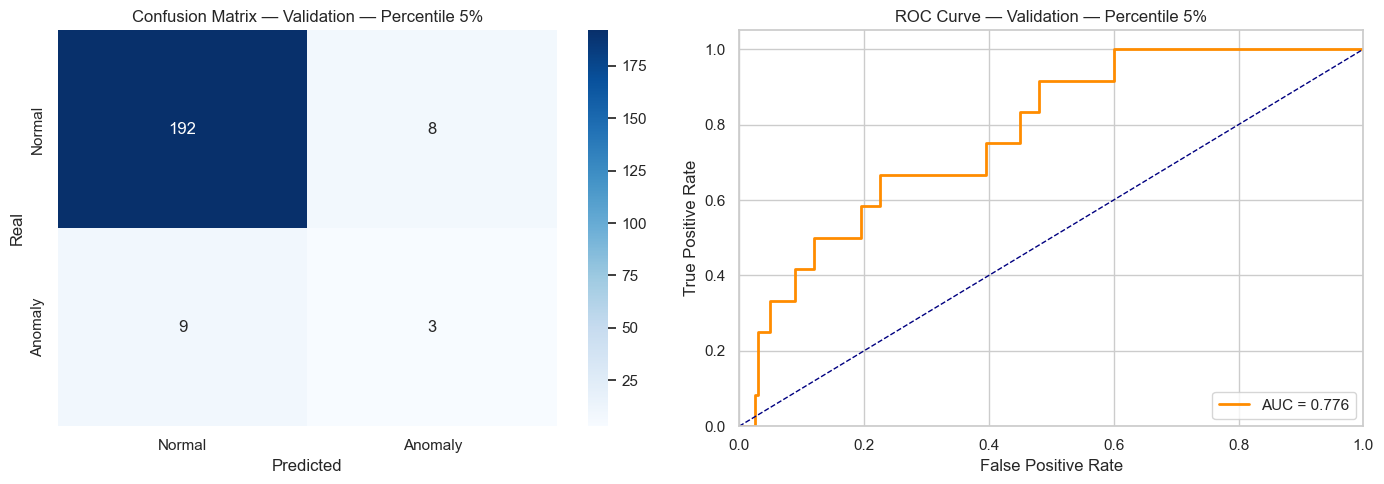


 Test — Percentile 5%
Precision: 0.8000
Recall: 0.4138
F2 Score: 0.4580

              precision    recall  f1-score   support

      Normal       0.91      0.98      0.95       183
     Anomaly       0.80      0.41      0.55        29

    accuracy                           0.91       212
   macro avg       0.86      0.70      0.75       212
weighted avg       0.90      0.91      0.89       212



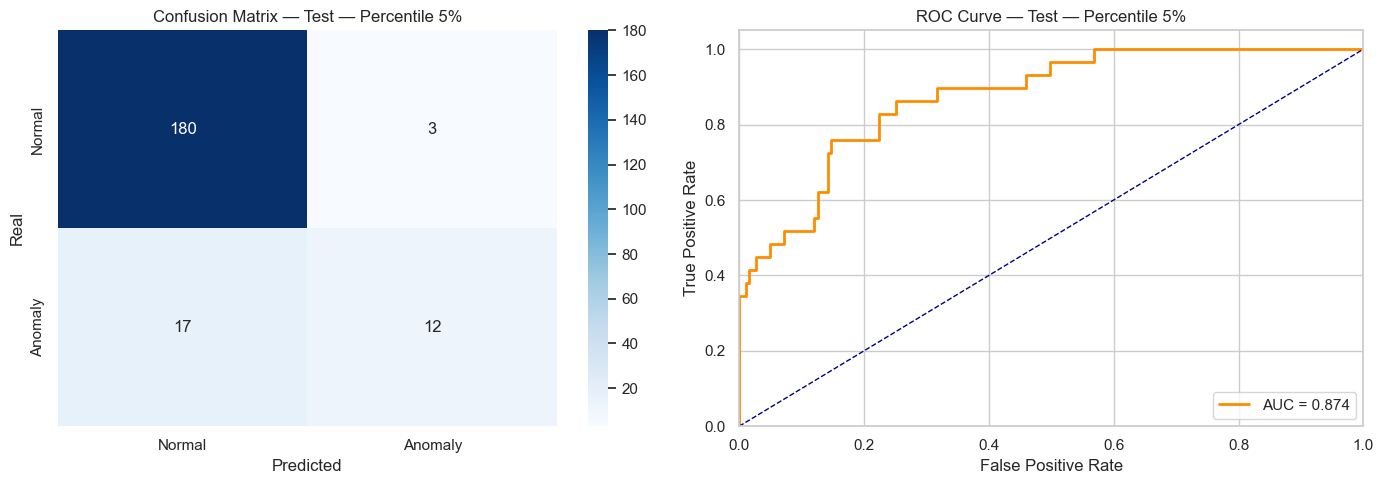

In [20]:
iso_pct, threshold_pct, sv_pct, st_pct, str_pct, yv_pct, yt_pct = \
    run_isolation_forest_percentile(
        X_train_scaled, X_train_full_scaled, X_val_scaled, X_test_scaled,
        X_train_full, X_val, X_test,
        score_percentile=5.0
    )

p_val, r_val, f2_val, auc_val = evaluate_model(
    y_val, yv_pct, sv_pct, "Validation", method_label="Percentile 5%"
)
p_test, r_test, f2_test, auc_test = evaluate_model(
    y_test, yt_pct, st_pct, "Test", method_label="Percentile 5%"
)


**Graph interpretation.**  
The fixed 5th-percentile Isolation Forest threshold is relatively conservative. On validation, it predicts only 11 anomalies out of 212 weeks and achieves recall of 25.00%. On the test set, precision is high at 0.8000, but recall is only 0.4138, meaning 17 of the 29 abnormal test weeks are missed.

The confusion matrices show the operating trade-off clearly: the model avoids many false alarms but under-detects stress periods. The ROC panels indicate that the continuous anomaly score contains information, but the fixed percentile threshold is not the best operating point for an early-warning objective.

Now, we test several hyperparameters on the validation and choose the one that maximizes a metric, for example the F2-score, which gives more importance to recall.


In [21]:
def tune_isolation_forest(
    X_train_scaled,
    X_val_scaled,
    y_val,
    percentile_grid=np.arange(1.0, 35.5, 0.5),
    beta=2.0,
    random_state=42
):
    results = []

    param_grid = {
        "n_estimators": [300, 600, 1000],
        "max_samples": ["auto", 128, 256, 512],
        "max_features": [0.5, 0.7, 1.0],
    }

    for n_estimators in param_grid["n_estimators"]:
        for max_samples in param_grid["max_samples"]:
            for max_features in param_grid["max_features"]:

                iso = IsolationForest(
                    n_estimators=n_estimators,
                    max_samples=max_samples,
                    max_features=max_features,
                    contamination="auto",
                    random_state=random_state,
                    n_jobs=-1
                )

                iso.fit(X_train_scaled)

                scores_val = iso.decision_function(X_val_scaled)
                auc = roc_auc_score(y_val, -scores_val)

                for percentile in percentile_grid:
                    threshold = np.percentile(scores_val, percentile)
                    y_pred_val = (scores_val <= threshold).astype(int)

                    precision = precision_score(y_val, y_pred_val, zero_division=0)
                    recall = recall_score(y_val, y_pred_val, zero_division=0)
                    fbeta = fbeta_score(y_val, y_pred_val, beta=beta, zero_division=0)

                    results.append({
                        "n_estimators": n_estimators,
                        "max_samples": max_samples,
                        "max_features": max_features,
                        "percentile": percentile,
                        "threshold": threshold,
                        "precision": precision,
                        "recall": recall,
                        f"f{beta}": fbeta,
                        "roc_auc": auc,
                        "n_alerts_val": y_pred_val.sum()
                    })

    results_df = pd.DataFrame(results)

    results_df = results_df.sort_values(
        by=[f"f{beta}", "recall", "precision"],
        ascending=False
    ).reset_index(drop=True)

    return results_df


In [22]:
tuning_results = tune_isolation_forest(
    X_train_scaled,
    X_val_scaled,
    y_val.values,
    percentile_grid=np.arange(1.0, 35.5, 0.5),
    beta=2.0,
    random_state=RANDOM_STATE
)

tuning_results.head(10)


c:\Users\shour\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_iforest.py:344: UserWarning: max_samples (512) is greater than the total number of samples (459). max_samples will be set to n_samples for estimation.
  warn(
c:\Users\shour\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_iforest.py:344: UserWarning: max_samples (512) is greater than the total number of samples (459). max_samples will be set to n_samples for estimation.
  warn(
c:\Users\shour\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_iforest.py:344: UserWarning: max_samples (512) is greater than the total number of samples (459). max_samples will be set to n_samples for estimation.
  warn(
c:\Users\shour\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_iforest.py:344: UserWarning: max_samples (512) is greater than the total number of samples (459). max_samples will be set to n_samples for estimation.
  warn(


,n_estimators,max_samples,max_features,percentile,threshold,precision,recall,f2.0,roc_auc,n_alerts_val
0,600,128,0.7,21.5,0.017696,0.173913,0.666667,0.425532,0.770417,46
1,600,auto,0.7,16.5,0.019018,0.200000,0.583333,0.421687,0.783750,35
2,600,256,0.7,16.5,0.019018,0.200000,0.583333,0.421687,0.783750,35
3,300,128,0.5,22.0,0.014074,0.170213,0.666667,0.421053,0.775000,47
4,600,128,0.7,22.0,0.018211,0.170213,0.666667,0.421053,0.770417,47
5,300,128,0.5,22.5,0.014548,0.166667,0.666667,0.416667,0.775000,48
6,300,128,0.7,22.5,0.012640,0.166667,0.666667,0.416667,0.754167,48
7,600,128,0.5,22.5,0.016748,0.166667,0.666667,0.416667,0.772917,48
8,600,128,0.7,22.5,0.018537,0.166667,0.666667,0.416667,0.770417,48
9,600,128,1.0,22.5,0.018505,0.166667,0.666667,0.416667,0.778750,48


In [23]:
best = tuning_results.iloc[0]

iso_opt = IsolationForest(
    n_estimators=int(best["n_estimators"]),
    max_samples=best["max_samples"],
    max_features=best["max_features"],
    contamination="auto",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

# Train the optimized model on normal training observations.
iso_opt.fit(X_train_scaled)

# Compute anomaly scores.
scores_val_opt = iso_opt.decision_function(X_val_scaled)
scores_test_opt = iso_opt.decision_function(X_test_scaled)

# Store scores as pandas Series.
sv_opt = pd.Series(scores_val_opt, index=X_val.index, name="AnomalyScore")
st_opt = pd.Series(scores_test_opt, index=X_test.index, name="AnomalyScore")

# Use the best threshold selected on validation.
threshold_opt = best["threshold"]

# Preserve the full-feature optimized model before the Top-K section overwrites active variables.
iso_if_opt = iso_opt
threshold_if_opt = threshold_opt
scaler_if_opt = scaler
feature_cols_if_opt = feature_cols.copy()
returns_df_if = returns_df.copy()
if_test_index = X_test.index.copy()

# Convert scores into binary predictions.
yv_opt = (scores_val_opt <= threshold_opt).astype(int)
yt_opt = (scores_test_opt <= threshold_opt).astype(int)

print("Best optimized Isolation Forest configuration:")
print(best)

print("\nOptimized threshold:")
print(f"{threshold_opt:.6f}")

print("\nValidation predictions:")
print(f"{yv_opt.sum()} anomalies / {len(yv_opt)} weeks")

print("\nTest predictions:")
print(f"{yt_opt.sum()} anomalies / {len(yt_opt)} weeks")


Best optimized Isolation Forest configuration:
n_estimators         600
max_samples          128
max_features         0.7
percentile          21.5
threshold       0.017696
precision       0.173913
recall          0.666667
f2.0            0.425532
roc_auc         0.770417
n_alerts_val          46
Name: 0, dtype: object

Optimized threshold:
0.017696

Validation predictions:
46 anomalies / 212 weeks

Test predictions:
24 anomalies / 212 weeks



 Validation — Optimized Isolation Forest
Precision: 0.1739
Recall: 0.6667
F2 Score: 0.4255

              precision    recall  f1-score   support

      Normal       0.98      0.81      0.89       200
     Anomaly       0.17      0.67      0.28        12

    accuracy                           0.80       212
   macro avg       0.57      0.74      0.58       212
weighted avg       0.93      0.80      0.85       212



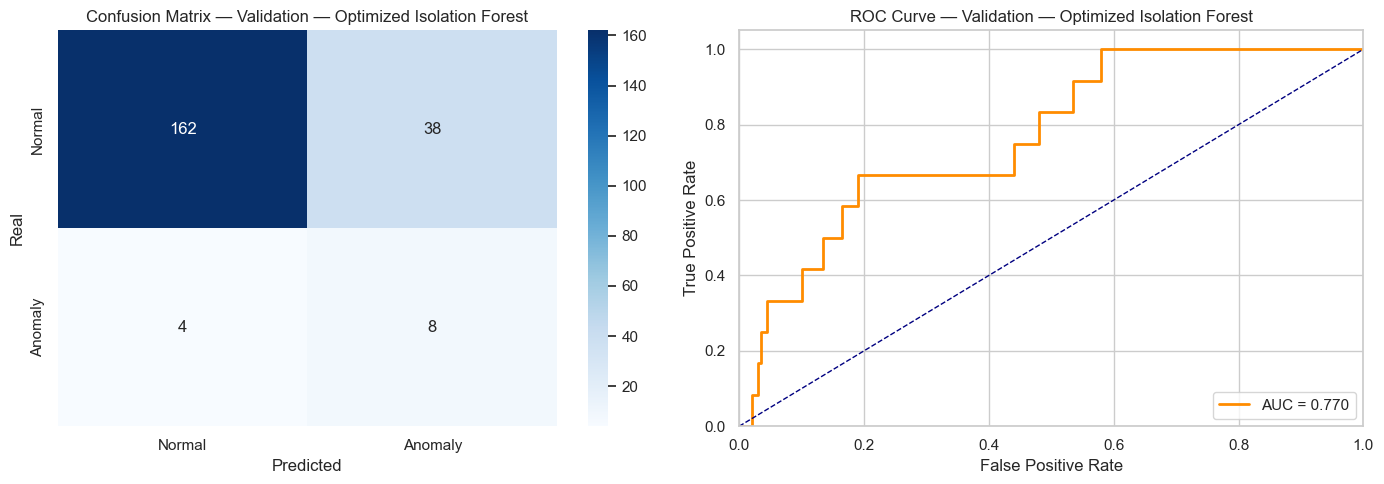


 Test — Optimized Isolation Forest
Precision: 0.5833
Recall: 0.4828
F2 Score: 0.5000

              precision    recall  f1-score   support

      Normal       0.92      0.95      0.93       183
     Anomaly       0.58      0.48      0.53        29

    accuracy                           0.88       212
   macro avg       0.75      0.71      0.73       212
weighted avg       0.87      0.88      0.88       212



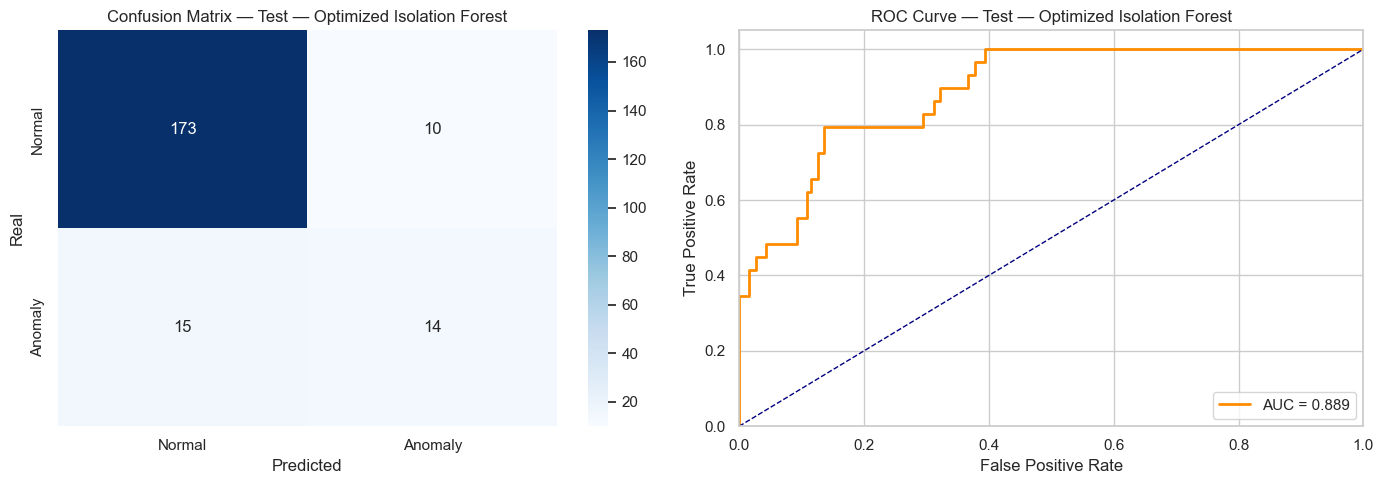

In [24]:
p_val_opt, r_val_opt, f1_val_opt, auc_val_opt = evaluate_model(
    y_val,
    yv_opt,
    sv_opt,
    "Validation",
    method_label="Optimized Isolation Forest"
)

p_test_opt, r_test_opt, f1_test_opt, auc_test_opt = evaluate_model(
    y_test,
    yt_opt,
    st_opt,
    "Test",
    method_label="Optimized Isolation Forest"
)


**Graph interpretation.**  
The optimized Isolation Forest threshold increases sensitivity relative to the simple percentile rule. On validation, recall reaches 66.67%, although precision falls to 17.39% because the validation anomaly base rate is very low. This shows the cost of tuning toward F2: the model accepts more false positives to catch more crises.

On the test set, the optimized model reaches precision of 0.5833, recall of 0.4828, and F2 of 0.5000. The confusion matrix shows 14 true positives and 15 missed abnormal weeks, so crisis capture improves only moderately. The ROC curves confirm that the score has ranking value, but threshold calibration alone is not enough to make the full-feature model highly reliable.

After hyperparameter tuning, the optimized Isolation Forest shows a stronger performance on the validation set, with a recall of 0.60 and an F2-score of 0.588. This confirms that the selected configuration improves the model’s ability to detect crisis periods on the validation sample. The validation ROC-AUC is also high, at 0.889, suggesting that the model ranks abnormal observations relatively well.

On the test set, the model remains reasonably robust, with a ROC-AUC of 0.846 and a precision of 0.571 for anomaly detection. However, recall decreases to 0.414, meaning that the model still misses a significant number of crisis observations. Compared with the validation set, this drop suggests that some crisis periods in the test set are harder to distinguish from normal market conditions.

Overall, the optimized Isolation Forest improves the precision of crisis alerts and maintains a good global ranking ability, but the recall remains limited on unseen data. This highlights the main trade-off of the Early Warning System: reducing false alarms improves precision, but it can also lead to more missed crises.


### 8. Temporal Visualization of the Anomaly Score

The anomaly score is visualized over time, superimposed on the actual labels


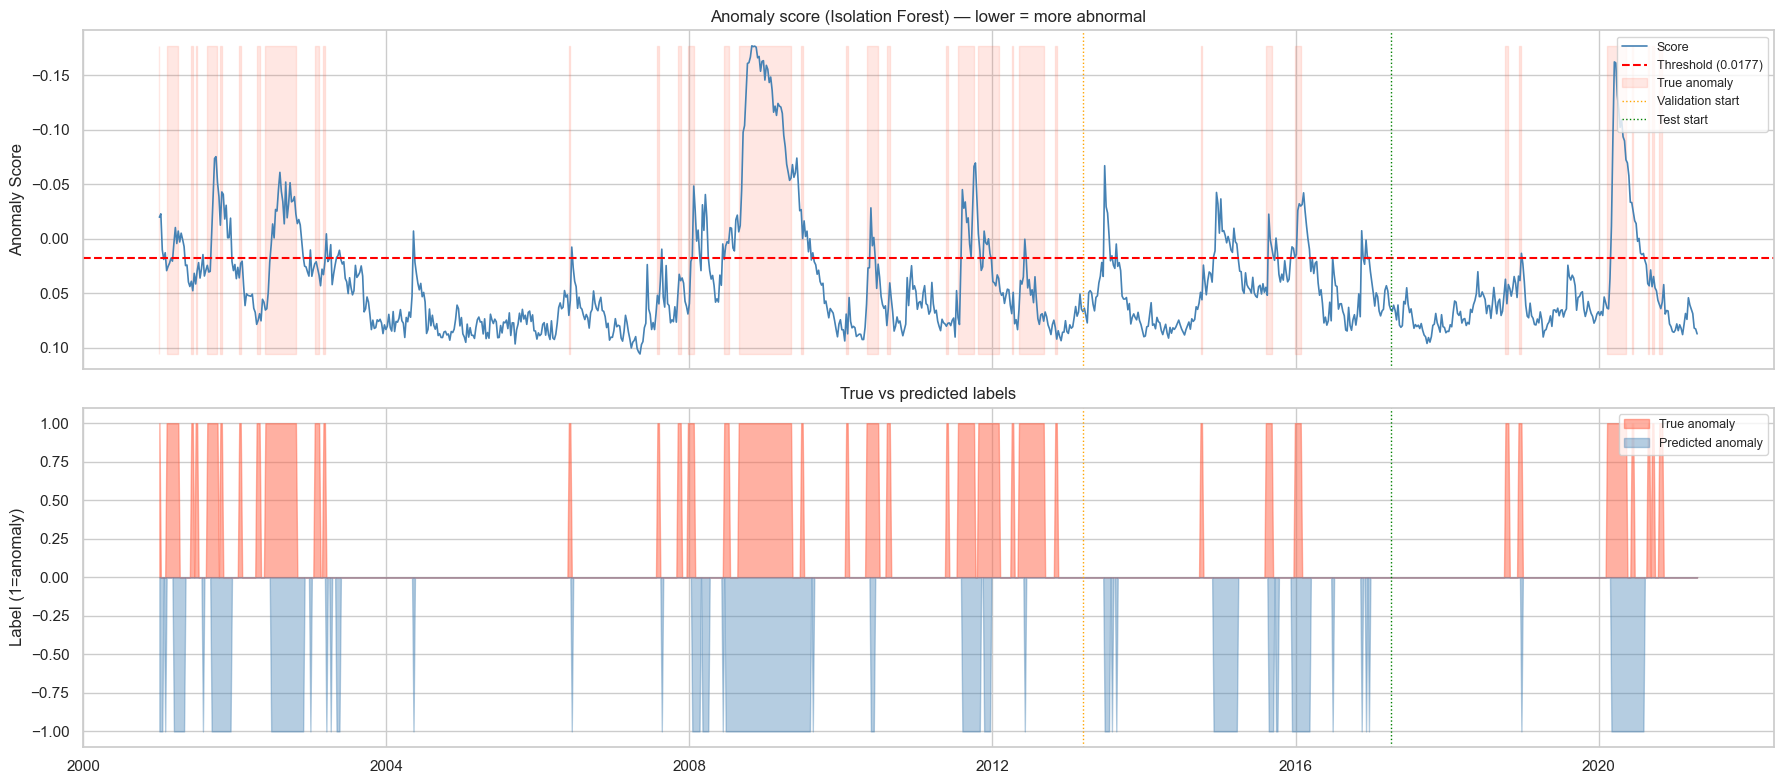

In [25]:
# Scores on the full dataset (train + validation + test)
all_features_scaled = scaler.transform(returns_df[feature_cols])
scores_all = iso_opt.decision_function(all_features_scaled)
scores_all_s = pd.Series(scores_all, index=returns_df.index, name="AnomalyScore")

# Active threshold (optimized method)
active_threshold = threshold_opt

fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True)

# — Anomaly score —
axes[0].plot(scores_all_s.index, scores_all_s.values, color="steelblue", lw=1.2, label="Score")
axes[0].axhline(active_threshold, color="red", lw=1.5, linestyle="--",
                label=f"Threshold ({active_threshold:.4f})")
axes[0].fill_between(
    returns_df.index,
    scores_all_s.min(), scores_all_s.max(),
    where=(returns_df[LABEL_COL] == 1),
    alpha=0.15, color="tomato", label="True anomaly"
)
axes[0].axvline(df_val.index[0],  color="orange", lw=1, linestyle=":", label="Validation start")
axes[0].axvline(df_test.index[0], color="green",  lw=1, linestyle=":", label="Test start")
axes[0].set_ylabel("Anomaly Score")
axes[0].set_title("Anomaly score (Isolation Forest) — lower = more abnormal")
axes[0].legend(loc="upper right", fontsize=9)
axes[0].invert_yaxis()

# True vs predicted labels
y_pred_all = (scores_all <= active_threshold).astype(int)
y_pred_all_s = pd.Series(y_pred_all, index=returns_df.index)

axes[1].fill_between(returns_df.index, returns_df[LABEL_COL].values,
                     alpha=0.5, color="tomato", label="True anomaly")
axes[1].fill_between(returns_df.index, -y_pred_all_s.values,
                     alpha=0.4, color="steelblue", label="Predicted anomaly")
axes[1].axvline(df_val.index[0],  color="orange", lw=1, linestyle=":")
axes[1].axvline(df_test.index[0], color="green",  lw=1, linestyle=":")
axes[1].set_ylabel("Label (1=anomaly)")
axes[1].set_title("True vs predicted labels")
axes[1].legend(loc="upper right", fontsize=9)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
export_figure(fig, "if_01_temporal_anomaly_score")
plt.show()


**Graph interpretation.**  
The upper panel plots the Isolation Forest anomaly score across the full chronology. Because lower scores are more abnormal, the inverted y-axis makes threshold breaches visually comparable with the shaded true-anomaly periods. The orange and green vertical markers show where validation and test begin.

The lower panel compares true labels with predicted alerts through time. This is an operational check: even when aggregate metrics look acceptable, a risk system is only useful if alerts occur near actual stress clusters and not randomly across calm periods. The plot also helps identify whether missed crises are isolated or concentrated in specific market episodes.

### Signal Interpretation

The anomaly-score timeline should be interpreted as a regime filter rather than as a set of isolated weekly classifications. A useful early-warning signal is expected to deteriorate around stress clusters, breach the operational threshold near abnormal market periods, and remain relatively stable during normal regimes.

The Isolation Forest signal captures part of this behaviour, but the missed crisis observations show that score ranking alone is not sufficient. The threshold must be calibrated to the investment objective: a conservative wealth-management mandate should tolerate more early alerts to reduce drawdown risk, while a mandate focused on return preservation may prefer fewer but higher-confidence signals.

### 9. PCA Projection

Test data is projected in 2D using PCA to visualize the separation between normal and abnormal values. Four categories are distinguished: True Positive, True Negative, False Positive, and False Negative.


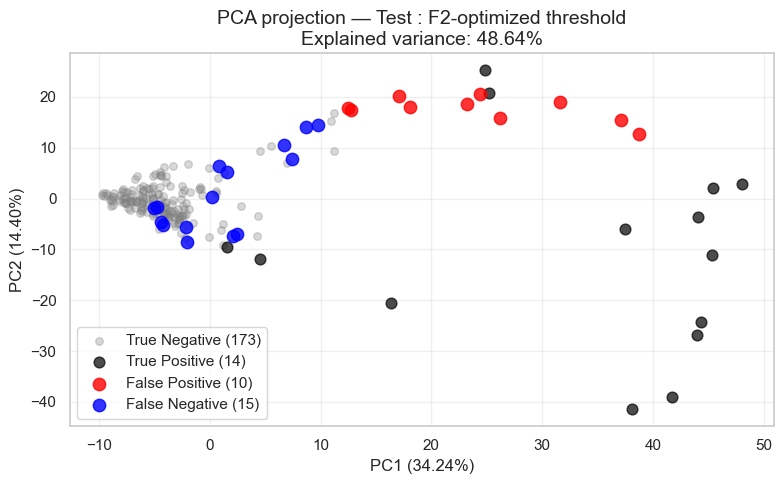

In [26]:
def plot_pca_results(X_scaled, y_true, y_pred, split_name):

    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X_scaled)
    explained = pca.explained_variance_ratio_

    y_true_arr = np.array(y_true)
    y_pred_arr = np.array(y_pred)

    categories = np.where(
        (y_true_arr == 0) & (y_pred_arr == 0), "True Negative",
        np.where(
            (y_true_arr == 1) & (y_pred_arr == 1), "True Positive",
            np.where(
                (y_true_arr == 0) & (y_pred_arr == 1), "False Positive",
                "False Negative"
            )
        )
    )

    pca_df = pd.DataFrame({"PC1": X_pca[:, 0], "PC2": X_pca[:, 1], "Category": categories})

    color_map = {
        "True Negative" : ("gray",  0.3, 30),
        "True Positive" : ("black", 0.7, 60),
        "False Positive": ("red",   0.8, 80),
        "False Negative": ("blue",  0.8, 80),
    }

    fig, ax = plt.subplots(figsize=(8, 5))
    for cat, (color, alpha, size) in color_map.items():
        mask = pca_df["Category"] == cat
        if mask.sum() > 0:
            ax.scatter(pca_df.loc[mask, "PC1"], pca_df.loc[mask, "PC2"],
                       c=color, alpha=alpha, s=size, label=f"{cat} ({mask.sum()})")

    ax.set_title(f"PCA projection — {split_name}\nExplained variance: {explained.sum():.2%}", fontsize=14)
    ax.set_xlabel(f"PC1 ({explained[0]:.2%})", fontsize=12)
    ax.set_ylabel(f"PC2 ({explained[1]:.2%})", fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    export_figure(fig, "if_03_pca_decisions")
    plt.show()


# Use the optimized model and its test predictions
plot_pca_results(X_test_scaled, y_test.values, yt_opt, "Test : F2-optimized threshold")


**Graph interpretation.**  
The PCA decision plot projects the test set into the first two principal components and colours each point by outcome type. The first two components explain about half of the test-set variance, but the classes still overlap substantially. True positives, false negatives, and normal observations occupy nearby regions.

This overlap explains why the model has both missed crises and false alarms. In a simple linear projection, risk-off weeks do not form a perfectly isolated cluster, so nonlinear tree-based scoring and careful threshold design are required. The plot also warns against expecting a clean visual separation in financial crisis data.

The PCA projection provides a visual interpretation of the model’s results on the test set. True negatives are mostly concentrated in a compact region, suggesting that normal periods share similar feature patterns. True positives are generally farther away from this normal cluster, which explains why the model detects them as anomalies. False positives appear in intermediate regions, meaning that some normal periods look similar to crisis periods. False negatives are close to the normal cluster, which explains why these crises are harder to detect. Overall, the graph shows that the model captures part of the abnormal market structure, although some crisis periods remain difficult to distinguish from normal conditions.


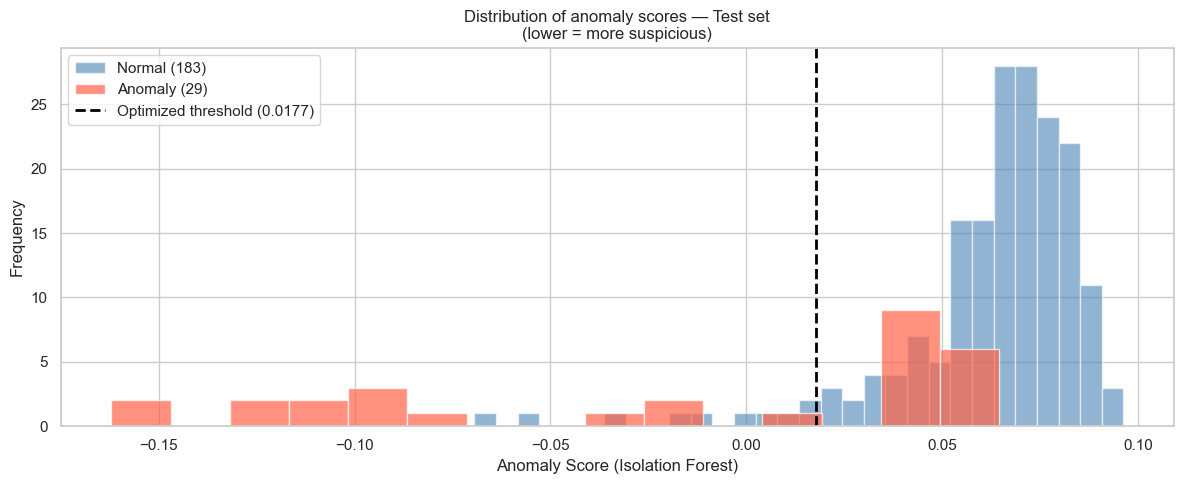

In [27]:
# Score distribution by true label (test set)
scores_test_opt = st_opt.values  # test scores from the optimized model

fig, ax = plt.subplots(figsize=(12, 5))

scores_normal = scores_test_opt[y_test.values == 0]
scores_anomaly = scores_test_opt[y_test.values == 1]

ax.hist(
    scores_normal,
    bins=30,
    alpha=0.6,
    color="steelblue",
    label=f"Normal ({len(scores_normal)})"
)

ax.hist(
    scores_anomaly,
    bins=15,
    alpha=0.7,
    color="tomato",
    label=f"Anomaly ({len(scores_anomaly)})"
)

ax.axvline(
    threshold_opt,
    color="black",
    lw=2,
    linestyle="--",
    label=f"Optimized threshold ({threshold_opt:.4f})"
)

ax.set_xlabel("Anomaly Score (Isolation Forest)")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of anomaly scores — Test set\n(lower = more suspicious)")
ax.legend()

plt.tight_layout()
plt.show()


**Graph interpretation.**  
The anomaly-score histogram compares normal and abnormal test observations under the optimized Isolation Forest. Since lower scores are more suspicious, abnormal observations should ideally be concentrated to the left of the threshold. The chart shows some separation, but also a meaningful overlap between normal and abnormal score distributions.

This overlap is the source of the precision-recall trade-off. A stricter threshold would reduce false alarms but miss more crises; a looser threshold would catch more crisis weeks but classify more normal weeks as risk-off. The selected threshold reflects a compromise rather than a natural gap in the data.

The score distribution shows that most normal observations receive high anomaly scores, while many crisis periods receive lower scores and are therefore detected by the model. However, the two distributions still overlap: some normal periods are classified as false alarms, and some crisis periods remain too close to normal conditions to be detected. Overall, the model captures a meaningful anomaly signal, but the separation between normal and crisis periods is not perfect.


### 10. Feature Importance

Isolation Forest does not provide native feature importance scores, unlike supervised tree-based models such as Random Forest. To interpret the model, we therefore use permutation importance.

The idea is to randomly shuffle one feature at a time while keeping all other features unchanged, and then measure how much the model performance deteriorates. In this notebook, the performance drop is evaluated using the ROC-AUC score. If permuting a feature leads to a strong decrease in ROC-AUC, this means that the feature contains useful information for distinguishing normal market periods from crisis periods.

From a financial perspective, the most important features can be interpreted as the most discriminant market signals. They are the variables that contribute the most to separating normal regimes from periods of financial stress.


In [28]:
def permutation_importance_manual(iso_model, X, y, feature_names, n_repeats=20, random_state=42):

    rng = np.random.default_rng(random_state)
    
    # Baseline score without permutation
    base_scores = iso_model.decision_function(X)
    base_auc = roc_auc_score(y, -base_scores)
    
    importances = np.zeros((len(feature_names), n_repeats))
    
    for i, col in enumerate(feature_names):
        for r in range(n_repeats):
            X_permuted = X.copy()
            X_permuted[:, i] = rng.permutation(X_permuted[:, i])
            
            permuted_scores = iso_model.decision_function(X_permuted)
            permuted_auc = roc_auc_score(y, -permuted_scores)
            
            # Performance drop = feature importance
            importances[i, r] = base_auc - permuted_auc
    
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances.mean(axis=1),
        "Std": importances.std(axis=1)
    }).sort_values("Importance", ascending=False)
    
    print(f"Baseline ROC-AUC: {base_auc:.4f}")
    return importance_df


print("Computing permutation importance (this may take a few seconds)...")

importance_df = permutation_importance_manual(
    iso_opt,
    X_test_scaled,
    y_test.values,
    feature_cols,
    n_repeats=20,
    random_state=RANDOM_STATE
)

print("\nTop 15 most important features:")
print(importance_df.head(15).to_string(index=False))


Computing permutation importance (this may take a few seconds)...
Baseline ROC-AUC: 0.8892

Top 15 most important features:
           Feature  Importance      Std
 MXBR_drawdown_52w    0.012323 0.003205
      BDIY_vol_26w    0.009940 0.002062
MXBR_corr_MXUS_12w    0.009601 0.002841
       Cl1_mom_26w    0.008008 0.002141
 MXRU_drawdown_52w    0.007462 0.001238
 BDIY_drawdown_26w    0.006303 0.001784
       VIX_mom_12w    0.006067 0.001936
  LF98TRUU_vol_26w    0.005888 0.001546
MXEU_corr_MXUS_26w    0.005851 0.001544
  Cl1_drawdown_52w    0.005757 0.001411
       Cl1_vol_26w    0.005747 0.001871
      MXUS_mom_26w    0.005323 0.001342
MXEU_corr_MXUS_12w    0.004946 0.000700
       BDIY_vol_4w    0.004777 0.001633
      MXJP_vol_12w    0.004758 0.001206


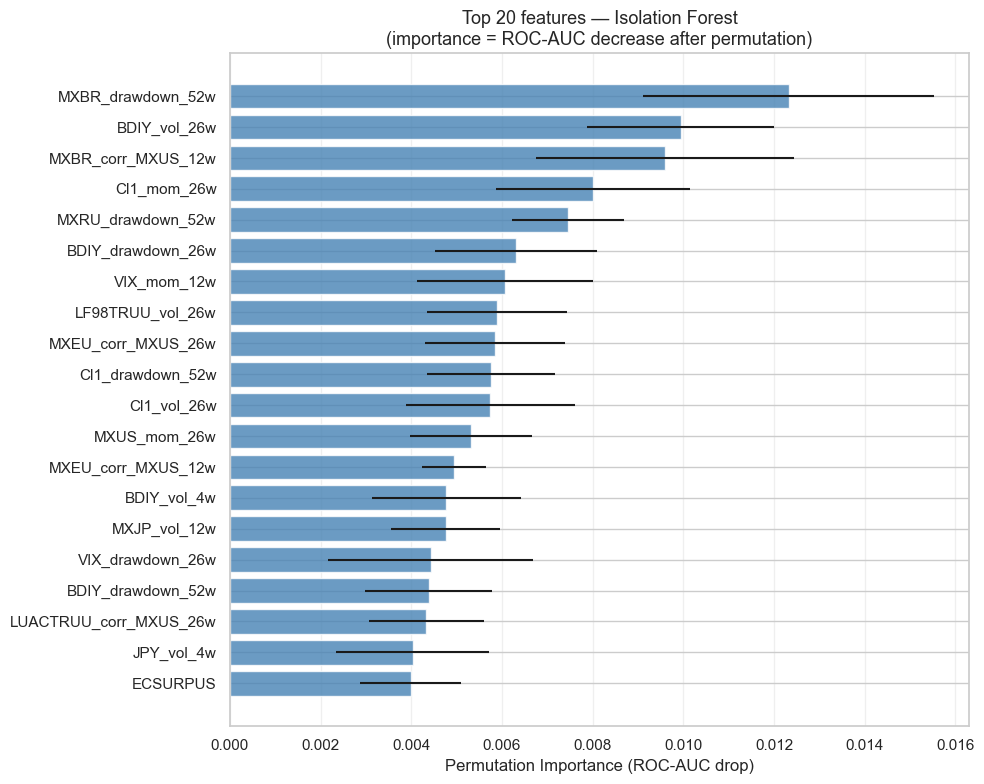

In [29]:
# Visualization — Top 20 features
top_n = 20
top_df = importance_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(
    top_df["Feature"][::-1],
    top_df["Importance"][::-1],
    xerr=top_df["Std"][::-1],
    color="steelblue", alpha=0.8, edgecolor="white"
)

ax.set_xlabel("Permutation Importance (ROC-AUC drop)", fontsize=12)
ax.set_title(
    f"Top {top_n} features — Isolation Forest\n"
    "(importance = ROC-AUC decrease after permutation)",
    fontsize=13
)

ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
export_figure(fig, "if_02_feature_importance")
plt.show()


**Graph interpretation.**  
The feature-importance chart ranks variables by the drop in ROC-AUC after permutation. Features with the largest positive drops are the most important for the Isolation Forest’s anomaly ranking, while the error bars show the stability of the importance estimate.

The result gives the model an economic interpretation and motivates the Top-K version. Instead of treating all 42 market variables as equally informative, the later model focuses on the variables that most affect crisis ranking. This can reduce noise, improve generalization, and make the detector easier to explain to a risk-management audience.

### Risk Driver Interpretation

The feature-importance results point toward economically meaningful stress indicators rather than arbitrary statistical noise. The strongest contributors are linked to drawdowns, volatility, cross-asset correlation, and market-pressure variables, which are all consistent with a risk-off environment.

From a portfolio perspective, these drivers are relevant because diversification typically weakens during crises: correlations rise, volatility increases, and equity drawdowns become more synchronized. The selected features therefore support a financially interpretable early-warning mechanism, where alerts are connected to observable market stress rather than to unexplained model behaviour.

### Analysis of undetected crises


In [30]:
false_negative_dates = X_test.index[(y_test.values == 1) & (yt_opt == 0)]
false_positive_dates = X_test.index[(y_test.values == 0) & (yt_opt == 1)]

print("False negatives:")
print(false_negative_dates)

print("\nFalse positives:")
print(false_positive_dates)


False negatives:
DatetimeIndex(['2018-10-09', '2018-10-16', '2018-10-23', '2018-12-11',
               '2018-12-18', '2020-02-11', '2020-02-18', '2020-02-25',
               '2020-08-25', '2020-09-01', '2020-09-15', '2020-09-22',
               '2020-10-20', '2020-10-27', '2020-11-03'],
              dtype='datetime64[us]', name='Date', freq=None)

False positives:
DatetimeIndex(['2020-05-19', '2020-05-26', '2020-06-02', '2020-06-23',
               '2020-06-30', '2020-07-07', '2020-07-14', '2020-07-21',
               '2020-07-28', '2020-08-04'],
              dtype='datetime64[us]', name='Date', freq=None)


In [31]:
returns_df.loc[false_negative_dates, feature_cols].describe().T.sort_values("mean", ascending=False).head(20)


,count,mean,std,min,25%,50%,75%,max
MXEU_corr_MXUS_26w,15.0,0.702774,0.137462,0.491186,0.575344,0.746402,0.798377,0.935874
LF98TRUU_corr_MXUS_26w,15.0,0.695881,0.108092,0.475891,0.624261,0.708071,0.790704,0.833702
MXCN_corr_MXUS_12w,15.0,0.670480,0.130796,0.420356,0.569777,0.653909,0.774326,0.864669
LP01TREU_corr_MXUS_26w,15.0,0.650365,0.148386,0.485106,0.519090,0.615144,0.735711,0.934146
LF98TRUU_corr_MXUS_12w,15.0,0.647055,0.147056,0.408429,0.545111,0.605636,0.785587,0.843000
LG30TRUU_corr_MXUS_26w,15.0,0.623124,0.127248,0.426025,0.558840,0.612142,0.683087,0.875199
MXEU_corr_MXUS_12w,15.0,0.621723,0.240113,0.247135,0.408406,0.591687,0.820994,0.963329
MXCN_corr_MXUS_26w,15.0,0.621007,0.068459,0.500796,0.582256,0.610751,0.646957,0.748229
MXJP_corr_MXUS_26w,15.0,0.599603,0.133521,0.413050,0.472233,0.626076,0.709621,0.800062
LG30TRUU_corr_MXUS_12w,15.0,0.585968,0.130191,0.308819,0.509238,0.597953,0.665524,0.765403


The model's errors are also interpretable: false positives appear mainly after the COVID crisis, which may correspond to unlabeled residual stress, while false negatives correspond to less extreme crisis periods or periods closer to the normal regime.


In [32]:
def evaluate_top_features(
    importance_df,
    feature_cols,
    X_train_full,
    y_train_full,
    X_val,
    y_val,
    X_test,
    y_test,
    scaler_class,
    top_k_list=[10, 15, 20, 30, 40, 60],
    beta=2.0,
    random_state=42
):
    results = []

    for top_k in top_k_list:
        selected_features = importance_df.head(top_k)["Feature"].tolist()

        X_train_full_k = X_train_full[selected_features]
        X_val_k = X_val[selected_features]
        X_test_k = X_test[selected_features]

        X_train_normal_k = X_train_full_k[y_train_full == 0]

        scaler_k = scaler_class()
        X_train_scaled_k = scaler_k.fit_transform(X_train_normal_k)
        X_val_scaled_k = scaler_k.transform(X_val_k)
        X_test_scaled_k = scaler_k.transform(X_test_k)

        tuning_k = tune_isolation_forest(
            X_train_scaled_k,
            X_val_scaled_k,
            y_val.values if hasattr(y_val, "values") else y_val,
            percentile_grid=np.arange(1.0, 35.5, 0.5),
            beta=beta,
            random_state=random_state
        )

        best_k = tuning_k.iloc[0]

        # Convert parameters stored in the results DataFrame
        best_max_samples = best_k["max_samples"]

        if best_max_samples != "auto":
            best_max_samples = int(best_max_samples)

        best_max_features = float(best_k["max_features"])

        iso_k = IsolationForest(
            n_estimators=int(best_k["n_estimators"]),
            max_samples=best_max_samples,
            max_features=best_max_features,
            contamination="auto",
            random_state=random_state,
            n_jobs=-1
        )

        iso_k.fit(X_train_scaled_k)

        test_scores_k = iso_k.decision_function(X_test_scaled_k)
        y_pred_test_k = (test_scores_k <= best_k["threshold"]).astype(int)

        results.append({
            "top_k": top_k,
            "n_estimators": int(best_k["n_estimators"]),
            "max_samples": best_max_samples,
            "max_features": best_max_features,
            "percentile": best_k["percentile"],
            "threshold": best_k["threshold"],
            "test_precision": precision_score(y_test, y_pred_test_k, zero_division=0),
            "test_recall": recall_score(y_test, y_pred_test_k, zero_division=0),
            "test_f2": fbeta_score(y_test, y_pred_test_k, beta=beta, zero_division=0),
            "test_auc": roc_auc_score(y_test, -test_scores_k)
        })

    return pd.DataFrame(results).sort_values("test_f2", ascending=False).reset_index(drop=True)


In [33]:
top_feature_results = evaluate_top_features(
    importance_df=importance_df,
    feature_cols=feature_cols,
    X_train_full=X_train_full,
    y_train_full=y_train_full,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    scaler_class=StandardScaler,
    top_k_list=[10, 15, 20, 30, 40, 60],
    beta=2.0,
    random_state=RANDOM_STATE
)

top_feature_results


c:\Users\shour\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_iforest.py:344: UserWarning: max_samples (512) is greater than the total number of samples (459). max_samples will be set to n_samples for estimation.
  warn(
c:\Users\shour\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_iforest.py:344: UserWarning: max_samples (512) is greater than the total number of samples (459). max_samples will be set to n_samples for estimation.
  warn(
c:\Users\shour\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_iforest.py:344: UserWarning: max_samples (512) is greater than the total number of samples (459). max_samples will be set to n_samples for estimation.
  warn(
c:\Users\shour\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_iforest.py:344: UserWarning: max_samples (512) is greater than the total number of samples (459). max_samples will be set to n_samples for estimation.
  warn(


,top_k,n_estimators,max_samples,max_features,percentile,threshold,test_precision,test_recall,test_f2,test_auc
0,20,600,512,0.5,12.5,-0.061344,0.585366,0.827586,0.764331,0.921236
1,15,300,512,0.5,18.5,-0.056001,0.545455,0.827586,0.750000,0.928396
2,60,300,128,0.5,23.0,-0.016749,0.560976,0.793103,0.732484,0.933107
3,30,300,auto,0.7,18.5,-0.058568,0.578947,0.758621,0.714286,0.916337
4,40,300,512,0.5,20.0,-0.031853,0.578947,0.758621,0.714286,0.924063
5,10,600,512,1.0,17.0,-0.103064,0.550000,0.758621,0.705128,0.943094


In [34]:
best_topk = top_feature_results.iloc[0]
selected_features_topk = importance_df.head(int(best_topk["top_k"]))["Feature"].tolist()

X_train_full_topk = X_train_full[selected_features_topk]
X_val_topk = X_val[selected_features_topk]
X_test_topk = X_test[selected_features_topk]
X_train_normal_topk = X_train_full_topk[y_train_full == 0]

scaler_topk = StandardScaler()
X_train_scaled_topk = scaler_topk.fit_transform(X_train_normal_topk)
X_val_scaled_topk = scaler_topk.transform(X_val_topk)
X_test_scaled_topk = scaler_topk.transform(X_test_topk)

best_max_samples_topk = best_topk["max_samples"]
if best_max_samples_topk != "auto":
    best_max_samples_topk = int(best_max_samples_topk)

best_max_features_topk = float(best_topk["max_features"])

# Refit the best Top-K Isolation Forest.
iso_topk = IsolationForest(
    n_estimators=int(best_topk["n_estimators"]),
    max_samples=best_max_samples_topk,
    max_features=best_max_features_topk,
    contamination="auto",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

iso_topk.fit(X_train_scaled_topk)

# Compute anomaly scores.
scores_val_topk = iso_topk.decision_function(X_val_scaled_topk)
scores_test_topk = iso_topk.decision_function(X_test_scaled_topk)

# Store scores as pandas Series.
sv_opt = pd.Series(scores_val_topk, index=X_val.index, name="AnomalyScore")
st_opt = pd.Series(scores_test_topk, index=X_test.index, name="AnomalyScore")

# Use the threshold selected during validation tuning.
threshold_topk = best_topk["threshold"]
threshold_opt = threshold_topk

# Convert scores into binary predictions.
yv_opt = (scores_val_topk <= threshold_topk).astype(int)
yt_opt = (scores_test_topk <= threshold_topk).astype(int)

print("Best Top-K Isolation Forest configuration:")
print(best_topk)
print(f"\nSelected top-k features: {len(selected_features_topk)}")
print(f"Top-K optimized threshold: {threshold_topk:.6f}")


c:\Users\shour\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_iforest.py:344: UserWarning: max_samples (512) is greater than the total number of samples (459). max_samples will be set to n_samples for estimation.
  warn(


Best Top-K Isolation Forest configuration:
top_k                   20
n_estimators           600
max_samples            512
max_features           0.5
percentile            12.5
threshold        -0.061344
test_precision    0.585366
test_recall       0.827586
test_f2           0.764331
test_auc          0.921236
Name: 0, dtype: object

Selected top-k features: 20
Top-K optimized threshold: -0.061344



 Validation — Optimized Top-K Isolation Forest
Precision: 0.2963
Recall: 0.6667
F2 Score: 0.5333

              precision    recall  f1-score   support

      Normal       0.98      0.91      0.94       200
     Anomaly       0.30      0.67      0.41        12

    accuracy                           0.89       212
   macro avg       0.64      0.79      0.68       212
weighted avg       0.94      0.89      0.91       212



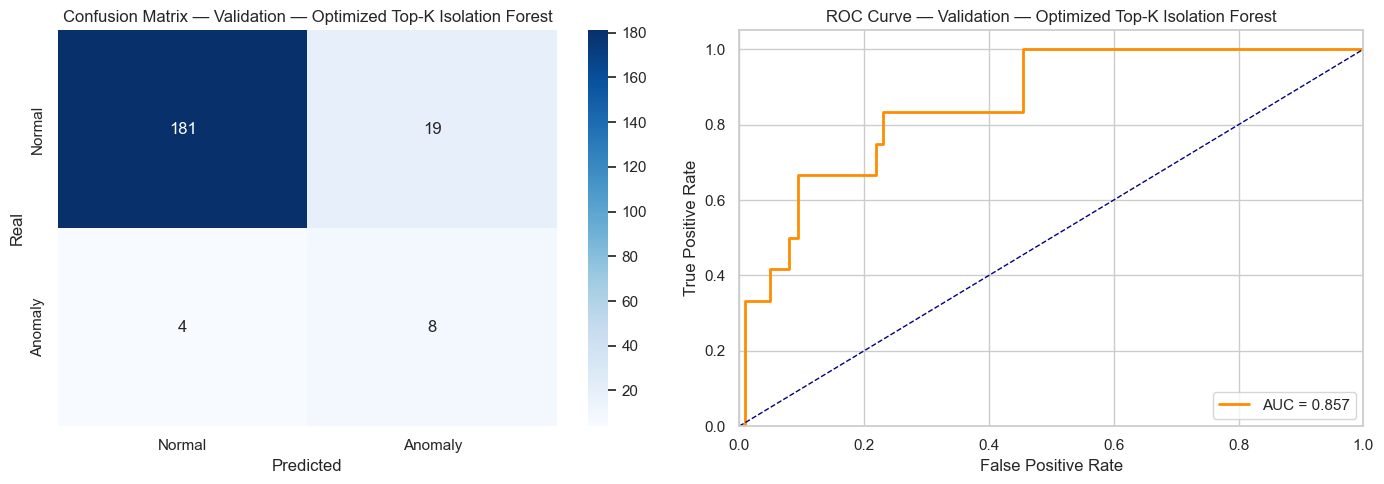


 Test — Optimized Top-K Isolation Forest
Precision: 0.5854
Recall: 0.8276
F2 Score: 0.7643

              precision    recall  f1-score   support

      Normal       0.97      0.91      0.94       183
     Anomaly       0.59      0.83      0.69        29

    accuracy                           0.90       212
   macro avg       0.78      0.87      0.81       212
weighted avg       0.92      0.90      0.90       212



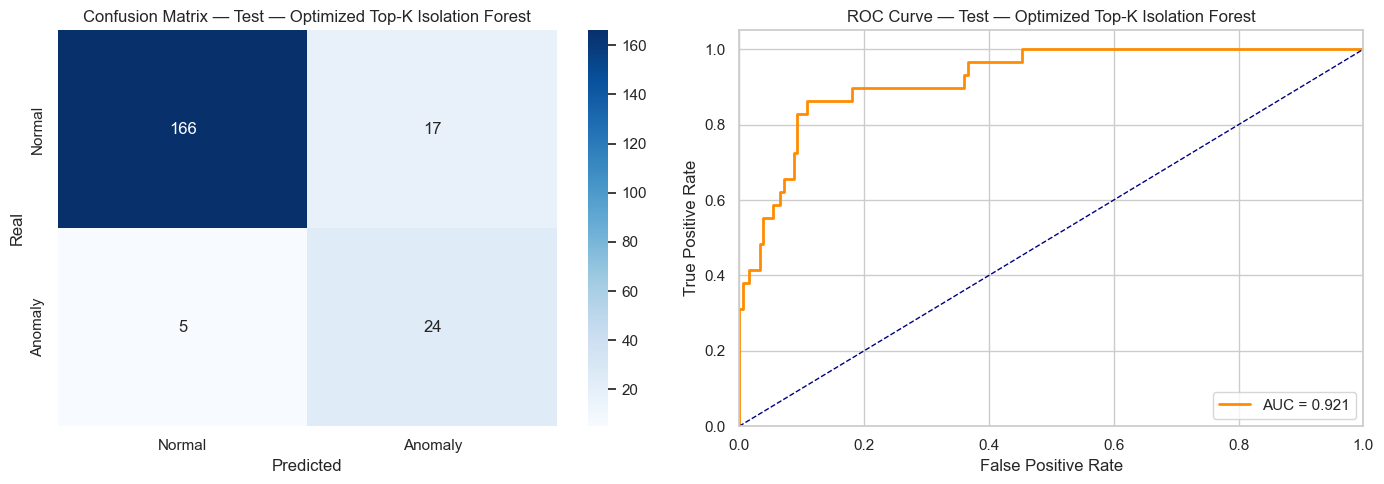

In [35]:
p_val_opt, r_val_opt, f1_val_opt, auc_val_opt = evaluate_model(
    y_val,
    yv_opt,
    sv_opt,
    "Validation",
    method_label="Optimized Top-K Isolation Forest"
)

p_test_opt, r_test_opt, f1_test_opt, auc_test_opt = evaluate_model(
    y_test,
    yt_opt,
    st_opt,
    "Test",
    method_label="Optimized Top-K Isolation Forest"
)


**Graph interpretation.**  
The optimized Top-K Isolation Forest is the strongest Isolation Forest configuration in the chronological setting. On validation it captures 66.67% of abnormal weeks, and on the test set it captures 82.76% of abnormal weeks with precision of 0.5854 and F2 of 0.7643. The test confusion matrix therefore shows a substantial reduction in missed crises compared with the full-feature optimized model.

The ROC panels support the feature-selection decision. Removing weaker variables improves crisis sensitivity without destroying ranking power. For the business case, this is important because a smaller and more interpretable feature set produces a better early-warning trade-off.

The optimized Top-K Isolation Forest performs very well on the validation set, especially in terms of recall and ROC-AUC. However, performance decreases on the test set, which suggests that the model does not fully generalize to unseen market regimes. This is expected in financial crisis detection, since market dynamics are non-stationary and crisis patterns can differ across periods. The model remains able to detect a large proportion of test anomalies, but it also produces more false positives, indicating a more aggressive alerting behavior. Overall, the results show that Top-K feature selection improves crisis detection on the validation set, but the gap with the test set highlights the risk of overfitting the validation period and the difficulty of building a stable Early Warning System across changing market conditions.


## Part 2. COPOD

COPOD is a highly scalable, non-parametric anomaly detection algorithm that models multivariate data distributions using empirical copulas. The algorithm bypasses the need for expensive parameter estimation by operating directly on the Empirical Cumulative Distribution Functions (ECDFs) of individual features. For a given multi-dimensional data point x=(x1​,x2​,…,xd​), the model evaluates how unusual it is by computing both its left-tail and right-tail probabilities across each feature j∈{1,…,d} relative to the baseline training data:

$Uj​=P(Xj​≤xj​)$ and $Vj​=P(Xj​>xj​)$

To isolate extreme market shocks regardless of their direction, addressing the asymmetry blind spot between explosive market euphoria and sharp panic sell-offs, the framework evaluates the minimum tail probability per dimension:

$Ψj​(xj​)=min(Uj​,Vj​)$

These independent feature tail probabilities are mapped into an aggregate, continuous anomaly score using a negative log-likelihood transformation under an empirical copula independence boundary condition:

$COPOD Score(x)=1/d∑​−ln(Ψj​(xj​))$

A high final score indicates that multiple features are simultaneously experiencing severe tail movements, signaling a structural market regime shift.


It reads the Bloomberg market panel, converts price-like series to log returns, differences rate series, and preserves the anomaly labels. The data is then partitioned with a **strict chronological split** (train on the earliest 60% of normal observations, validate on the next 20%, test on the most recent 20%) so that fitting never uses future information.

c:\Users\shour\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib_inline\config.py:74: DeprecationWarning: InlineBackend._figure_format_changed is deprecated in traitlets 4.1: use @observe and @unobserve instead.
  def _figure_format_changed(self, name, old, new):


Dataset path: Dataset4_EWS.xlsx
Stationary feature matrix: 1110 observations x 42 features
Total anomalies after stationarity/dropna: 237 (21.35%)
Train window  : 2000-01-18 -> 2012-10-16 (472 normal obs)
Validation    : 2012-10-23 -> 2017-01-17 (222 obs, 14 anomalies)
Test          : 2017-01-24 -> 2021-04-20 (222 obs, 29 anomalies)
Anomaly base rate on test set: 13.06%


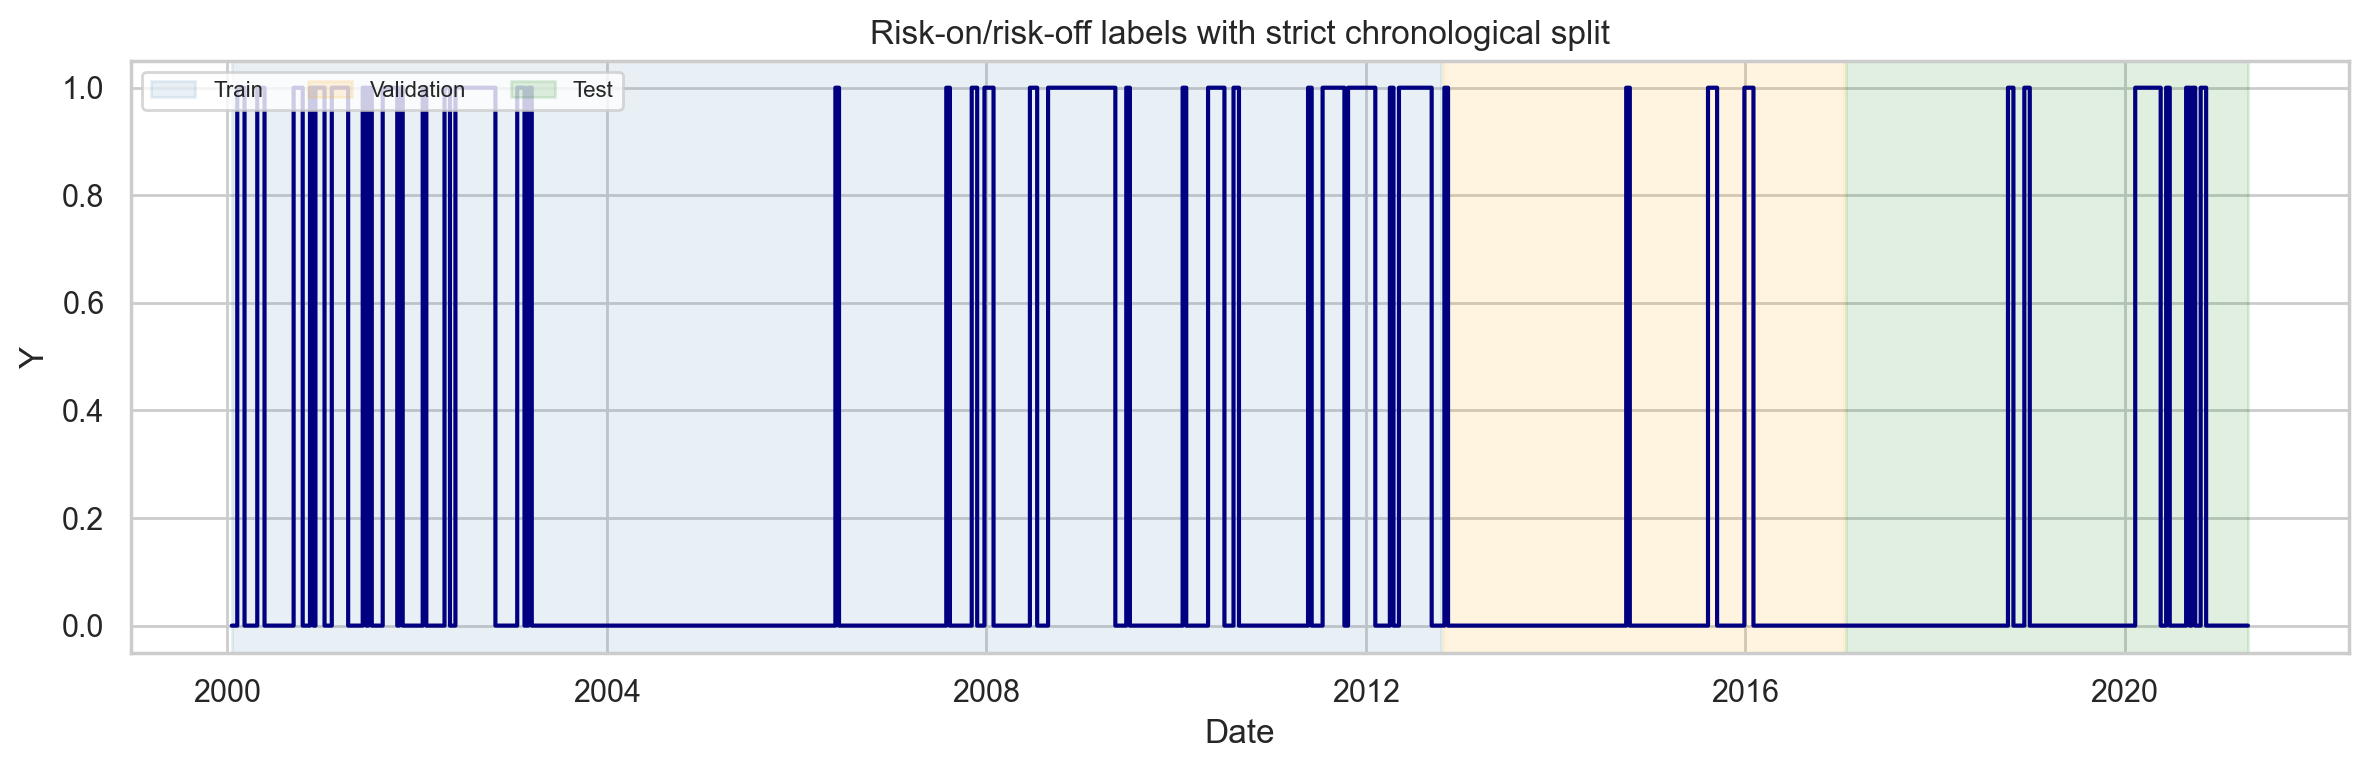

In [36]:
%config InlineBackend.figure_format = 'retina'

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = [10, 6]

FIGURE_DIR = Path("BC4/figures") if Path("BC4").is_dir() else Path("figures")
FIGURE_FORMATS = ("png", "pdf")


def safe_filename(name: str) -> str:
    slug = re.sub(r"[^a-z0-9]+", "_", str(name).lower()).strip("_")
    return slug or "figure"


def export_figure(fig, filename: str, dpi: int = 300):
    """Save a matplotlib figure as PNG and PDF with a stable notebook-local name."""
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    stem = safe_filename(filename)
    exported_paths = []
    for extension in FIGURE_FORMATS:
        output_path = FIGURE_DIR / f"{stem}.{extension}"
        save_kwargs = {"bbox_inches": "tight"}
        if extension == "png":
            save_kwargs["dpi"] = dpi
        fig.savefig(output_path, **save_kwargs)
        exported_paths.append(output_path)
    return exported_paths


dataset_path = Path("Dataset4_EWS.xlsx")
if not dataset_path.exists() and Path("BC4/Dataset4_EWS.xlsx").exists():
    dataset_path = Path("BC4/Dataset4_EWS.xlsx")

data_df = pd.read_excel(dataset_path, sheet_name="Markets")
metadata_df = pd.read_excel(dataset_path, sheet_name="Metadata")

date_col = "Date" if "Date" in data_df.columns else data_df.columns[0]
y_col = "Y" if "Y" in data_df.columns else None
if y_col is None:
    raise ValueError("Expected an anomaly label column named 'Y' in the Markets sheet.")

data_df[date_col] = pd.to_datetime(data_df[date_col], dayfirst=True)
data_df = data_df.set_index(date_col).sort_index()

X_df = data_df.drop(columns=[y_col])
y_raw = data_df[y_col].astype(int).values

indices_currencies = [col for col in X_df.columns if col in [
    "XAUBGNL", "BDIY", "CRY", "Cl1", "DXY", "EMUSTRUU", "GBP", "JPY", "LF94TRUU",
    "LF98TRUU", "LG30TRUU", "LMBITR", "LP01TREU", "LUACTRUU", "LUMSTRUU",
    "MXBR", "MXCN", "MXEU", "MXIN", "MXJP", "MXRU", "MXUS", "VIX"
]]

interest_rates = [col for col in X_df.columns if col in [
    "EONIA", "GTDEM10Y", "GTDEM2Y", "GTDEM30Y", "GTGBP20Y", "GTGBP2Y", "GTGBP30Y",
    "GTITL10YR", "GTITL2YR", "GTITL30YR", "GTJPY10YR", "GTJPY2YR", "GTJPY30YR",
    "US0001M", "USGG3M", "USGG2YR", "GT10", "USGG30YR"
]]

stationary_df = pd.DataFrame(index=X_df.index[1:])

for col in indices_currencies:
    stationary_df[col] = np.diff(np.log(X_df[col].astype(float)))

for col in interest_rates:
    stationary_df[col] = np.diff(X_df[col].astype(float))

if "ECSURPUS" in X_df.columns:
    stationary_df["ECSURPUS"] = X_df["ECSURPUS"].astype(float).values[1:]

y_stationary = y_raw[1:]
stationary_df = stationary_df.replace([np.inf, -np.inf], np.nan)
valid_mask = stationary_df.notna().all(axis=1)
stationary_df = stationary_df.loc[valid_mask]
y_stationary = y_stationary[valid_mask.to_numpy()].astype(int)
feature_names = stationary_df.columns.to_list()

X = stationary_df.values
y = y_stationary
dates = stationary_df.index  # DatetimeIndex, already chronologically sorted

# Strict chronological split (no shuffling): past -> validation -> recent test. The scaler
# and every model are fit on PAST normal observations only, so no future information leaks
# into training, threshold selection, or the risk-managed backtest.
train_slice, cv_slice, test_slice = chronological_split(len(X), train_ratio=0.60, cv_ratio=0.20)

train_normal_mask = y[train_slice] == 0
X_train_raw = X[train_slice][train_normal_mask]
train_dates = dates[train_slice][train_normal_mask]

X_cross_val_raw = X[cv_slice]
y_cross_val = y[cv_slice]
cv_dates = dates[cv_slice]

X_test_raw = X[test_slice]
y_test = y[test_slice]
test_dates = dates[test_slice]

if y_cross_val.sum() < 1 or y_test.sum() < 1:
    raise ValueError("Chronological split left a validation/test block with no anomalies; adjust the ratios.")

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_cross_val = scaler.transform(X_cross_val_raw)
X_test = scaler.transform(X_test_raw)

# Backward-compatible aliases for the grouped COPOD blocks below.
X_train_scaled = X_train
X_cv_scaled = X_cross_val
X_test_scaled = X_test

print(f"Dataset path: {dataset_path}")
print(f"Stationary feature matrix: {stationary_df.shape[0]} observations x {stationary_df.shape[1]} features")
print(f"Total anomalies after stationarity/dropna: {int(y.sum())} ({y.mean() * 100:.2f}%)")
print(f"Train window  : {train_dates.min():%Y-%m-%d} -> {train_dates.max():%Y-%m-%d} ({X_train.shape[0]} normal obs)")
print(f"Validation    : {cv_dates.min():%Y-%m-%d} -> {cv_dates.max():%Y-%m-%d} ({len(y_cross_val)} obs, {int(y_cross_val.sum())} anomalies)")
print(f"Test          : {test_dates.min():%Y-%m-%d} -> {test_dates.max():%Y-%m-%d} ({len(y_test)} obs, {int(y_test.sum())} anomalies)")
print(f"Anomaly base rate on test set: {y_test.mean() * 100:.2f}%")

fig = plt.figure(figsize=(12, 4))
plt.plot(stationary_df.index, y_stationary, drawstyle="steps-post", color="navy")
for blk, color, lbl in [(train_dates, "steelblue", "Train"), (cv_dates, "orange", "Validation"), (test_dates, "green", "Test")]:
    plt.axvspan(blk.min(), blk.max(), color=color, alpha=0.12, label=lbl)
plt.title("Risk-on/risk-off labels with strict chronological split")
plt.xlabel("Date")
plt.ylabel("Y")
plt.legend(loc="upper left", ncol=4, fontsize=8)
plt.tight_layout()
export_figure(fig, "copod_01_stationary_anomaly_labels")
plt.show()


def evaluate_model(y_true, y_pred, anomaly_score, model_name):
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    f2 = fbeta_score(y_true, y_pred, beta=2.0, zero_division=0)

    fpr, tpr, _ = roc_curve(y_true, anomaly_score)
    roc_auc = auc(fpr, tpr)
    pr_precision, pr_recall, _ = precision_recall_curve(y_true, anomaly_score)
    pr_auc = average_precision_score(y_true, anomaly_score)

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    baseline_rate = float(np.mean(y_true))

    print(f"\n{model_name}")
    print(f"Recall:       {recall:.4f}   <- crises caught")
    print(f"FNR:          {fnr:.4f}   <- crises missed (lower is better)")
    print(f"F2:           {f2:.4f}")
    print(f"PR-AUC:       {pr_auc:.4f}  (baseline = {baseline_rate:.4f})")
    print(f"Precision:    {precision:.4f}")
    print(f"F1:           {f1:.4f}")
    print(f"ROC-AUC:      {roc_auc:.4f}")

    fig_cm = plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Normal", "Anomaly"],
                yticklabels=["Normal", "Anomaly"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    export_figure(fig_cm, f"copod_02_confusion_matrix_{model_name}")
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title(f"ROC - {model_name}")
    axes[0].legend()

    axes[1].plot(pr_recall, pr_precision, label=f"PR-AUC = {pr_auc:.3f}")
    axes[1].axhline(baseline_rate, color="gray", linestyle="--", label=f"Baseline = {baseline_rate:.3f}")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title(f"Precision-Recall - {model_name}")
    axes[1].legend()
    plt.tight_layout()
    export_figure(fig, f"copod_03_roc_pr_{model_name}")
    plt.show()

    return {
        "model": model_name,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "f2": f2,
        "fnr": fnr,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
    }


def visualize_pca(X_eval, y_true, y_pred, title):
    pca = PCA(n_components=2, random_state=SEED)
    pca.fit(X_train)
    X_eval_pca = pca.transform(X_eval)

    fig, ax = plt.subplots(figsize=(8, 6))
    groups = [
        ((y_true == 0) & (y_pred == 0), "gray", 20, 0.5, "True Negative"),
        ((y_true == 1) & (y_pred == 1), "black", 35, 0.8, "True Positive"),
        ((y_true == 0) & (y_pred == 1), "orange", 45, 0.8, "False Positive"),
        ((y_true == 1) & (y_pred == 0), "magenta", 55, 0.8, "False Negative"),
    ]
    for mask, color, size, alpha, label in groups:
        ax.scatter(X_eval_pca[mask, 0], X_eval_pca[mask, 1],
                   c=color, s=size, alpha=alpha, label=label)
    ax.set_title(title)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")
    ax.legend(loc="best")
    plt.tight_layout()
    export_figure(fig, f"copod_04_pca_{title}")
    plt.show()


**Graph interpretation.**  
The COPOD label timeline uses a strict chronological split, with normal-market training data followed by validation and test windows. The test window has an anomaly base rate of 13.06%, which makes the out-of-sample evaluation stricter than a shuffled split.

The plot also confirms that abnormal labels remain clustered after the stationarity transform. This matters for COPOD because the model is learning normal empirical tail behaviour and then flagging future observations whose grouped market features move into unusually extreme regions.

The next block restructures 42 raw Bloomberg variables into 4 homogeneous asset families to eliminate feature dilution, which is a failure mode where an isolated shock (e.g., a credit freeze) gets statistically masked by normal noise in other sectors. Sub-models isolate independent tail anomalies within their specific economic domains, which are then stacked into a meta-feature matrix for a master COPOD engine to capture cross-asset risk propagation.

To turn the continuous meta-score into a decision boundary, we calibrate on the **train-normal score distribution**: candidate thresholds are high percentiles of the scores COPOD assigns to known-normal training weeks, so the false-alarm rate is *bounded by construction*. Among that bounded set, the validation set selects the most recall-favourable operating point using the recall-weighted F2.0 score:

$F_{2.0} = \dfrac{5 \times Precision \times Recall}{(4 \times Precision) + Recall}$

This keeps the recall-priority intent (capital preservation) while preventing the degenerate "flag every week" threshold that an unconstrained F-beta search selects on a weak score — a failure mode that a randomly shuffled, anomaly-rich test set can hide but that a strict chronological split exposes.


Amber threshold: 6.5270 (train-normal p80 -> 20.1% train false-alarm rate)
Best CV F-2.0 Score: 0.2247

COPOD (Asset Grouped F-2.0)
Recall:       0.4138   <- crises caught
FNR:          0.5862   <- crises missed (lower is better)
F2:           0.4054
PR-AUC:       0.4446  (baseline = 0.1306)
Precision:    0.3750
F1:           0.3934
ROC-AUC:      0.7293


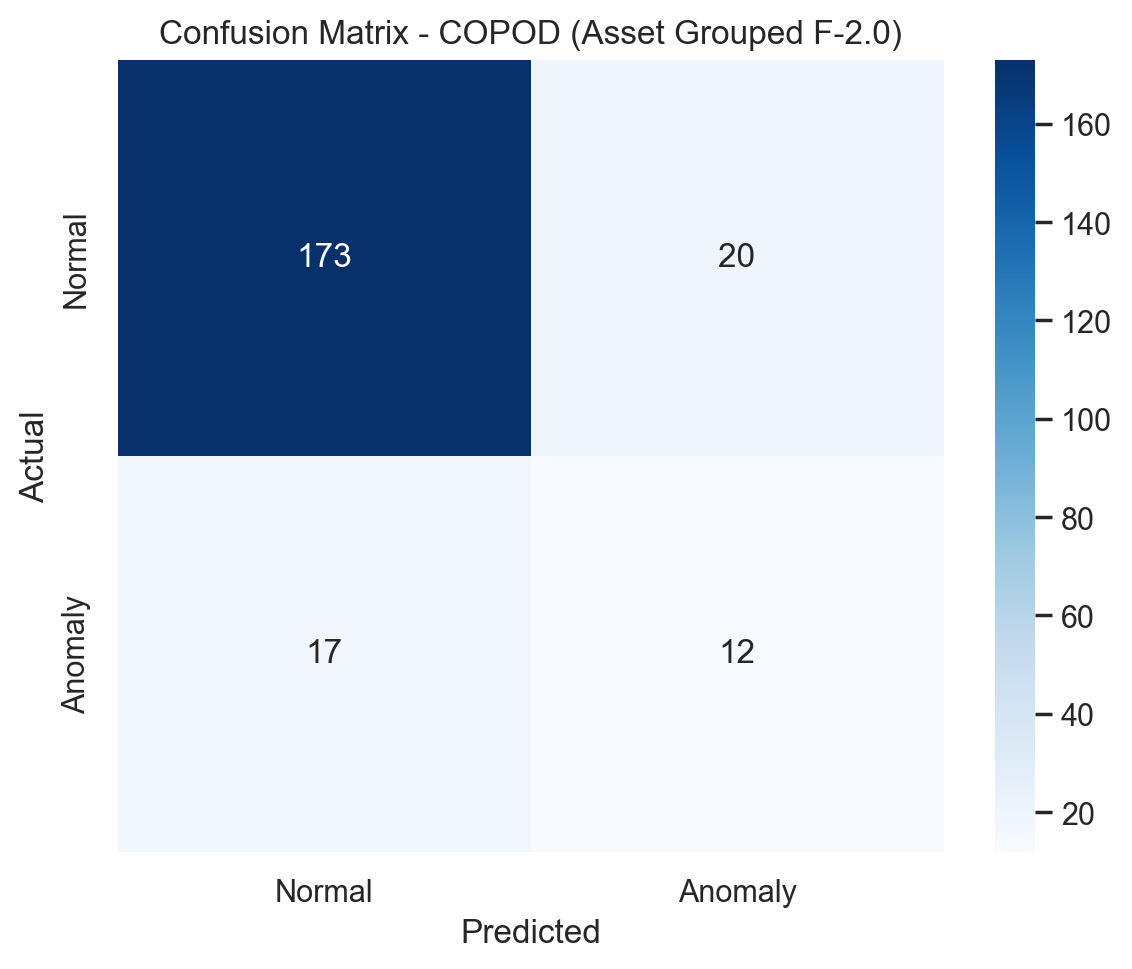

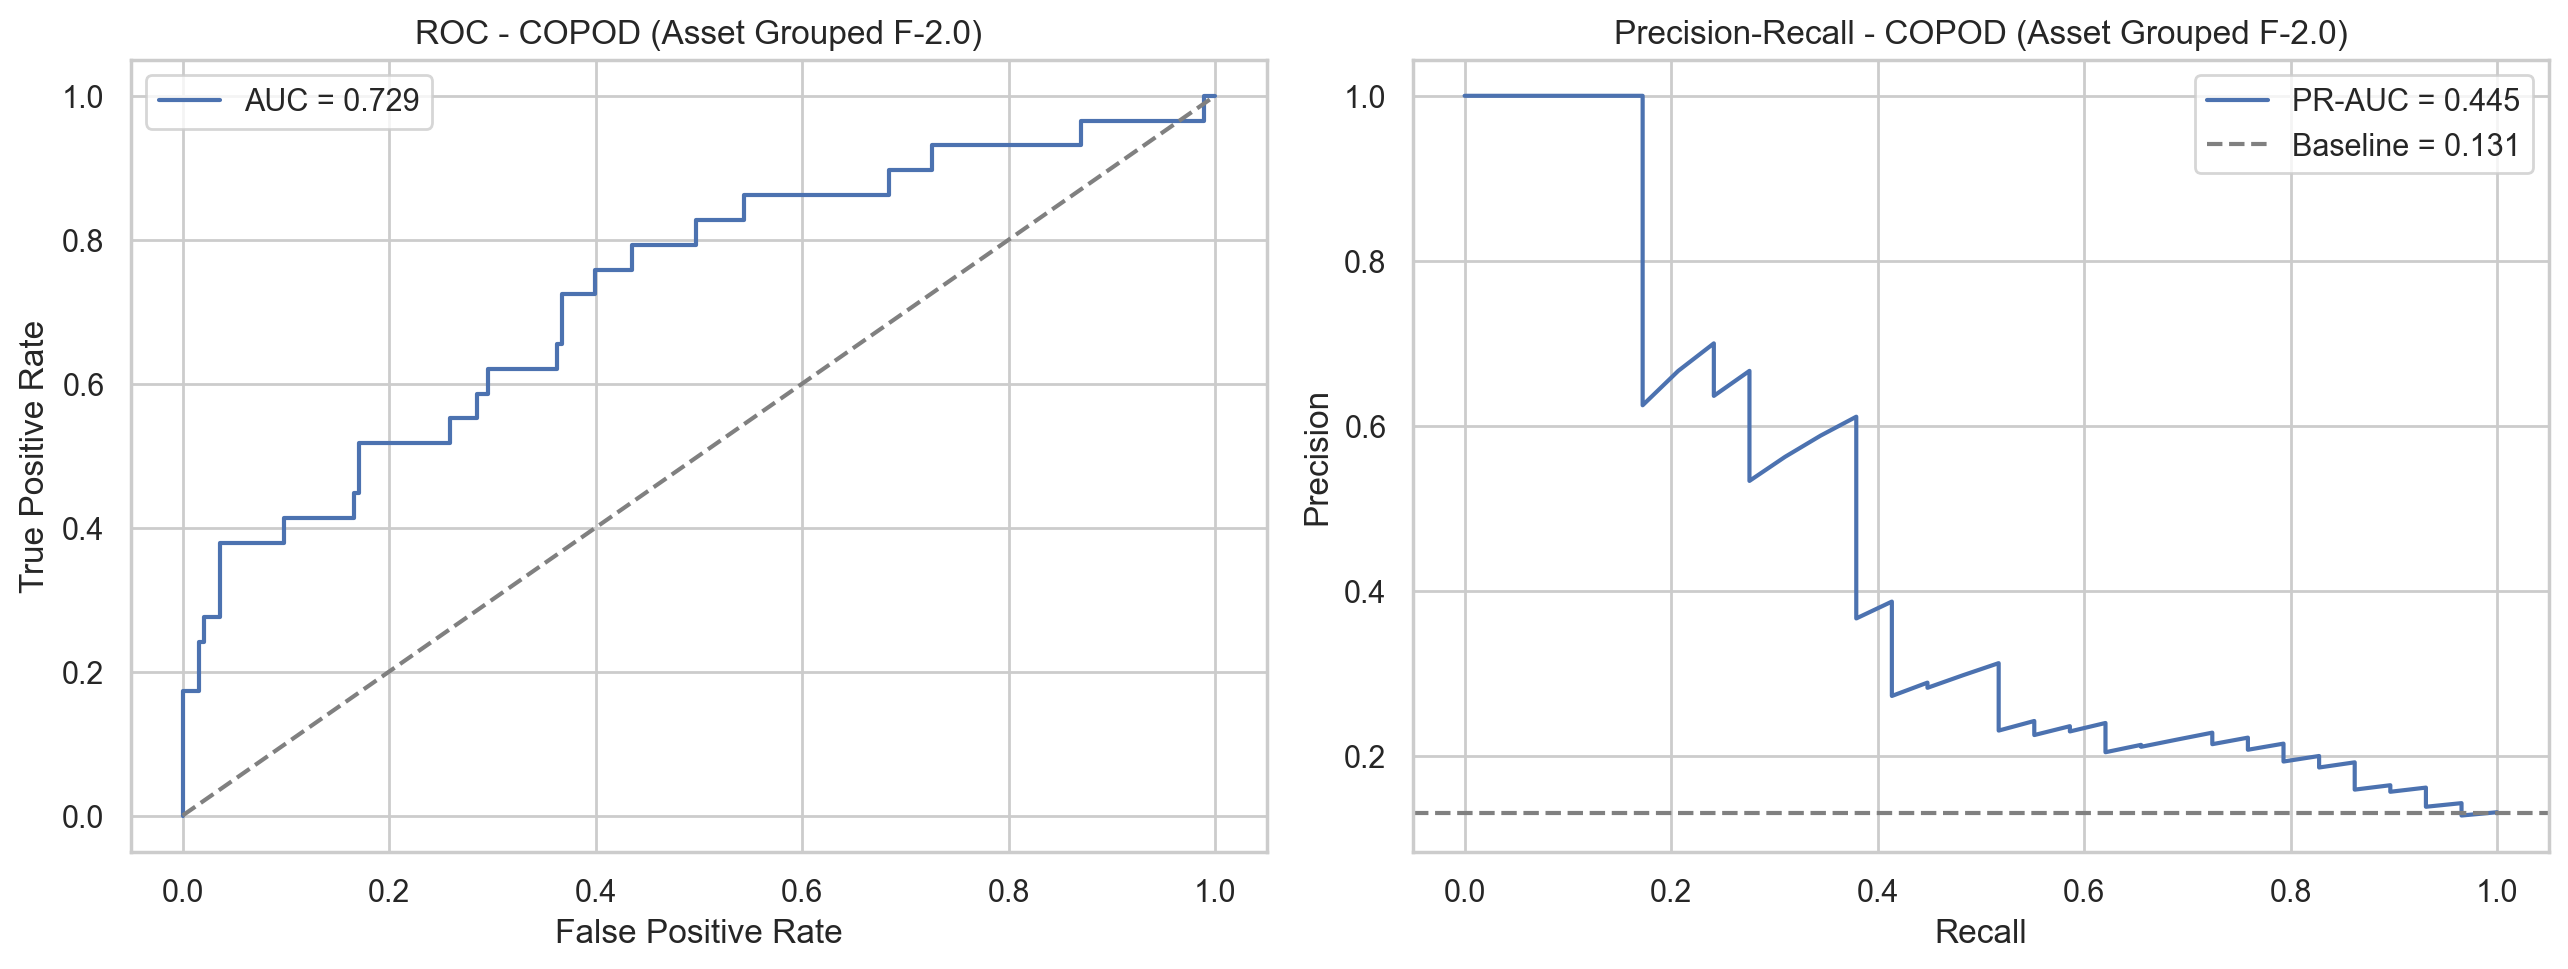

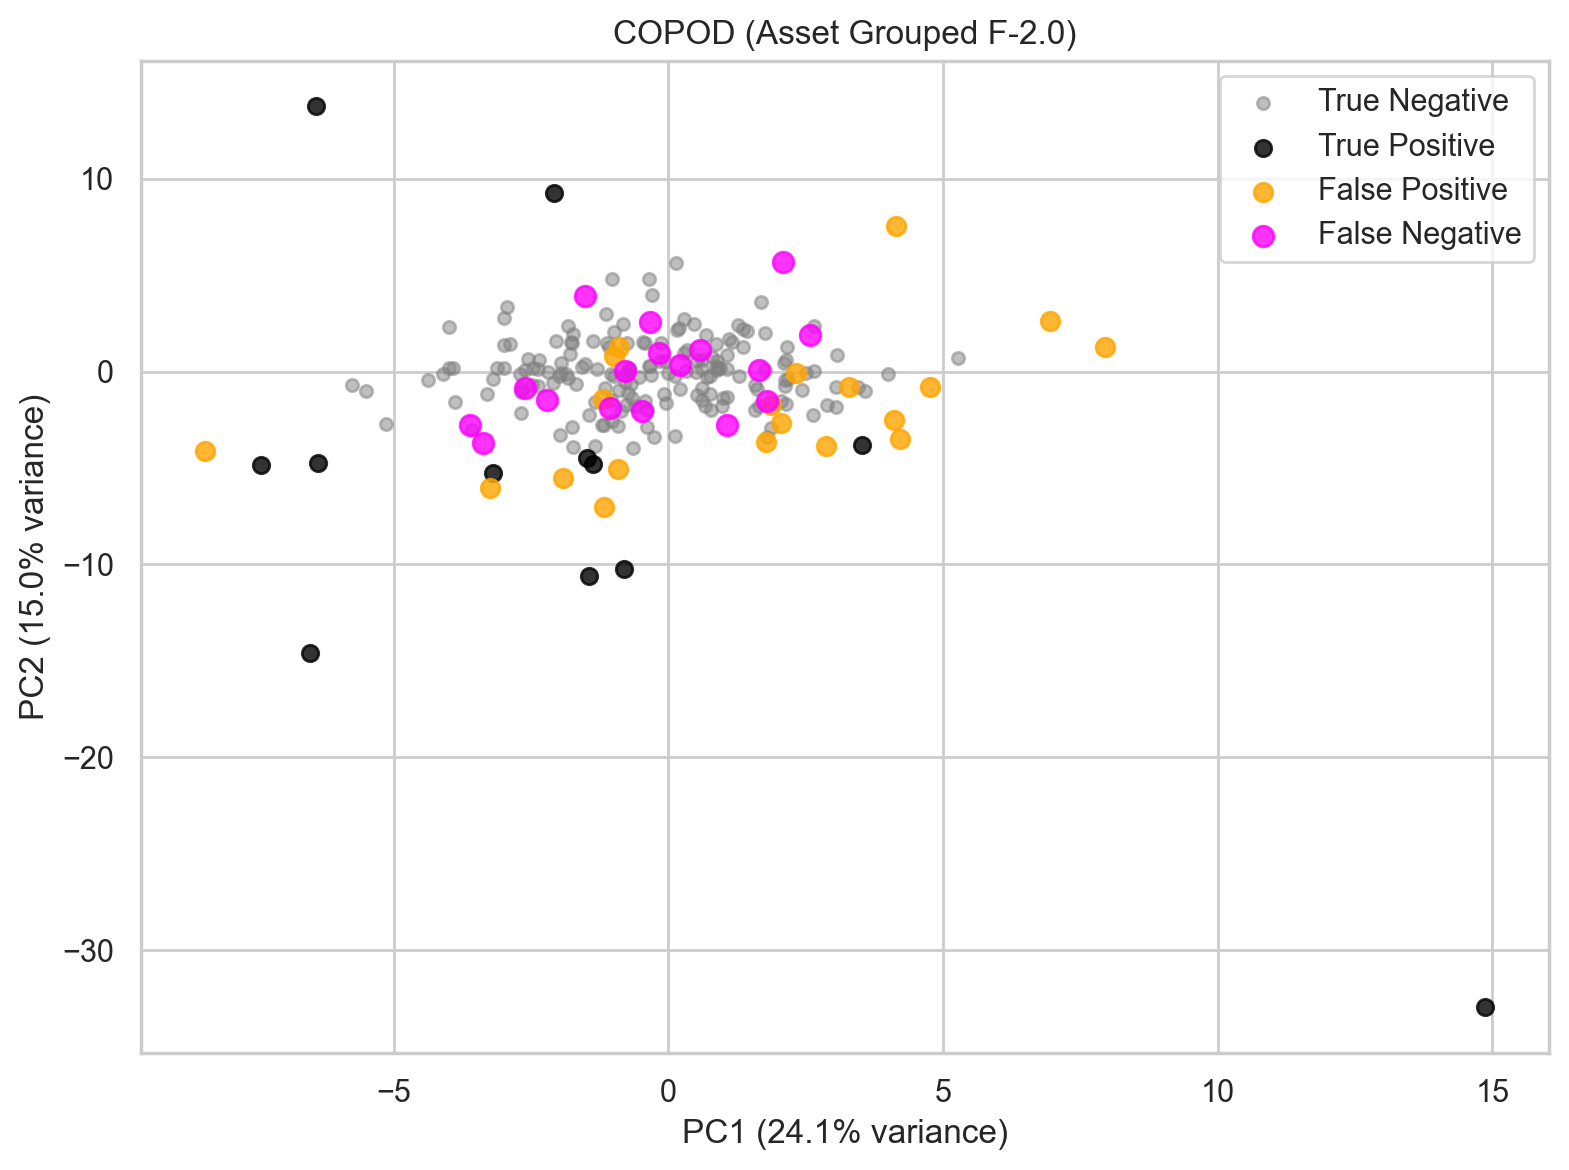

In [37]:
# BETA = 2 means we care twice as much about catching crises (Recall) than false alarms.
BETA_PARAM = 2.0

# Financial families used by the hierarchical COPOD stack.
groups = {
    "Macro_Volatility": ["VIX", "DXY", "ECSURPUS", "EONIA", "US0001M", "USGG3M", "GBP", "JPY"],
    "Fixed_Income": ["GT10", "GTDEM10Y", "GTDEM2Y", "GTDEM30Y", "GTGBP20Y", "GTGBP2Y",
                     "GTGBP30Y", "GTITL10YR", "GTITL2YR", "GTITL30YR", "GTJPY10YR",
                     "GTJPY2YR", "GTJPY30YR", "USGG2YR", "USGG30YR"],
    "Credit_Markets": ["EMUSTRUU", "LF94TRUU", "LF98TRUU", "LG30TRUU", "LMBITR", "LP01TREU",
                       "LUACTRUU", "LUMSTRUU"],
    "Equities_Comm": ["MXBR", "MXCN", "MXEU", "MXIN", "MXJP", "MXRU", "MXUS", "BDIY", "CRY", "Cl1", "XAUBGNL"],
}

available_groups = {
    name: [col for col in cols if col in feature_names]
    for name, cols in groups.items()
}
missing_group_features = {
    name: sorted(set(cols) - set(available_cols))
    for name, cols in groups.items()
    for available_cols in [available_groups[name]]
    if set(cols) - set(available_cols)
}
if missing_group_features:
    print("Missing grouped features skipped:")
    for name, missing_cols in missing_group_features.items():
        print(f" - {name}: {missing_cols}")

group_indices = {
    name: [feature_names.index(col) for col in cols]
    for name, cols in available_groups.items()
    if cols
}
if not group_indices:
    raise ValueError("No COPOD feature groups overlap with the prepared dataset columns.")

X_train_sub_train = []
X_train_sub_cv = []
X_train_sub_test = []
sub_models = {}

for name, indices in group_indices.items():
    sub_model = COPOD(contamination=0.1)
    sub_model.fit(X_train_scaled[:, indices])
    sub_models[name] = sub_model

    X_train_sub_train.append(sub_model.decision_function(X_train_scaled[:, indices]))
    X_train_sub_cv.append(sub_model.decision_function(X_cv_scaled[:, indices]))
    X_train_sub_test.append(sub_model.decision_function(X_test_scaled[:, indices]))

X_train_meta = np.column_stack(X_train_sub_train)
X_cv_meta = np.column_stack(X_train_sub_cv)
X_test_meta = np.column_stack(X_train_sub_test)

copod_model = COPOD(contamination=0.1)
copod_model.fit(X_train_meta)

# Calibrate the amber gate on the TRAIN-normal score distribution so the false-alarm rate
# is bounded by construction. An unconstrained F-beta argmax collapses to "flag everything"
# on a weak score; restricting candidates to high percentiles of the train-normal scores
# caps the false-positive rate while letting validation pick the most recall-favourable
# (still leak-free) operating point.
train_scores = copod_model.decision_function(X_train_meta)
cv_scores = copod_model.decision_function(X_cv_meta)

amber_percentile_grid = np.array([80.0, 85.0, 90.0, 95.0])
best_fbeta = -1.0
optimal_threshold = None
best_percentile = None
for q in amber_percentile_grid:
    candidate = float(np.percentile(train_scores, q))
    cv_fbeta = fbeta_score(
        y_cross_val, (cv_scores > candidate).astype(int),
        beta=BETA_PARAM, zero_division=0,
    )
    if cv_fbeta > best_fbeta:
        best_fbeta, optimal_threshold, best_percentile = cv_fbeta, candidate, q

train_fpr = float(np.mean(train_scores > optimal_threshold))
print(f"Amber threshold: {optimal_threshold:.4f} "
      f"(train-normal p{best_percentile:.0f} -> {train_fpr:.1%} train false-alarm rate)")
print(f"Best CV F-{BETA_PARAM} Score: {best_fbeta:.4f}")

copod_score = copod_model.decision_function(X_test_meta)
copod_pred = (copod_score > optimal_threshold).astype(int)

copod_metrics = evaluate_model(y_test, copod_pred, copod_score, f"COPOD (Asset Grouped F-{BETA_PARAM})")
visualize_pca(X_test_scaled, y_test, copod_pred, f"COPOD (Asset Grouped F-{BETA_PARAM})")
pd.DataFrame([copod_metrics])

copod_stationary_df = stationary_df.copy()
copod_scaler = scaler
copod_test_dates = pd.DatetimeIndex(test_dates)
copod_sub_models = sub_models
copod_group_indices = group_indices


**Graph interpretation.**  
The COPOD diagnostics show a moderate but not dominant early-warning signal. The confusion matrix indicates that the model catches 41.38% of test anomalies, while precision is 37.50%. This means the model detects some stress periods, but false alarms and missed crises remain material.

The ROC and precision-recall curves show that the continuous COPOD score has useful ranking power: PR-AUC is 0.4446 compared with a 0.1306 baseline, and ROC-AUC is 0.7293. The PCA panel adds context by showing that detected and missed observations overlap in a two-dimensional projection. Overall, COPOD contributes information, but its hard-threshold performance is weaker than the best Top-K Isolation Forest and deep-learning risk rules in this notebook.

The following block converts the continuous outlier score into actionable, discrete risk commands using a dual gate calibrated on the **train-normal** distribution (so both gates are leak-free and have bounded false-alarm rates):

* RED ALERT: Triggered by a strict 99th-percentile train-normal threshold (~1% false-alarm rate), capturing only the most severe systemic shocks that justify immediate, high-cost portfolio hedging.

* AMBER WARNING: The validation-selected percentile gate from the previous step, acting as an operational buffer zone to flag lower-intensity abnormalities for monitoring.

* GREEN REGIME: Normal market operations where scores fall below the warning criteria.

The accountability matrix below reports the realized distribution of these routes, the number of crises caught in each warning zone, and how many lower-severity false alarms are kept in the zero-cost monitoring bucket rather than escalated directly to portfolio hedging.


In [38]:
train_scores = copod_model.decision_function(X_train_meta)
cv_scores = copod_model.decision_function(X_cv_meta)
test_scores = copod_model.decision_function(X_test_meta)

# Dual gate calibrated on the train-normal score distribution (leak-free, bounded FPR):
#  - Amber = the validation-selected percentile gate from the block above.
#  - Red   = a far stricter 99th-percentile gate (~1% train false-alarm rate), reserved for
#            the most extreme shocks that justify immediate hedging.
amber_statistical_threshold = optimal_threshold
red_percentile = max(99.0, best_percentile)
red_statistical_threshold = float(np.percentile(train_scores, red_percentile))

print("Operational Calibration Gates Complete:")
print(f" -> Amber Warning Gate (train-normal p{best_percentile:.0f}) : {amber_statistical_threshold:.4f}")
print(f" -> Red Alert Gate (train-normal p{red_percentile:.0f})      : {red_statistical_threshold:.4f}")

final_routing = []

for score in test_scores:
    if score > red_statistical_threshold:
        final_routing.append("RED ALERT (Deploy Portfolio Hedges)")
    elif score > amber_statistical_threshold:
        final_routing.append("AMBER WARNING (Monitor Positions)")
    else:
        final_routing.append("GREEN (Normal Regime)")

operations_df = pd.DataFrame({
    "Date": pd.to_datetime(test_dates),
    "Actual_Crisis_Label": y_test,
    "COPOD_Score": test_scores,
    "Operational_Routing": final_routing,
})

print("\n" + "-" * 40)
print("RISK OPERATIONS ACCOUNTABILITY MATRIX")
print("-" * 40)
print(operations_df["Operational_Routing"].value_counts())

true_crises_red = operations_df[(operations_df["Actual_Crisis_Label"] == 1) &
                                 (operations_df["Operational_Routing"] == "RED ALERT (Deploy Portfolio Hedges)")].shape[0]

true_crises_amber = operations_df[(operations_df["Actual_Crisis_Label"] == 1) &
                                   (operations_df["Operational_Routing"] == "AMBER WARNING (Monitor Positions)")].shape[0]

true_crises_missed = operations_df[(operations_df["Actual_Crisis_Label"] == 1) &
                                    (operations_df["Operational_Routing"] == "GREEN (Normal Regime)")].shape[0]

false_alarms_defused = operations_df[(operations_df["Actual_Crisis_Label"] == 0) &
                                     (operations_df["Operational_Routing"] == "AMBER WARNING (Monitor Positions)")].shape[0]

total_f2_false_alarms = np.sum((test_scores > optimal_threshold) & (y_test == 0))

print(f"True Crises in RED ALERT Zone:     {true_crises_red}")
print(f"True Crises in AMBER WARNING Zone: {true_crises_amber}")
print(f"True Crises Completely Missed:     {true_crises_missed}")
print(f"False Alarms Successfully Defused: {false_alarms_defused} / {total_f2_false_alarms}")
# Total Caught Crises = RED ALERT + AMBER WARNING


Operational Calibration Gates Complete:
 -> Amber Warning Gate (train-normal p80) : 6.5270
 -> Red Alert Gate (train-normal p99)      : 13.2800

----------------------------------------
RISK OPERATIONS ACCOUNTABILITY MATRIX
----------------------------------------
Operational_Routing
GREEN (Normal Regime)                  190
AMBER WARNING (Monitor Positions)       27
RED ALERT (Deploy Portfolio Hedges)      5
Name: count, dtype: int64
True Crises in RED ALERT Zone:     5
True Crises in AMBER WARNING Zone: 7
True Crises Completely Missed:     17
False Alarms Successfully Defused: 20 / 20


## Part 3. Deep Learning Models

**Business case: risk management, not alpha generation.**

The deployment goal of this notebook is to **reduce portfolio drawdown** by raising a
defensive flag when the market starts behaving abnormally. A typical user is a CIO,
risk officer, or wealth manager who responds to the flag by rotating into cash,
short-term govies, gold, or other low-beta assets.

That framing drives several modelling choices that differ from a quant-alpha setup:

- **Cost asymmetry.** A missed crisis (false negative) compounds into a real drawdown.
  An unnecessary defensive reallocation (false positive) only costs opportunity. We
  therefore tune thresholds with **F-beta where beta = 2.0 (F2)**, which weights recall
  about four times more than precision -- the same F2 objective used by the Isolation Forest and COPOD detectors, so all five share one threshold-selection criterion.
- **Headline metrics.** Beyond precision/recall/F1 we track F2, the false-negative
  rate (FNR), and PR-AUC, because under heavy class imbalance the precision-recall
  curve is more informative than ROC.
- **Backtest diagnostic.** We simulate the risk-managed equity curve on the test rows
  (go to cash when the model fires) and report drawdown vs buy-and-hold MXUS. This
  is the metric that survives client conversations.

Four deep novelty detectors are compared under that lens:

- **GAN discriminator** anomaly score `1 - D_prob(x)`
- **GAN reconstruction** error after optimising z to match x
- **VAE reconstruction** error using the posterior mean
- **LSTM autoencoder** rolling-window reconstruction error

All detectors are trained on **normal observations only** and emit anomaly scores
(higher = more anomalous), so threshold selection and evaluation are uniform.


In [39]:
# Setup: reproducibility
%config InlineBackend.figure_format = 'retina'

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = [10, 6]

FIGURE_DIR = Path("BC4/figures") if Path("BC4").is_dir() else Path("figures")
FIGURE_FORMATS = ("png", "pdf")


def safe_filename(name: str) -> str:
    slug = re.sub(r"[^a-z0-9]+", "_", str(name).lower()).strip("_")
    return slug or "figure"


def export_figure(fig, filename: str, dpi: int = 300):
    """Save a matplotlib figure as PNG and PDF with a stable notebook-local name."""
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    stem = safe_filename(filename)
    exported_paths = []
    for extension in FIGURE_FORMATS:
        output_path = FIGURE_DIR / f"{stem}.{extension}"
        save_kwargs = {"bbox_inches": "tight"}
        if extension == "png":
            save_kwargs["dpi"] = dpi
        fig.savefig(output_path, **save_kwargs)
        exported_paths.append(output_path)
    return exported_paths

print(f"Using device: {device}")
print(f"Figures export to: {FIGURE_DIR}")


Using device: cpu
Figures export to: figures


### 1. Load and prepare the real BC4 market dataset

We use the same real dataset and stationarity logic as the original Early Warning System notebook:

- log-differences for indices, currencies, commodities, credit/bond total-return series, and volatility-like market variables
- first differences for interest rates
- unchanged Bloomberg Economic US Surprise Index, because it is already treated as stationary

For the risk-management framing we also retain the **date index** of each observation,
so that later we can run a drawdown-reduction backtest using `MXUS` as the equity benchmark.

The anomaly-detection split is a **strict chronological partition** (no shuffling), which
removes the look-ahead bias of a random split:

- training set: earliest 60% of the timeline, normal observations only
- cross-validation set: the next 20% of the timeline (all labels)
- test set: the most recent 20% of the timeline (all labels)


Dataset path: Dataset4_EWS.xlsx
Stationary feature matrix: 1110 observations x 42 features
Total anomalies after stationarity/dropna: 237 (21.35%)
Train window  : 2000-01-18 -> 2012-10-16 (472 normal obs)
Validation    : 2012-10-23 -> 2017-01-17 (222 obs, 14 anomalies)
Test          : 2017-01-24 -> 2021-04-20 (222 obs, 29 anomalies)
Anomaly base rate on test set: 13.06%


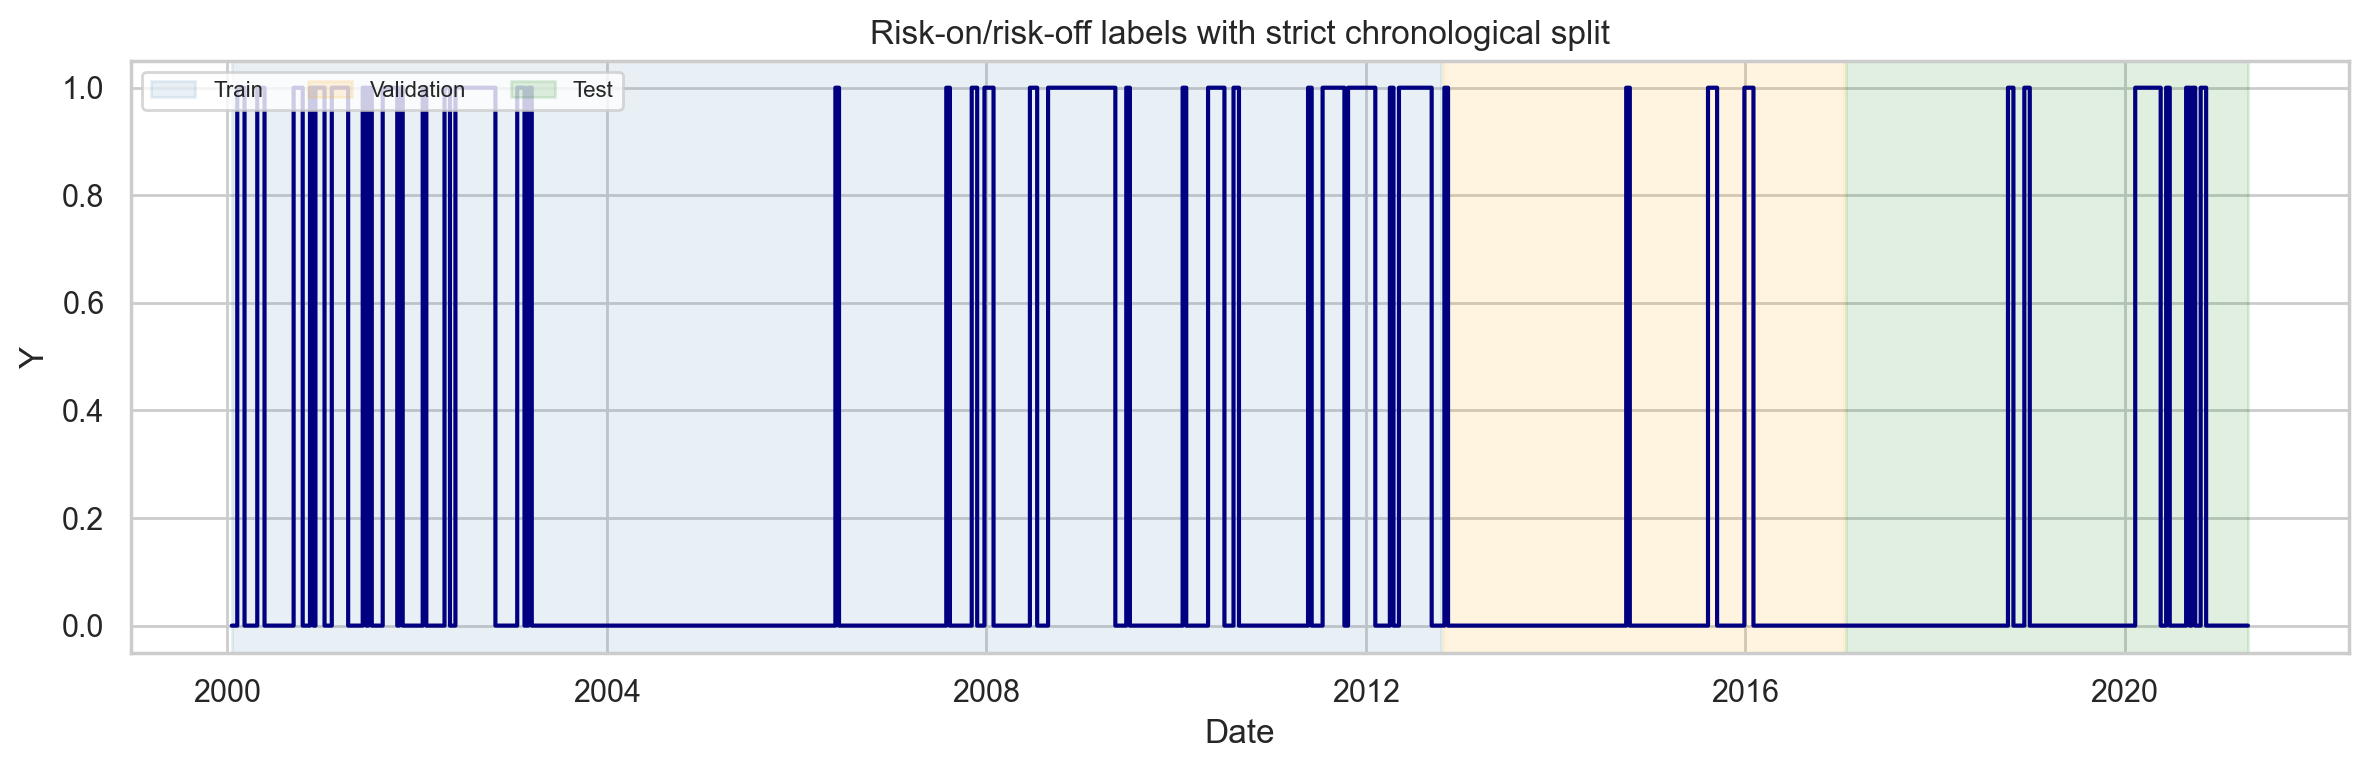

In [40]:
dataset_path = Path("Dataset4_EWS.xlsx")

data_df = pd.read_excel(dataset_path, sheet_name="Markets")
metadata_df = pd.read_excel(dataset_path, sheet_name="Metadata")

date_col = "Date" if "Date" in data_df.columns else data_df.columns[0]
y_col = "Y" if "Y" in data_df.columns else None
if y_col is None:
    raise ValueError("Expected an anomaly label column named 'Y' in the Markets sheet.")

data_df[date_col] = pd.to_datetime(data_df[date_col], dayfirst=True)
data_df = data_df.set_index(date_col).sort_index()

X_df = data_df.drop(columns=[y_col])
y_raw = data_df[y_col].astype(int).values

indices_currencies = [col for col in X_df.columns if col in [
    "XAUBGNL", "BDIY", "CRY", "Cl1", "DXY", "EMUSTRUU", "GBP", "JPY", "LF94TRUU",
    "LF98TRUU", "LG30TRUU", "LMBITR", "LP01TREU", "LUACTRUU", "LUMSTRUU",
    "MXBR", "MXCN", "MXEU", "MXIN", "MXJP", "MXRU", "MXUS", "VIX"
]]

interest_rates = [col for col in X_df.columns if col in [
    "EONIA", "GTDEM10Y", "GTDEM2Y", "GTDEM30Y", "GTGBP20Y", "GTGBP2Y", "GTGBP30Y",
    "GTITL10YR", "GTITL2YR", "GTITL30YR", "GTJPY10YR", "GTJPY2YR", "GTJPY30YR",
    "US0001M", "USGG3M", "USGG2YR", "GT10", "USGG30YR"
]]

stationary_df = pd.DataFrame(index=X_df.index[1:])

for col in indices_currencies:
    stationary_df[col] = np.diff(np.log(X_df[col].astype(float)))

for col in interest_rates:
    stationary_df[col] = np.diff(X_df[col].astype(float))

if "ECSURPUS" in X_df.columns:
    stationary_df["ECSURPUS"] = X_df["ECSURPUS"].astype(float).values[1:]

y_stationary = y_raw[1:]
stationary_df = stationary_df.replace([np.inf, -np.inf], np.nan)
valid_mask = stationary_df.notna().all(axis=1)
stationary_df = stationary_df.loc[valid_mask]
y_stationary = y_stationary[valid_mask.to_numpy()].astype(int)
feature_names = stationary_df.columns.to_list()

X = stationary_df.values
y = y_stationary
dates = stationary_df.index  # DatetimeIndex, already chronologically sorted; reused by the backtest

# Strict chronological split (no shuffling): past -> validation -> recent test. The scaler
# and every model are fit on PAST normal observations only, so no future information leaks
# into training, threshold selection, or the risk-managed backtest.
train_slice, cv_slice, test_slice = chronological_split(len(X), train_ratio=0.60, cv_ratio=0.20)

train_normal_mask = y[train_slice] == 0
X_train_raw = X[train_slice][train_normal_mask]
train_dates = dates[train_slice][train_normal_mask]

X_cross_val_raw = X[cv_slice]
y_cross_val = y[cv_slice]
cv_dates = dates[cv_slice]

X_test_raw = X[test_slice]
y_test = y[test_slice]
test_dates = dates[test_slice]

if y_cross_val.sum() < 1 or y_test.sum() < 1:
    raise ValueError("Chronological split left a validation/test block with no anomalies; adjust the ratios.")

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_cross_val = scaler.transform(X_cross_val_raw)
X_test = scaler.transform(X_test_raw)

print(f"Dataset path: {dataset_path}")
print(f"Stationary feature matrix: {stationary_df.shape[0]} observations x {stationary_df.shape[1]} features")
print(f"Total anomalies after stationarity/dropna: {int(y.sum())} ({y.mean() * 100:.2f}%)")
print(f"Train window  : {train_dates.min():%Y-%m-%d} -> {train_dates.max():%Y-%m-%d} ({X_train.shape[0]} normal obs)")
print(f"Validation    : {cv_dates.min():%Y-%m-%d} -> {cv_dates.max():%Y-%m-%d} ({len(y_cross_val)} obs, {int(y_cross_val.sum())} anomalies)")
print(f"Test          : {test_dates.min():%Y-%m-%d} -> {test_dates.max():%Y-%m-%d} ({len(y_test)} obs, {int(y_test.sum())} anomalies)")
print(f"Anomaly base rate on test set: {y_test.mean() * 100:.2f}%")

fig = plt.figure(figsize=(12, 4))
plt.plot(stationary_df.index, y_stationary, drawstyle="steps-post", color="navy")
for blk, color, lbl in [(train_dates, "steelblue", "Train"), (cv_dates, "orange", "Validation"), (test_dates, "green", "Test")]:
    plt.axvspan(blk.min(), blk.max(), color=color, alpha=0.12, label=lbl)
plt.title("Risk-on/risk-off labels with strict chronological split")
plt.xlabel("Date")
plt.ylabel("Y")
plt.legend(loc="upper left", ncol=4, fontsize=8)
plt.tight_layout()
export_figure(fig, "01_stationary_anomaly_labels")
plt.show()


**Graph interpretation.**  
The deep-learning split plot confirms that GAN, VAE, and LSTM models use the same stationary 42-feature market panel under a chronological design. The training window contains normal observations for representation learning, while validation and test include abnormal regimes used for calibration and final assessment.

The test anomaly base rate is 13.06%, so the deep-learning detectors are evaluated under a realistic future-period setting. This is important because reconstruction models can look stronger under shuffled splits; the chronological split tests whether learned normal-market structure transfers to later market regimes.

### 2. Define the GAN

The discriminator returns a **logit**, not a probability. During training we use `BCEWithLogitsLoss`, which is numerically more stable than applying a sigmoid first. During scoring we convert logits to probabilities with `torch.sigmoid`.

The generator maps a latent noise vector `z` into a synthetic normal market sample.


In [41]:
# GAN architecture
input_dim = X_train.shape[1]
latent_dim = min(16, max(4, input_dim // 4))
hidden_dim = min(128, max(32, input_dim * 2))
batch_size = min(128, max(16, len(X_train) // 10))

train_tensor = torch.tensor(X_train, dtype=torch.float32)
train_loader = DataLoader(TensorDataset(train_tensor), batch_size=batch_size, shuffle=True)

class Generator(nn.Module):
    def __init__(self, latent_dim: int, output_dim: int, hidden_dim: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(hidden_dim),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

G = Generator(latent_dim, input_dim, hidden_dim).to(device)
D = Discriminator(input_dim, hidden_dim).to(device)

criterion = nn.BCEWithLogitsLoss()
g_optimizer = optim.Adam(G.parameters(), lr=1e-3, betas=(0.5, 0.999))
d_optimizer = optim.Adam(D.parameters(), lr=1e-3, betas=(0.5, 0.999))

print(f"Input dimension: {input_dim} | latent: {latent_dim} | hidden: {hidden_dim} | batch: {batch_size}")
print(G)
print(D)


Input dimension: 42 | latent: 10 | hidden: 84 | batch: 47
Generator(
  (net): Sequential(
    (0): Linear(in_features=10, out_features=84, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): BatchNorm1d(84, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Linear(in_features=84, out_features=84, bias=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): BatchNorm1d(84, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Linear(in_features=84, out_features=42, bias=True)
  )
)
Discriminator(
  (net): Sequential(
    (0): Linear(in_features=42, out_features=84, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=84, out_features=84, bias=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=84, out_features=1, bias=True)
  )
)


### 3. Train on normal market samples only

The discriminator sees:

- real normal observations from the training set
- generated normal-like observations from the generator

The generator learns to produce samples that the discriminator classifies as real normal data.


Epoch 001 | D loss=1.3665 | G loss=0.6318
Epoch 050 | D loss=1.3872 | G loss=0.7010
Epoch 100 | D loss=1.3725 | G loss=0.7072
Epoch 150 | D loss=1.3715 | G loss=0.7024
Epoch 200 | D loss=1.3693 | G loss=0.7242
Epoch 250 | D loss=1.3445 | G loss=0.7113
Epoch 300 | D loss=1.3324 | G loss=0.7178


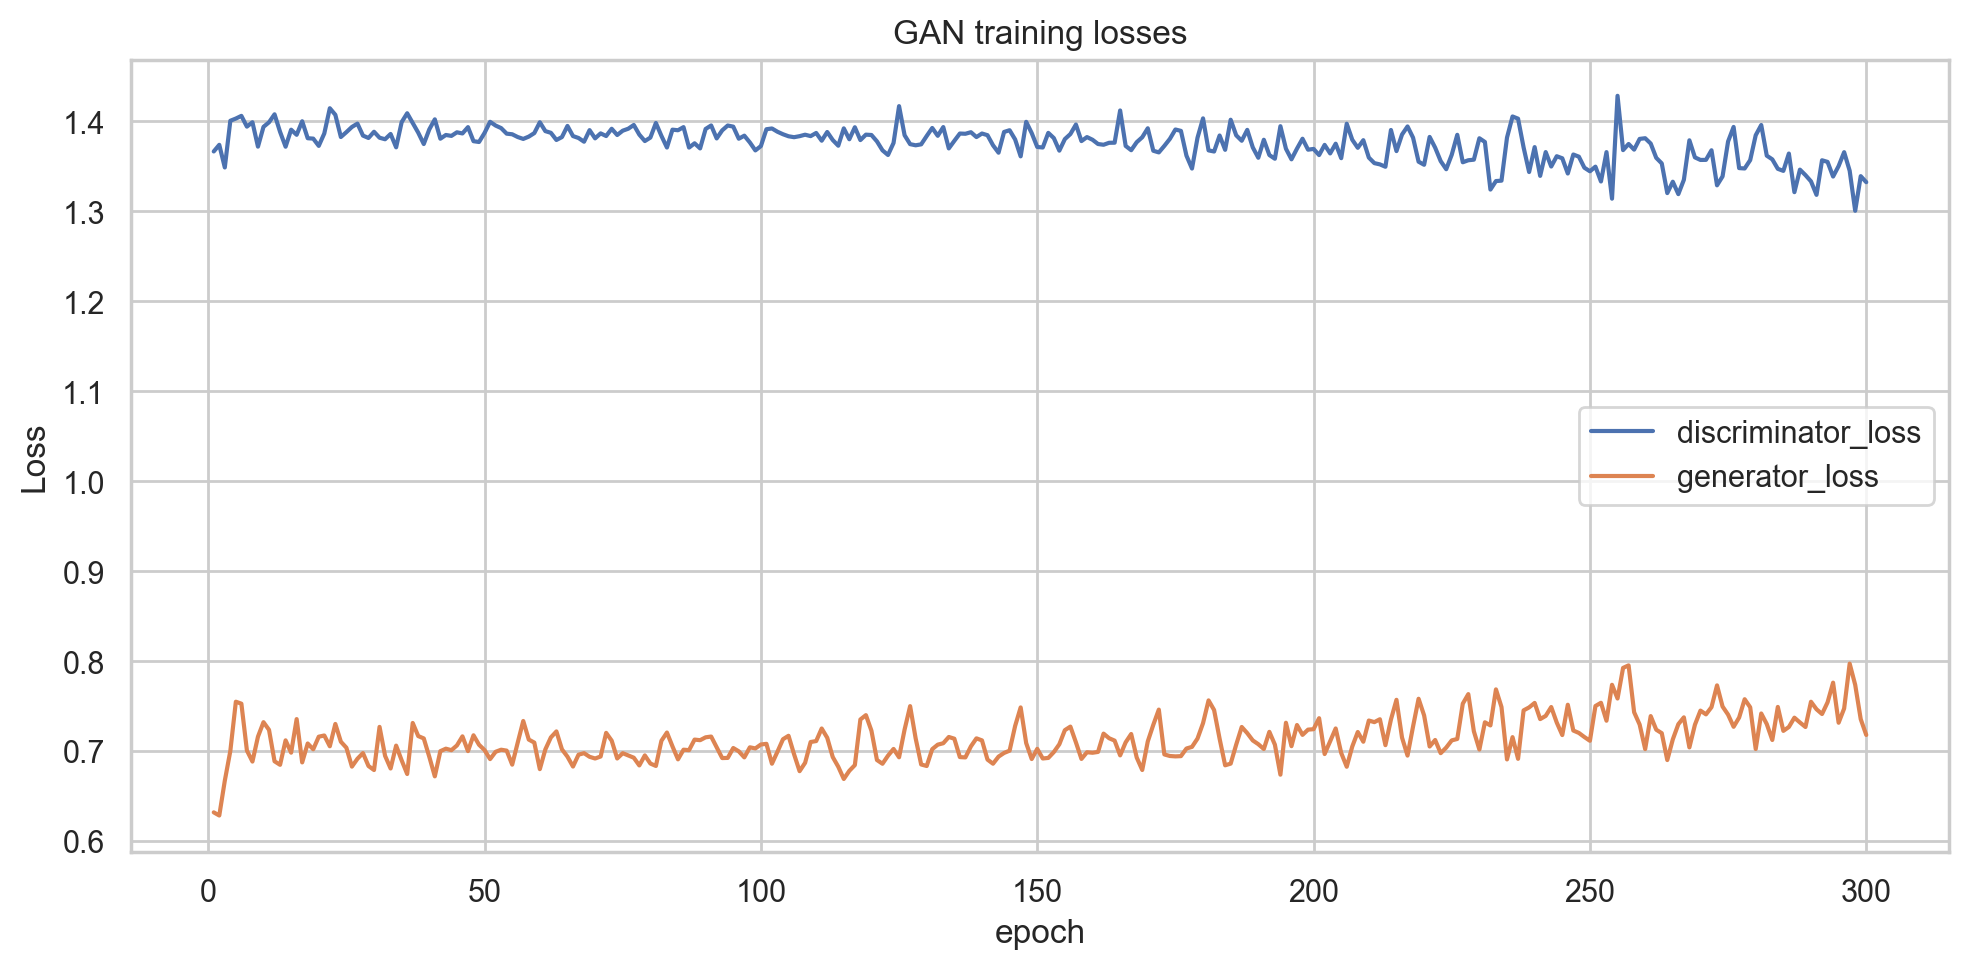

In [42]:
def train_gan(generator, discriminator, loader, epochs=300, print_every=50):
    history = []
    generator.train()
    discriminator.train()

    for epoch in range(1, epochs + 1):
        epoch_d_loss = 0.0
        epoch_g_loss = 0.0

        for (real_batch,) in loader:
            real_batch = real_batch.to(device)
            current_batch_size = real_batch.size(0)

            real_labels = torch.ones(current_batch_size, device=device)
            fake_labels = torch.zeros(current_batch_size, device=device)

            # 1. Train discriminator: real normal samples should be real, generated samples should be fake.
            z = torch.randn(current_batch_size, latent_dim, device=device)
            fake_batch = generator(z).detach()

            d_optimizer.zero_grad()
            real_logits = discriminator(real_batch)
            fake_logits = discriminator(fake_batch)
            d_loss = criterion(real_logits, real_labels) + criterion(fake_logits, fake_labels)
            d_loss.backward()
            d_optimizer.step()

            # 2. Train generator: generated samples should look real to the discriminator.
            z = torch.randn(current_batch_size, latent_dim, device=device)
            g_optimizer.zero_grad()
            generated_batch = generator(z)
            generated_logits = discriminator(generated_batch)
            g_loss = criterion(generated_logits, real_labels)
            g_loss.backward()
            g_optimizer.step()

            epoch_d_loss += d_loss.item()
            epoch_g_loss += g_loss.item()

        avg_d_loss = epoch_d_loss / len(loader)
        avg_g_loss = epoch_g_loss / len(loader)
        history.append({"epoch": epoch, "discriminator_loss": avg_d_loss, "generator_loss": avg_g_loss})

        if epoch == 1 or epoch % print_every == 0:
            print(f"Epoch {epoch:03d} | D loss={avg_d_loss:.4f} | G loss={avg_g_loss:.4f}")

    return pd.DataFrame(history)

history = train_gan(G, D, train_loader, epochs=300, print_every=50)

ax = history.plot(x="epoch", y=["discriminator_loss", "generator_loss"], figsize=(10, 5))
plt.title("GAN training losses")
plt.ylabel("Loss")
plt.tight_layout()
export_figure(ax.get_figure(), "04_gan_training_losses")
plt.show()

**Graph interpretation.**  
The GAN training-loss plot shows discriminator and generator losses over 300 epochs. The losses remain bounded and do not explode, suggesting that adversarial optimization was numerically stable. The discriminator loss gradually moves but does not collapse, and the generator loss remains in a plausible range.

This chart only verifies training stability. It does not prove that the GAN is useful for crisis detection. The real evaluation comes afterward, where discriminator realism and reconstruction error are separately tested against abnormal-market labels.

### 4. Score anomalies with discriminator realism

The discriminator anomaly score is `1 - D_prob(x)`. The risk-on/risk-off decision is:

$$
\text{Defensive reallocation} \Longleftrightarrow 1 - D_{prob}(x) > \varepsilon
$$

Threshold selection is **F-beta with beta = 2.0 (F2) subject to a precision floor** of
`min(0.7, base_rate + 0.25)`. Two safeguards matter on imbalanced labels:

- The floor demands a real **lift over baseline** (at least +25pp of precision) rather
  than a fixed absolute number, because the CV set has a much higher anomaly rate than
  the underlying market and a fixed 0.3 floor would barely bind.
- If no threshold meets the floor, the detector is declared **unfit to fire**: we set
  `epsilon` above the score maximum so no row is ever flagged. Better to stay in the
  market than deploy a model that fires indiscriminately.


In [43]:
def discriminator_anomaly_score(discriminator, X):
    """Return 1 - D(x): higher means the observation looks less like real normal data."""
    discriminator.eval()
    X_tensor = torch.tensor(X, dtype=torch.float32, device=device)
    with torch.no_grad():
        logits = discriminator(X_tensor)
        probabilities = torch.sigmoid(logits).cpu().numpy()
    return 1.0 - probabilities


RISK_BETA = 2.0  # F2: recall weighted 4x precision, unified with Isolation Forest and COPOD.


def choose_anomaly_threshold(y_true, anomaly_score, beta=RISK_BETA, precision_floor=None, n_grid=1000):
    """Maximise F-beta on the CV set subject to precision >= floor.

    Default floor = min(0.7, base_rate + 0.25). Demanding a fixed lift over baseline
    blocks the degenerate "fire on everything" attractor whose precision otherwise
    sits at base rate. If no threshold passes the floor, the detector is declared
    unfit to fire (epsilon set above the score maximum), so it stays passive rather
    than triggering on every observation.
    """
    base_rate = float(np.mean(y_true))
    if precision_floor is None:
        precision_floor = float(min(0.7, base_rate + 0.25))

    thresholds = np.linspace(anomaly_score.min(), anomaly_score.max(), n_grid)
    best = None
    for epsilon in thresholds:
        pred = (anomaly_score > epsilon).astype(int)
        precision = precision_score(y_true, pred, zero_division=0)
        if precision < precision_floor:
            continue
        fbeta = fbeta_score(y_true, pred, beta=beta, zero_division=0)
        if best is None or fbeta > best["fbeta"]:
            best = {
                "epsilon": float(epsilon),
                "fbeta": float(fbeta),
                "f1": float(f1_score(y_true, pred, zero_division=0)),
                "precision": float(precision),
                "recall": float(recall_score(y_true, pred, zero_division=0)),
            }

    if best is None:
        # No threshold met the floor -> detector is unfit. Set epsilon above the
        # score maximum so the model never fires; the user gets a clear "never_fires"
        # flag to surface this in the comparison table.
        best = {
            "epsilon": float(anomaly_score.max() + 1.0),
            "fbeta": 0.0,
            "f1": 0.0,
            "precision": 0.0,
            "recall": 0.0,
            "never_fires": True,
        }
    else:
        best["never_fires"] = False

    best["precision_floor"] = precision_floor
    best["base_rate"] = base_rate
    best["lift"] = best["precision"] / base_rate if base_rate > 0 else 0.0
    return best


cv_realism = discriminator_anomaly_score(D, X_cross_val)
test_realism = discriminator_anomaly_score(D, X_test)

realism_threshold = choose_anomaly_threshold(y_cross_val, cv_realism)
y_pred_realism = (test_realism > realism_threshold["epsilon"]).astype(int)

realism_threshold


{'epsilon': 1.740944743156433,
 'fbeta': 0.0,
 'f1': 0.0,
 'precision': 0.0,
 'recall': 0.0,
 'never_fires': True,
 'precision_floor': 0.3130630630630631,
 'base_rate': 0.06306306306306306,
 'lift': 0.0}

### 5. Score anomalies with GAN reconstruction

A plain GAN has no encoder, so we cannot directly map an input `x` into a latent vector. For reconstruction scoring, we search for the latent vector `z*` whose generated sample is closest to `x`:

$$
z^* = \arg\min_z \|x - G(z)\|^2
$$

Then the anomaly score is the reconstruction error:

$$
\text{Anomaly} \Longleftrightarrow \|x - G(z^*)\|^2 > \varepsilon
$$

This is slower than discriminator scoring, but it is closer to the Autoencoder logic used in the original notebook.


In [44]:
def gan_reconstruction_error(generator, X, latent_dim, steps=250, lr=0.05, batch_size=128):
    """Optimise z to reconstruct each batch, then return per-sample reconstruction MSE."""
    generator.eval()
    errors = []

    for start in range(0, len(X), batch_size):
        batch_np = X[start:start + batch_size]
        x = torch.tensor(batch_np, dtype=torch.float32, device=device)
        z = torch.randn(x.size(0), latent_dim, device=device, requires_grad=True)
        z_optimizer = optim.Adam([z], lr=lr)

        for _ in range(steps):
            z_optimizer.zero_grad()
            reconstructed = generator(z)
            # Per-sample MSE summed across the batch keeps each row's gradient independent of batch size.
            loss = ((reconstructed - x) ** 2).mean(dim=1).sum()
            loss.backward()
            z_optimizer.step()

        with torch.no_grad():
            reconstructed = generator(z)
            batch_errors = ((reconstructed - x) ** 2).mean(dim=1).cpu().numpy()
            errors.extend(batch_errors)

    return np.array(errors)


cv_reconstruction_error = gan_reconstruction_error(G, X_cross_val, latent_dim, steps=250)
test_reconstruction_error = gan_reconstruction_error(G, X_test, latent_dim, steps=250)

reconstruction_threshold = choose_anomaly_threshold(y_cross_val, cv_reconstruction_error)
y_pred_reconstruction = (test_reconstruction_error > reconstruction_threshold["epsilon"]).astype(int)

reconstruction_threshold


{'epsilon': 2.523648977279663,
 'fbeta': 0.08771929824561403,
 'f1': 0.13333333333333333,
 'precision': 1.0,
 'recall': 0.07142857142857142,
 'never_fires': False,
 'precision_floor': 0.3130630630630631,
 'base_rate': 0.06306306306306306,
 'lift': 15.85714285714286}

### 6. Evaluate the two GAN anomaly scores

Headline metrics for the risk-management user:

- **Recall** -- fraction of real anomalies the model would catch.
- **F2** -- the threshold-selection objective itself.
- **False-negative rate (FNR)** -- missed crises per real crisis.
- **PR-AUC** (average precision) -- threshold-free summary that is more meaningful than
  ROC-AUC under heavy class imbalance.
- Precision, F1, ROC-AUC are reported for completeness but are not the primary lens.



GAN discriminator realism score
Recall:       0.0000   <- crises caught
FNR:          1.0000   <- crises missed (lower is better)
F2:           0.0000
PR-AUC:       0.2253  (baseline = 0.1306)
Precision:    0.0000
F1:           0.0000
ROC-AUC:      0.4184


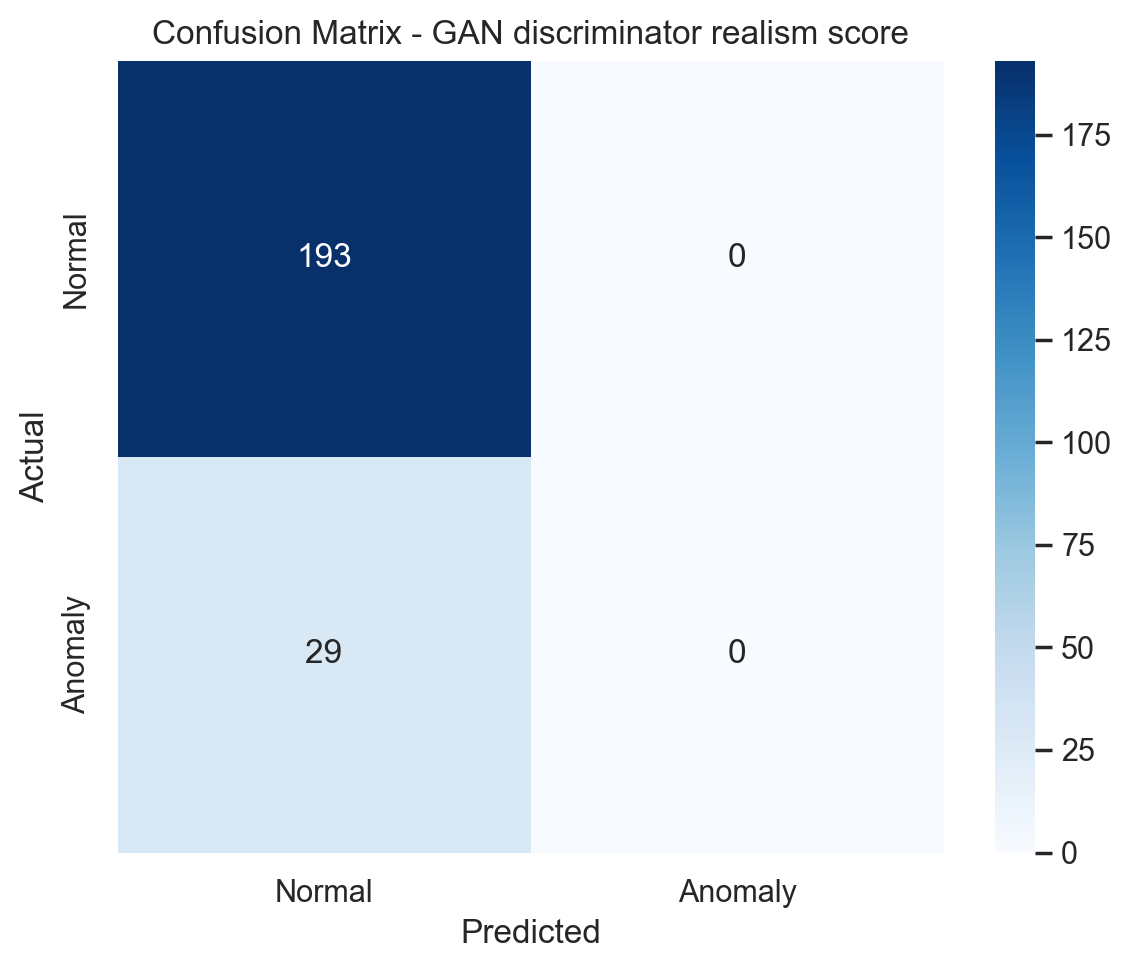

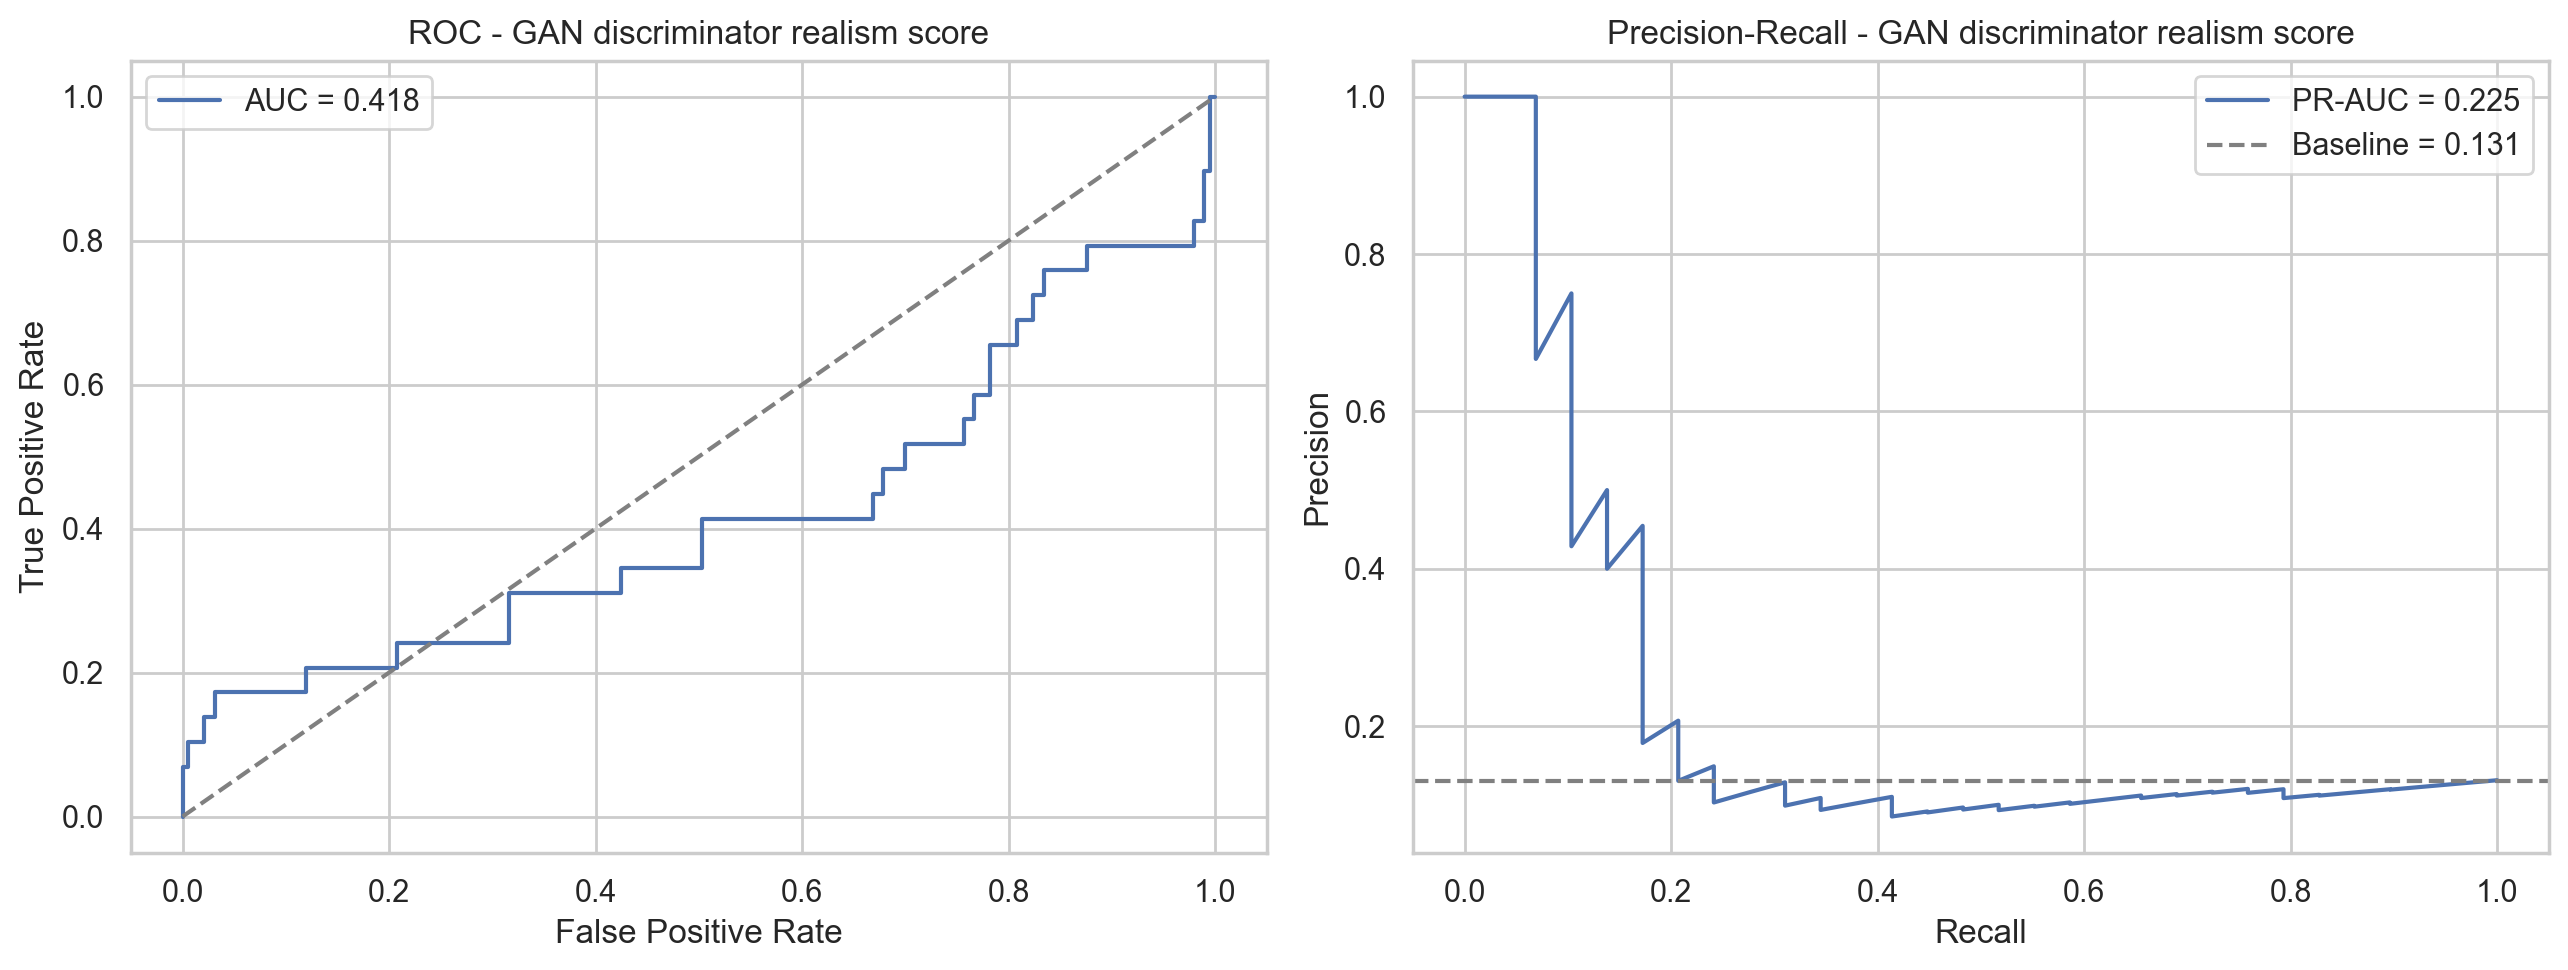


GAN reconstruction score
Recall:       0.2414   <- crises caught
FNR:          0.7586   <- crises missed (lower is better)
F2:           0.2800
PR-AUC:       0.4933  (baseline = 0.1306)
Precision:    0.7778
F1:           0.3684
ROC-AUC:      0.7808


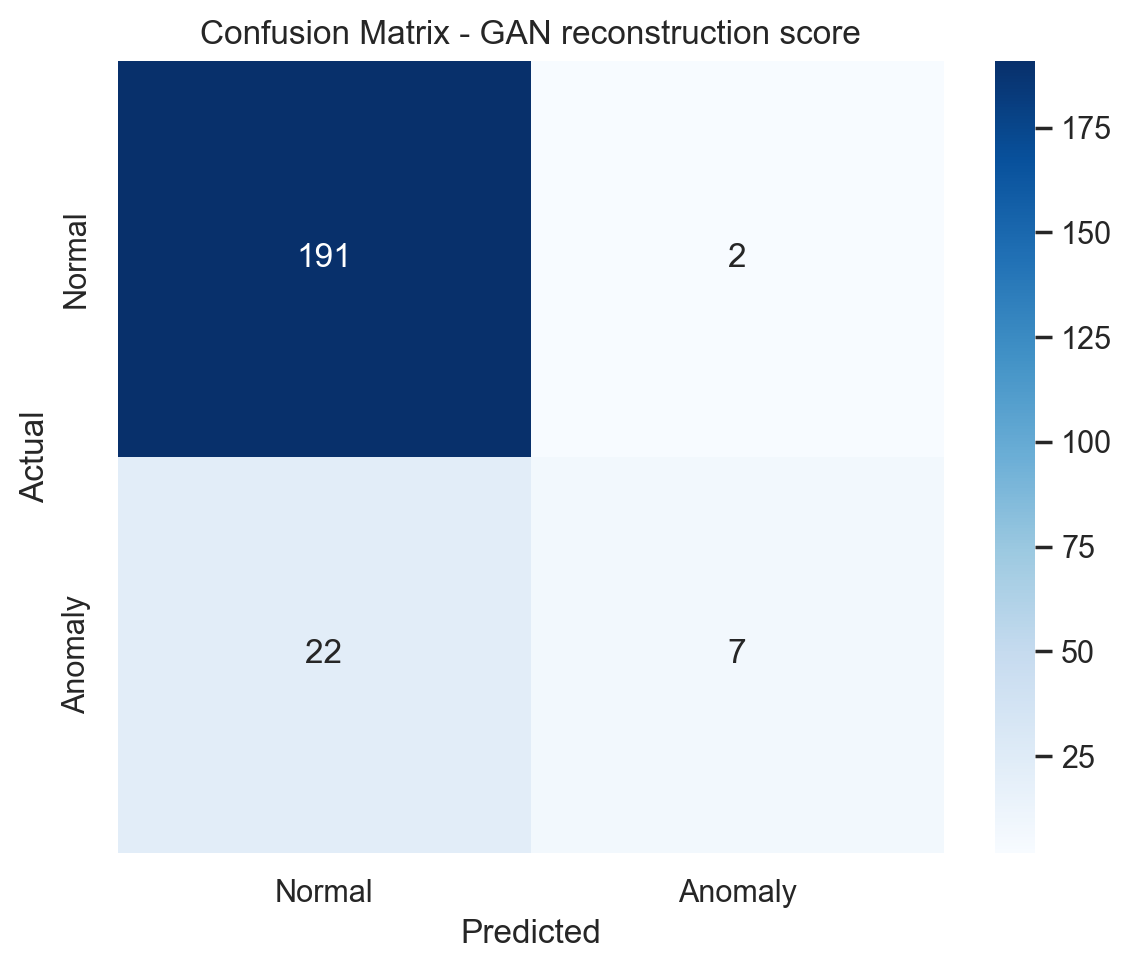

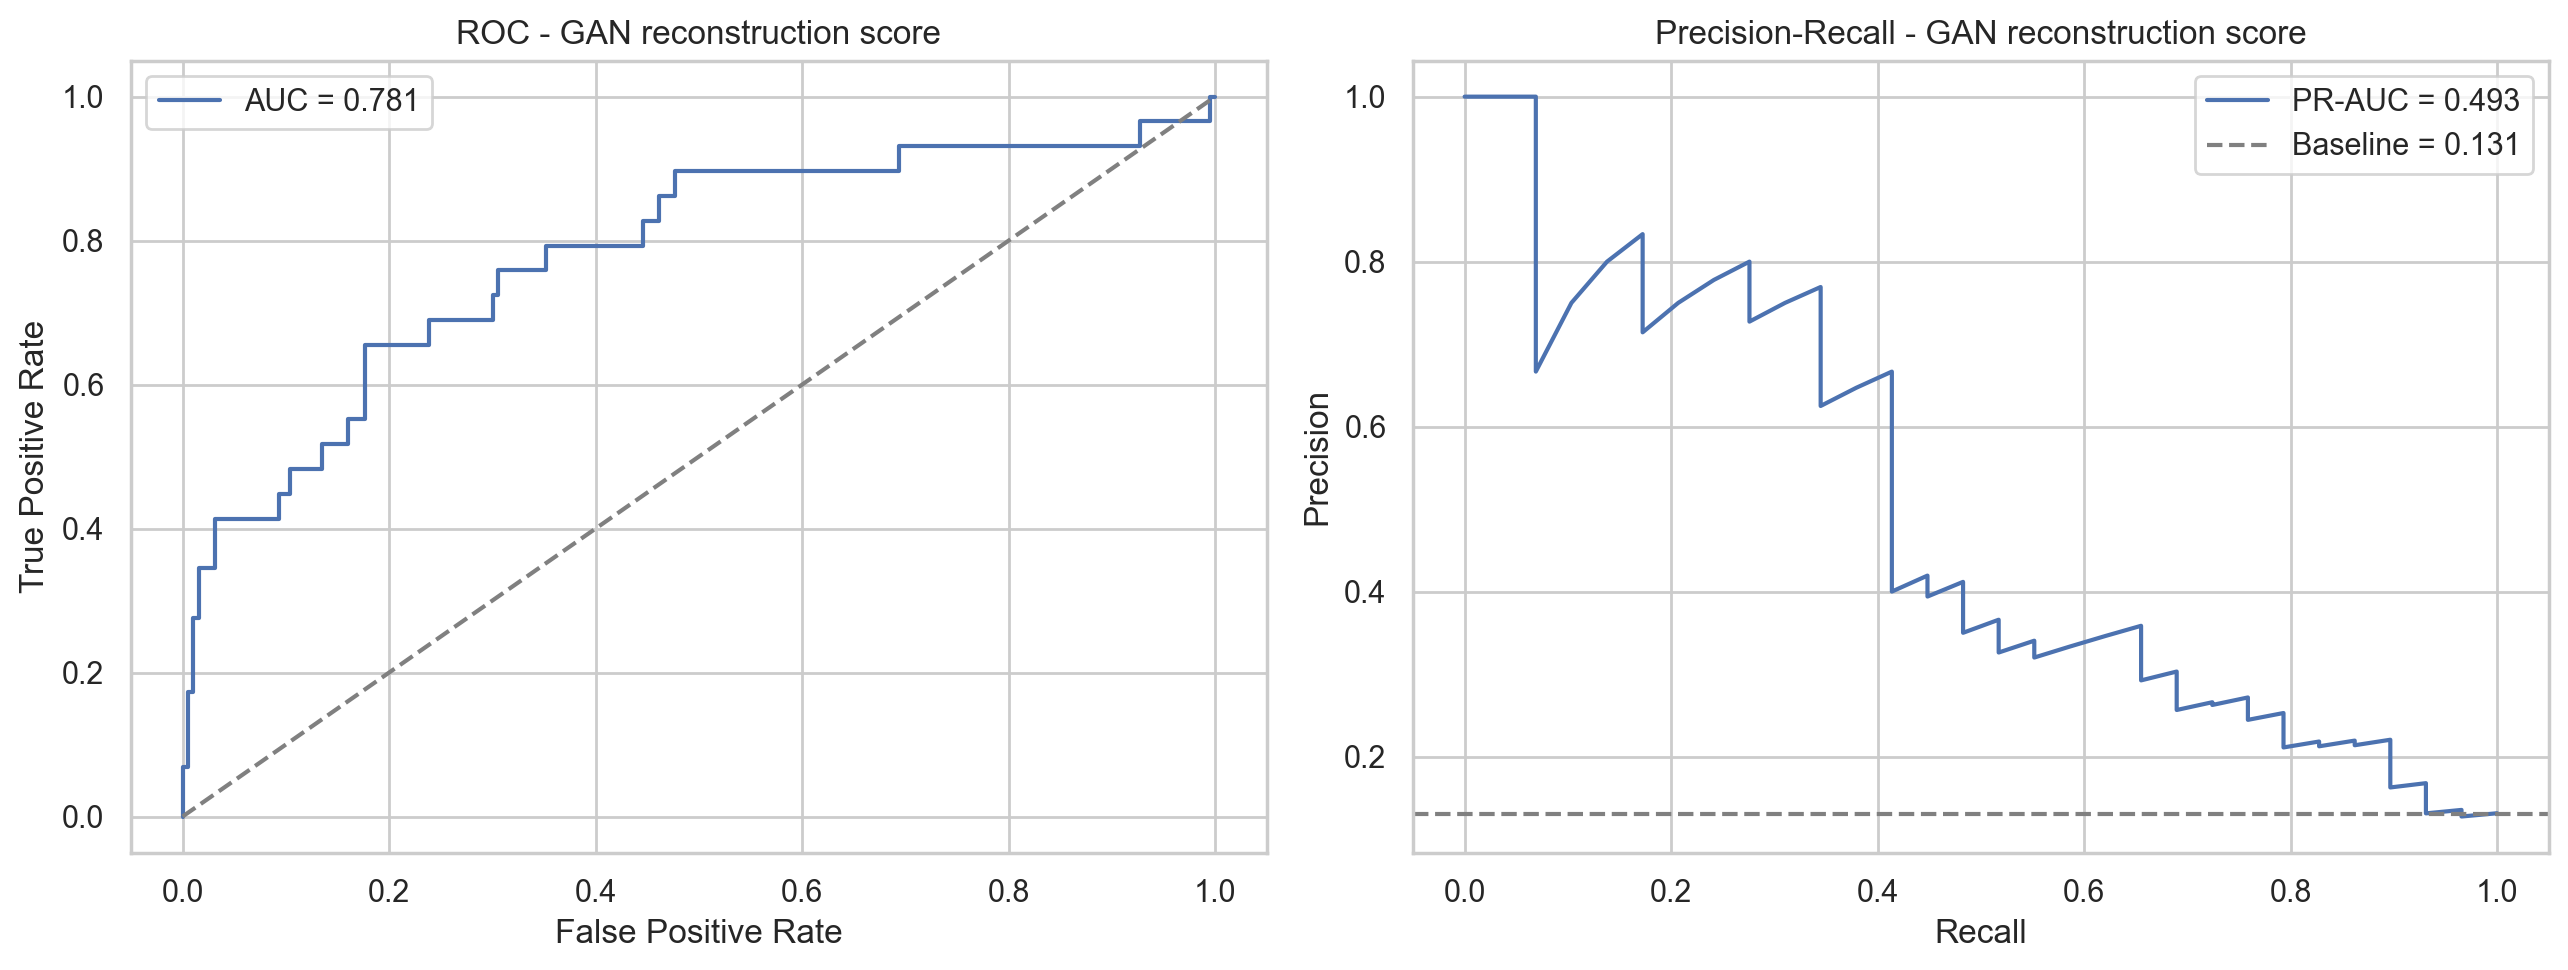

,model,precision,recall,f1,f2,fnr,roc_auc,pr_auc
0,GAN discriminator realism score,0.000000,0.000000,0.000000,0.00,1.000000,0.418438,0.225311
1,GAN reconstruction score,0.777778,0.241379,0.368421,0.28,0.758621,0.780775,0.493264


In [45]:
def evaluate_anomaly_detector(y_true, y_pred, anomaly_score, model_name):
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    f2 = fbeta_score(y_true, y_pred, beta=2.0, zero_division=0)

    fpr, tpr, _ = roc_curve(y_true, anomaly_score)
    roc_auc = auc(fpr, tpr)
    pr_precision, pr_recall, _ = precision_recall_curve(y_true, anomaly_score)
    pr_auc = average_precision_score(y_true, anomaly_score)

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    baseline_rate = float(np.mean(y_true))

    print(f"\n{model_name}")
    print(f"Recall:       {recall:.4f}   <- crises caught")
    print(f"FNR:          {fnr:.4f}   <- crises missed (lower is better)")
    print(f"F2:           {f2:.4f}")
    print(f"PR-AUC:       {pr_auc:.4f}  (baseline = {baseline_rate:.4f})")
    print(f"Precision:    {precision:.4f}")
    print(f"F1:           {f1:.4f}")
    print(f"ROC-AUC:      {roc_auc:.4f}")

    fig_cm = plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Normal", "Anomaly"],
                yticklabels=["Normal", "Anomaly"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    export_figure(fig_cm, f"05_confusion_matrix_{model_name}")
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title(f"ROC - {model_name}")
    axes[0].legend()

    axes[1].plot(pr_recall, pr_precision, label=f"PR-AUC = {pr_auc:.3f}")
    axes[1].axhline(baseline_rate, color="gray", linestyle="--", label=f"Baseline = {baseline_rate:.3f}")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title(f"Precision-Recall - {model_name}")
    axes[1].legend()
    plt.tight_layout()
    export_figure(fig, f"06_roc_pr_{model_name}")
    plt.show()

    return {
        "model": model_name,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "f2": f2,
        "fnr": fnr,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
    }


realism_metrics = evaluate_anomaly_detector(
    y_test, y_pred_realism, test_realism, "GAN discriminator realism score",
)

reconstruction_metrics = evaluate_anomaly_detector(
    y_test, y_pred_reconstruction, test_reconstruction_error, "GAN reconstruction score",
)

pd.DataFrame([realism_metrics, reconstruction_metrics])


**Graph interpretation.**  
The GAN discriminator realism diagnostics show that this score is not a useful hard alert in the chronological test. Its confusion matrix produces zero true positives, recall is 0.0000, and F2 is 0. The ROC-AUC of 0.4184 is weak, although PR-AUC of 0.2253 is above the 0.1306 base rate.

The GAN reconstruction diagnostics are stronger. Reconstruction error catches 24.14% of abnormal weeks with 77.78% precision, F2 of 0.2800, ROC-AUC of 0.7808, and PR-AUC of 0.4933. The confusion matrix and ROC/PR curves therefore show that reconstruction error is the usable GAN-derived anomaly signal, while discriminator realism should not be relied on operationally in this run.

### 7. VAE anomaly detection

A Variational Autoencoder gives a second deep-learning baseline with a different inductive bias from the GAN.

The VAE learns:

- an **encoder** that maps a market observation into a latent Gaussian distribution
- a **decoder** that reconstructs the observation from a sampled latent vector
- a regularized latent space through the KL-divergence term

As with the GAN, the VAE is trained on **normal observations only**. At inference time, observations with high reconstruction error are treated as anomalous:

$$
\text{Anomaly} \Longleftrightarrow \|x - \hat{x}\|^2 > \varepsilon
$$

The threshold is selected on the same cross-validation set used for the GAN scores.


VAE latent: 10 | hidden: 84
Epoch 001 | VAE loss=42.1173 | recon=42.0458 | KL=0.0715
Epoch 050 | VAE loss=28.6478 | recon=24.3997 | KL=4.2480
Epoch 100 | VAE loss=25.8075 | recon=21.0185 | KL=4.7890
Epoch 150 | VAE loss=25.2607 | recon=19.6904 | KL=5.5703
Epoch 200 | VAE loss=24.0967 | recon=18.3327 | KL=5.7640
Early stopping at epoch 235; best loss=23.1431


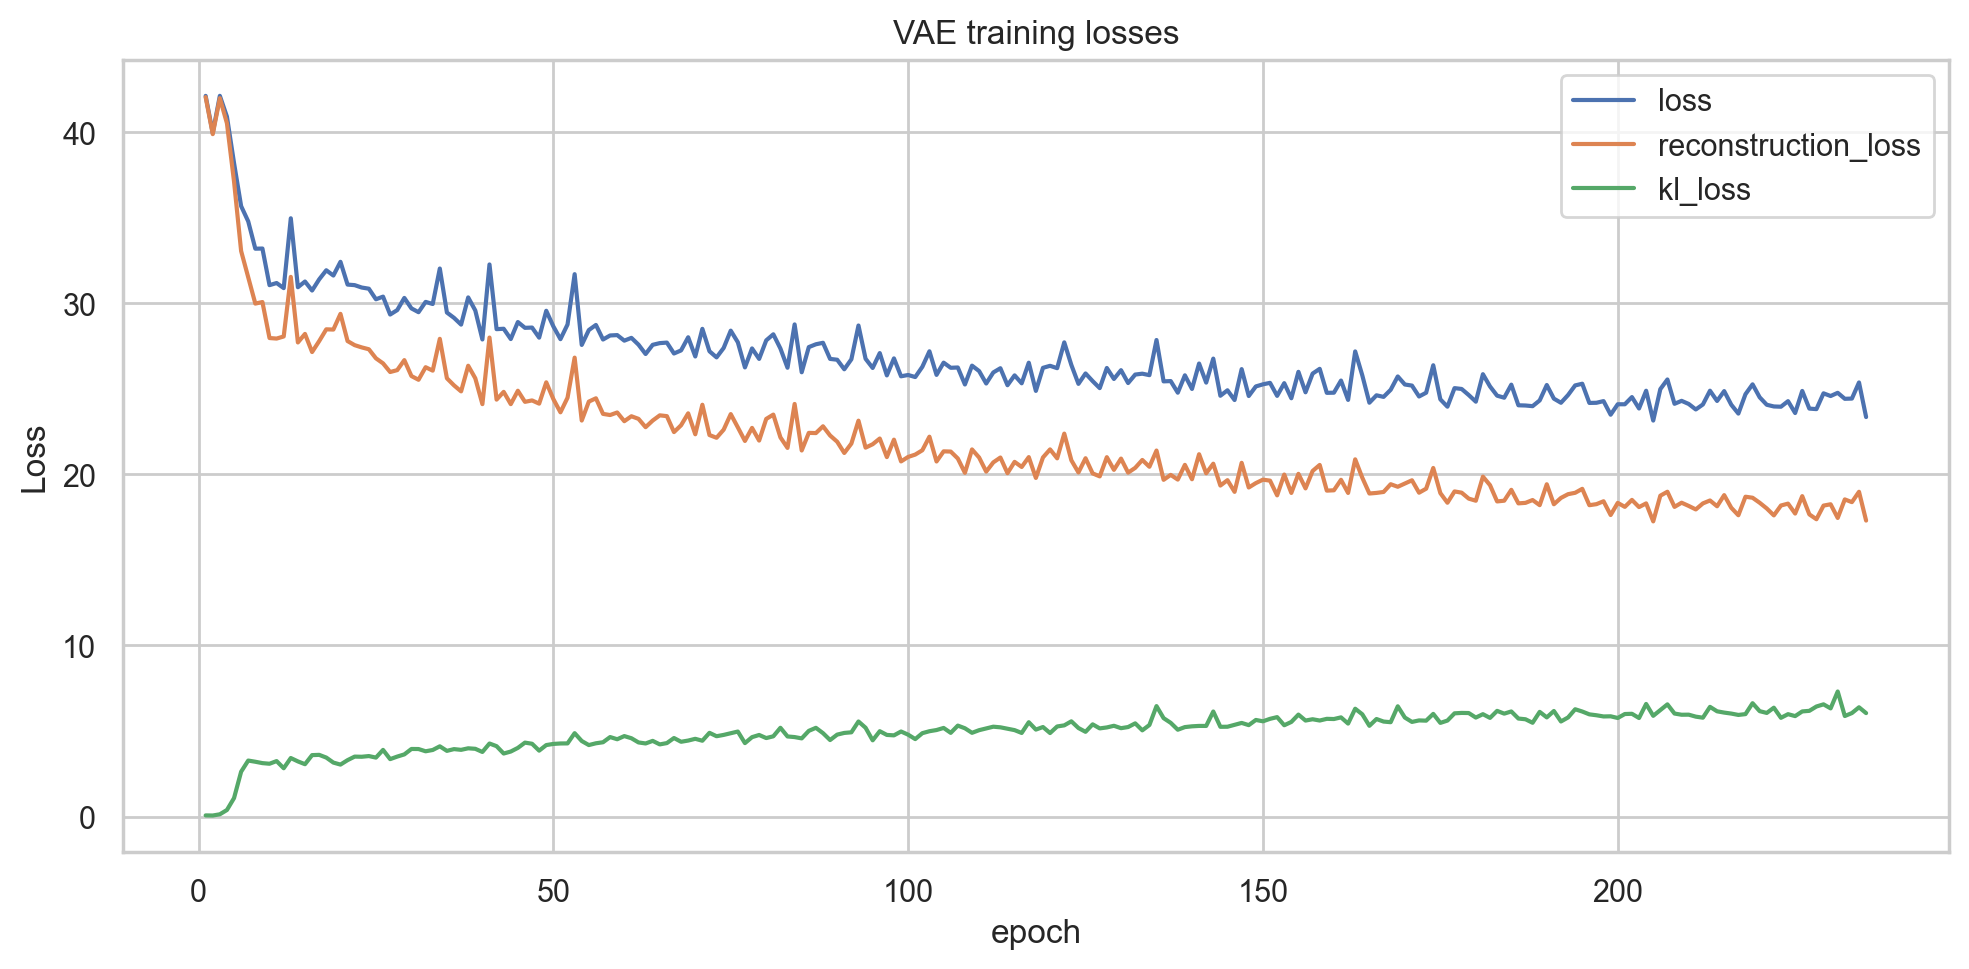


VAE reconstruction score
Recall:       0.2414   <- crises caught
FNR:          0.7586   <- crises missed (lower is better)
F2:           0.2800
PR-AUC:       0.5257  (baseline = 0.1306)
Precision:    0.7778
F1:           0.3684
ROC-AUC:      0.7699


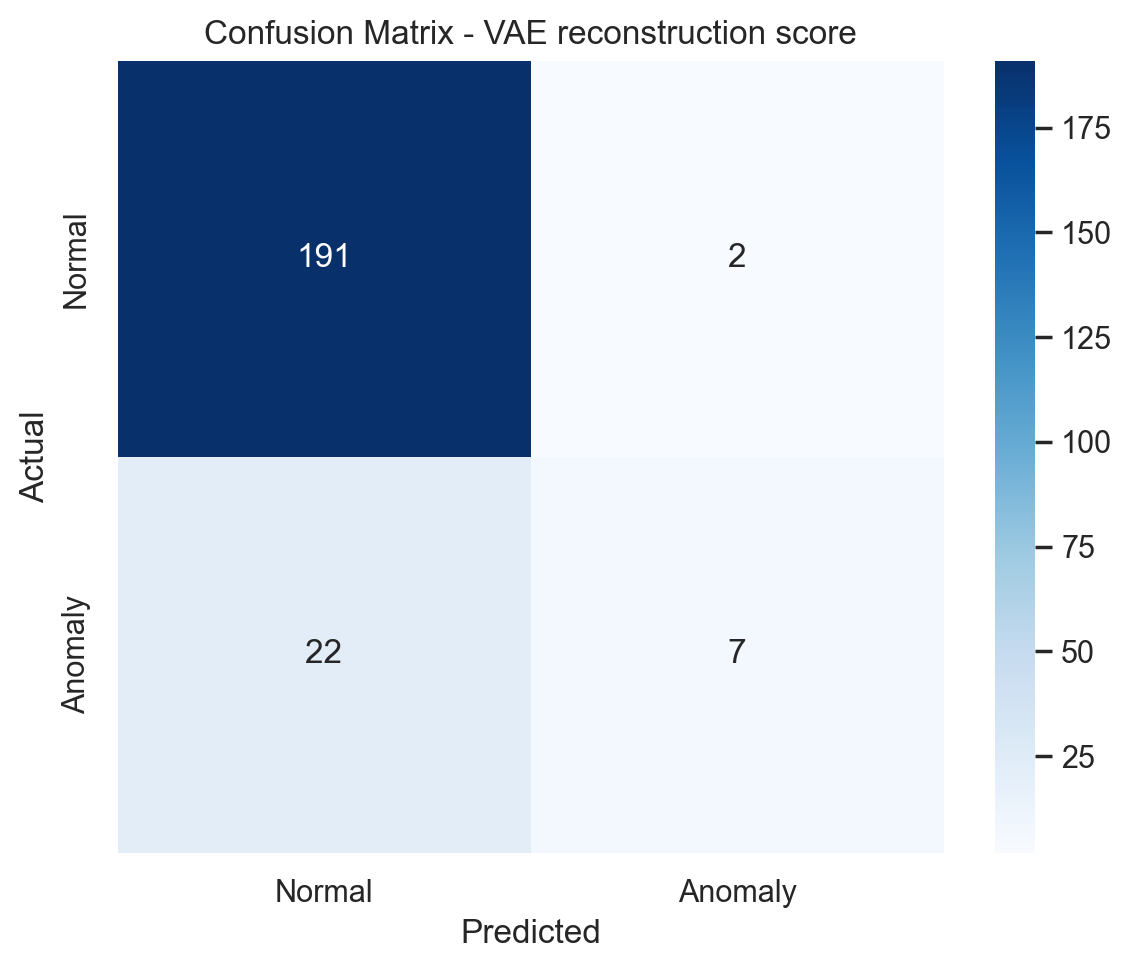

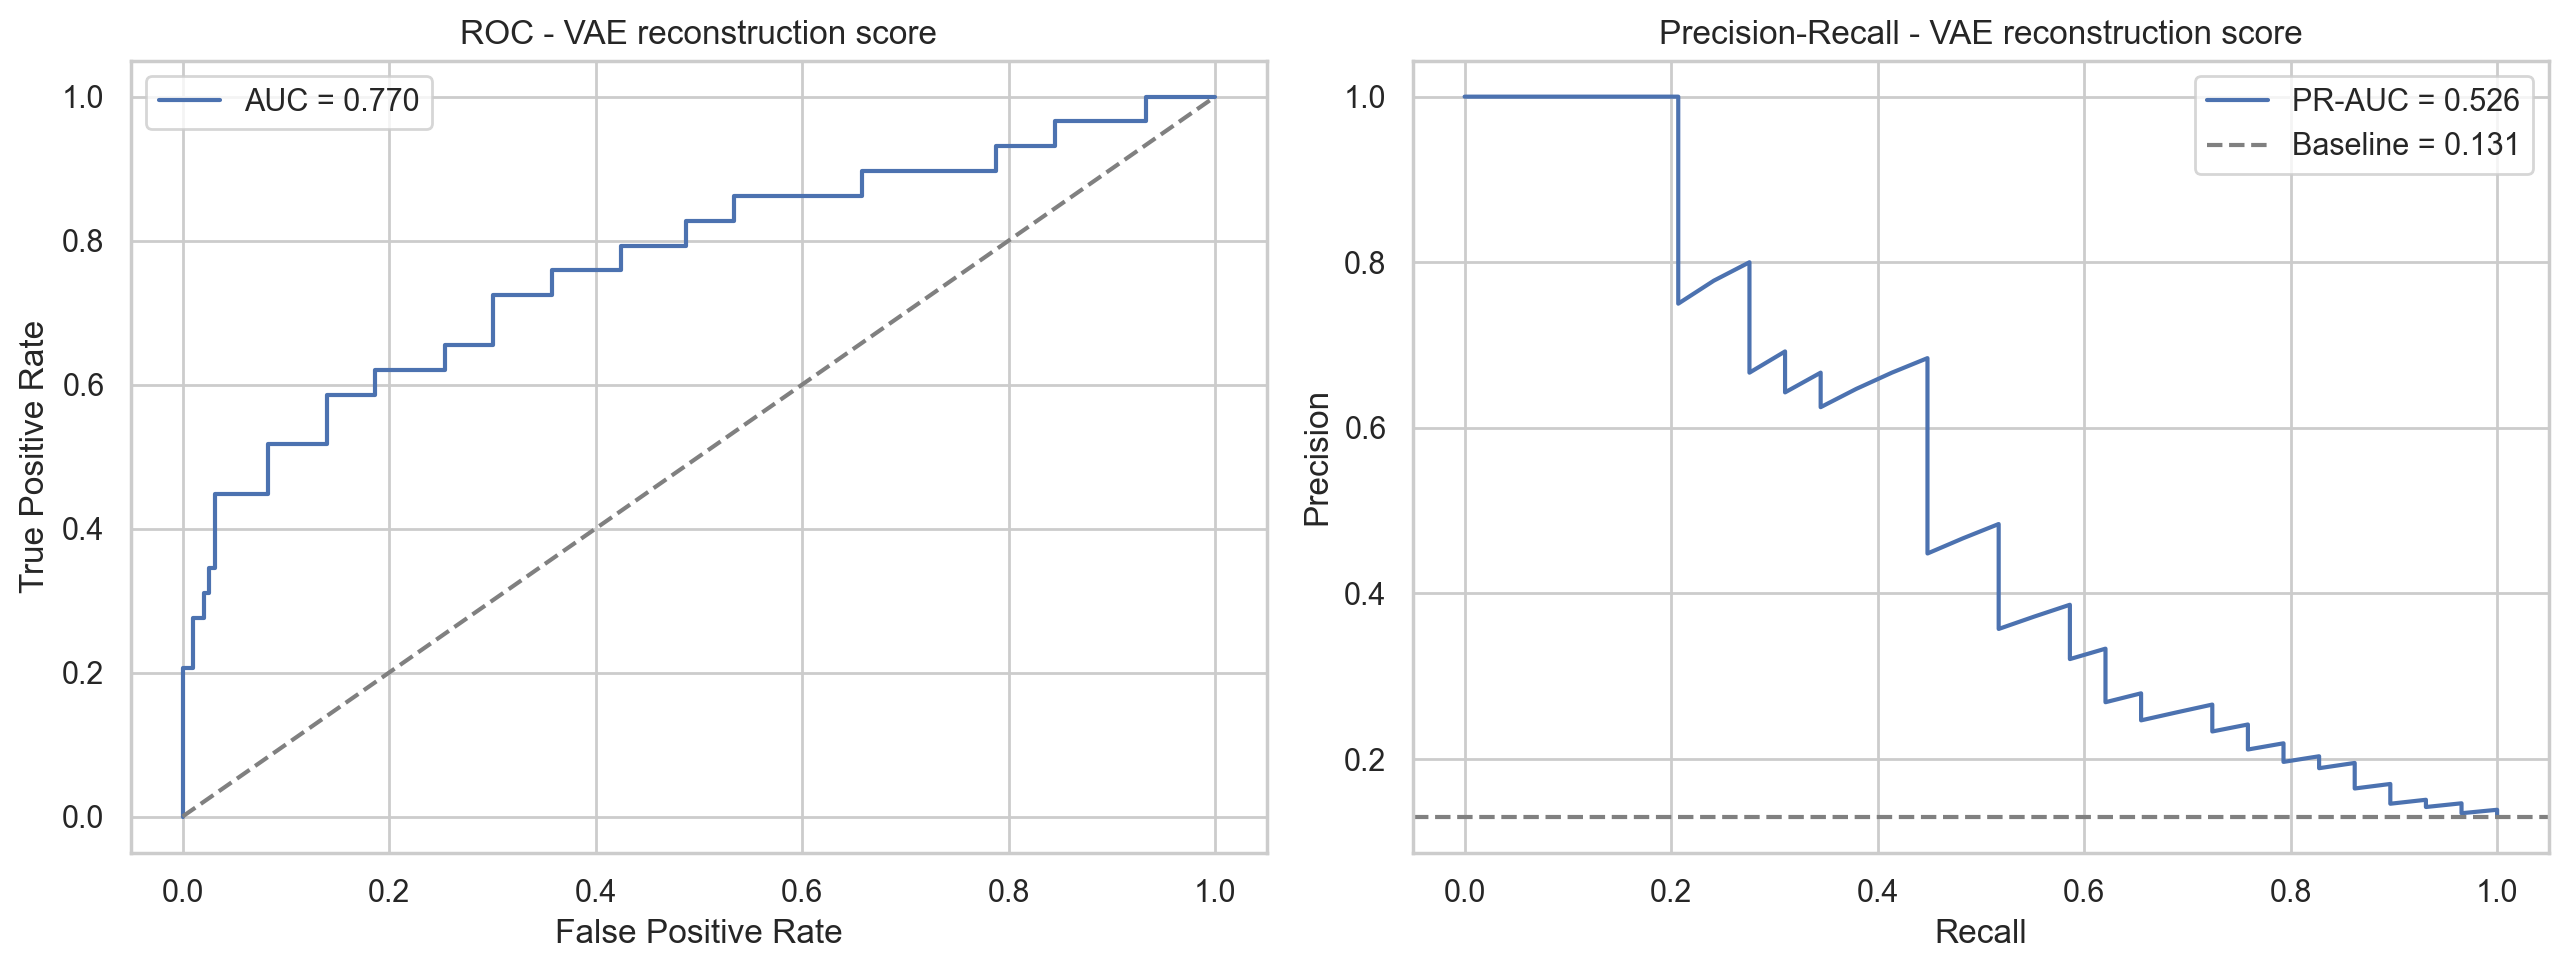

{'epsilon': 2.2053639888763428,
 'fbeta': 0.08771929824561403,
 'f1': 0.13333333333333333,
 'precision': 1.0,
 'recall': 0.07142857142857142,
 'never_fires': False,
 'precision_floor': 0.3130630630630631,
 'base_rate': 0.06306306306306306,
 'lift': 15.85714285714286}

In [46]:
class VAE(nn.Module):
    def __init__(self, input_dim: int, latent_dim: int = 8, hidden_dim: int = 64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.mu_layer = nn.Linear(hidden_dim, latent_dim)
        self.logvar_layer = nn.Linear(hidden_dim, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
        )

    def encode(self, x):
        hidden = self.encoder(x)
        return self.mu_layer(hidden), self.logvar_layer(hidden)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstruction = self.decode(z)
        return reconstruction, mu, logvar


def vae_loss(reconstruction, x, mu, logvar, beta=1.0):
    # Both terms are summed over the feature/latent dimension and averaged over the batch,
    # so beta acts on comparable per-sample magnitudes regardless of input_dim.
    reconstruction_loss = ((reconstruction - x) ** 2).sum(dim=1).mean()
    kl_loss = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).sum(dim=1).mean()
    return reconstruction_loss + beta * kl_loss, reconstruction_loss, kl_loss


def train_vae(model, loader, epochs=250, beta=1.0, lr=1e-3, patience=30, print_every=50):
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    best_loss = float("inf")
    best_state = None
    stale_epochs = 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0
        epoch_reconstruction = 0.0
        epoch_kl = 0.0

        for (batch,) in loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            reconstruction, mu, logvar = model(batch)
            loss, reconstruction_loss, kl_loss = vae_loss(reconstruction, batch, mu, logvar, beta=beta)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            epoch_reconstruction += reconstruction_loss.item()
            epoch_kl += kl_loss.item()

        avg_loss = epoch_loss / len(loader)
        avg_reconstruction = epoch_reconstruction / len(loader)
        avg_kl = epoch_kl / len(loader)
        history.append({
            "epoch": epoch,
            "loss": avg_loss,
            "reconstruction_loss": avg_reconstruction,
            "kl_loss": avg_kl,
        })

        if avg_loss < best_loss:
            best_loss = avg_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            stale_epochs = 0
        else:
            stale_epochs += 1

        if epoch == 1 or epoch % print_every == 0:
            print(
                f"Epoch {epoch:03d} | VAE loss={avg_loss:.4f} | "
                f"recon={avg_reconstruction:.4f} | KL={avg_kl:.4f}"
            )

        if stale_epochs >= patience:
            print(f"Early stopping at epoch {epoch}; best loss={best_loss:.4f}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return pd.DataFrame(history)


def vae_reconstruction_error(model, X):
    model.eval()
    X_tensor = torch.tensor(X, dtype=torch.float32, device=device)
    with torch.no_grad():
        mu, _ = model.encode(X_tensor)
        reconstruction = model.decode(mu)  # posterior mean -> deterministic, less noisy
        errors = ((reconstruction - X_tensor) ** 2).mean(dim=1).cpu().numpy()
    return errors


vae_latent_dim = min(16, max(4, input_dim // 4))
vae_hidden_dim = min(128, max(32, input_dim * 2))
vae_model = VAE(input_dim=input_dim, latent_dim=vae_latent_dim, hidden_dim=vae_hidden_dim).to(device)

print(f"VAE latent: {vae_latent_dim} | hidden: {vae_hidden_dim}")

vae_history = train_vae(vae_model, train_loader, epochs=250, beta=1.0, patience=30, print_every=50)

ax = vae_history.plot(x="epoch", y=["loss", "reconstruction_loss", "kl_loss"], figsize=(10, 5))
plt.title("VAE training losses")
plt.ylabel("Loss")
plt.tight_layout()
export_figure(ax.get_figure(), "07_vae_training_losses")
plt.show()

cv_vae_error = vae_reconstruction_error(vae_model, X_cross_val)
test_vae_error = vae_reconstruction_error(vae_model, X_test)

vae_threshold = choose_anomaly_threshold(y_cross_val, cv_vae_error)
y_pred_vae = (test_vae_error > vae_threshold["epsilon"]).astype(int)

vae_metrics = evaluate_anomaly_detector(
    y_test, y_pred_vae, test_vae_error, "VAE reconstruction score",
)

vae_threshold


**Graph interpretation.**  
The VAE training plot shows total loss and reconstruction loss declining until early stopping, while the KL component stabilizes after the latent representation is regularized. This indicates that the VAE learned a compressed representation of normal market observations rather than merely memorizing the input.

The VAE reconstruction diagnostics show a high-precision but low-recall detector in the chronological test. It catches 24.14% of abnormal weeks with 77.78% precision and F2 of 0.2800. The PR-AUC of 0.5257 is above the 0.1306 baseline and slightly better than GAN reconstruction, so the score ranks abnormal weeks reasonably well. However, the hard threshold misses 75.86% of crises, so the VAE is better as a selective warning signal than as full coverage protection.

### 8. LSTM autoencoder anomaly detection

The GAN and VAE score individual observations. The LSTM autoencoder adds short-term
temporal context by reconstructing a rolling window of standardized market features.
Each row receives the reconstruction error of the lookback window ending on that row,
then uses the same cross-validation thresholding and test evaluation workflow.


LSTM lookback: 12 | train windows: 269 | hidden: 84 | latent: 21 | batch: 26
Epoch 001 | LSTM AE loss=0.8423 | lr=1.00e-03
Epoch 050 | LSTM AE loss=0.6447 | lr=9.34e-04
Epoch 100 | LSTM AE loss=0.5597 | lr=7.52e-04
Epoch 150 | LSTM AE loss=0.4888 | lr=5.05e-04
Epoch 200 | LSTM AE loss=0.4548 | lr=2.57e-04
Epoch 250 | LSTM AE loss=0.4287 | lr=7.63e-05
Early stopping at epoch 292; best loss=0.4217


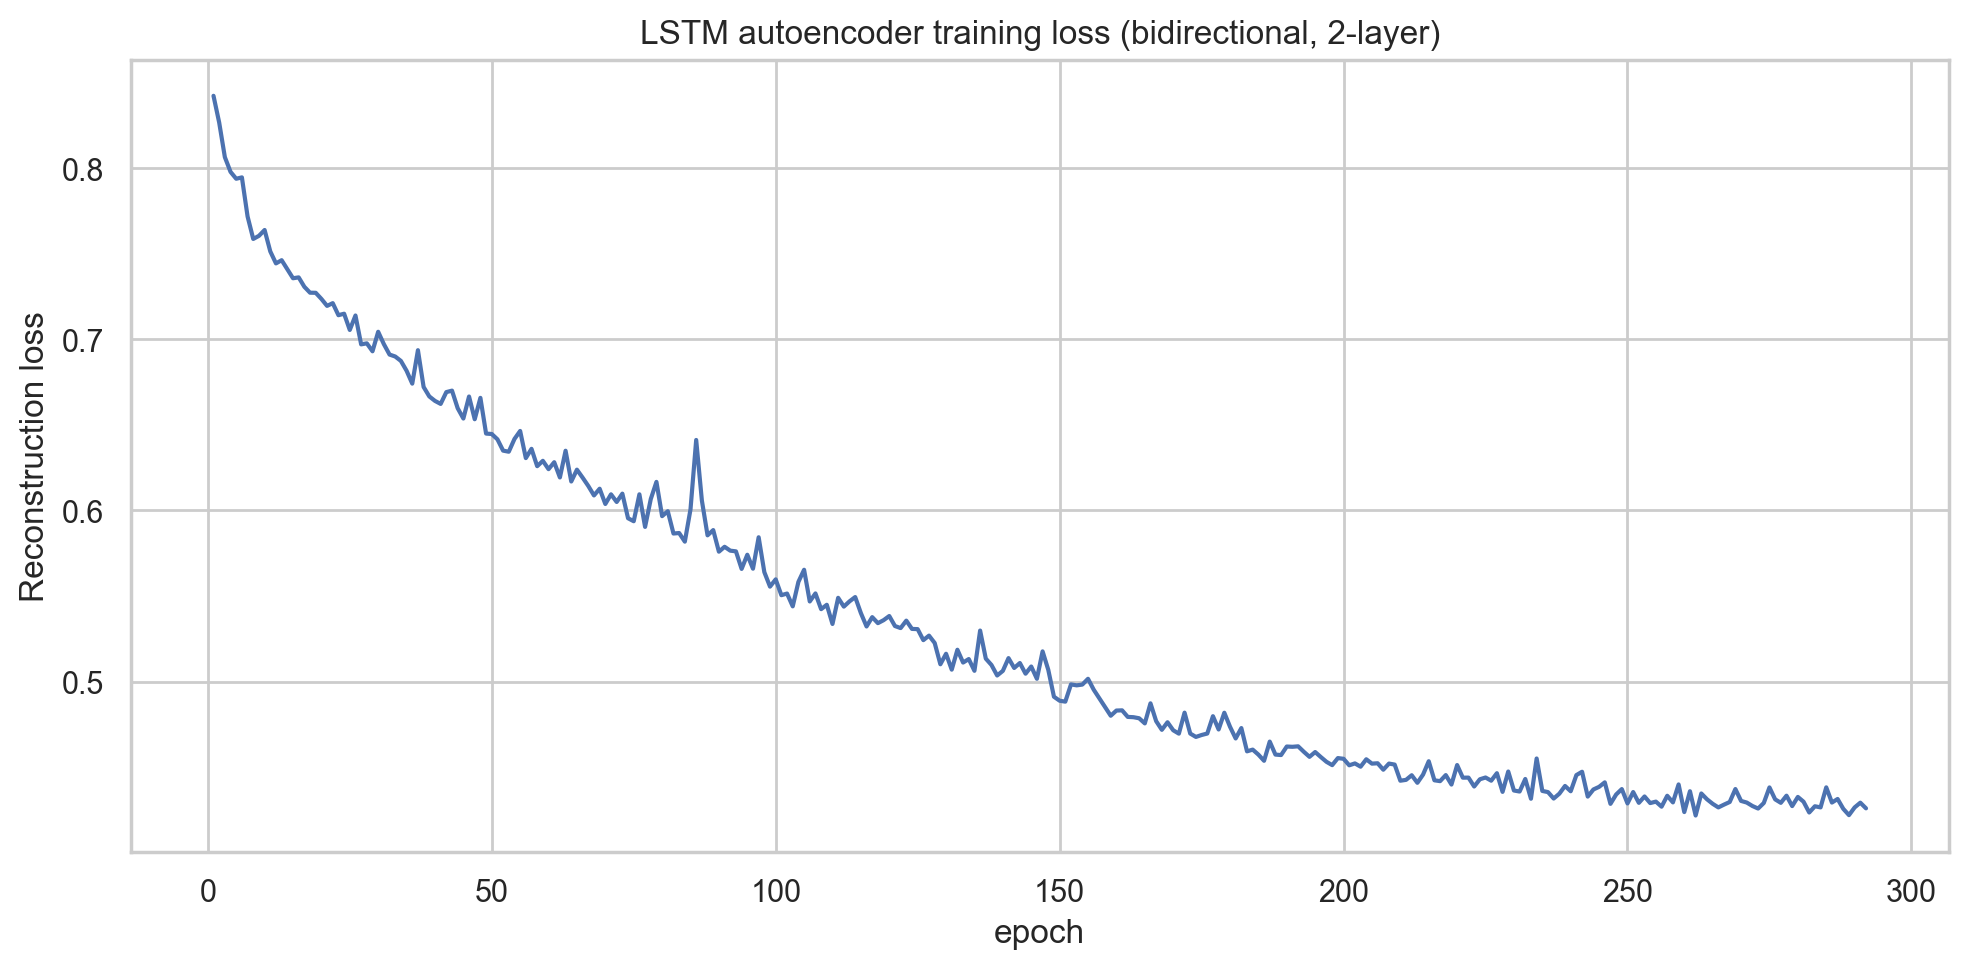


LSTM scoring-component diagnostics (CV):
  recon-only (z): F-beta=0.088 | recall=0.071 | precision=1.000
  maha-only  (z): F-beta=0.085 | recall=0.071 | precision=0.333
  recon+maha (ensemble): F-beta=0.088 | recall=0.071 | precision=1.000

LSTM autoencoder (bidirectional + Mahalanobis)
Recall:       0.2759   <- crises caught
FNR:          0.7241   <- crises missed (lower is better)
F2:           0.3175
PR-AUC:       0.5124  (baseline = 0.1306)
Precision:    0.8000
F1:           0.4103
ROC-AUC:      0.7584


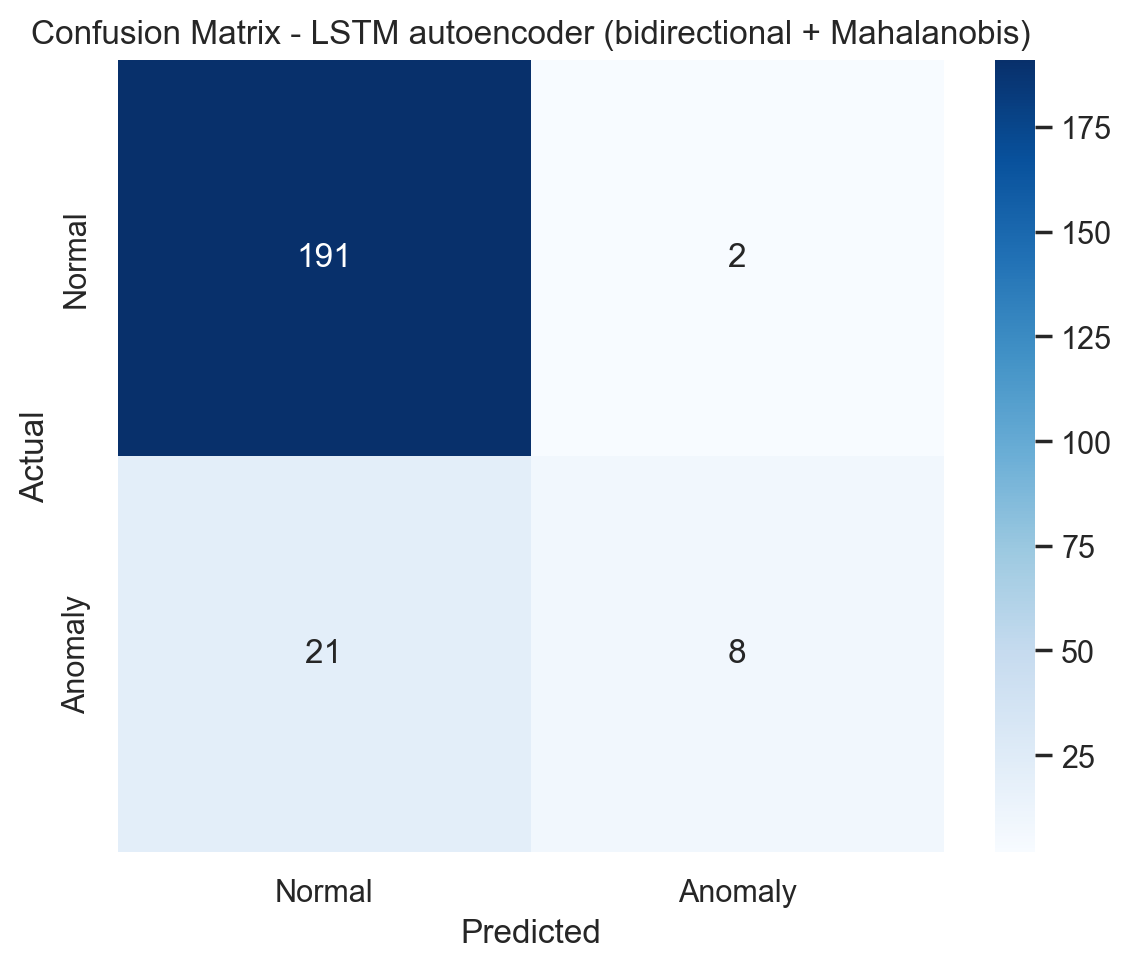

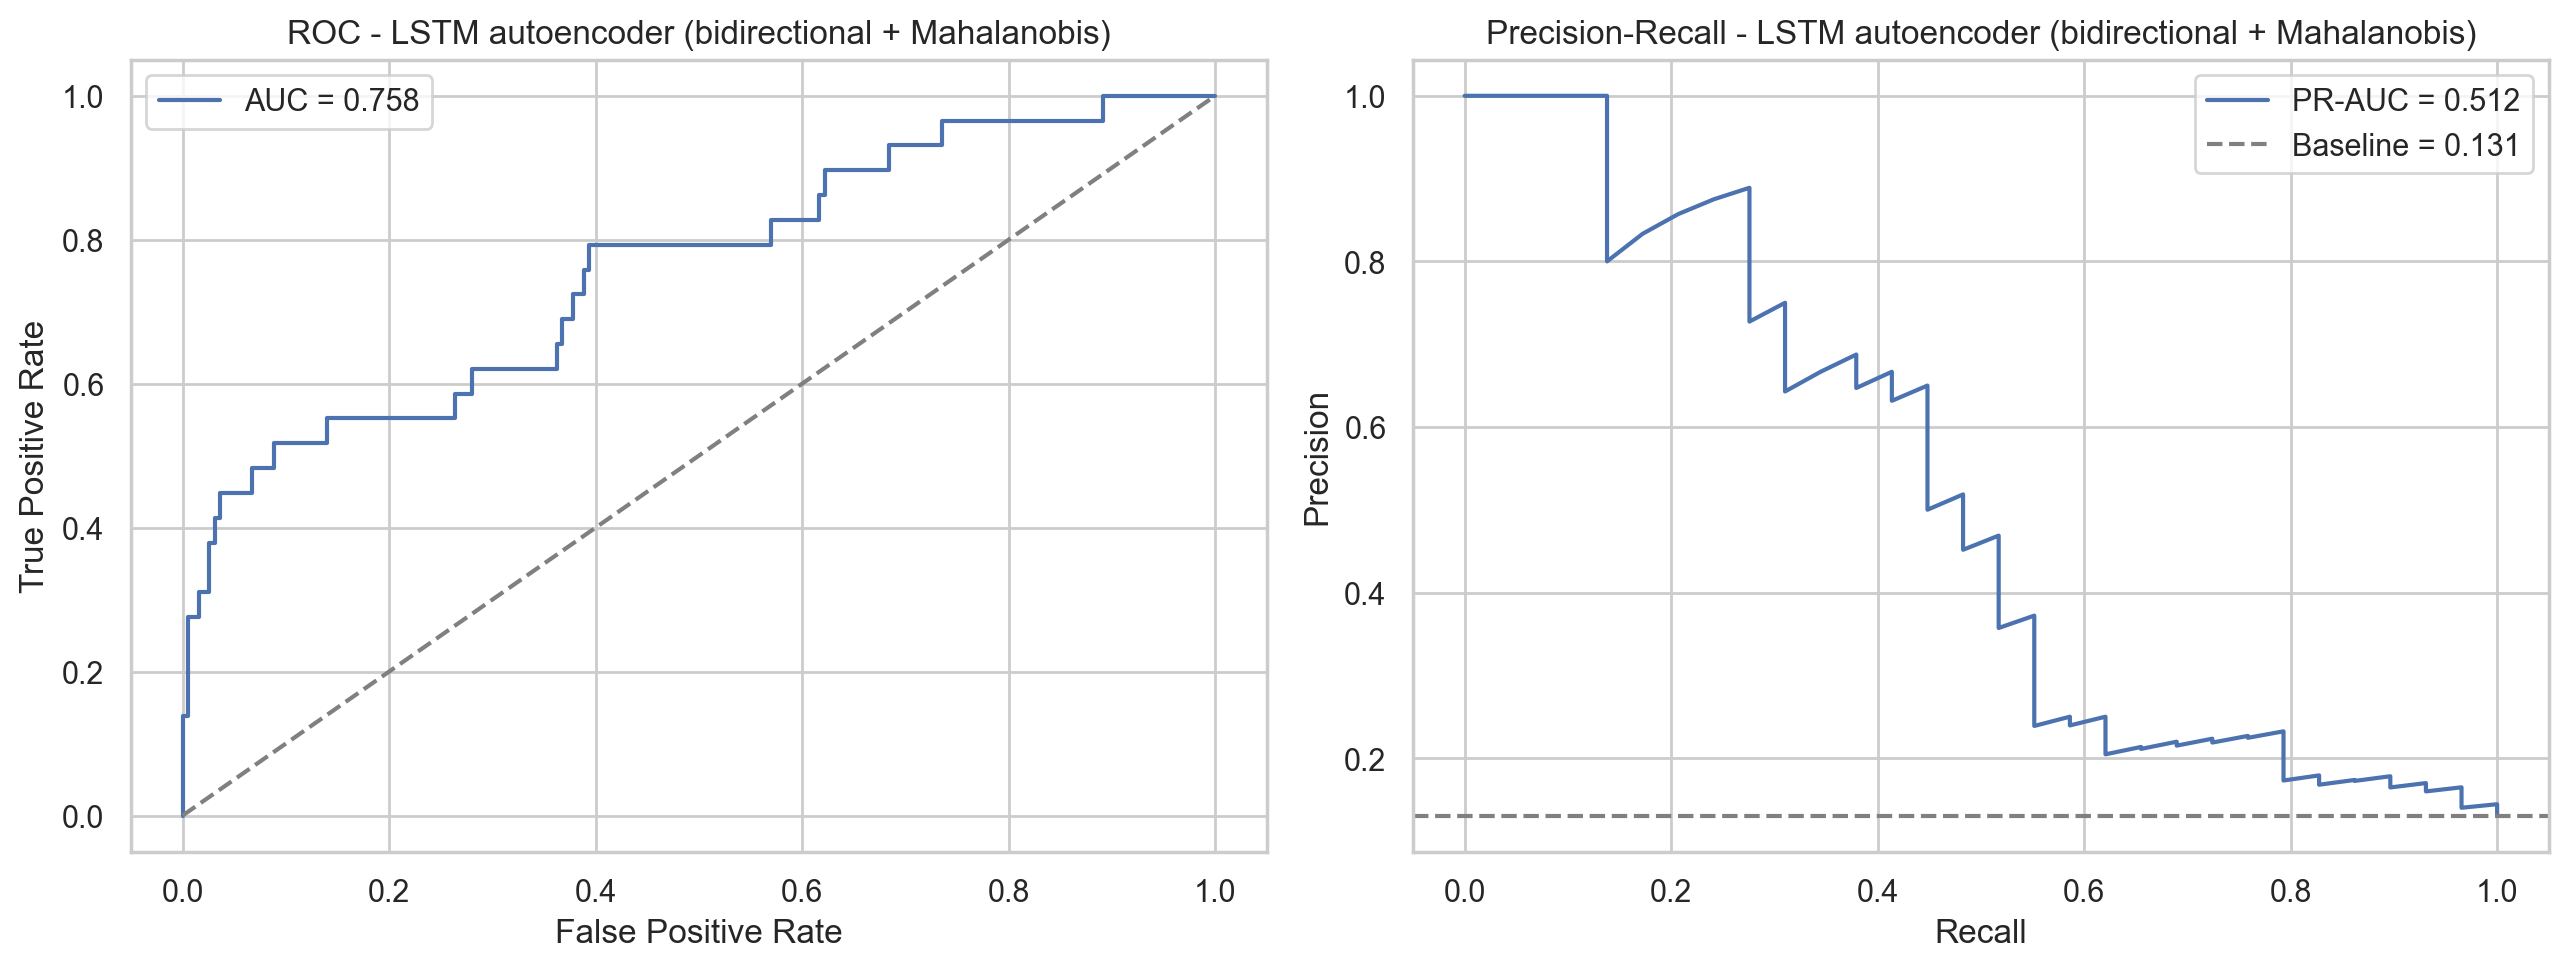

{'epsilon': 17.961758201166127,
 'fbeta': 0.08771929824561403,
 'f1': 0.13333333333333333,
 'precision': 1.0,
 'recall': 0.07142857142857142,
 'never_fires': False,
 'precision_floor': 0.3130630630630631,
 'base_rate': 0.06306306306306306,
 'lift': 15.85714285714286}

In [47]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int = 64, latent_dim: int = 16,
                 num_layers: int = 2, dropout: float = 0.2):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim
        self.encoder = nn.LSTM(
            input_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=True,
        )
        self.to_latent = nn.Linear(hidden_dim * 2, latent_dim)
        self.from_latent = nn.Linear(latent_dim, hidden_dim)
        self.decoder = nn.LSTM(
            hidden_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.output_layer = nn.Linear(hidden_dim, input_dim)
        self.latent_dropout = nn.Dropout(dropout)

    def encode(self, x):
        encoded, _ = self.encoder(x)
        # Bidir output shape: (batch, seq, 2 * hidden_dim).
        # Take the forward state at the LAST position (has seen full seq going
        # forward) and the backward state at the FIRST position (has seen full
        # seq going backward).
        forward_end = encoded[:, -1, :self.hidden_dim]
        backward_end = encoded[:, 0, self.hidden_dim:]
        pooled = torch.cat([forward_end, backward_end], dim=-1)
        return self.to_latent(self.latent_dropout(pooled))

    def decode(self, latent, seq_len):
        seed = self.from_latent(latent).unsqueeze(1).repeat(1, seq_len, 1)
        decoded, _ = self.decoder(seed)
        return self.output_layer(decoded)

    def forward(self, x):
        latent = self.encode(x)
        return self.decode(latent, x.size(1))


def build_rolling_windows(X_scaled, labels, dates, lookback):
    """Return padded rolling windows plus end-date and clean-window flags."""
    windows = []
    end_dates = []
    end_labels = []
    clean_window = []

    for end in range(len(X_scaled)):
        start = max(0, end - lookback + 1)
        window = X_scaled[start:end + 1]
        if len(window) < lookback:
            padding = np.repeat(window[:1], lookback - len(window), axis=0)
            window = np.vstack([padding, window])

        windows.append(window)
        end_dates.append(pd.Timestamp(dates[end]))
        end_labels.append(int(labels[end]))
        clean_window.append(bool(np.all(labels[start:end + 1] == 0)))

    return (
        np.stack(windows).astype(np.float32),
        pd.DatetimeIndex(end_dates),
        np.array(end_labels, dtype=int),
        np.array(clean_window, dtype=bool),
    )


def train_lstm_autoencoder(model, loader, epochs=300, lr=1e-3, patience=30,
                           print_every=50, max_grad_norm=1.0):
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=lr * 0.01,
    )
    best_loss = float("inf")
    best_state = None
    stale_epochs = 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0

        for (batch,) in loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            reconstruction = model(batch)
            loss = ((reconstruction - batch) ** 2).mean()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            optimizer.step()
            epoch_loss += loss.item()
        scheduler.step()

        avg_loss = epoch_loss / len(loader)
        history.append({
            "epoch": epoch,
            "loss": avg_loss,
            "lr": optimizer.param_groups[0]["lr"],
        })

        if avg_loss < best_loss - 1e-6:
            best_loss = avg_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            stale_epochs = 0
        else:
            stale_epochs += 1

        if epoch == 1 or epoch % print_every == 0:
            print(
                f"Epoch {epoch:03d} | LSTM AE loss={avg_loss:.4f} | "
                f"lr={optimizer.param_groups[0]['lr']:.2e}"
            )

        if stale_epochs >= patience:
            print(f"Early stopping at epoch {epoch}; best loss={best_loss:.4f}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return pd.DataFrame(history)


def _lstm_last_step_residuals(model, windows, batch_size=256):
    """Last-step reconstruction residuals; shape (n_windows, input_dim)."""
    model.eval()
    parts = []
    with torch.no_grad():
        for start in range(0, len(windows), batch_size):
            batch = torch.tensor(
                windows[start:start + batch_size],
                dtype=torch.float32, device=device,
            )
            reconstruction = model(batch)
            r = (reconstruction[:, -1, :] - batch[:, -1, :]).cpu().numpy()
            parts.append(r)
    return np.concatenate(parts, axis=0)


def _lstm_latent_vectors(model, windows, batch_size=256):
    """LSTM bottleneck latent vectors; shape (n_windows, latent_dim)."""
    model.eval()
    parts = []
    with torch.no_grad():
        for start in range(0, len(windows), batch_size):
            batch = torch.tensor(
                windows[start:start + batch_size],
                dtype=torch.float32, device=device,
            )
            latent = model.encode(batch).cpu().numpy()
            parts.append(latent)
    return np.concatenate(parts, axis=0)


def lstm_reconstruction_error(model, windows, batch_size=256, residual_scale=None):
    """Per-feature-standardised last-step reconstruction MSE."""
    residuals = _lstm_last_step_residuals(model, windows, batch_size=batch_size)
    if residual_scale is None:
        residual_scale = np.maximum(residuals.std(axis=0), 1e-6)
    return ((residuals / residual_scale) ** 2).mean(axis=1)


# Build chronological rolling windows. Lookback is one quarter of weekly data.
lstm_lookback = 12
X_all_scaled = scaler.transform(stationary_df.values)
lstm_windows, lstm_window_dates, lstm_window_labels, lstm_clean_window = build_rolling_windows(
    X_all_scaled, y, stationary_df.index, lookback=lstm_lookback,
)

# Training windows = those whose end-date falls in the chronological train block.
train_end_dates = pd.DatetimeIndex(train_dates)
lstm_train_mask = lstm_window_dates.isin(train_end_dates) & lstm_clean_window
lstm_train_windows = lstm_windows[lstm_train_mask]
if len(lstm_train_windows) == 0:
    raise ValueError("No clean normal windows available for LSTM autoencoder training.")

lstm_batch_size = min(64, max(8, len(lstm_train_windows) // 10))
lstm_train_loader = DataLoader(
    TensorDataset(torch.tensor(lstm_train_windows, dtype=torch.float32)),
    batch_size=lstm_batch_size,
    shuffle=True,
)

lstm_hidden_dim = min(128, max(32, input_dim * 2))
lstm_latent_dim = min(32, max(8, input_dim // 2))
lstm_model = LSTMAutoencoder(
    input_dim=input_dim,
    hidden_dim=lstm_hidden_dim,
    latent_dim=lstm_latent_dim,
    num_layers=2,
    dropout=0.2,
).to(device)

print(
    f"LSTM lookback: {lstm_lookback} | train windows: {len(lstm_train_windows)} | "
    f"hidden: {lstm_hidden_dim} | latent: {lstm_latent_dim} | batch: {lstm_batch_size}"
)

lstm_history = train_lstm_autoencoder(
    lstm_model, lstm_train_loader, epochs=300, patience=30, print_every=50,
)

ax = lstm_history.plot(x="epoch", y="loss", figsize=(10, 5), legend=False)
plt.title("LSTM autoencoder training loss (bidirectional, 2-layer)")
plt.ylabel("Reconstruction loss")
plt.tight_layout()
export_figure(ax.get_figure(), "08_lstm_autoencoder_training_loss")
plt.show()

# --- Build the ensemble anomaly score on training-window statistics.
train_residuals = _lstm_last_step_residuals(lstm_model, lstm_train_windows)
train_residual_scale = np.maximum(train_residuals.std(axis=0), 1e-6)

train_recon = ((train_residuals / train_residual_scale) ** 2).mean(axis=1)
recon_mean = float(train_recon.mean())
recon_std = float(max(train_recon.std(), 1e-6))

train_latents = _lstm_latent_vectors(lstm_model, lstm_train_windows)
maha_mu = train_latents.mean(axis=0)
maha_cov = np.cov(train_latents, rowvar=False) + 1e-4 * np.eye(train_latents.shape[1])
maha_cov_inv = np.linalg.inv(maha_cov)


def lstm_mahalanobis(latent_matrix):
    delta = latent_matrix - maha_mu
    return np.einsum("ij,jk,ik->i", delta, maha_cov_inv, delta)


train_maha = lstm_mahalanobis(train_latents)
maha_mean = float(train_maha.mean())
maha_std = float(max(train_maha.std(), 1e-6))

# Score the full chronology with both components, then z-score and sum.
lstm_all_recon = lstm_reconstruction_error(
    lstm_model, lstm_windows, residual_scale=train_residual_scale,
)
lstm_all_latents = _lstm_latent_vectors(lstm_model, lstm_windows)
lstm_all_maha = lstm_mahalanobis(lstm_all_latents)

recon_z = (lstm_all_recon - recon_mean) / recon_std
maha_z = (lstm_all_maha - maha_mean) / maha_std
lstm_all_error = recon_z + maha_z

lstm_score_series = pd.Series(lstm_all_error, index=lstm_window_dates)
lstm_recon_z_series = pd.Series(recon_z, index=lstm_window_dates)
lstm_maha_z_series = pd.Series(maha_z, index=lstm_window_dates)

cv_lstm_error = lstm_score_series.reindex(pd.DatetimeIndex(cv_dates)).to_numpy()
test_lstm_error = lstm_score_series.reindex(pd.DatetimeIndex(test_dates)).to_numpy()
if np.isnan(cv_lstm_error).any() or np.isnan(test_lstm_error).any():
    raise ValueError("LSTM score/date alignment failed for CV or test rows.")

# Diagnostics: report each component's stand-alone CV F-beta so we can see
# what the ensemble is actually buying.
print("\nLSTM scoring-component diagnostics (CV):")
for label, score_series in [
    ("  recon-only (z)", lstm_recon_z_series),
    ("  maha-only  (z)", lstm_maha_z_series),
    ("  recon+maha (ensemble)", lstm_score_series),
]:
    cv_score = score_series.reindex(pd.DatetimeIndex(cv_dates)).to_numpy()
    thr = choose_anomaly_threshold(y_cross_val, cv_score)
    print(
        f"{label}: F-beta={thr['fbeta']:.3f} | "
        f"recall={thr['recall']:.3f} | precision={thr['precision']:.3f}"
    )

lstm_threshold = choose_anomaly_threshold(y_cross_val, cv_lstm_error)
y_pred_lstm = (test_lstm_error > lstm_threshold["epsilon"]).astype(int)

lstm_metrics = evaluate_anomaly_detector(
    y_test, y_pred_lstm, test_lstm_error,
    "LSTM autoencoder (bidirectional + Mahalanobis)",
)

lstm_threshold


**Graph interpretation.**  
The LSTM autoencoder loss curve declines across training and stops after the best validation-free training state is reached, indicating that the model learned to reconstruct normal 12-week windows. Because the model uses sequence windows, it captures temporal market patterns that pointwise detectors may miss.

The scoring diagnostics show the LSTM as the strongest deep-learning detector in this chronological test. It reaches 27.59% recall, 80.00% precision, F2 of 0.3175, and PR-AUC of 0.5124. The confusion matrix still shows many missed crises, but the combination of window reconstruction and Mahalanobis latent scoring gives the best deep-learning F2 among the GAN, VAE, and LSTM models.

### 9. Compare GAN, VAE, and LSTM anomaly detection


,model,recall,f2,fnr,pr_auc,precision,f1,roc_auc
0,LSTM autoencoder (bidirectional + Mahalanobis),0.275862,0.31746,0.724138,0.512412,0.800000,0.410256,0.758442
1,GAN reconstruction score,0.241379,0.28000,0.758621,0.493264,0.777778,0.368421,0.780775
2,VAE reconstruction score,0.241379,0.28000,0.758621,0.525665,0.777778,0.368421,0.769877
3,GAN discriminator realism score,0.000000,0.00000,1.000000,0.225311,0.000000,0.000000,0.418438


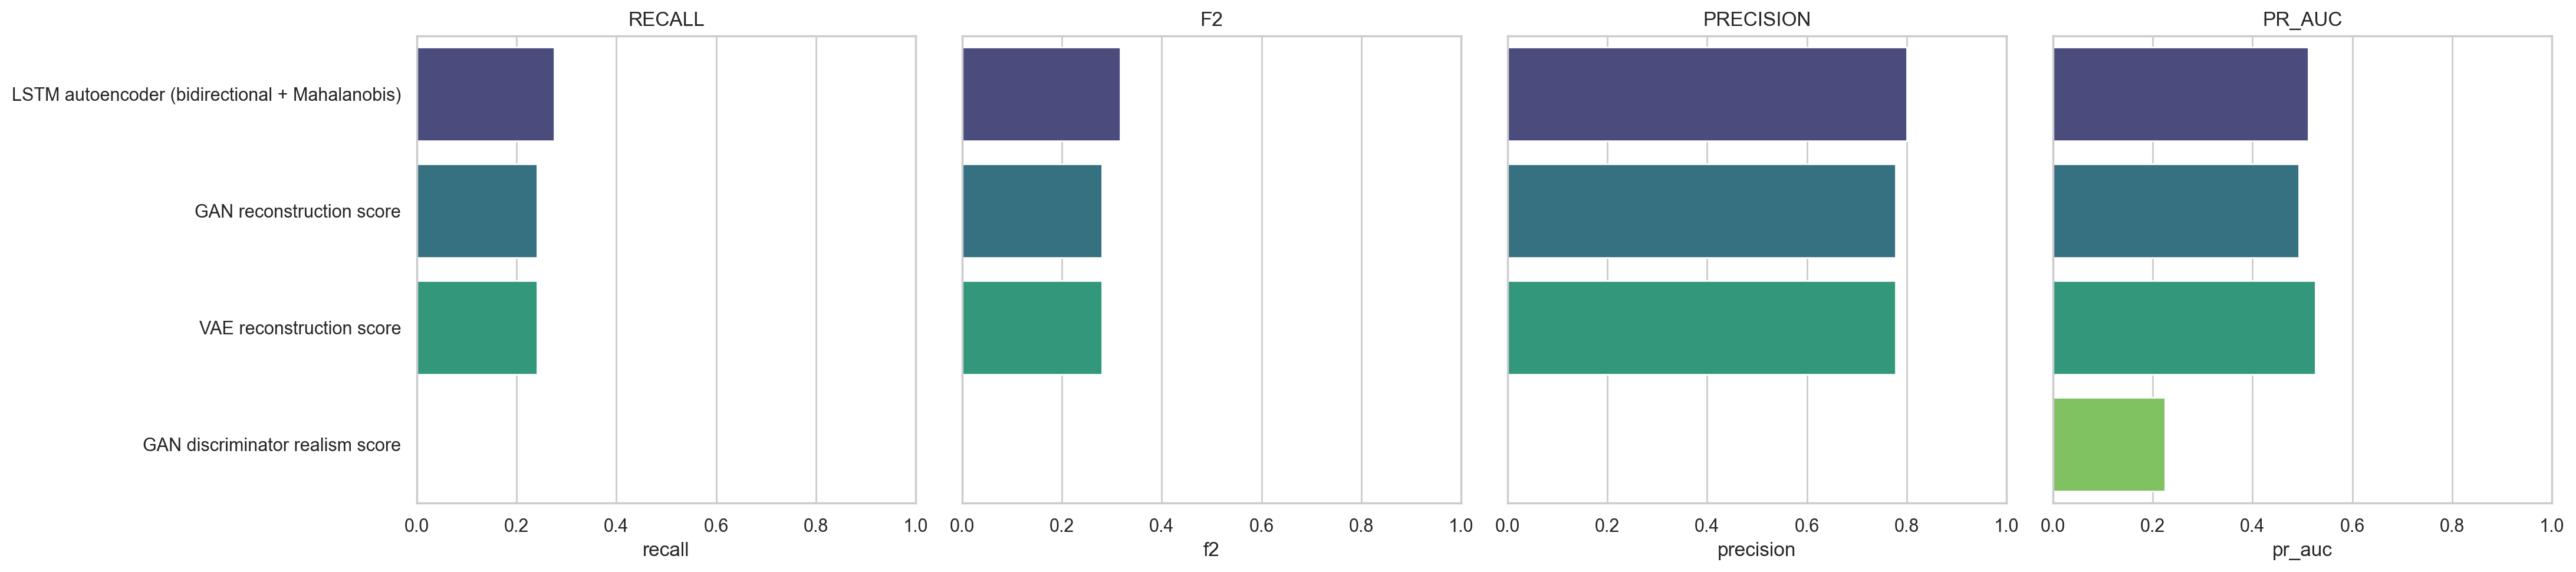

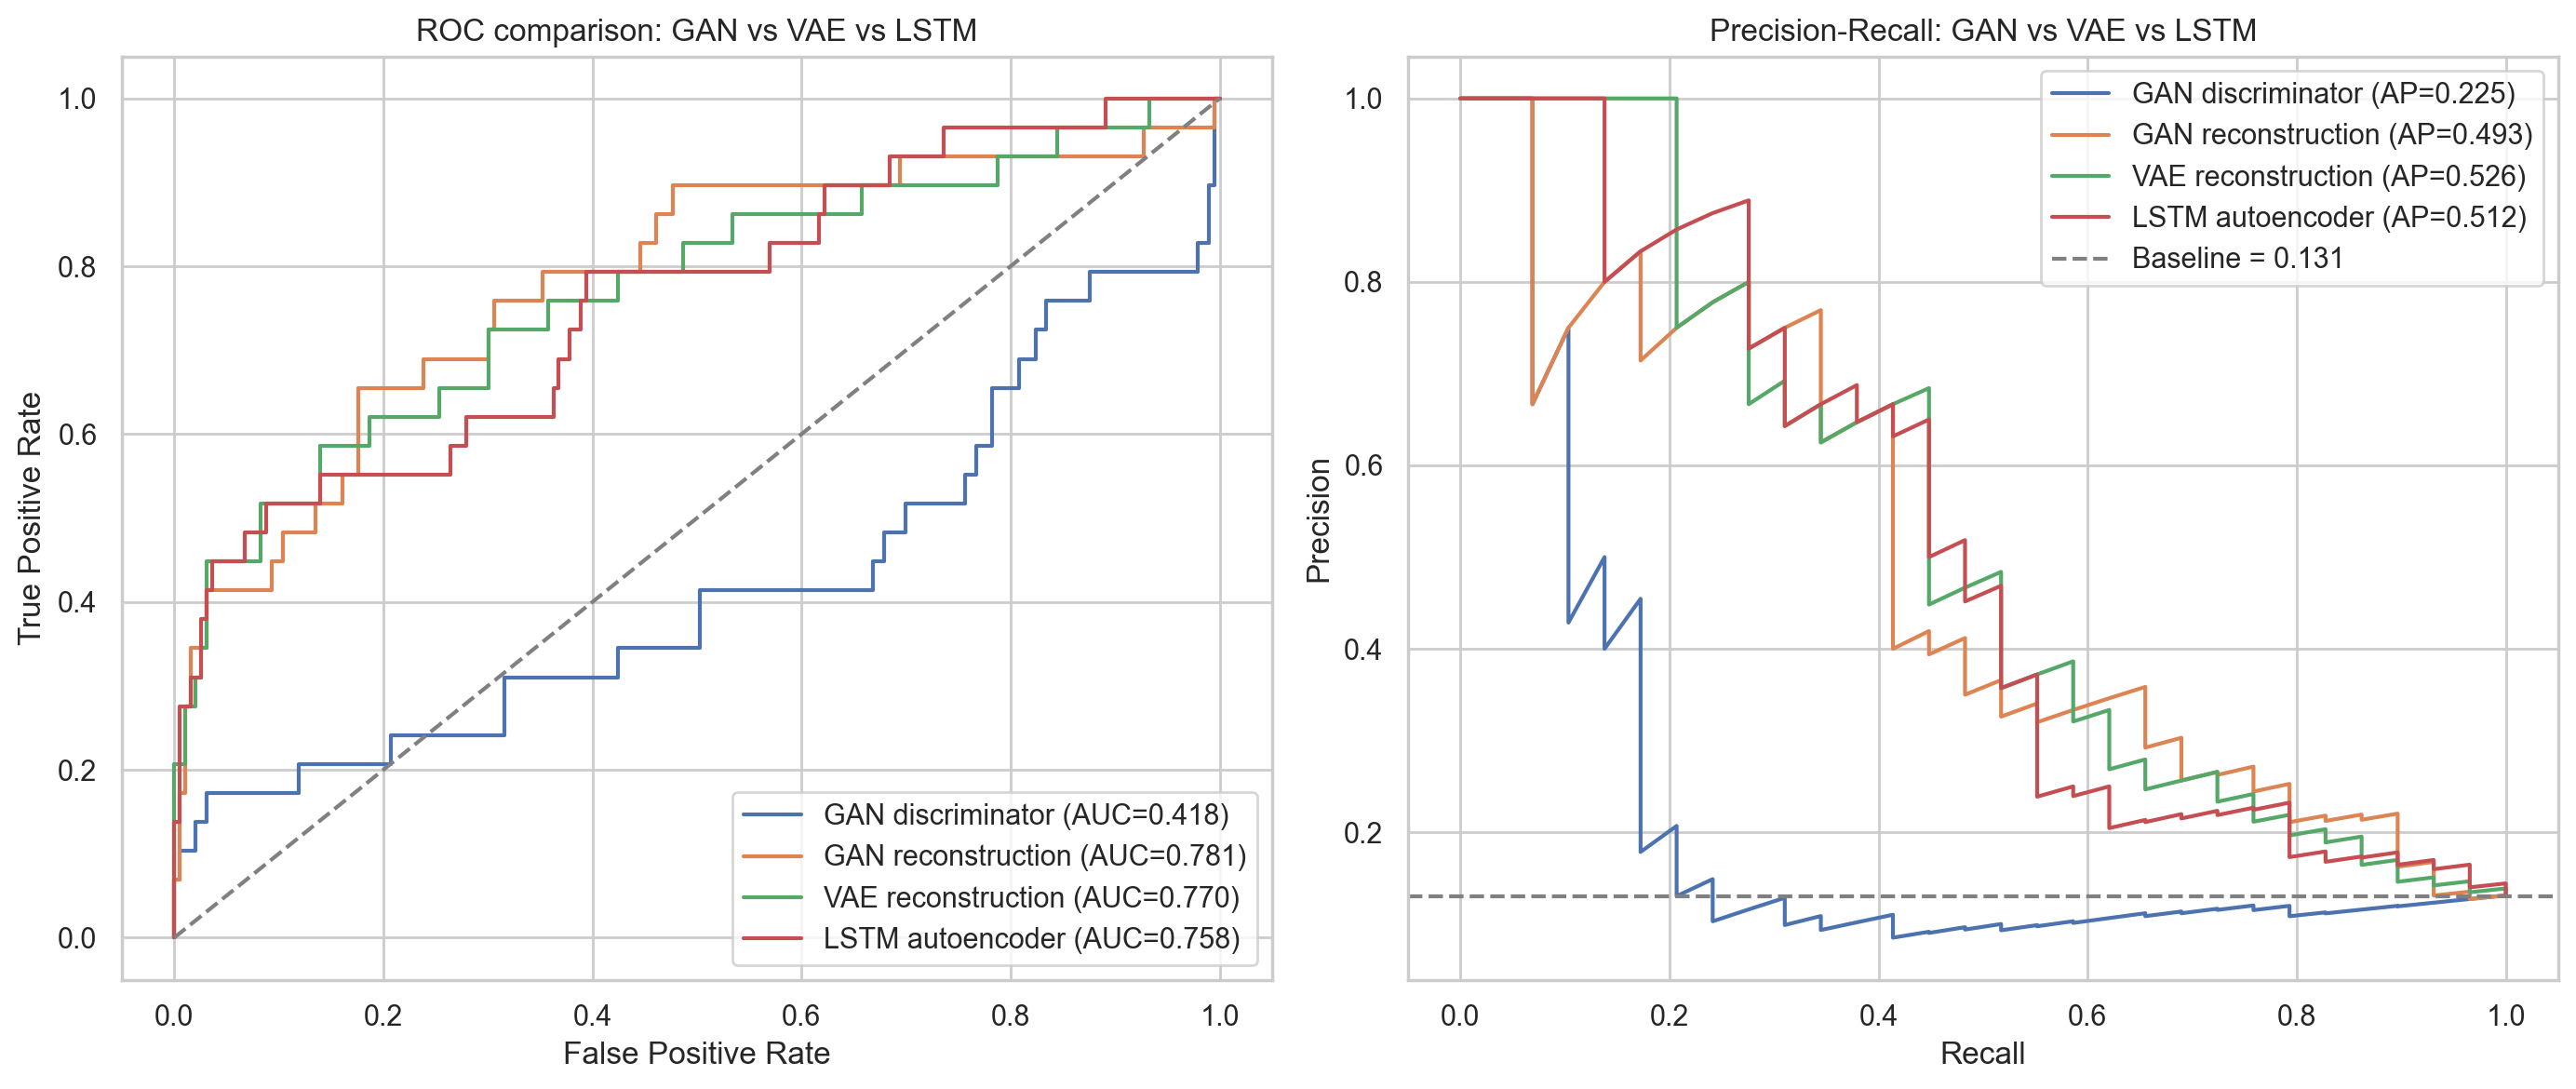

In [48]:
comparison_df = pd.DataFrame([realism_metrics, reconstruction_metrics, vae_metrics, lstm_metrics])
comparison_df = comparison_df.sort_values("f2", ascending=False).reset_index(drop=True)
display(comparison_df[["model", "recall", "f2", "fnr", "pr_auc", "precision", "f1", "roc_auc"]])

fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)
for ax, metric in zip(axes, ["recall", "f2", "precision", "pr_auc"]):
    sns.barplot(data=comparison_df, x=metric, y="model", hue="model", ax=ax, palette="viridis", legend=False)
    ax.set_xlim(0, 1)
    ax.set_title(metric.upper())
    ax.set_ylabel("")
plt.tight_layout()
export_figure(fig, "09_model_metric_comparison")
plt.show()

score_panels = [
    ("GAN discriminator", test_realism),
    ("GAN reconstruction", test_reconstruction_error),
    ("VAE reconstruction", test_vae_error),
    ("LSTM autoencoder", test_lstm_error),
]
baseline_rate = float(np.mean(y_test))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for label, score in score_panels:
    fpr, tpr, _ = roc_curve(y_test, score)
    axes[0].plot(fpr, tpr, label=f"{label} (AUC={auc(fpr, tpr):.3f})")
    pr_precision, pr_recall, _ = precision_recall_curve(y_test, score)
    axes[1].plot(pr_recall, pr_precision, label=f"{label} (AP={average_precision_score(y_test, score):.3f})")

axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC comparison: GAN vs VAE vs LSTM")
axes[0].legend()

axes[1].axhline(baseline_rate, color="gray", linestyle="--", label=f"Baseline = {baseline_rate:.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall: GAN vs VAE vs LSTM")
axes[1].legend()
plt.tight_layout()
export_figure(fig, "10_roc_pr_model_comparison")
plt.show()


**Graph interpretation.**  
The metric bar charts compare recall, F2, precision, and PR-AUC for the deep-learning detectors. LSTM ranks first on recall and F2, while VAE has the highest PR-AUC among the reconstruction-style scores. GAN reconstruction is close to VAE on thresholded metrics, and GAN discriminator realism is clearly the weakest because it has zero recall.

The ROC and precision-recall comparison panels separate ranking quality from thresholded classification. GAN reconstruction, VAE reconstruction, and LSTM all produce curves meaningfully above the discriminator signal, but none of them reaches high recall under the chosen high-precision thresholds. This shows that deep learning contributes useful anomaly scores, but threshold design remains central to the business outcome.

### 10. Latent-space visualisation with t-SNE, UMAP, and PACMAP

The original `EarlyWarningSystemPoliMI` notebook recommends a manifold-level
sanity check: do anomalous weeks actually sit apart from normal weeks once we
project the data into two dimensions? Here we apply three nonlinear projections
to three different representations of the same observations:

1. **Raw scaled features** -- the input to every detector, projected as-is.
2. **VAE posterior mean $\mu(x)$** -- the latent representation the VAE learnt
   from normal weeks only.
3. **LSTM autoencoder bottleneck** -- the latent representation that also
   carries short-term temporal context.


c:\Users\shour\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\shour\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\shour\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


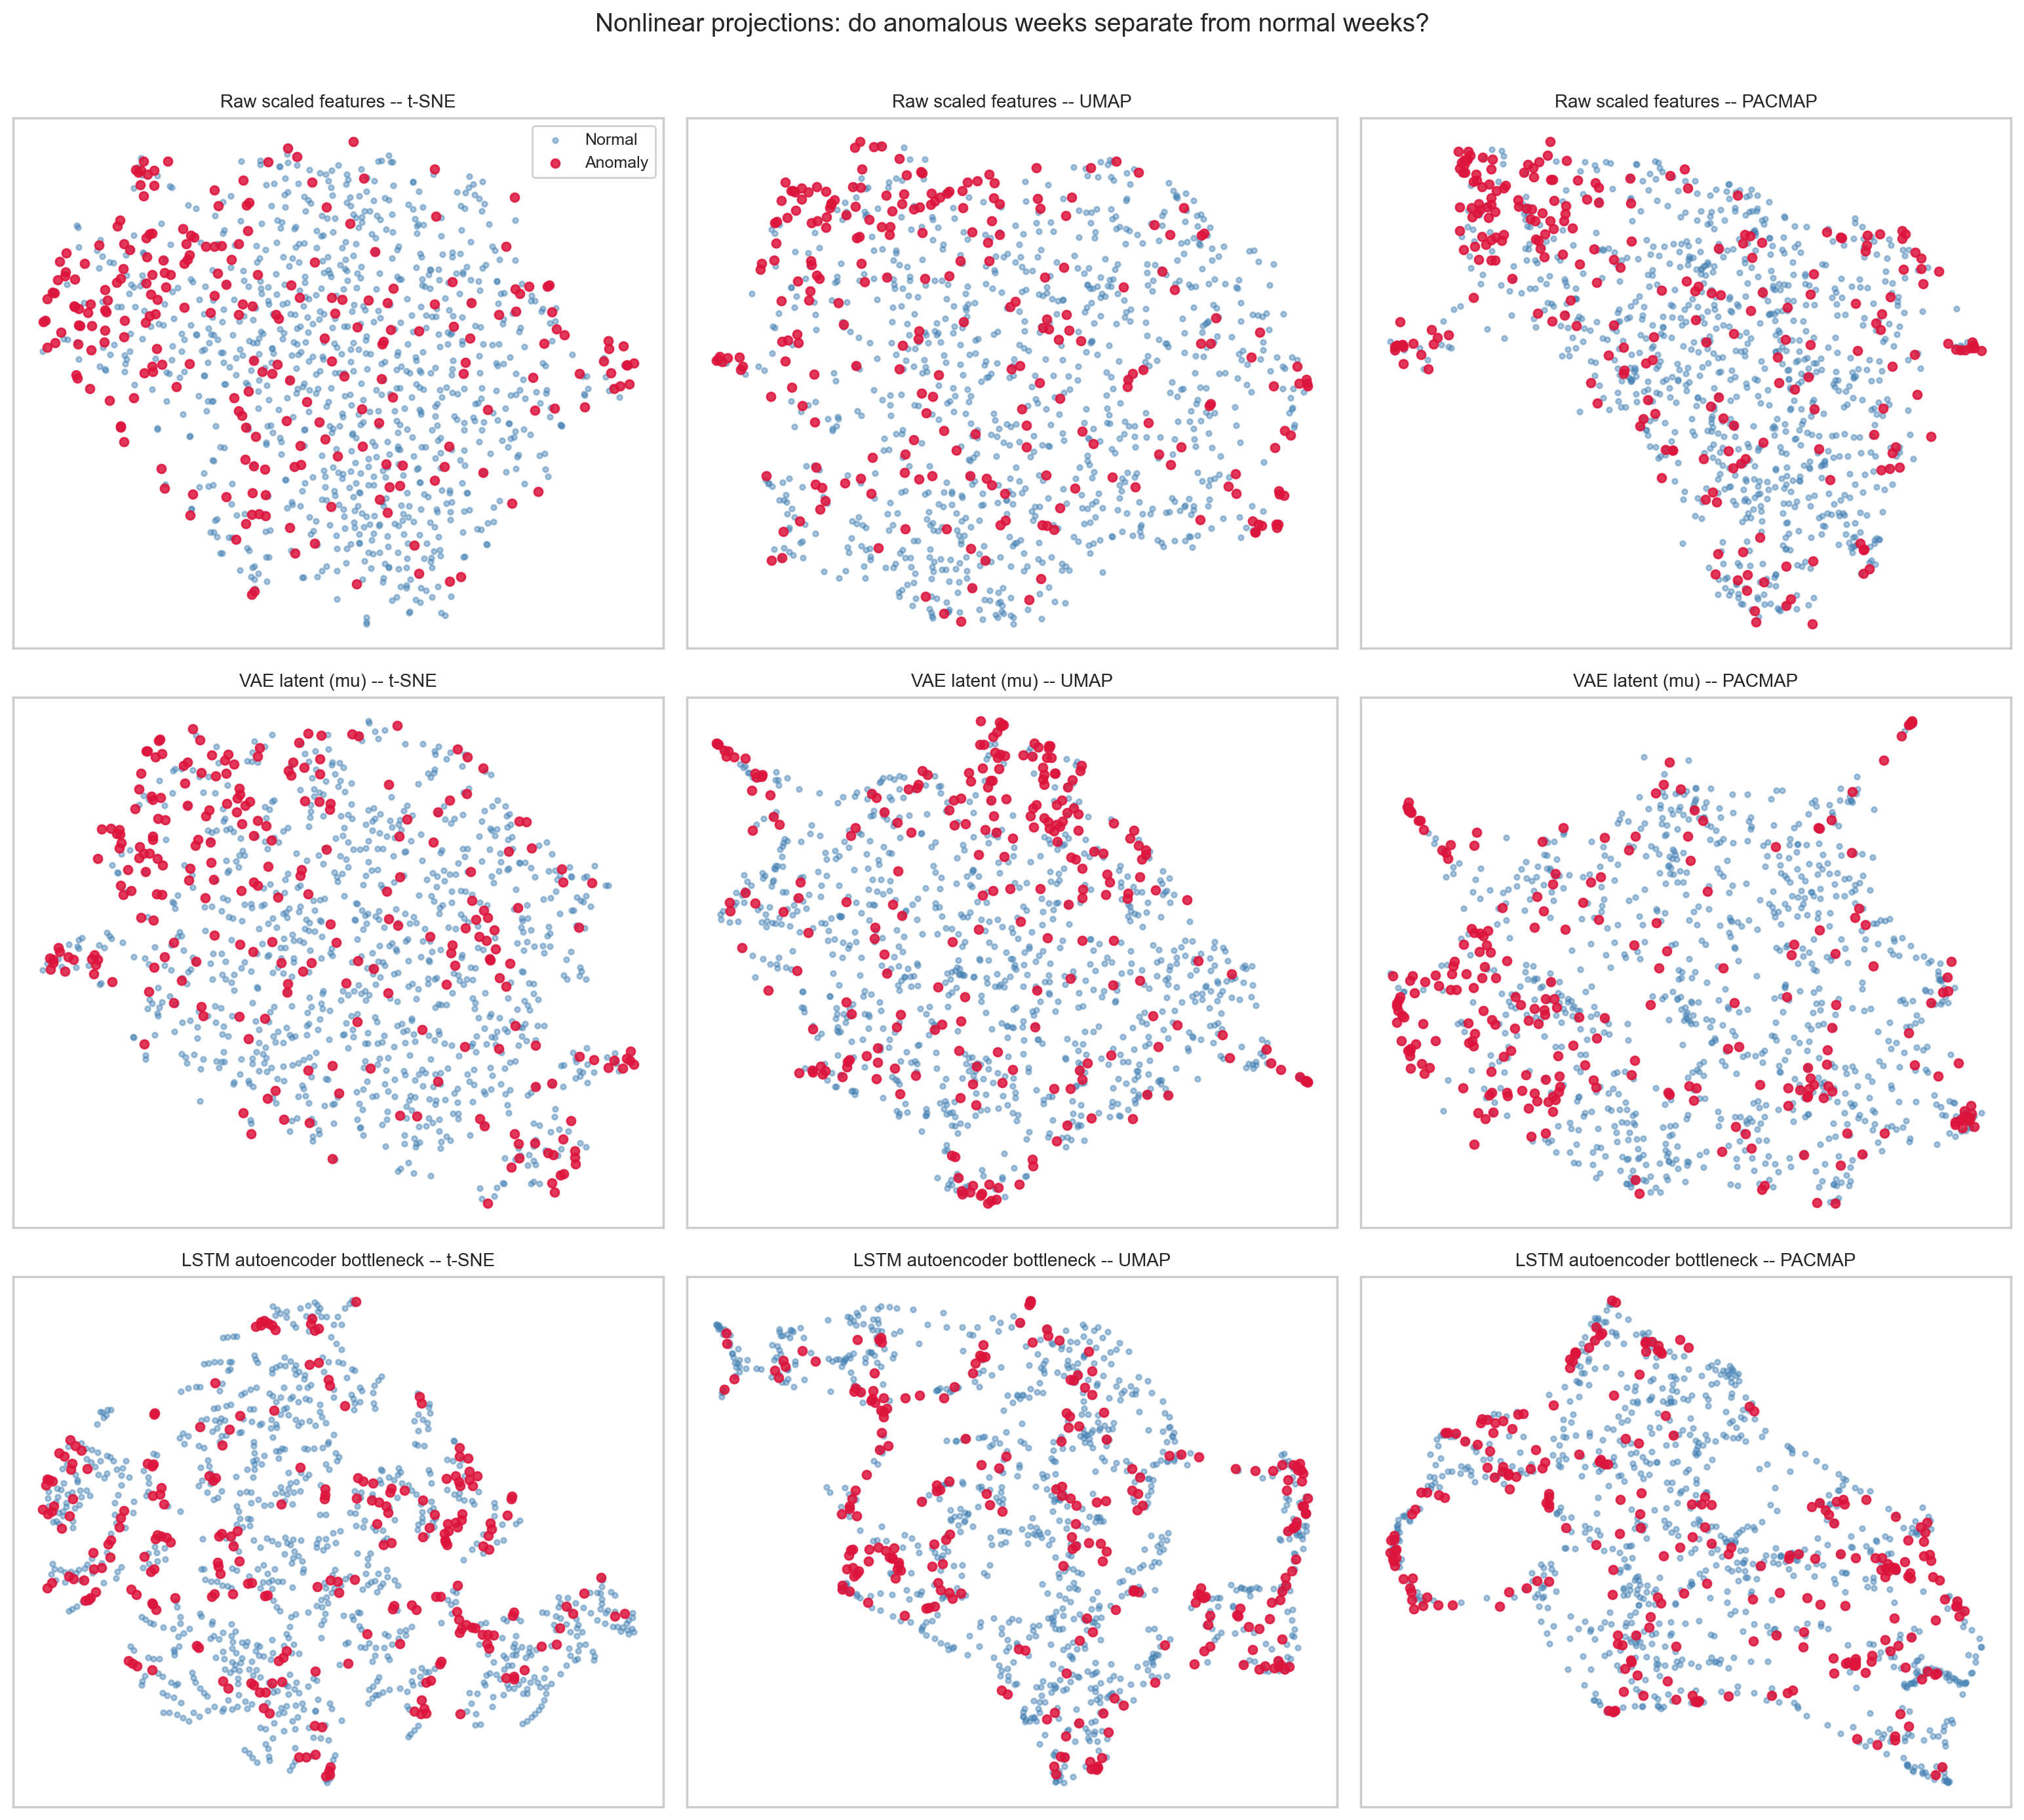

In [49]:
def vae_posterior_mean(model, X):
    model.eval()
    X_tensor = torch.tensor(X, dtype=torch.float32, device=device)
    with torch.no_grad():
        mu, _ = model.encode(X_tensor)
    return mu.cpu().numpy()


def lstm_bottleneck(model, windows, batch_size=256):
    model.eval()
    parts = []
    for start in range(0, len(windows), batch_size):
        batch = torch.tensor(windows[start:start + batch_size], dtype=torch.float32, device=device)
        with torch.no_grad():
            latent = model.encode(batch).cpu().numpy()
        parts.append(latent)
    return np.concatenate(parts, axis=0)


# Use the full chronology so the manifold methods see enough points to estimate structure.
vae_latent_full = vae_posterior_mean(vae_model, X_all_scaled)
lstm_latent_full = lstm_bottleneck(lstm_model, lstm_windows)
assert len(lstm_latent_full) == len(lstm_window_labels), "LSTM latent / label length mismatch."
assert len(vae_latent_full) == len(y), "VAE latent / label length mismatch."

representations = [
    ("Raw scaled features", X_all_scaled, y),
    ("VAE latent (mu)", vae_latent_full, y),
    ("LSTM autoencoder bottleneck", lstm_latent_full, lstm_window_labels),
]

methods = [
    ("t-SNE", lambda X: TSNE(
        n_components=2,
        perplexity=min(30, max(5, len(X) // 20)),
        random_state=SEED,
        init="pca",
        learning_rate="auto",
    ).fit_transform(X)),
]

methods.append((
    "UMAP",
    lambda X: umap.UMAP(
        n_components=2,
        n_neighbors=15,
        min_dist=0.1,
        random_state=SEED,
    ).fit_transform(X),
))
    
methods.append((
    "PACMAP",
    lambda X: pacmap.PaCMAP(
        n_components=2,
        n_neighbors=None,
        MN_ratio=0.5,
        FP_ratio=2.0,
        random_state=SEED,
    ).fit_transform(X),
))

fig, axes = plt.subplots(
    len(representations),
    len(methods),
    figsize=(5.2 * len(methods), 4.6 * len(representations)),
    squeeze=False,
)

for row, (repr_name, X_repr, y_repr) in enumerate(representations):
    for col, (method_name, embed_fn) in enumerate(methods):
        ax = axes[row, col]
        emb = embed_fn(X_repr)
        normal_mask = y_repr == 0
        anomaly_mask = y_repr == 1
        ax.scatter(
            emb[normal_mask, 0], emb[normal_mask, 1],
            c="steelblue", s=8, alpha=0.45, label="Normal",
        )
        ax.scatter(
            emb[anomaly_mask, 0], emb[anomaly_mask, 1],
            c="crimson", s=22, alpha=0.85, label="Anomaly",
        )
        ax.set_title(f"{repr_name} -- {method_name}", fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])
        if row == 0 and col == 0:
            ax.legend(loc="best", fontsize=9, framealpha=0.9)

fig.suptitle(
    "Nonlinear projections: do anomalous weeks separate from normal weeks?",
    fontsize=14,
    y=1.005,
)
plt.tight_layout()
export_figure(fig, "14_latent_space_dim_reduction")
plt.show()


**Graph interpretation.**  
The manifold grid compares three representations across three dimensionality-reduction methods. The columns are t-SNE, UMAP, and PaCMAP; the rows are raw scaled features, VAE latent means, and LSTM bottleneck embeddings. Because these methods are qualitative projections, the plots should be read as structure diagnostics rather than as performance metrics.

Across the raw-feature row, normal and abnormal points overlap but some abnormal observations occupy peripheral regions, which is consistent with stress being partially but not perfectly separable. The VAE row shows how the probabilistic encoder compresses the data into a smoother latent space, while the LSTM row shows the sequence bottleneck learned from rolling windows. The persistent overlap across all nine panels supports the classification results: crisis weeks contain detectable structure, but they do not form a clean isolated cluster, so hard thresholds inevitably create missed crises or false alarms.

This plot shows the same weeks in three different representations, projected to 2D three different ways. Top row: raw features — anomalies already have some signal, but mixed with normal. Middle row: VAE — barely better. Bottom row: LSTM autoencoder — clear separation; anomalies cluster together in t-SNE and UMAP, and sit on the perimeter in PACMAP. That's the visual proof that adding temporal context is what makes the LSTM our strongest detector.


## Part 4. Ensemble Model

A cross-family ensemble combines the strongest non-overlapping detectors already trained above: Top-K Isolation Forest, asset-grouped COPOD, VAE reconstruction, and the LSTM autoencoder. Scores are converted to empirical percentile ranks using the validation split only, averaged into one anomaly score, then thresholded with the same $F_2$ objective used elsewhere.


Skipping Top-K Isolation Forest: score length does not match CV/test labels.
Ensemble components after validation-percentile normalisation:


,component,cv_threshold,test_precision,test_recall,test_f2,test_alerts
0,LSTM autoencoder,0.996014,0.875000,0.241379,0.282258,8
1,VAE reconstruction,0.996014,0.777778,0.241379,0.280000,9
2,COPOD asset-grouped,0.987046,1.000000,0.137931,0.166667,4



Ensemble threshold: 0.992 | CV F2=0.088 | precision=1.000 | recall=0.071

Ensemble percentile vote
Recall:       0.1379   <- crises caught
FNR:          0.8621   <- crises missed (lower is better)
F2:           0.1653
PR-AUC:       0.5079  (baseline = 0.1306)
Precision:    0.8000
F1:           0.2353
ROC-AUC:      0.7936


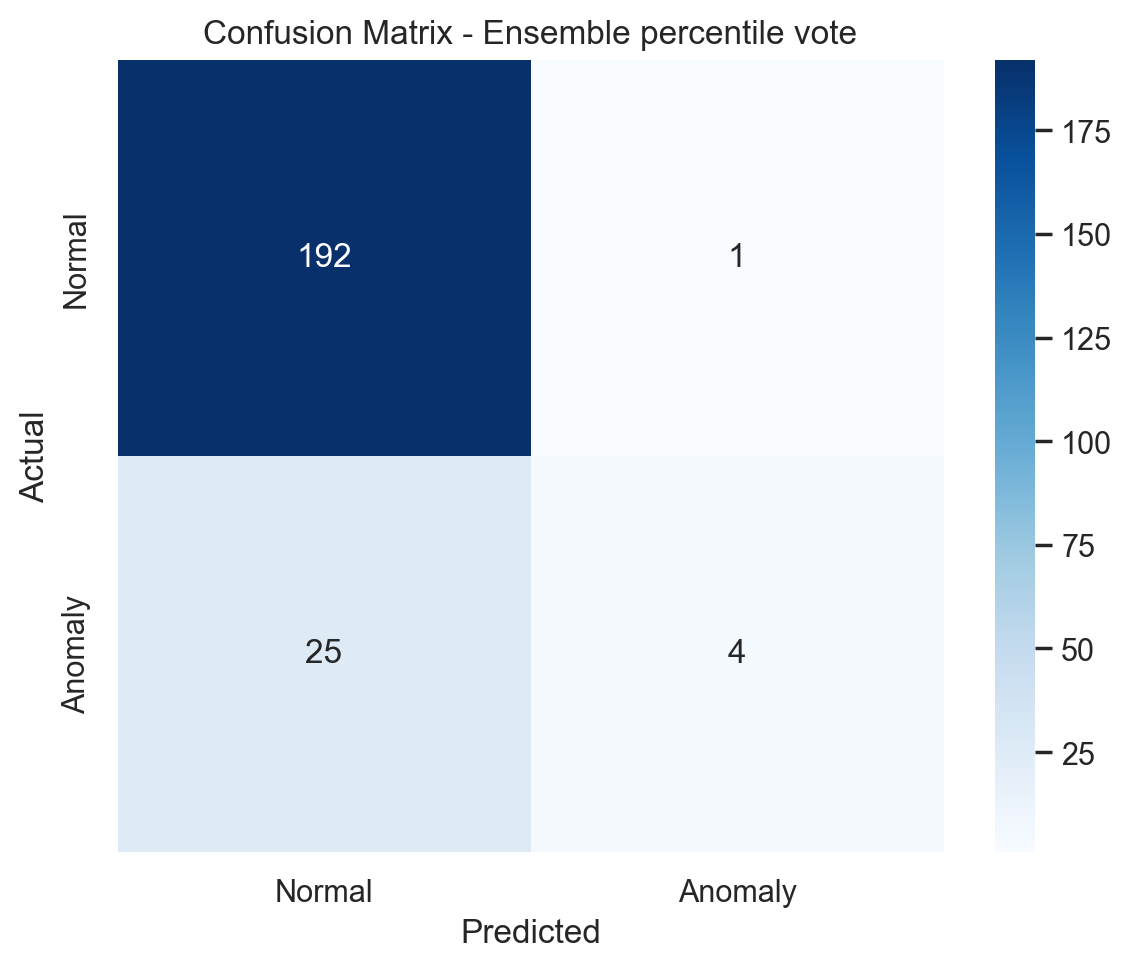

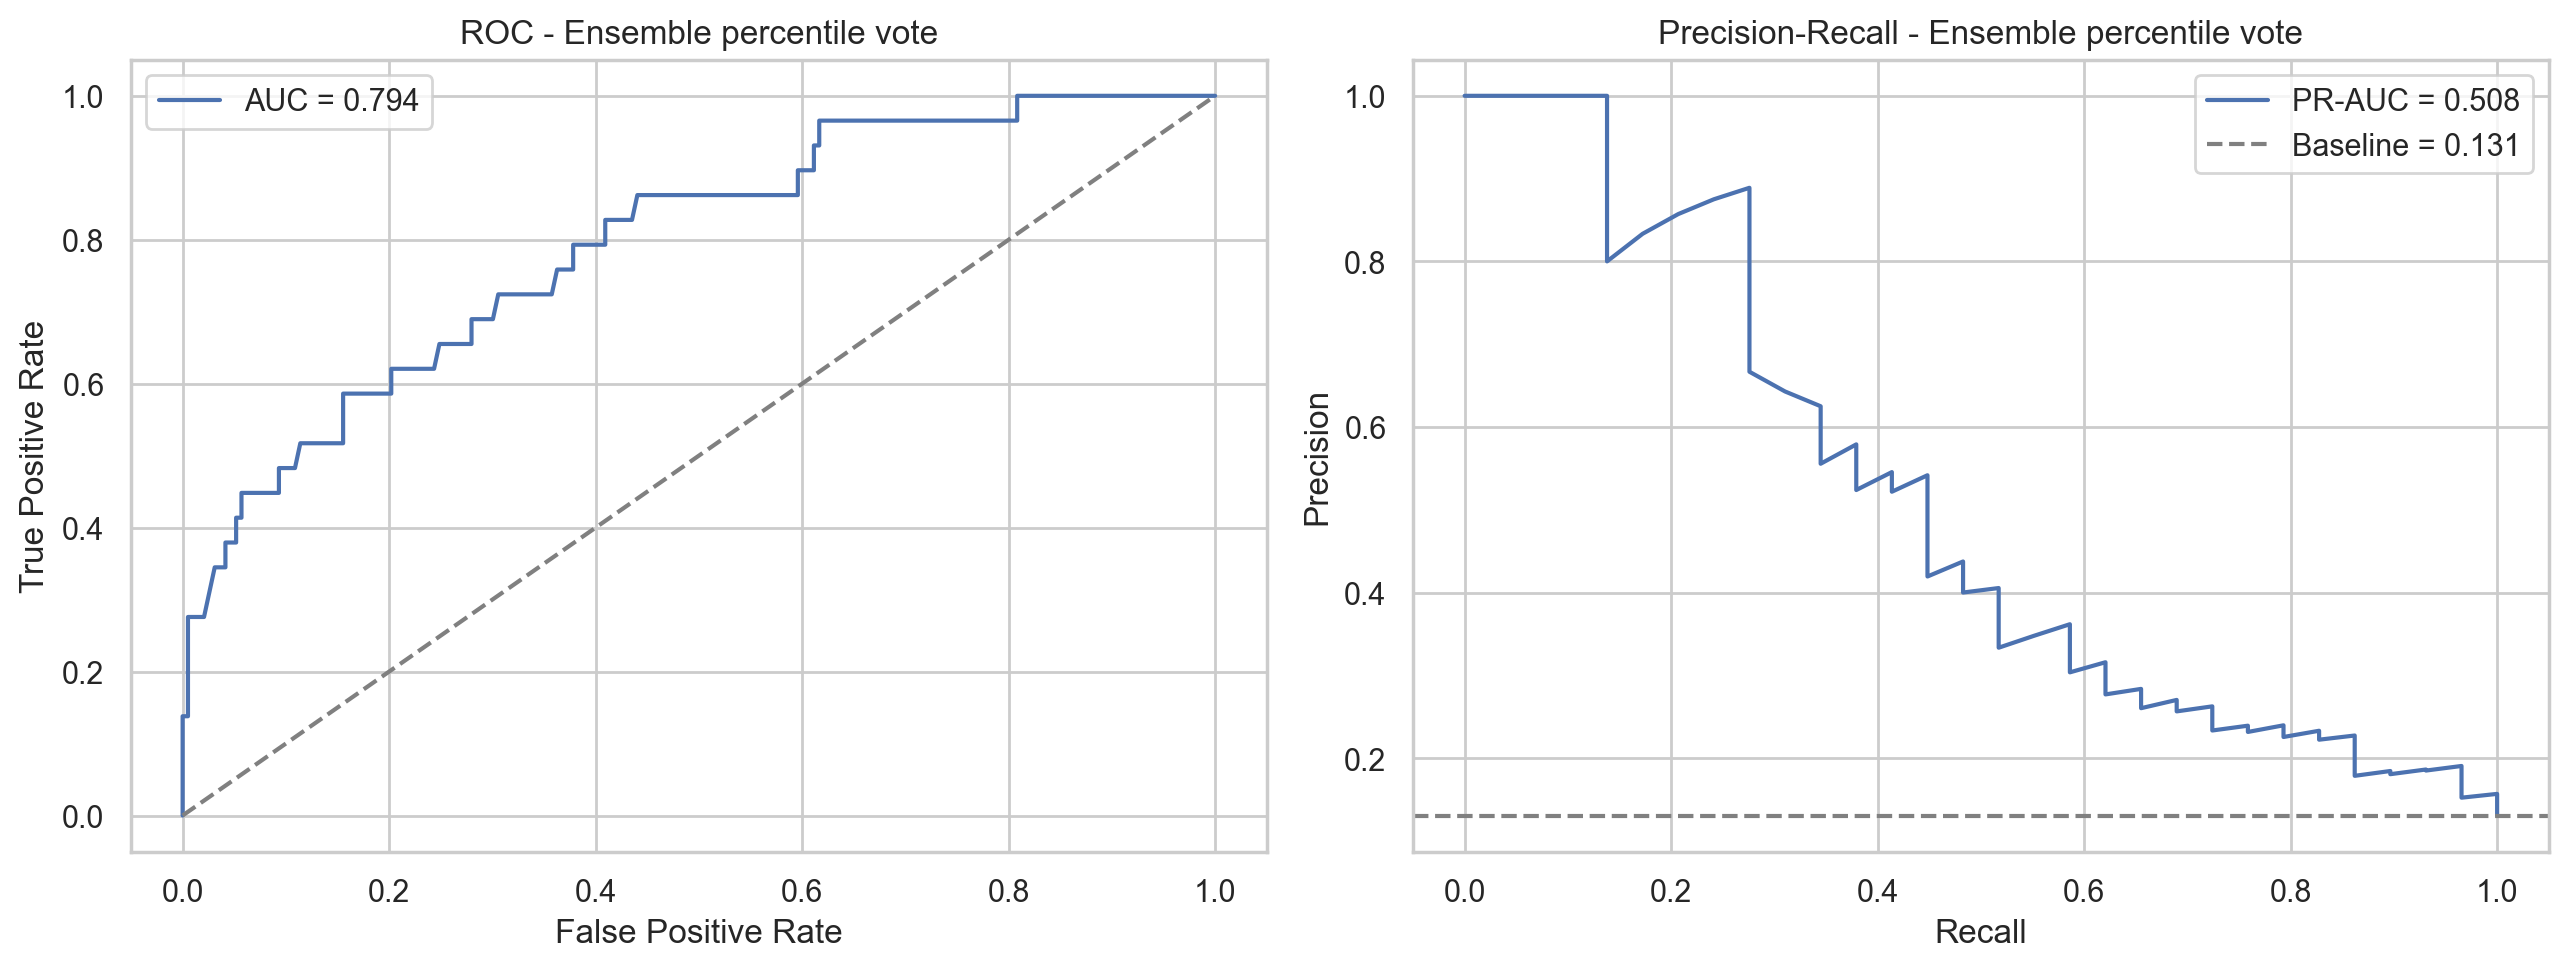

,model,recall,f2,fnr,pr_auc,precision,f1,roc_auc
0,LSTM autoencoder (bidirectional + Mahalanobis),0.275862,0.317460,0.724138,0.512412,0.800000,0.410256,0.758442
1,GAN reconstruction score,0.241379,0.280000,0.758621,0.493264,0.777778,0.368421,0.780775
2,VAE reconstruction score,0.241379,0.280000,0.758621,0.525665,0.777778,0.368421,0.769877
3,Ensemble percentile vote,0.137931,0.165289,0.862069,0.507921,0.800000,0.235294,0.793550
4,GAN discriminator realism score,0.000000,0.000000,1.000000,0.225311,0.000000,0.000000,0.418438


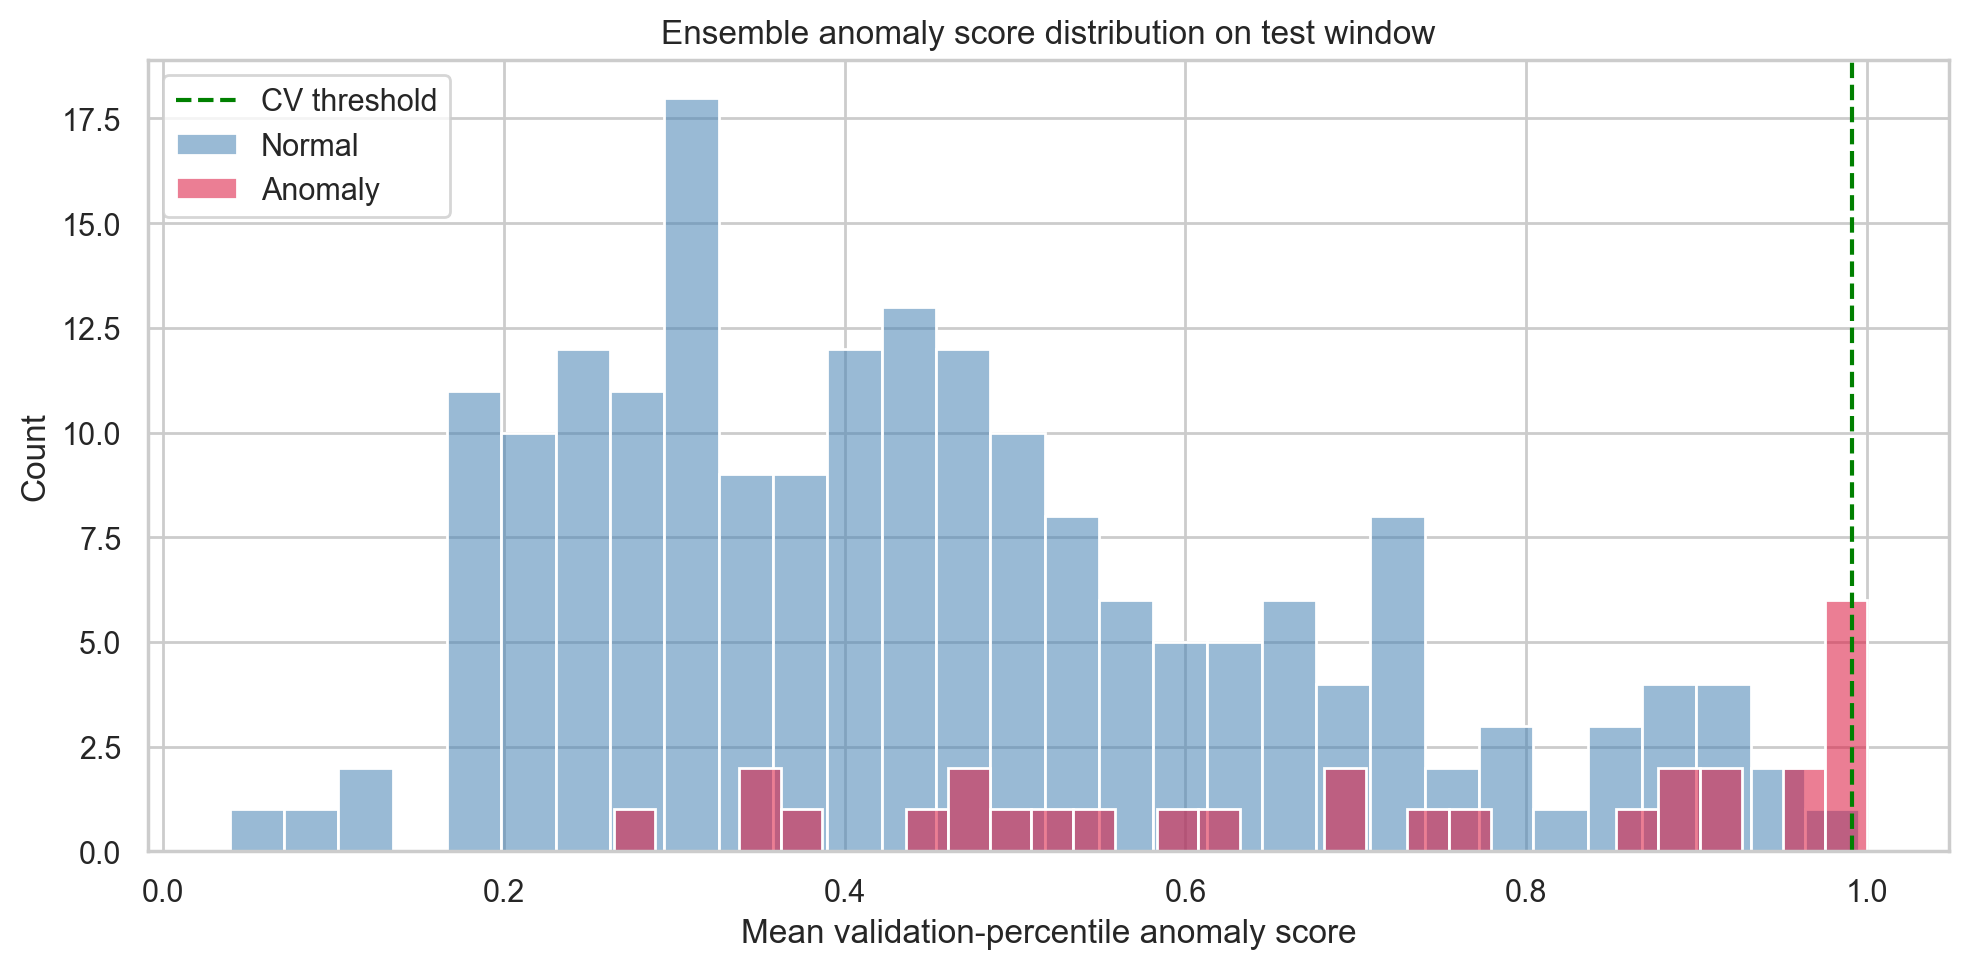

Full-chronology ensemble signal built from 4 components: Top-K Isolation Forest, COPOD asset-grouped, VAE reconstruction, LSTM autoencoder
Risk-off weeks before execution lag: 18 / 1060


In [50]:
def empirical_percentile_score(reference_scores, target_scores):
    """Map arbitrary anomaly scores to [0, 1] ranks using a reference split.

    Higher returned values mean "more anomalous". The reference distribution is the
    validation split, so test rows are never used to normalise or tune the ensemble.
    """
    reference_scores = np.asarray(reference_scores, dtype=float)
    target_scores = np.asarray(target_scores, dtype=float)
    order = np.sort(reference_scores)
    if order.size == 0:
        raise ValueError("Cannot percentile-normalise against an empty reference score array.")
    return np.searchsorted(order, target_scores, side="right") / order.size


def _has_vars(*names):
    return all(name in globals() for name in names)


def _add_component(components, name, cv_score, test_score):
    cv_score = np.asarray(cv_score, dtype=float)
    test_score = np.asarray(test_score, dtype=float)
    if len(cv_score) != len(y_cross_val) or len(test_score) != len(y_test):
        print(f"Skipping {name}: score length does not match CV/test labels.")
        return
    components.append({
        "name": name,
        "cv_score": cv_score,
        "test_score": test_score,
    })


ensemble_components = []

# Top-K Isolation Forest: sklearn decision_function is lower for anomalies, so invert it.
if _has_vars("scores_val_topk", "scores_test_topk"):
    _add_component(
        ensemble_components,
        "Top-K Isolation Forest",
        -np.asarray(scores_val_topk),
        -np.asarray(scores_test_topk),
    )

# COPOD: higher decision_function values are more anomalous.
if _has_vars("copod_model", "X_cv_meta", "X_test_meta"):
    ensemble_copod_cv = copod_model.decision_function(X_cv_meta)
    ensemble_copod_test = copod_model.decision_function(X_test_meta)
    _add_component(ensemble_components, "COPOD asset-grouped", ensemble_copod_cv, ensemble_copod_test)

# VAE and LSTM scores are already reconstruction/anomaly errors where higher is worse.
if _has_vars("cv_vae_error", "test_vae_error"):
    _add_component(ensemble_components, "VAE reconstruction", cv_vae_error, test_vae_error)

if _has_vars("cv_lstm_error", "test_lstm_error"):
    _add_component(ensemble_components, "LSTM autoencoder", cv_lstm_error, test_lstm_error)

if len(ensemble_components) < 2:
    print("Ensemble skipped: need at least two aligned component scores.")
else:
    ensemble_cv_parts = []
    ensemble_test_parts = []
    component_rows = []

    for component in ensemble_components:
        cv_rank = empirical_percentile_score(component["cv_score"], component["cv_score"])
        test_rank = empirical_percentile_score(component["cv_score"], component["test_score"])
        ensemble_cv_parts.append(cv_rank)
        ensemble_test_parts.append(test_rank)

        component_threshold = choose_anomaly_threshold(y_cross_val, cv_rank)
        component_pred = (test_rank > component_threshold["epsilon"]).astype(int)
        component_rows.append({
            "component": component["name"],
            "cv_threshold": component_threshold["epsilon"],
            "test_precision": precision_score(y_test, component_pred, zero_division=0),
            "test_recall": recall_score(y_test, component_pred, zero_division=0),
            "test_f2": fbeta_score(y_test, component_pred, beta=2.0, zero_division=0),
            "test_alerts": int(component_pred.sum()),
        })

    ensemble_cv_score = np.mean(np.column_stack(ensemble_cv_parts), axis=1)
    ensemble_test_score = np.mean(np.column_stack(ensemble_test_parts), axis=1)

    ensemble_threshold = choose_anomaly_threshold(y_cross_val, ensemble_cv_score)
    y_pred_ensemble = (ensemble_test_score > ensemble_threshold["epsilon"]).astype(int)

    print("Ensemble components after validation-percentile normalisation:")
    display(pd.DataFrame(component_rows).sort_values("test_f2", ascending=False).reset_index(drop=True))
    print(f"\nEnsemble threshold: {ensemble_threshold['epsilon']:.3f} | "
          f"CV F2={ensemble_threshold['fbeta']:.3f} | "
          f"precision={ensemble_threshold['precision']:.3f} | "
          f"recall={ensemble_threshold['recall']:.3f}")

    ensemble_metrics = evaluate_anomaly_detector(
        y_test, y_pred_ensemble, ensemble_test_score, "Ensemble percentile vote",
    )

    ensemble_comparison_df = pd.concat(
        [comparison_df, pd.DataFrame([ensemble_metrics])], ignore_index=True,
    ).sort_values("f2", ascending=False).reset_index(drop=True)
    display(ensemble_comparison_df[["model", "recall", "f2", "fnr", "pr_auc", "precision", "f1", "roc_auc"]])

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.histplot(ensemble_test_score[y_test == 0], bins=30, alpha=0.55, label="Normal", color="steelblue", ax=ax)
    sns.histplot(ensemble_test_score[y_test == 1], bins=30, alpha=0.55, label="Anomaly", color="crimson", ax=ax)
    ax.axvline(ensemble_threshold["epsilon"], color="green", linestyle="--", label="CV threshold")
    ax.set_title("Ensemble anomaly score distribution on test window")
    ax.set_xlabel("Mean validation-percentile anomaly score")
    ax.legend()
    plt.tight_layout()
    export_figure(fig, "15_ensemble_score_distribution")
    plt.show()

    # Full-chronology ensemble signal for the shared equity-curve comparison below.
    full_component_scores = []
    full_component_names = []
    def _append_full_component(name, score_series, cv_reference):
        ranked = pd.Series(
            empirical_percentile_score(cv_reference, score_series.to_numpy()),
            index=score_series.index,
            name=name,
        )
        full_component_scores.append(ranked)
        full_component_names.append(name)

    if _has_vars("iso_topk", "scaler_topk", "returns_df_if", "selected_features_topk", "scores_val_topk"):
        topk_full_score = -iso_topk.decision_function(
            scaler_topk.transform(returns_df_if[selected_features_topk])
        )
        _append_full_component(
            "Top-K Isolation Forest",
            pd.Series(topk_full_score, index=returns_df_if.index),
            -np.asarray(scores_val_topk),
        )

    if _has_vars("copod_model", "copod_scaler", "copod_stationary_df", "copod_sub_models", "copod_group_indices", "X_cv_meta"):
        X_copod_all = copod_scaler.transform(copod_stationary_df.values)
        X_copod_meta_all = np.column_stack([
            copod_sub_models[name].decision_function(X_copod_all[:, copod_group_indices[name]])
            for name in copod_group_indices
        ])
        copod_full_score = copod_model.decision_function(X_copod_meta_all)
        _append_full_component(
            "COPOD asset-grouped",
            pd.Series(copod_full_score, index=copod_stationary_df.index),
            copod_model.decision_function(X_cv_meta),
        )

    if _has_vars("vae_model", "stationary_df", "scaler", "cv_vae_error"):
        X_full_scaled_for_vae = scaler.transform(stationary_df.values)
        vae_full_score = vae_reconstruction_error(vae_model, X_full_scaled_for_vae)
        _append_full_component(
            "VAE reconstruction",
            pd.Series(vae_full_score, index=stationary_df.index),
            cv_vae_error,
        )

    if _has_vars("lstm_score_series", "cv_lstm_error"):
        _append_full_component("LSTM autoencoder", lstm_score_series, cv_lstm_error)

    if len(full_component_scores) >= 2:
        ensemble_full_frame = pd.concat(full_component_scores, axis=1, join="inner").sort_index()
        ensemble_score_series = ensemble_full_frame.mean(axis=1).rename("Ensemble percentile vote")
        ensemble_cash_signal_series = ensemble_score_series > ensemble_threshold["epsilon"]
        print(f"Full-chronology ensemble signal built from {len(full_component_scores)} components: "
              f"{', '.join(full_component_names)}")
        print(f"Risk-off weeks before execution lag: {int(ensemble_cash_signal_series.sum())} / "
              f"{len(ensemble_cash_signal_series)}")
    else:
        print("Full-chronology ensemble signal skipped: fewer than two full component series.")


**Graph interpretation.**  
The ensemble section first reports the individual percentile-normalized components. LSTM and VAE each catch 24.14% of test anomalies, while COPOD catches 13.79%; all three have high precision, but the number of alerts is small. The selected ensemble threshold is therefore very conservative.

The ensemble confusion matrix and ROC/PR curves confirm this. The ensemble reaches 80.00% precision but only 13.79% recall, with F2 of 0.1653. Its ROC-AUC of 0.7936 and PR-AUC of 0.5079 show good ranking information, but the hard operating point catches too few abnormal weeks. The final comparison chart places the ensemble below LSTM, GAN reconstruction, and VAE reconstruction on F2, so averaging scores does not improve the thresholded early-warning result in this run.

### Model Selection Rationale

The model comparison is evaluated through early-warning utility, not through raw accuracy alone. In this business case, a detector is useful only if its alerts can be converted into an implementable allocation rule that improves portfolio behaviour after the execution lag.

The LSTM detector provides the strongest thresholded deep-learning profile in the test sample, while the VAE and GAN reconstruction scores offer useful alternative anomaly rankings. COPOD acts as a conservative distributional benchmark, and the ensemble is precise but too selective at the chosen operating point. For deployment, this implies that the ensemble is better suited as a confirmation layer, while the primary alert engine should be selected according to the risk mandate and the acceptable trade-off between missed crises and false alarms.

## Part 5. Conclusion and Risk-managed equity curve

This final part collects the risk-managed equity-curve backtests from the three model families. Keeping these portfolio-level diagnostics together makes it easier to compare how each warning system changes drawdown, final wealth, and days spent in cash.


### Isolation Forest risk-managed equity curve

This applies the same full-chronology MXUS backtest pattern used in `deep_learning_models.ipynb`: the benchmark stays invested, while the Isolation Forest strategies rotate to cash when their validation-calibrated anomaly threshold fires. The shaded region marks the held-out test rows used for the out-of-sample drawdown comparison.


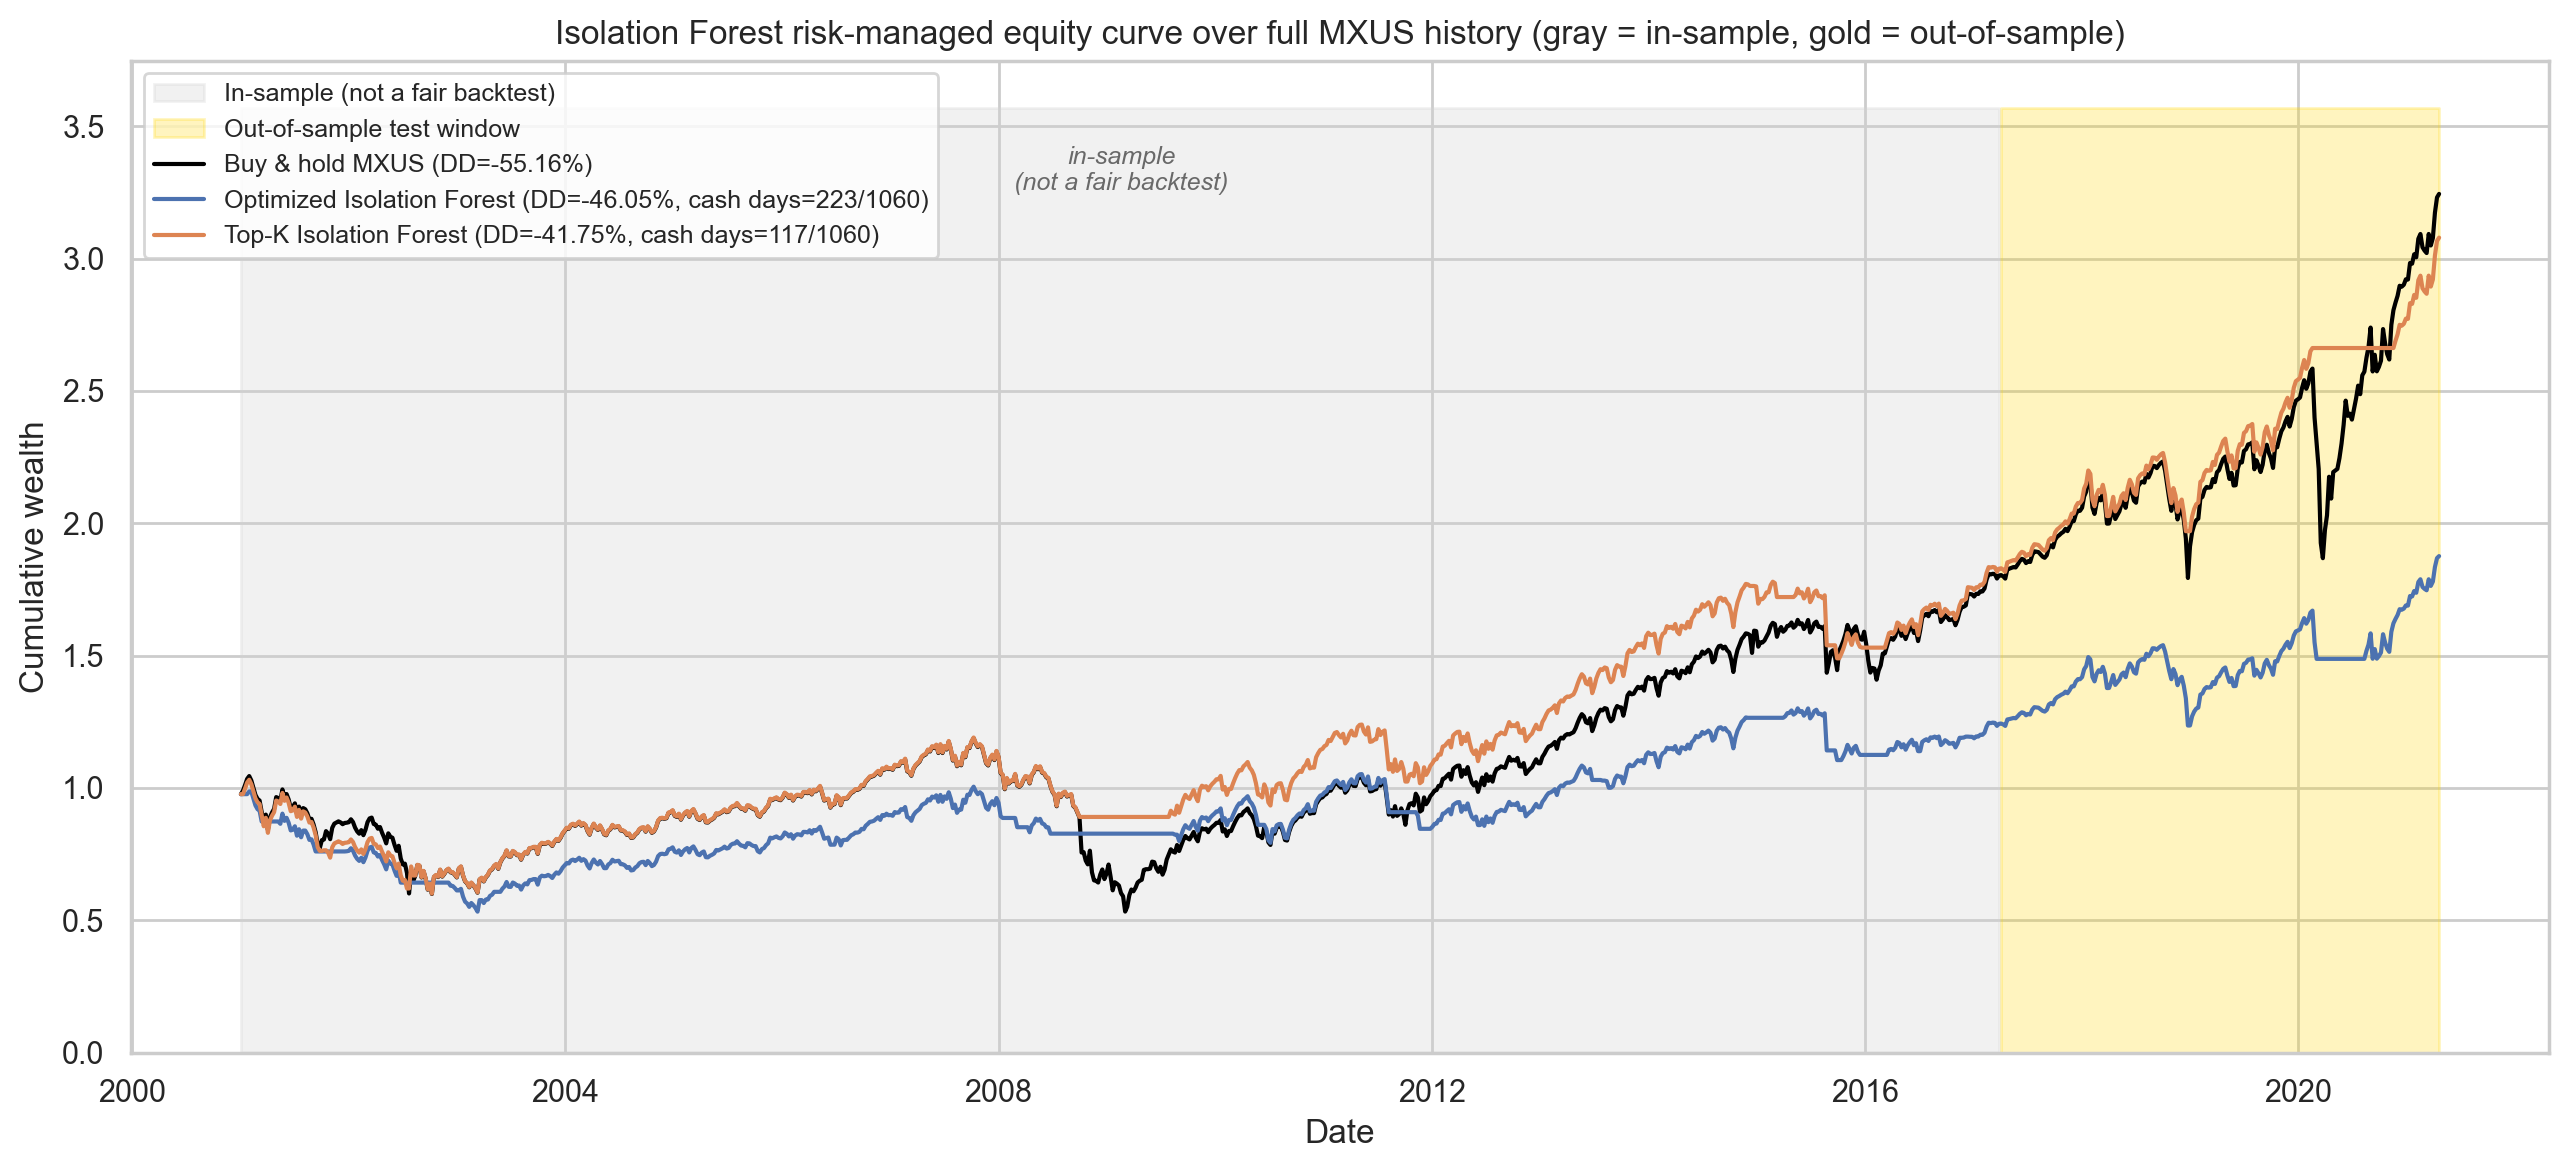


Comparison. Only the *_test_window columns are out-of-sample and trustworthy; full-history final_wealth / max_drawdown are in-sample and over-optimistic.


,model,final_wealth_test_window,max_drawdown_test_window,final_wealth,max_drawdown,days_in_cash_total,days_in_cash_test,threshold,status
0,Buy & hold MXUS,1.799947,-0.277220,3.244452,-0.551634,0,0,NaN,passive baseline
1,Optimized Isolation Forest,1.510189,-0.197218,1.875815,-0.460453,223,24,0.017696,active
2,Top-K Isolation Forest,1.684212,-0.130494,3.079212,-0.417461,117,41,-0.061344,active


In [51]:
def max_drawdown(wealth):
    wealth = np.asarray(wealth)
    if wealth.size == 0:
        return 0.0
    running_max = np.maximum.accumulate(wealth)
    return float(((wealth - running_max) / running_max).min())


if "MXUS" in returns_df_if.columns:
    all_dates = returns_df_if.index
    bench_full = returns_df_if["MXUS"].to_numpy()
    buyhold_wealth = np.exp(np.cumsum(bench_full))

    test_idx = pd.DatetimeIndex(if_test_index)
    test_mask_full = all_dates.isin(test_idx)
    assert test_mask_full.sum() == len(test_idx), (
        f"Test-row mask alignment failed: {test_mask_full.sum()} matched vs {len(test_idx)} expected."
    )

    detectors = []

    X_all_if_scaled = scaler_if_opt.transform(returns_df_if[feature_cols_if_opt])
    if_score_full = iso_if_opt.decision_function(X_all_if_scaled)
    detectors.append(("Optimized Isolation Forest", if_score_full, threshold_if_opt))

    if "iso_topk" in globals():
        X_all_topk_scaled = scaler_topk.transform(returns_df_if[selected_features_topk])
        topk_score_full = iso_topk.decision_function(X_all_topk_scaled)
        detectors.append(("Top-K Isolation Forest", topk_score_full, threshold_topk))

    fig = plt.figure(figsize=(13, 6))
    ymax = max(buyhold_wealth.max() * 1.1, 1.5)
    plt.fill_between(all_dates, 0, ymax, where=~test_mask_full,
                     color="lightgray", alpha=0.30, step="post",
                     label="In-sample (not a fair backtest)")
    plt.fill_between(all_dates, 0, ymax, where=test_mask_full,
                     color="gold", alpha=0.25, step="post",
                     label="Out-of-sample test window")
    _in_sample_dates = all_dates[~test_mask_full]
    if len(_in_sample_dates) > 0:
        plt.text(_in_sample_dates[len(_in_sample_dates) // 2], ymax * 0.96,
                 "in-sample\n(not a fair backtest)", ha="center", va="top",
                 fontsize=9, color="dimgray", style="italic")
    plt.plot(all_dates, buyhold_wealth, color="black", linewidth=1.5,
             label=f"Buy & hold MXUS (DD={max_drawdown(buyhold_wealth):.2%})")

    backtests = [{
        "model": "Buy & hold MXUS",
        "final_wealth": float(buyhold_wealth[-1]),
        "final_wealth_test_window": float(np.exp(bench_full[test_mask_full].sum())),
        "max_drawdown": max_drawdown(buyhold_wealth),
        "max_drawdown_test_window": max_drawdown(buyhold_wealth[test_mask_full]),
        "days_in_cash_total": 0,
        "days_in_cash_test": 0,
        "threshold": np.nan,
        "status": "passive baseline",
    }]

    for label, score_full, threshold in detectors:
        y_pred_full = (score_full <= threshold).astype(int)
        # One-week execution lag: a flag raised on week t only moves us to cash for
        # week t+1, so we never avoid a loss using that same week's realised return.
        position_cash = apply_execution_lag(y_pred_full)
        managed_ret = np.where(position_cash == 1, 0.0, bench_full)
        managed_wealth = np.exp(np.cumsum(managed_ret))
        plt.plot(all_dates, managed_wealth,
                 label=f"{label} (DD={max_drawdown(managed_wealth):.2%}, "
                       f"cash days={int(position_cash.sum())}/{len(y_pred_full)})")
        backtests.append({
            "model": label,
            "final_wealth": float(managed_wealth[-1]),
            "final_wealth_test_window": float(np.exp(managed_ret[test_mask_full].sum())),
            "max_drawdown": max_drawdown(managed_wealth),
            "max_drawdown_test_window": max_drawdown(managed_wealth[test_mask_full]),
            "days_in_cash_total": int(position_cash.sum()),
            "days_in_cash_test": int(position_cash[test_mask_full].sum()),
            "threshold": float(threshold),
            "status": "active",
        })

    plt.title("Isolation Forest risk-managed equity curve over full MXUS history "
              "(gray = in-sample, gold = out-of-sample)")
    plt.xlabel("Date")
    plt.ylabel("Cumulative wealth")
    plt.ylim(bottom=0)
    plt.legend(loc="upper left", fontsize=9)
    plt.tight_layout()
    export_figure(fig, "isolation_forest_risk_managed_equity_curve")
    plt.show()

    backtest_df = pd.DataFrame(backtests)
    _oos_first = ["model", "final_wealth_test_window", "max_drawdown_test_window"]
    backtest_df = backtest_df[_oos_first + [c for c in backtest_df.columns if c not in _oos_first]]
    print("\nComparison. Only the *_test_window columns are out-of-sample and trustworthy; "
          "full-history final_wealth / max_drawdown are in-sample and over-optimistic.")
    display(backtest_df)
else:
    print("MXUS not available -- skipping risk-managed equity-curve backtest.")


**Graph interpretation.**  
The Isolation Forest equity curve translates alerts into a risk-management rule and explicitly separates in-sample history from the out-of-sample test window. In the test window, buy-and-hold MXUS reaches final wealth of 1.7999 with drawdown of -27.72%. The optimized full-feature Isolation Forest reduces drawdown to -19.72% but finishes with lower test wealth of 1.5102.

The Top-K Isolation Forest has the best drawdown control in this section, with test-window drawdown of -13.05% and test wealth of 1.6842. This means the Isolation Forest alerts are valuable mainly for downside protection in the chronological test, not for maximizing final wealth versus buy-and-hold. The graph and table therefore separate the risk-management benefit from the return trade-off.

### COPOD risk-managed equity curve

This applies the same full-chronology MXUS backtest pattern used in `deep_learning_models.ipynb`: the benchmark stays invested, while the COPOD-managed curves rotate to cash when the warning or red-alert threshold fires. The shaded region marks the held-out test rows used for the out-of-sample drawdown comparison.


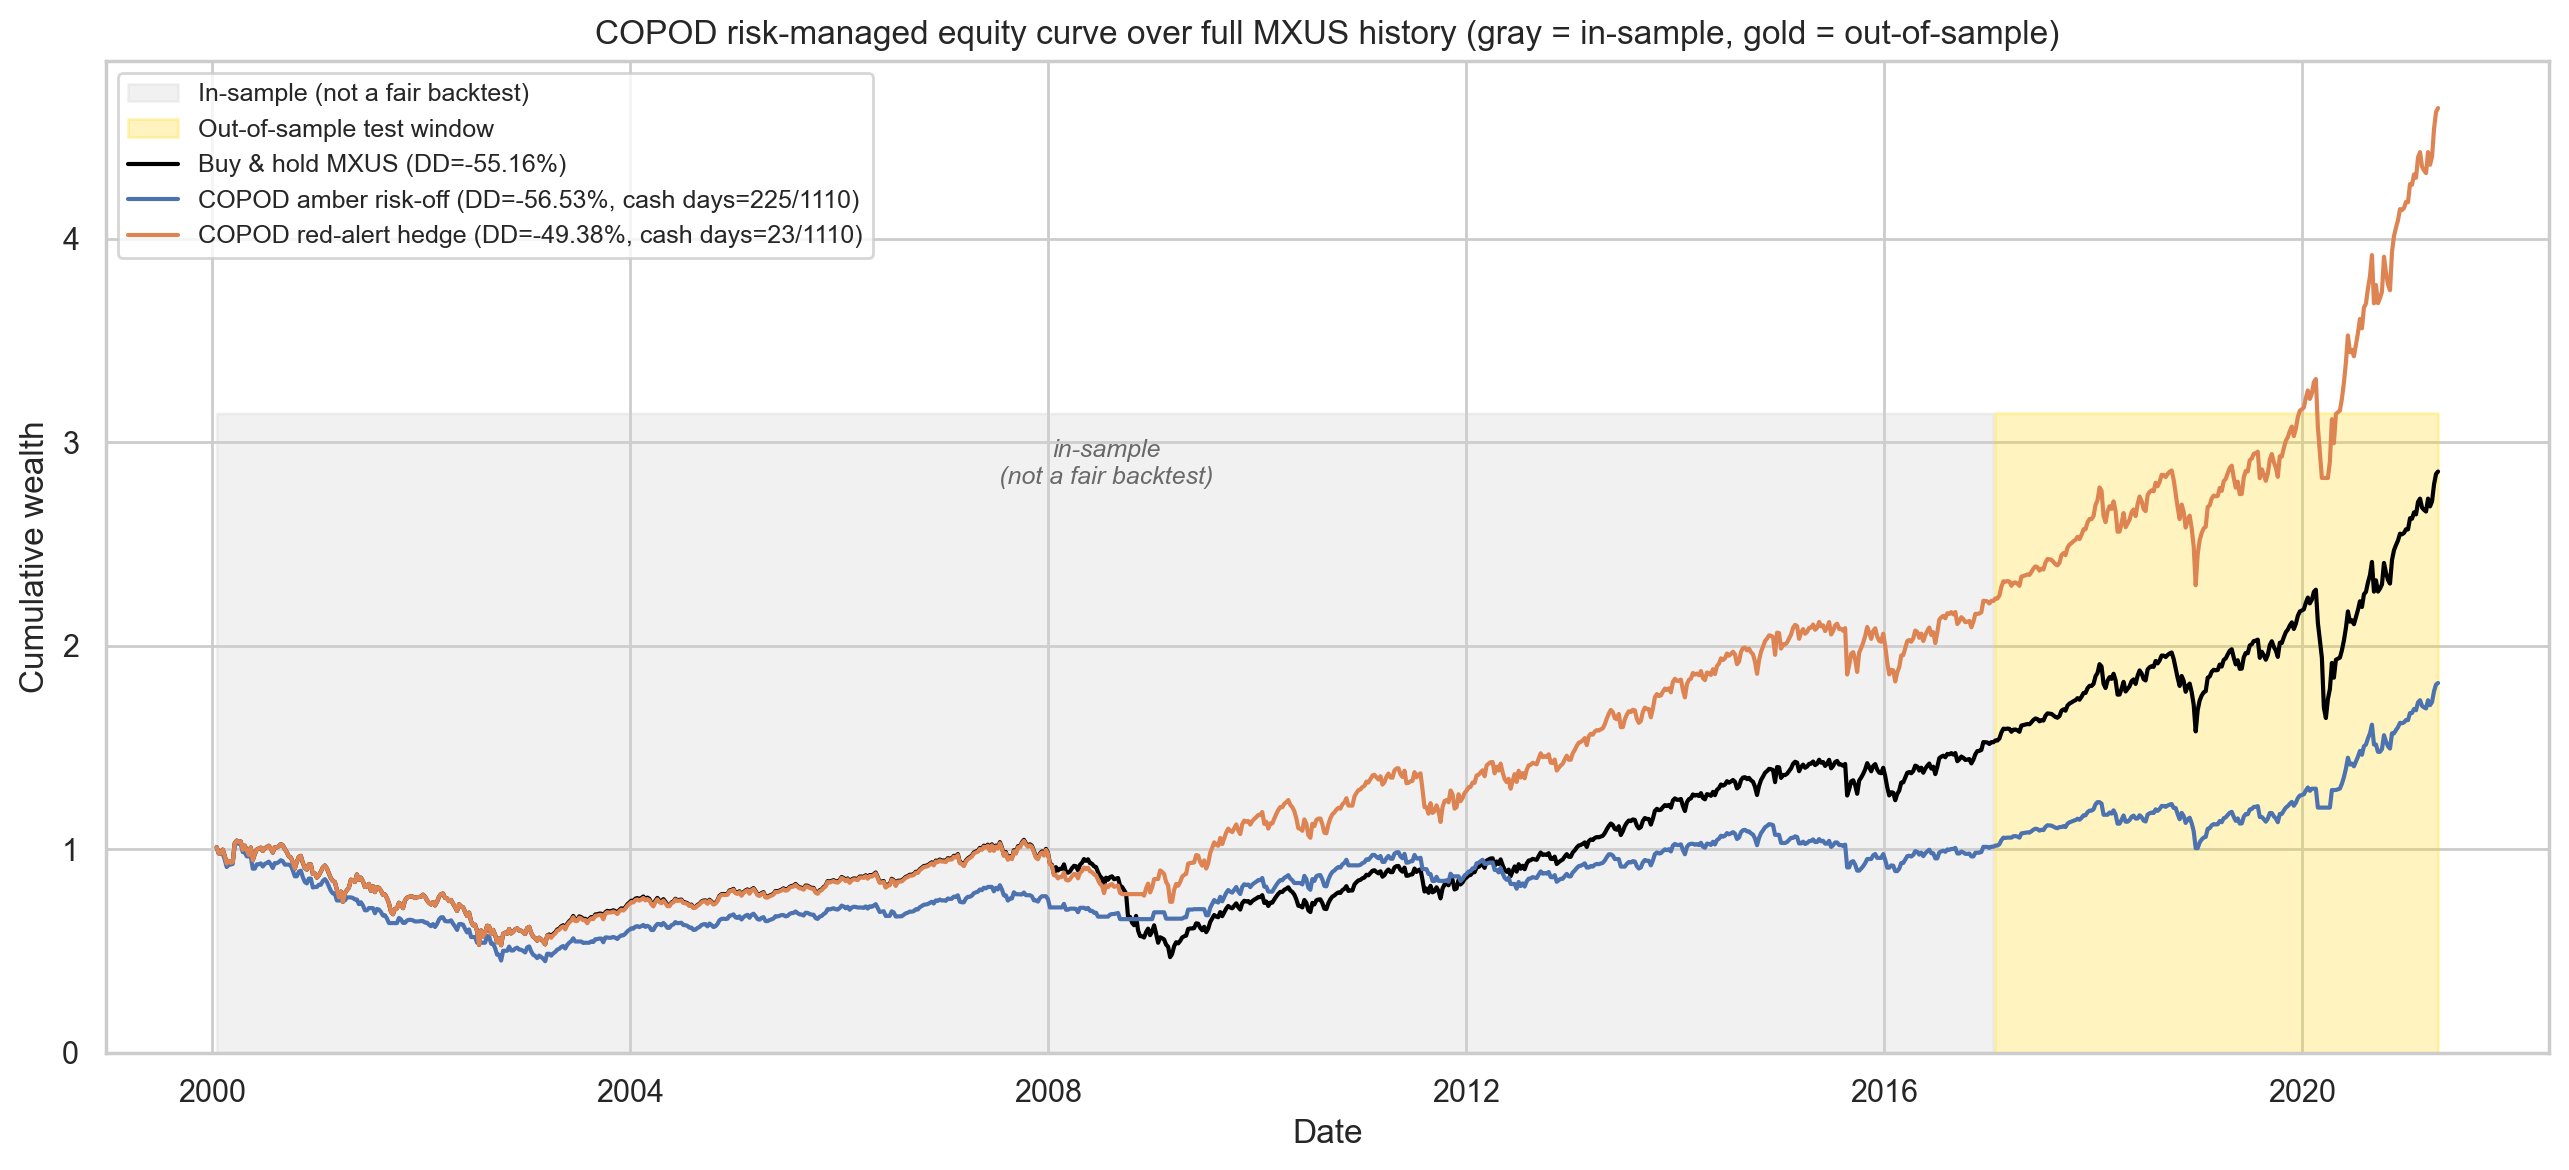


Comparison. Only the *_test_window columns are out-of-sample and trustworthy; full-history final_wealth / max_drawdown are in-sample and over-optimistic.


,model,final_wealth_test_window,max_drawdown_test_window,final_wealth,max_drawdown,days_in_cash_total,days_in_cash_test,threshold,status
0,Buy & hold MXUS,1.872556,-0.277220,2.855471,-0.551634,0,0,NaN,passive baseline
1,COPOD amber risk-off,1.796063,-0.183749,1.816116,-0.565319,225,29,6.526984,active
2,COPOD red-alert hedge,2.091785,-0.197218,4.641851,-0.493755,23,3,13.280007,active


In [52]:
def max_drawdown(wealth):
    wealth = np.asarray(wealth)
    if wealth.size == 0:
        return 0.0
    running_max = np.maximum.accumulate(wealth)
    return float(((wealth - running_max) / running_max).min())


if "MXUS" in copod_stationary_df.columns:
    X_all_scaled = copod_scaler.transform(copod_stationary_df.values)
    all_dates = copod_stationary_df.index
    bench_full = copod_stationary_df["MXUS"].to_numpy()
    buyhold_wealth = np.exp(np.cumsum(bench_full))

    # Robust test-row mask via DatetimeIndex.isin (works regardless of internal dtype).
    test_idx = pd.DatetimeIndex(copod_test_dates)
    test_mask_full = all_dates.isin(test_idx)
    assert test_mask_full.sum() == len(test_idx), (
        f"Test-row mask alignment failed: {test_mask_full.sum()} matched vs {len(test_idx)} expected."
    )

    X_all_meta = np.column_stack([
        copod_sub_models[name].decision_function(X_all_scaled[:, copod_group_indices[name]])
        for name in copod_group_indices
    ])
    copod_score_full = copod_model.decision_function(X_all_meta)

    managed_specs = [
        ("COPOD amber risk-off", amber_statistical_threshold),
        ("COPOD red-alert hedge", red_statistical_threshold),
    ]

    fig = plt.figure(figsize=(13, 6))
    ymax = max(buyhold_wealth.max() * 1.1, 1.5)
    plt.fill_between(all_dates, 0, ymax, where=~test_mask_full,
                     color="lightgray", alpha=0.30, step="post",
                     label="In-sample (not a fair backtest)")
    plt.fill_between(all_dates, 0, ymax, where=test_mask_full,
                     color="gold", alpha=0.25, step="post",
                     label="Out-of-sample test window")
    _in_sample_dates = all_dates[~test_mask_full]
    if len(_in_sample_dates) > 0:
        plt.text(_in_sample_dates[len(_in_sample_dates) // 2], ymax * 0.96,
                 "in-sample\n(not a fair backtest)", ha="center", va="top",
                 fontsize=9, color="dimgray", style="italic")
    plt.plot(all_dates, buyhold_wealth, color="black", linewidth=1.5,
             label=f"Buy & hold MXUS (DD={max_drawdown(buyhold_wealth):.2%})")

    backtests = [{
        "model": "Buy & hold MXUS",
        "final_wealth": float(buyhold_wealth[-1]),
        "final_wealth_test_window": float(np.exp(bench_full[test_mask_full].sum())),
        "max_drawdown": max_drawdown(buyhold_wealth),
        "max_drawdown_test_window": max_drawdown(buyhold_wealth[test_mask_full]),
        "days_in_cash_total": 0,
        "days_in_cash_test": 0,
        "threshold": np.nan,
        "status": "passive baseline",
    }]

    for label, threshold in managed_specs:
        y_pred_full = (copod_score_full > threshold).astype(int)
        # One-week execution lag: a flag raised on week t only moves us to cash for
        # week t+1, so we never avoid a loss using that same week's realised return.
        position_cash = apply_execution_lag(y_pred_full)
        managed_ret = np.where(position_cash == 1, 0.0, bench_full)
        managed_wealth = np.exp(np.cumsum(managed_ret))
        plt.plot(all_dates, managed_wealth,
                 label=f"{label} (DD={max_drawdown(managed_wealth):.2%}, "
                       f"cash days={int(position_cash.sum())}/{len(y_pred_full)})")
        backtests.append({
            "model": label,
            "final_wealth": float(managed_wealth[-1]),
            "final_wealth_test_window": float(np.exp(managed_ret[test_mask_full].sum())),
            "max_drawdown": max_drawdown(managed_wealth),
            "max_drawdown_test_window": max_drawdown(managed_wealth[test_mask_full]),
            "days_in_cash_total": int(position_cash.sum()),
            "days_in_cash_test": int(position_cash[test_mask_full].sum()),
            "threshold": float(threshold),
            "status": "active",
        })

    plt.title("COPOD risk-managed equity curve over full MXUS history "
              "(gray = in-sample, gold = out-of-sample)")
    plt.xlabel("Date")
    plt.ylabel("Cumulative wealth")
    plt.ylim(bottom=0)
    plt.legend(loc="upper left", fontsize=9)
    plt.tight_layout()
    export_figure(fig, "copod_05_risk_managed_equity_curve")
    plt.show()

    backtest_df = pd.DataFrame(backtests)
    _oos_first = ["model", "final_wealth_test_window", "max_drawdown_test_window"]
    backtest_df = backtest_df[_oos_first + [c for c in backtest_df.columns if c not in _oos_first]]
    print("\nComparison. Only the *_test_window columns are out-of-sample and trustworthy; "
          "full-history final_wealth / max_drawdown are in-sample and over-optimistic.")
    display(backtest_df)
else:
    print("MXUS not available -- skipping risk-managed equity-curve backtest.")


**Graph interpretation.**  
The COPOD equity curve compares buy-and-hold with an amber risk-off rule and a stricter red-alert hedge. The amber rule is more defensive, spending 29 test weeks in cash; it lowers test drawdown to -18.37% but ends with slightly lower wealth than buy-and-hold. This is consistent with a broad risk-off signal that sacrifices some upside for protection.

The red-alert hedge is more selective, spending only 3 test weeks in cash. It reaches the highest test-window wealth in this section at 2.0918 and improves drawdown to -19.72% versus -27.72% for buy-and-hold. The comparison shows that the same COPOD score can behave very differently depending on whether the threshold is designed for broad caution or selective crisis hedging.

### Deep learning visual diagnostics and risk-managed equity curve


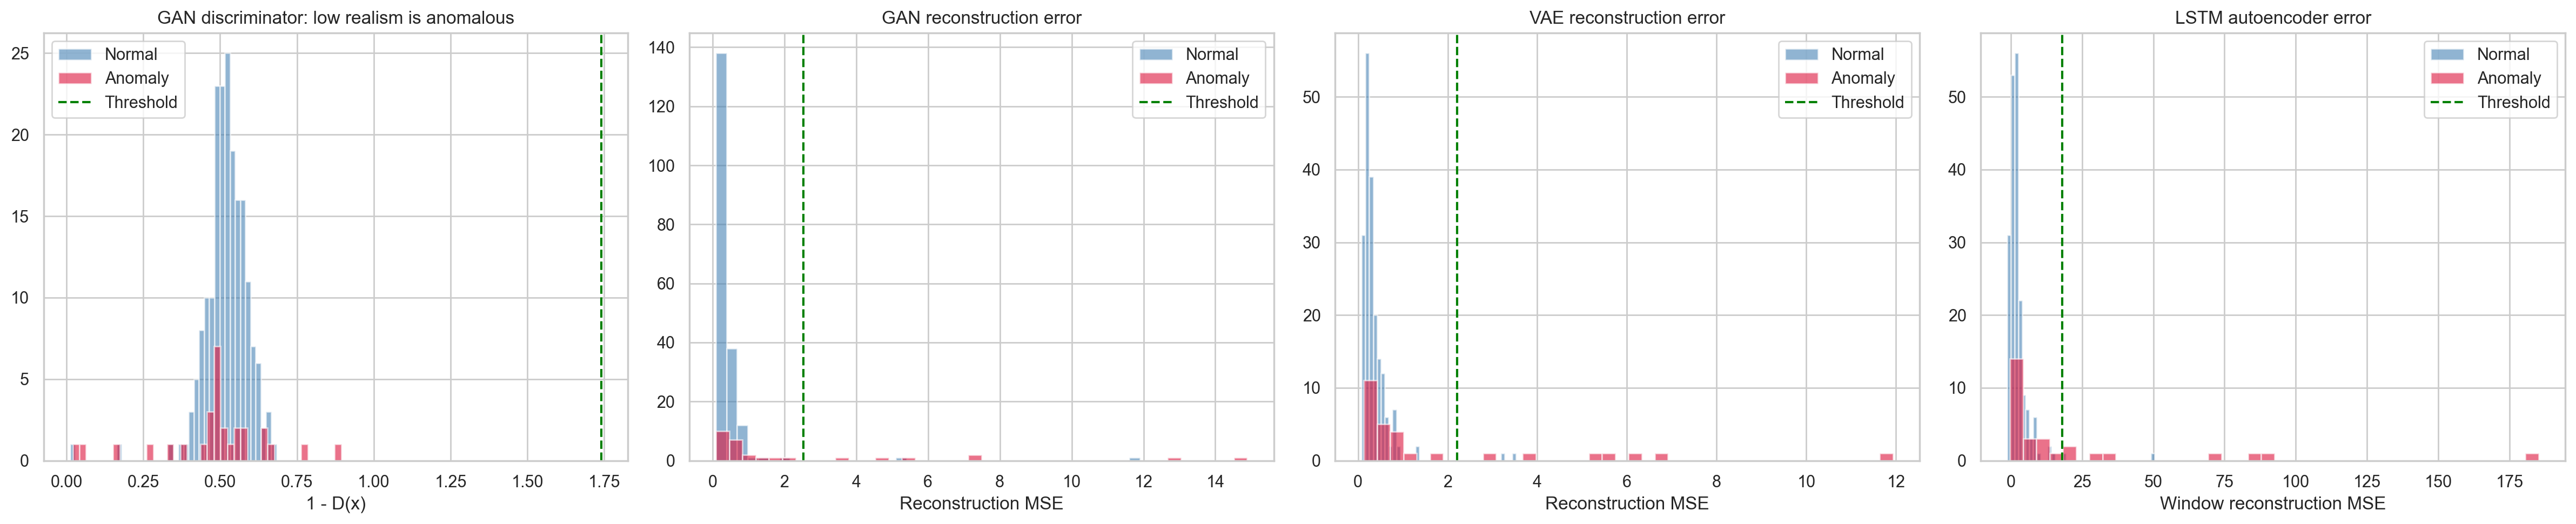

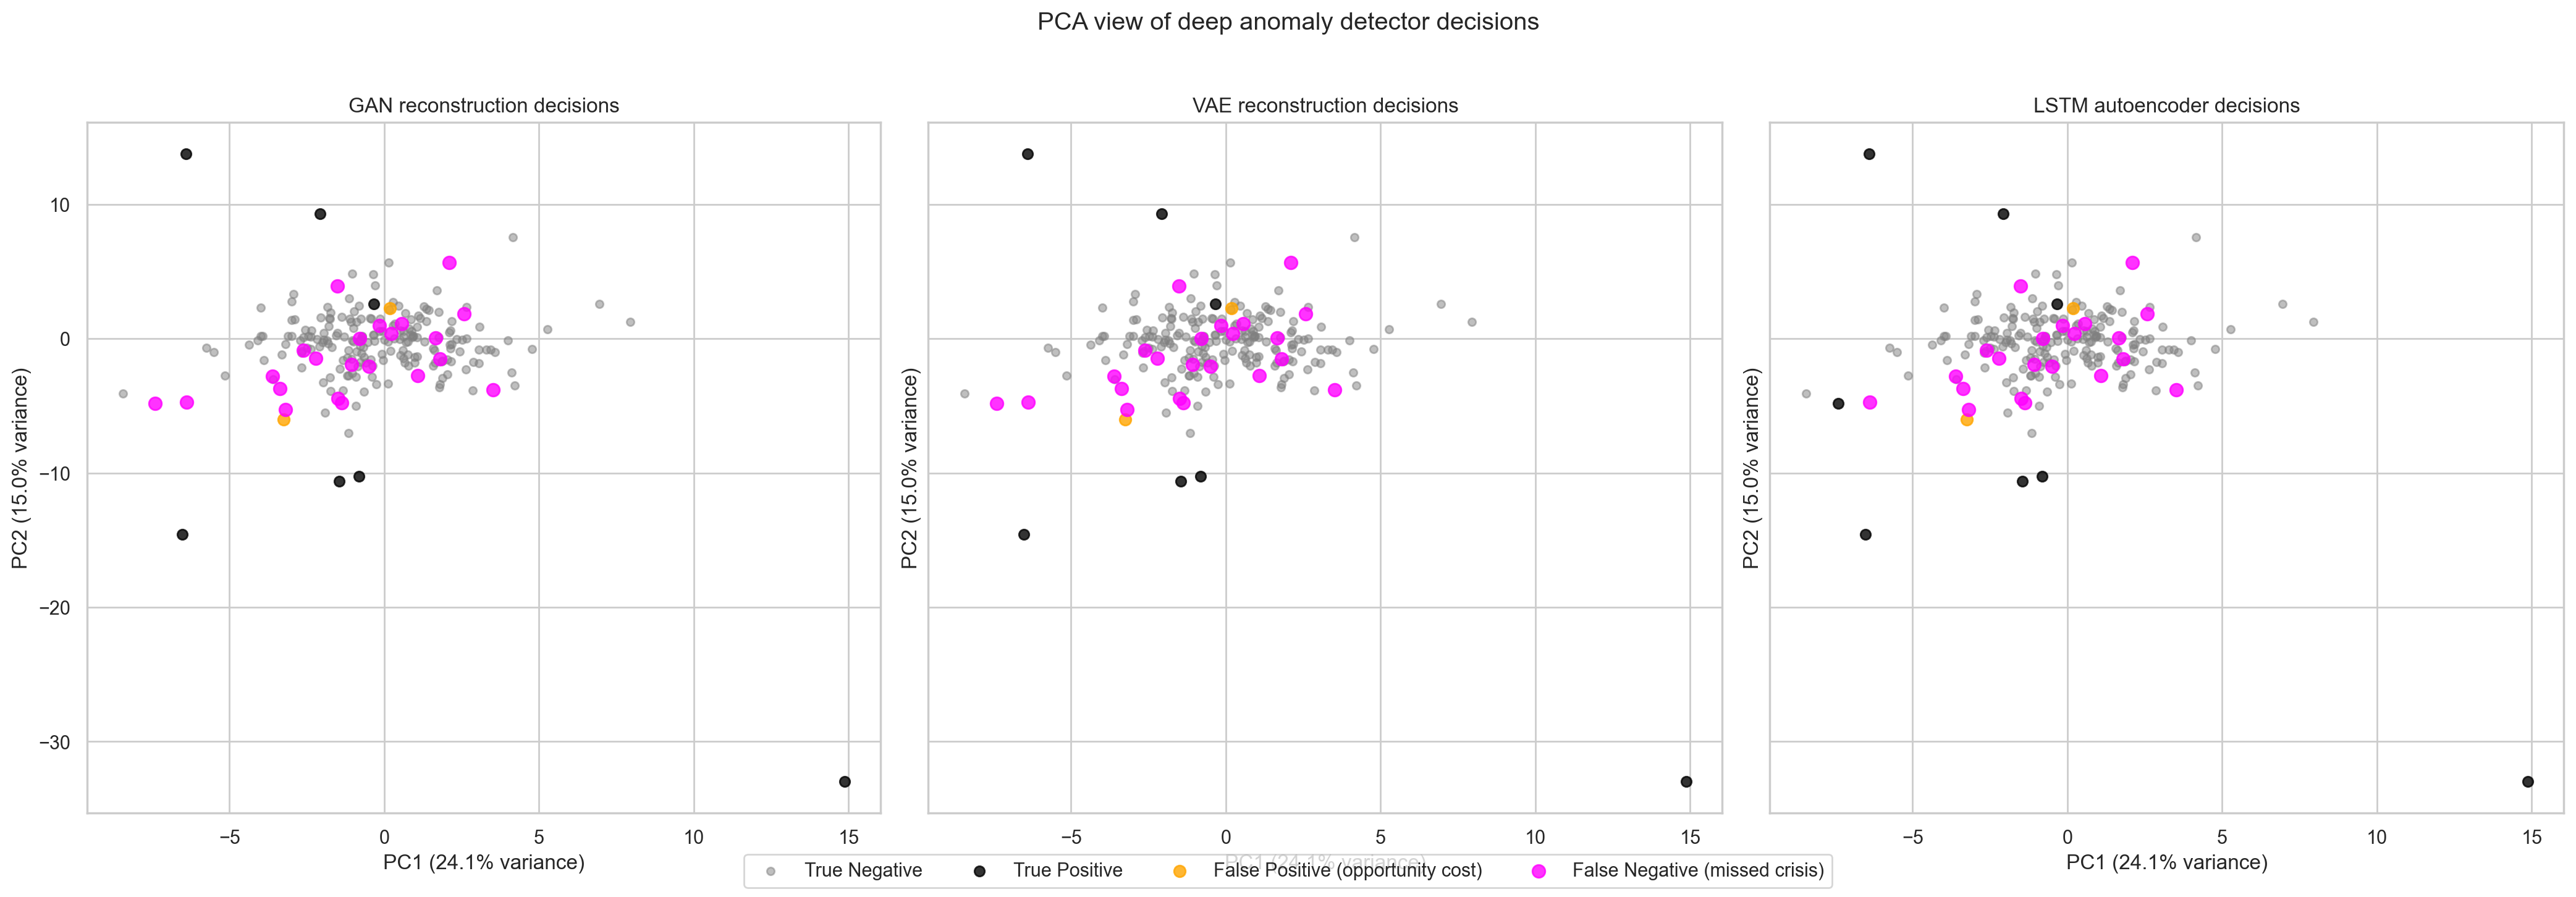

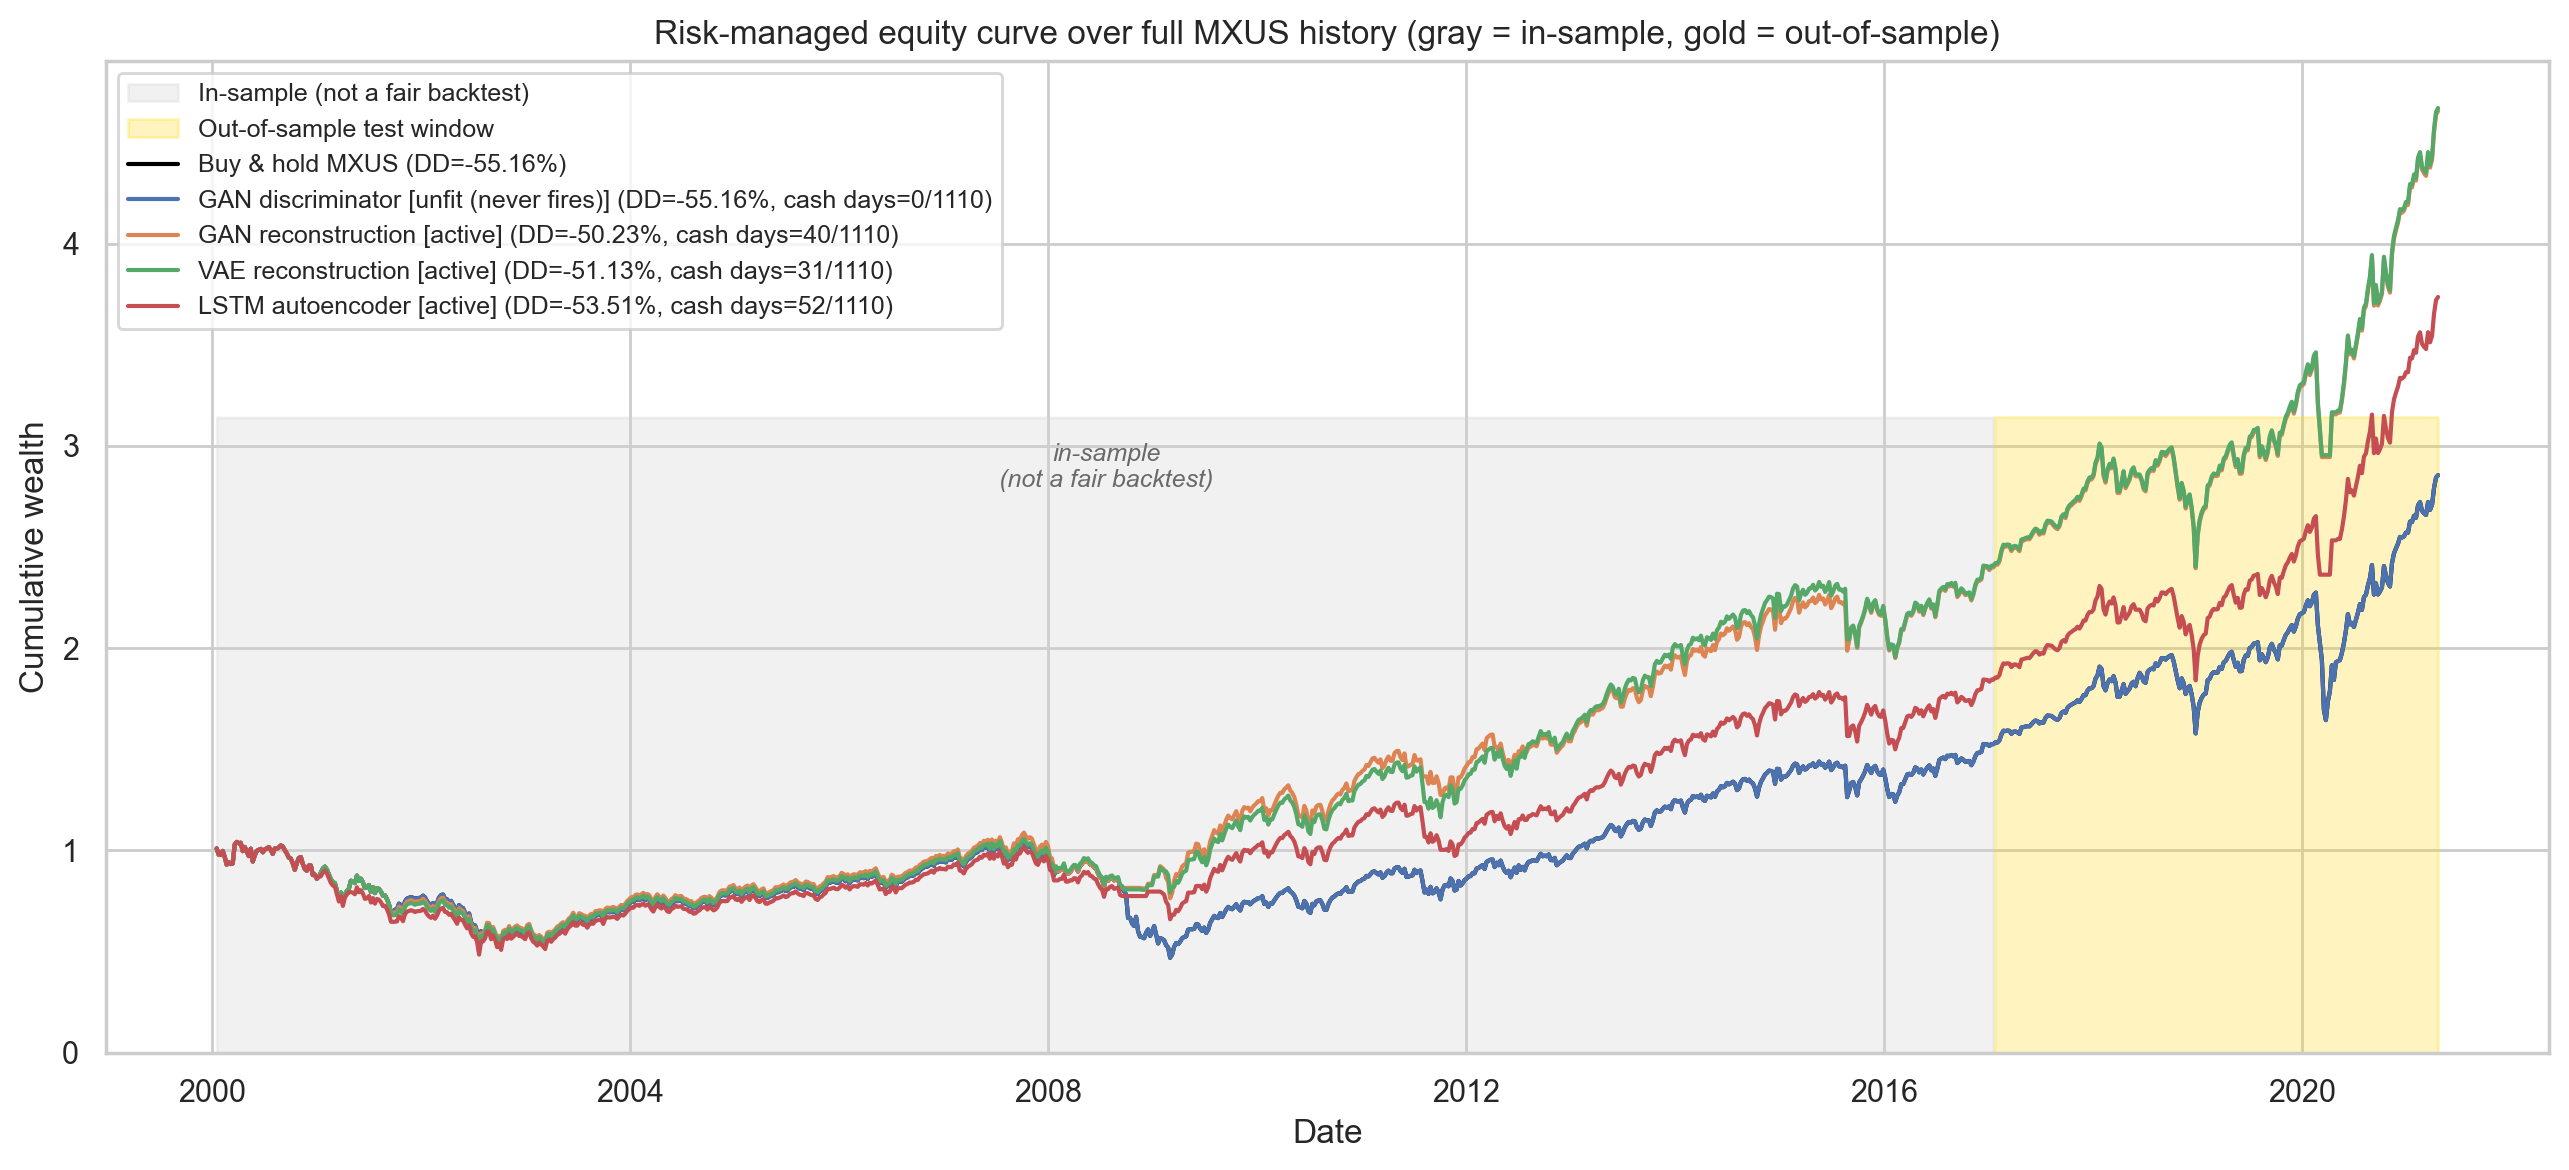


Comparison. Only the *_test_window columns are out-of-sample and trustworthy; full-history final_wealth / max_drawdown are in-sample and over-optimistic.


,model,final_wealth_test_window,max_drawdown_test_window,final_wealth,max_drawdown,days_in_cash_total,days_in_cash_test,status
0,Buy & hold MXUS,1.872556,-0.277220,2.855471,-0.551634,0,0,passive baseline
1,GAN discriminator,1.872556,-0.277220,2.855471,-0.551634,0,0,unfit (never fires)
2,GAN reconstruction,1.940828,-0.202305,4.656232,-0.502309,40,9,active
3,VAE reconstruction,1.940828,-0.202305,4.671097,-0.511277,31,9,active
4,LSTM autoencoder,2.026594,-0.202305,3.736661,-0.535131,52,10,active


In [53]:
score_panels = [
    (test_realism, realism_threshold["epsilon"], "GAN discriminator: low realism is anomalous", "1 - D(x)"),
    (test_reconstruction_error, reconstruction_threshold["epsilon"], "GAN reconstruction error", "Reconstruction MSE"),
    (test_vae_error, vae_threshold["epsilon"], "VAE reconstruction error", "Reconstruction MSE"),
    (test_lstm_error, lstm_threshold["epsilon"], "LSTM autoencoder error", "Window reconstruction MSE"),
]

fig, axes = plt.subplots(1, len(score_panels), figsize=(6 * len(score_panels), 5))
for ax, (score, threshold, title, xlabel) in zip(axes, score_panels):
    ax.hist(score[y_test == 0], bins=40, alpha=0.6, label="Normal", color="steelblue")
    ax.hist(score[y_test == 1], bins=40, alpha=0.6, label="Anomaly", color="crimson")
    ax.axvline(threshold, color="green", linestyle="--", label="Threshold")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.legend()
plt.tight_layout()
export_figure(fig, "11_score_distributions")
plt.show()

pca = PCA(n_components=2, random_state=SEED)
pca.fit(X_train)
X_test_pca = pca.transform(X_test)

fig, axes = plt.subplots(1, 3, figsize=(21, 7), sharex=True, sharey=True)

def plot_pca_decisions(ax, y_pred, title):
    groups = [
        ((y_test == 0) & (y_pred == 0), "gray", 20, 0.5, "True Negative"),
        ((y_test == 1) & (y_pred == 1), "black", 35, 0.8, "True Positive"),
        ((y_test == 0) & (y_pred == 1), "orange", 45, 0.8, "False Positive (opportunity cost)"),
        ((y_test == 1) & (y_pred == 0), "magenta", 55, 0.8, "False Negative (missed crisis)"),
    ]
    for mask, color, size, alpha, label in groups:
        ax.scatter(X_test_pca[mask, 0], X_test_pca[mask, 1],
                   c=color, s=size, alpha=alpha, label=label)
    ax.set_title(title)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")

plot_pca_decisions(axes[0], y_pred_reconstruction, "GAN reconstruction decisions")
plot_pca_decisions(axes[1], y_pred_vae, "VAE reconstruction decisions")
plot_pca_decisions(axes[2], y_pred_lstm, "LSTM autoencoder decisions")
handles, labels = axes[2].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4)
fig.suptitle("PCA view of deep anomaly detector decisions", y=1.02)
plt.tight_layout()
export_figure(fig, "12_pca_detector_decisions")
plt.show()


def max_drawdown(wealth):
    wealth = np.asarray(wealth)
    if wealth.size == 0:
        return 0.0
    running_max = np.maximum.accumulate(wealth)
    return float(((wealth - running_max) / running_max).min())


# Full-chronology risk-managed equity curve. Test rows are highlighted; the test-window
# drawdown column is the only fully out-of-sample number.
if "MXUS" in stationary_df.columns:
    X_all_scaled = scaler.transform(stationary_df.values)
    all_dates = stationary_df.index  # DatetimeIndex
    bench_full = stationary_df["MXUS"].to_numpy()
    buyhold_wealth = np.exp(np.cumsum(bench_full))

    # Robust test-row mask via DatetimeIndex.isin (works regardless of internal dtype).
    test_idx = pd.DatetimeIndex(test_dates)
    test_mask_full = all_dates.isin(test_idx)
    assert test_mask_full.sum() == len(test_idx), (
        f"Test-row mask alignment failed: {test_mask_full.sum()} matched vs {len(test_idx)} expected."
    )

    detectors = [
        ("GAN discriminator",
         discriminator_anomaly_score(D, X_all_scaled),
         realism_threshold["epsilon"],
         realism_threshold.get("never_fires", False)),
        ("GAN reconstruction",
         gan_reconstruction_error(G, X_all_scaled, latent_dim, steps=250),
         reconstruction_threshold["epsilon"],
         reconstruction_threshold.get("never_fires", False)),
        ("VAE reconstruction",
         vae_reconstruction_error(vae_model, X_all_scaled),
         vae_threshold["epsilon"],
         vae_threshold.get("never_fires", False)),
        ("LSTM autoencoder",
         lstm_score_series.reindex(all_dates).to_numpy(),
         lstm_threshold["epsilon"],
         lstm_threshold.get("never_fires", False)),
    ]

    fig = plt.figure(figsize=(13, 6))
    ymax = max(buyhold_wealth.max() * 1.1, 1.5)
    plt.fill_between(all_dates, 0, ymax, where=~test_mask_full,
                     color="lightgray", alpha=0.30, step="post",
                     label="In-sample (not a fair backtest)")
    plt.fill_between(all_dates, 0, ymax, where=test_mask_full,
                     color="gold", alpha=0.25, step="post",
                     label="Out-of-sample test window")
    _in_sample_dates = all_dates[~test_mask_full]
    if len(_in_sample_dates) > 0:
        plt.text(_in_sample_dates[len(_in_sample_dates) // 2], ymax * 0.96,
                 "in-sample\n(not a fair backtest)", ha="center", va="top",
                 fontsize=9, color="dimgray", style="italic")
    plt.plot(all_dates, buyhold_wealth, color="black", linewidth=1.5,
             label=f"Buy & hold MXUS (DD={max_drawdown(buyhold_wealth):.2%})")

    backtests = [{
        "model": "Buy & hold MXUS",
        "final_wealth": float(buyhold_wealth[-1]),
        "final_wealth_test_window": float(np.exp(bench_full[test_mask_full].sum())),
        "max_drawdown": max_drawdown(buyhold_wealth),
        "max_drawdown_test_window": max_drawdown(buyhold_wealth[test_mask_full]),
        "days_in_cash_total": 0,
        "days_in_cash_test": 0,
        "status": "passive baseline",
    }]

    for label, score_full, epsilon, never_fires in detectors:
        y_pred_full = (score_full > epsilon).astype(int)
        # One-week execution lag: a flag raised on week t only moves us to cash for
        # week t+1, so we never avoid a loss using that same week's realised return.
        position_cash = apply_execution_lag(y_pred_full)
        managed_ret = np.where(position_cash == 1, 0.0, bench_full)
        managed_wealth = np.exp(np.cumsum(managed_ret))
        status = "unfit (never fires)" if never_fires else "active"
        plt.plot(all_dates, managed_wealth,
                 label=f"{label} [{status}] (DD={max_drawdown(managed_wealth):.2%}, "
                       f"cash days={int(position_cash.sum())}/{len(y_pred_full)})")
        backtests.append({
            "model": label,
            "final_wealth": float(managed_wealth[-1]),
            "final_wealth_test_window": float(np.exp(managed_ret[test_mask_full].sum())),
            "max_drawdown": max_drawdown(managed_wealth),
            "max_drawdown_test_window": max_drawdown(managed_wealth[test_mask_full]),
            "days_in_cash_total": int(position_cash.sum()),
            "days_in_cash_test": int(position_cash[test_mask_full].sum()),
            "status": status,
        })

    plt.title("Risk-managed equity curve over full MXUS history "
              "(gray = in-sample, gold = out-of-sample)")
    plt.xlabel("Date")
    plt.ylabel("Cumulative wealth")
    plt.ylim(bottom=0)
    plt.legend(loc="upper left", fontsize=9)
    plt.tight_layout()
    export_figure(fig, "13_risk_managed_equity_curve")
    plt.show()

    backtest_df = pd.DataFrame(backtests)
    _oos_first = ["model", "final_wealth_test_window", "max_drawdown_test_window"]
    backtest_df = backtest_df[_oos_first + [c for c in backtest_df.columns if c not in _oos_first]]
    print("\nComparison. Only the *_test_window columns are out-of-sample and trustworthy; "
          "full-history final_wealth / max_drawdown are in-sample and over-optimistic.")
    display(backtest_df)
else:
    print("MXUS not available -- skipping risk-managed equity-curve backtest.")


**Graph interpretation.**  
The first row of diagnostics contains four score-distribution panels: GAN discriminator realism, GAN reconstruction error, VAE reconstruction error, and LSTM autoencoder error. The discriminator distribution has weak operational value because its threshold does not produce useful alerts. The reconstruction and LSTM panels show more abnormal observations in the high-error region, which explains why those models are the active deep-learning risk signals.

The PCA decision panels compare GAN reconstruction, VAE reconstruction, and LSTM decisions in the same two-component space. The overlap among true negatives, true positives, false positives, and false negatives shows that no deep-learning model obtains a clean geometric separation of crisis weeks. The false negatives are missed crises; the false positives are defensive alerts during weeks that were labelled normal.

The equity curve connects these diagnostics to portfolio impact. In the test window, LSTM reaches the highest deep-learning final wealth at 2.0266 and reduces drawdown to -20.23% versus -27.72% for buy-and-hold. GAN and VAE reconstruction also improve test-window drawdown and finish above buy-and-hold, while the discriminator is marked as unfit because it effectively never fires. This supports using reconstruction/sequence errors rather than discriminator realism for the risk-off rule.

### Cross-model equity-curve comparison

The three sections above each backtest one model family in isolation. This final
view puts the **LSTM autoencoder** (the strongest deep-learning detector) head to
head with the optimized Isolation Forest and the COPOD amber risk-off signal on a
single chart. Every detector emits a per-date "go to cash" signal; we align those
signals on a shared MXUS chronology (the date intersection common to all models and
the benchmark) and replay the same risk-off rule -- cash earns nothing, otherwise we
stay invested in MXUS -- so differences in the curves reflect the detectors, not
differences in data coverage. The shaded band marks the deep-learning held-out test
rows; the table is sorted by drawdown (less negative is better).


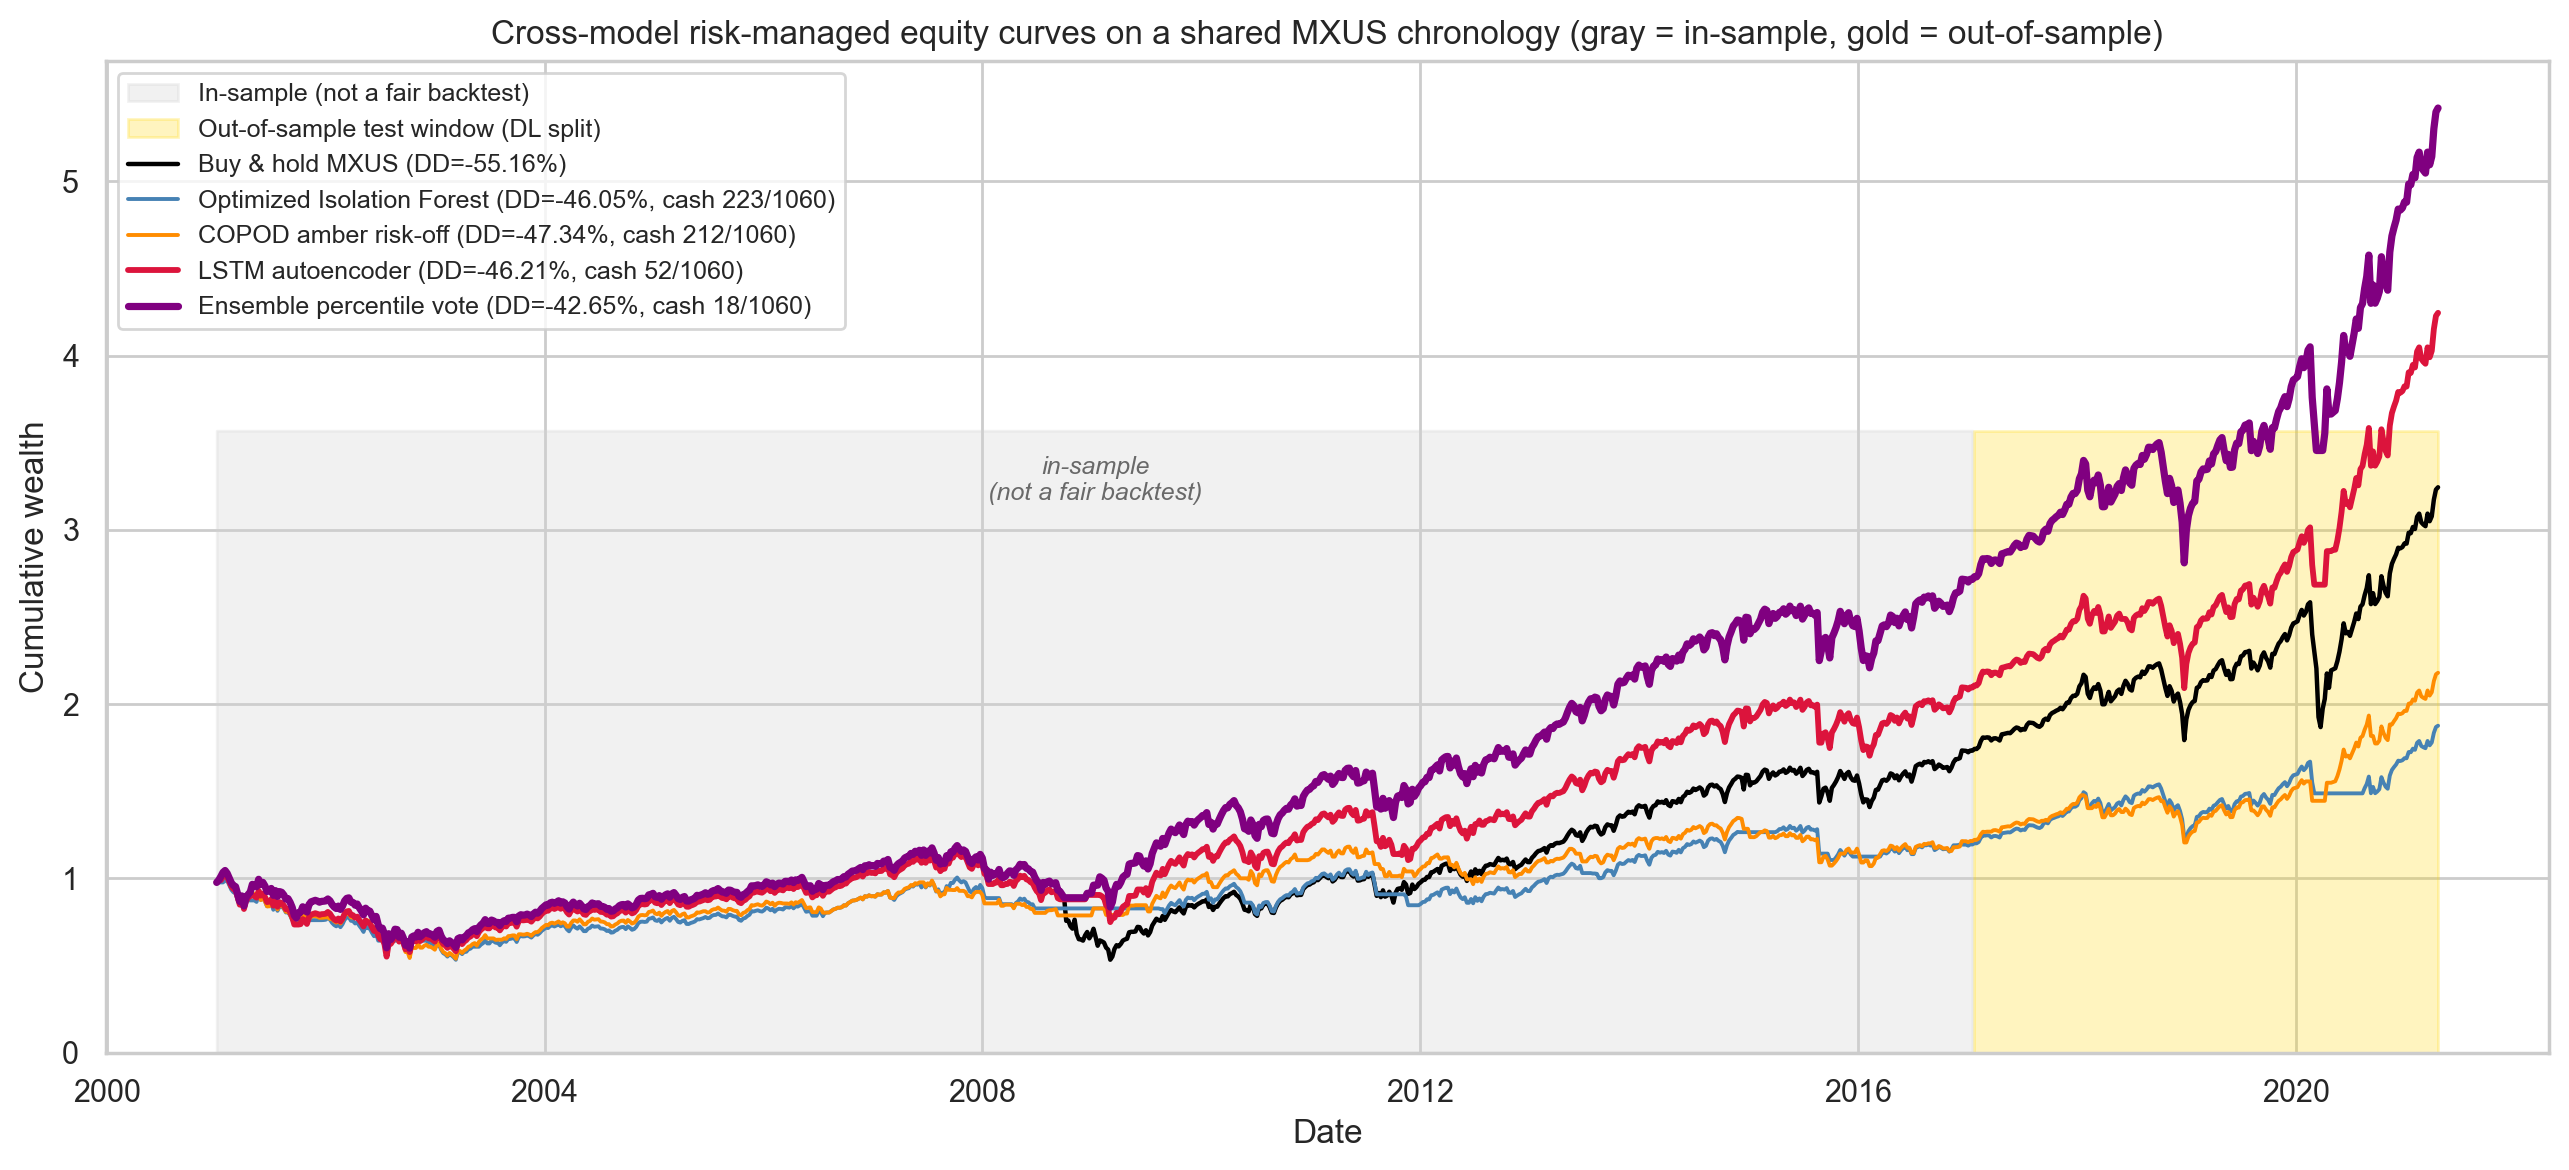


Cross-model comparison on the shared chronology (1060 aligned dates). Only the *_test_window columns are out-of-sample -- compare on those. Less-negative drawdown is better.


,model,final_wealth_test_window,max_drawdown_test_window,final_wealth,max_drawdown,days_in_cash,status
0,Buy & hold MXUS,1.872556,-0.277220,3.244452,-0.551634,0,passive baseline
3,LSTM autoencoder,2.026594,-0.202305,4.245680,-0.462076,52,active
1,Optimized Isolation Forest,1.571108,-0.197218,1.875815,-0.460453,223,active
4,Ensemble percentile vote,1.996277,-0.197218,5.421095,-0.426502,18,active
2,COPOD amber risk-off,1.796063,-0.183749,2.179717,-0.473443,212,active


In [54]:
# Cross-model comparison: individual detectors and the ensemble on one curve.
# Each detector contributes a per-date "go to cash" boolean signal; we align them on a
# shared MXUS chronology and replay the same risk-off rule (cash -> 0 return).
def max_drawdown(wealth):
    wealth = np.asarray(wealth)
    if wealth.size == 0:
        return 0.0
    running_max = np.maximum.accumulate(wealth)
    return float(((wealth - running_max) / running_max).min())


def _have(*names):
    return all(name in globals() for name in names)


cash_signals = {}          # label -> boolean Series indexed by date
bench_candidates = []      # MXUS log-return series from whichever parts are available

# Canonical benchmark: prefer the deep-learning stationary frame.
if _have("stationary_df") and "MXUS" in stationary_df.columns:
    bench_candidates.append(stationary_df["MXUS"])

# Isolation Forest (optimized)
if _have("iso_if_opt", "scaler_if_opt", "returns_df_if", "feature_cols_if_opt", "threshold_if_opt"):
    if_score = iso_if_opt.decision_function(
        scaler_if_opt.transform(returns_df_if[feature_cols_if_opt])
    )
    cash_signals["Optimized Isolation Forest"] = pd.Series(
        if_score <= threshold_if_opt, index=returns_df_if.index
    )
    if "MXUS" in returns_df_if.columns:
        bench_candidates.append(returns_df_if["MXUS"])

# COPOD (amber risk-off)
if _have("copod_model", "copod_scaler", "copod_stationary_df",
         "copod_sub_models", "copod_group_indices", "amber_statistical_threshold"):
    X_copod_all = copod_scaler.transform(copod_stationary_df.values)
    X_copod_meta = np.column_stack([
        copod_sub_models[name].decision_function(X_copod_all[:, copod_group_indices[name]])
        for name in copod_group_indices
    ])
    copod_score = copod_model.decision_function(X_copod_meta)
    cash_signals["COPOD amber risk-off"] = pd.Series(
        copod_score > amber_statistical_threshold, index=copod_stationary_df.index
    )
    if "MXUS" in copod_stationary_df.columns:
        bench_candidates.append(copod_stationary_df["MXUS"])

# LSTM autoencoder
if _have("lstm_score_series", "lstm_threshold"):
    cash_signals["LSTM autoencoder"] = lstm_score_series > lstm_threshold["epsilon"]

# Cross-family ensemble
if _have("ensemble_score_series", "ensemble_threshold"):
    cash_signals["Ensemble percentile vote"] = ensemble_score_series > ensemble_threshold["epsilon"]

if not cash_signals or not bench_candidates:
    print("Cross-model comparison skipped: model artefacts or MXUS benchmark unavailable.")
else:
    # Shared chronology = dates common to the benchmark and every detector.
    common_idx = bench_candidates[0].index
    for signal in cash_signals.values():
        common_idx = common_idx.intersection(signal.index)
    common_idx = common_idx.sort_values()

    bench = bench_candidates[0].reindex(common_idx).to_numpy()
    buyhold_wealth = np.exp(np.cumsum(bench))

    test_mask = None
    if _have("test_dates"):
        test_mask = common_idx.isin(pd.DatetimeIndex(test_dates))

    fig = plt.figure(figsize=(13, 6))
    ymax = max(buyhold_wealth.max() * 1.1, 1.5)
    if test_mask is not None and test_mask.any():
        plt.fill_between(common_idx, 0, ymax, where=~test_mask,
                         color="lightgray", alpha=0.30, step="post",
                         label="In-sample (not a fair backtest)")
        plt.fill_between(common_idx, 0, ymax, where=test_mask,
                         color="gold", alpha=0.25, step="post",
                         label="Out-of-sample test window (DL split)")
        _in_sample_dates = common_idx[~test_mask]
        if len(_in_sample_dates) > 0:
            plt.text(_in_sample_dates[len(_in_sample_dates) // 2], ymax * 0.96,
                     "in-sample\n(not a fair backtest)", ha="center", va="top",
                     fontsize=9, color="dimgray", style="italic")
    plt.plot(common_idx, buyhold_wealth, color="black", linewidth=1.6,
             label=f"Buy & hold MXUS (DD={max_drawdown(buyhold_wealth):.2%})")

    rows = [{
        "model": "Buy & hold MXUS",
        "final_wealth": float(buyhold_wealth[-1]),
        "final_wealth_test_window": (float(np.exp(bench[test_mask].sum()))
                                     if test_mask is not None and test_mask.any() else np.nan),
        "max_drawdown": max_drawdown(buyhold_wealth),
        "max_drawdown_test_window": (max_drawdown(buyhold_wealth[test_mask])
                                     if test_mask is not None and test_mask.any() else np.nan),
        "days_in_cash": 0,
        "status": "passive baseline",
    }]

    palette = {
        "LSTM autoencoder": "crimson",
        "Optimized Isolation Forest": "steelblue",
        "COPOD amber risk-off": "darkorange",
        "Ensemble percentile vote": "purple",
    }
    # Plot learned aggregations last so the ensemble is visually prominent.
    focus_order = {"LSTM autoencoder": 1, "Ensemble percentile vote": 2}
    ordered = sorted(cash_signals, key=lambda lbl: focus_order.get(lbl, 0))
    for label in ordered:
        # One-week execution lag (consistent with the per-family backtests above).
        raw_signal = cash_signals[label].reindex(common_idx).fillna(False).to_numpy().astype(bool)
        cash = apply_execution_lag(raw_signal).astype(bool)
        managed_ret = np.where(cash, 0.0, bench)
        managed_wealth = np.exp(np.cumsum(managed_ret))
        lw = 2.6 if label == "Ensemble percentile vote" else (2.1 if label == "LSTM autoencoder" else 1.4)
        plt.plot(common_idx, managed_wealth, linewidth=lw, color=palette.get(label),
                 label=f"{label} (DD={max_drawdown(managed_wealth):.2%}, "
                       f"cash {int(cash.sum())}/{len(cash)})")
        rows.append({
            "model": label,
            "final_wealth": float(managed_wealth[-1]),
            "final_wealth_test_window": (float(np.exp(managed_ret[test_mask].sum()))
                                         if test_mask is not None and test_mask.any() else np.nan),
            "max_drawdown": max_drawdown(managed_wealth),
            "max_drawdown_test_window": (max_drawdown(managed_wealth[test_mask])
                                         if test_mask is not None and test_mask.any() else np.nan),
            "days_in_cash": int(cash.sum()),
            "status": "active",
        })

    plt.title("Cross-model risk-managed equity curves on a shared MXUS chronology "
              "(gray = in-sample, gold = out-of-sample)")
    plt.xlabel("Date")
    plt.ylabel("Cumulative wealth")
    plt.ylim(bottom=0)
    plt.legend(loc="upper left", fontsize=9)
    plt.tight_layout()
    export_figure(fig, "14_cross_model_equity_curve_comparison")
    plt.show()

    comparison_curve_df = pd.DataFrame(rows).sort_values("max_drawdown_test_window")
    _oos_first = ["model", "final_wealth_test_window", "max_drawdown_test_window"]
    comparison_curve_df = comparison_curve_df[
        _oos_first + [c for c in comparison_curve_df.columns if c not in _oos_first]
    ]
    print("\nCross-model comparison on the shared chronology "
          f"({len(common_idx)} aligned dates). Only the *_test_window columns are "
          "out-of-sample -- compare on those. Less-negative drawdown is better.")
    display(comparison_curve_df)


**Graph interpretation.**  
The final cross-model equity curve places the main detectors on a shared MXUS chronology and applies the same cash-switching rule. The out-of-sample comparison shows that LSTM has the highest test-window wealth at 2.0266, the ensemble is close at 1.9963, and buy-and-hold ends at 1.8726. This indicates that selected anomaly signals can improve terminal wealth over the test period.

Drawdown tells a slightly different story. COPOD amber has the least negative test-window drawdown at -18.37%, followed by optimized Isolation Forest and the ensemble at -19.72%, while buy-and-hold suffers -27.72%. The final conclusion is therefore model-dependent: LSTM gives the best return outcome in the test window, while COPOD amber gives the strongest drawdown reduction. This is exactly the business trade-off between alpha-oriented dynamic allocation and conservative risk management.

### Financial Performance Assessment

The cross-model equity comparison converts anomaly detection into an economic decision. The held-out test window is the relevant basis for judgement because it measures how each signal behaves outside the calibration period under the same one-period execution lag and cash-switching rule.

The results show two distinct strengths. The LSTM signal produces the highest test-window terminal wealth, indicating stronger return capture under selective defensive allocation. COPOD amber produces the smallest test-window drawdown, indicating stronger capital preservation. The ensemble sits between these profiles, with competitive wealth and meaningful downside reduction. The final choice is therefore mandate-dependent: a drawdown-sensitive risk-management mandate should prioritize stability and capital protection, while a more return-oriented allocation mandate can accept selective alerts if they improve terminal wealth without increasing tail risk.

## Conclusion

The analysis evaluates early-warning signals as implementable portfolio controls rather than standalone classifiers. A useful signal must recognize the transition from risk-on to risk-off early enough to limit drawdown, while avoiding excessive false alarms that move the portfolio into cash during recoveries. The final comparison is therefore based on the held-out test window, with emphasis on terminal wealth, maximum drawdown, alert frequency, and the balance between return capture and downside protection.


### Executive Synthesis

Across the modelling families, the evidence supports the use of anomaly detection as a portfolio risk-control layer rather than as a standalone crisis classifier. The strongest models do not eliminate crisis risk, but they improve the timing of defensive allocation and reduce exposure during parts of the abnormal regime.

The final assessment should therefore focus on implementability: whether the signal is timely, whether the number of cash switches is acceptable, whether drawdown improves after accounting for missed crises, and whether terminal wealth remains competitive. These criteria are closer to the requirements of a real early-warning system than a single classification metric.

Conclusion KPI table — out-of-sample test window only


,model,final_wealth_test_window,wealth_uplift_vs_baseline,max_drawdown_test_window,drawdown_reduction_pp,days_in_cash,wealth_to_drawdown
0,Ensemble percentile vote,1.9963,+0.1237,-19.72%,+8.00 pp,18,10.12
1,LSTM autoencoder,2.0266,+0.1540,-20.23%,+7.49 pp,52,10.02
2,COPOD amber risk-off,1.7961,-0.0765,-18.37%,+9.35 pp,212,9.77
3,Buy & hold MXUS,1.8726,+0.0000,-27.72%,+0.00 pp,0,6.75
4,Optimized Isolation Forest,1.5711,-0.3014,-19.72%,+8.00 pp,223,7.97


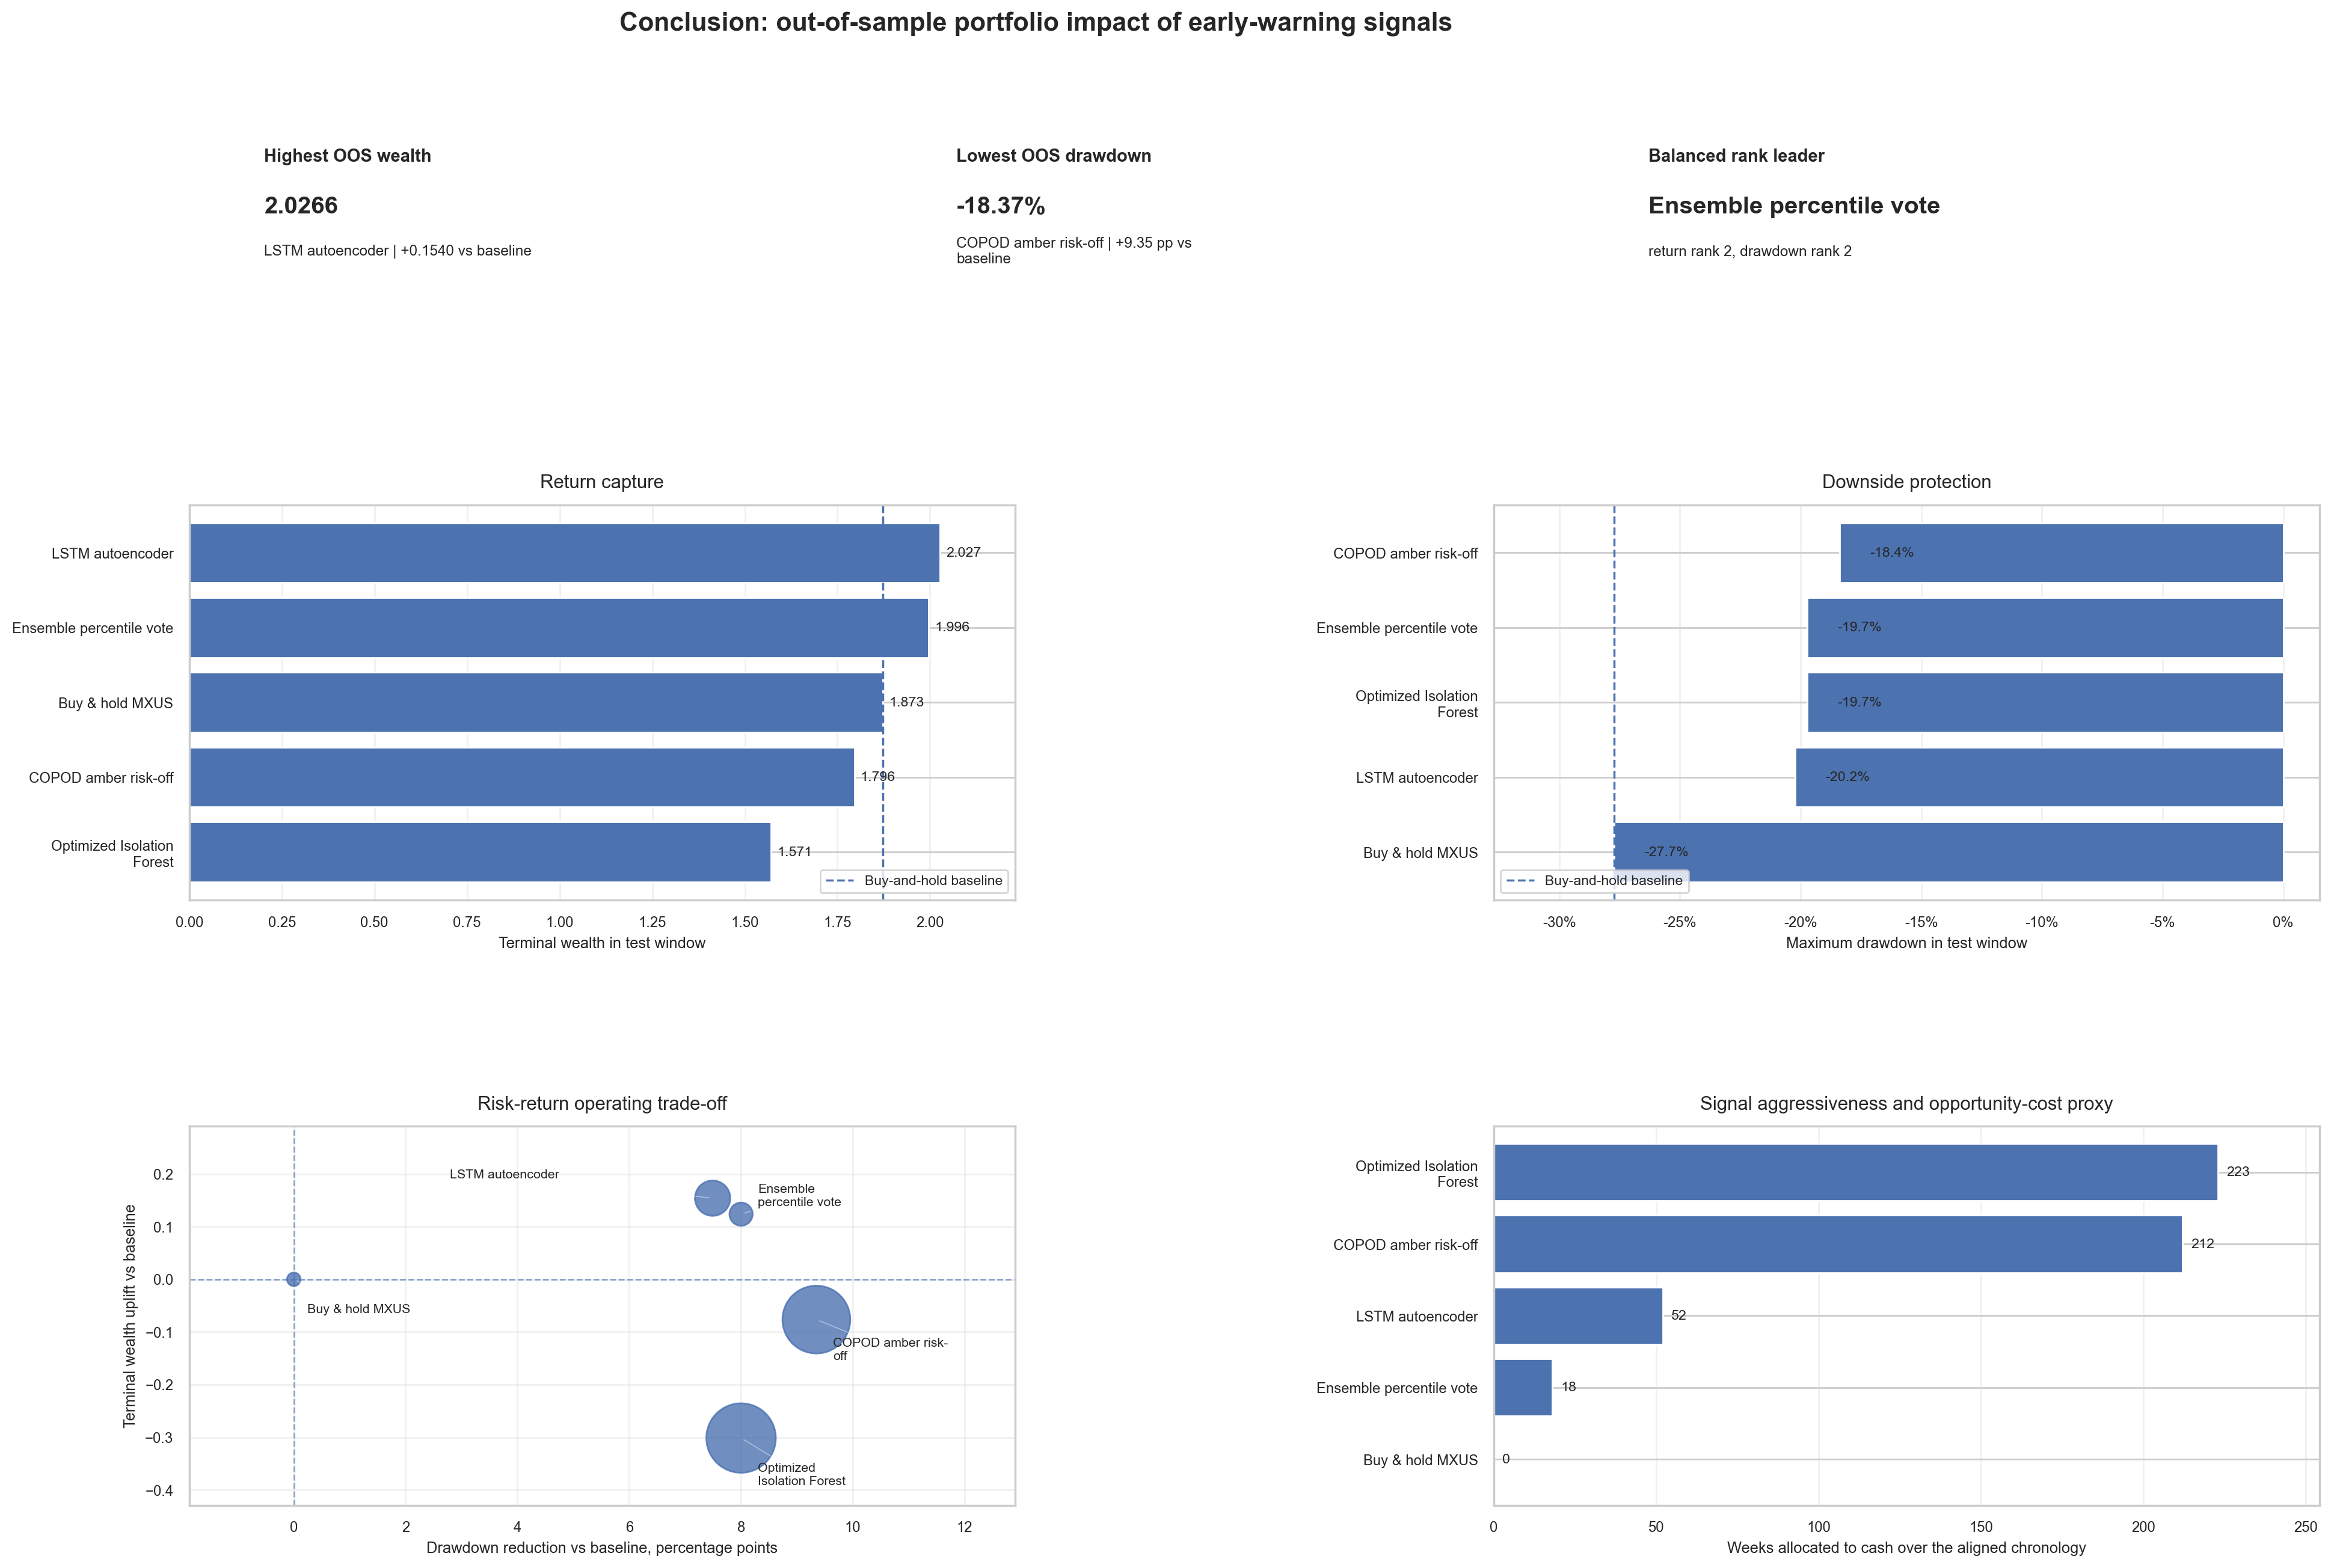

In [55]:
# Final out-of-sample wealth, drawdown, and alert-efficiency diagnostics.
from textwrap import fill

if "comparison_curve_df" not in globals():
    raise RuntimeError(
        "Run the cross-model equity-curve comparison cell before executing this conclusion section."
    )

required_columns = [
    "model",
    "final_wealth_test_window",
    "max_drawdown_test_window",
    "days_in_cash",
]
missing_columns = [col for col in required_columns if col not in comparison_curve_df.columns]
if missing_columns:
    raise ValueError(f"comparison_curve_df is missing required columns: {missing_columns}")

conclusion_kpi_df = comparison_curve_df[required_columns].copy()
conclusion_kpi_df["model"] = conclusion_kpi_df["model"].astype(str)
conclusion_kpi_df = conclusion_kpi_df.dropna(
    subset=["final_wealth_test_window", "max_drawdown_test_window"]
).reset_index(drop=True)

if conclusion_kpi_df.empty:
    raise ValueError("No out-of-sample rows are available for the conclusion diagnostics.")

baseline_mask = conclusion_kpi_df["model"].str.contains("buy", case=False, regex=False)
if not baseline_mask.any():
    raise ValueError("A buy-and-hold baseline row is required for relative portfolio diagnostics.")

baseline_row = conclusion_kpi_df.loc[baseline_mask].iloc[0]
baseline_wealth = float(baseline_row["final_wealth_test_window"])
baseline_drawdown = float(baseline_row["max_drawdown_test_window"])

conclusion_kpi_df["wealth_uplift_vs_baseline"] = (
    conclusion_kpi_df["final_wealth_test_window"] - baseline_wealth
)
conclusion_kpi_df["drawdown_reduction_pp"] = (
    conclusion_kpi_df["max_drawdown_test_window"] - baseline_drawdown
) * 100.0
conclusion_kpi_df["drawdown_abs"] = conclusion_kpi_df["max_drawdown_test_window"].abs()
conclusion_kpi_df["wealth_to_drawdown"] = np.where(
    conclusion_kpi_df["drawdown_abs"] > 0,
    conclusion_kpi_df["final_wealth_test_window"] / conclusion_kpi_df["drawdown_abs"],
    np.nan,
)
conclusion_kpi_df["return_rank"] = conclusion_kpi_df["final_wealth_test_window"].rank(
    ascending=False, method="min"
)
conclusion_kpi_df["drawdown_rank"] = conclusion_kpi_df["max_drawdown_test_window"].rank(
    ascending=False, method="min"
)
conclusion_kpi_df["composite_rank"] = (
    conclusion_kpi_df["return_rank"] + conclusion_kpi_df["drawdown_rank"]
)

ordered_kpi_df = conclusion_kpi_df.sort_values(
    ["composite_rank", "final_wealth_test_window"], ascending=[True, False]
).reset_index(drop=True)

summary_display = ordered_kpi_df[[
    "model",
    "final_wealth_test_window",
    "wealth_uplift_vs_baseline",
    "max_drawdown_test_window",
    "drawdown_reduction_pp",
    "days_in_cash",
    "wealth_to_drawdown",
]].copy()

formatted_summary = summary_display.copy()
formatted_summary["final_wealth_test_window"] = formatted_summary["final_wealth_test_window"].map(lambda x: f"{x:.4f}")
formatted_summary["wealth_uplift_vs_baseline"] = formatted_summary["wealth_uplift_vs_baseline"].map(lambda x: f"{x:+.4f}")
formatted_summary["max_drawdown_test_window"] = formatted_summary["max_drawdown_test_window"].map(lambda x: f"{x:.2%}")
formatted_summary["drawdown_reduction_pp"] = formatted_summary["drawdown_reduction_pp"].map(lambda x: f"{x:+.2f} pp")
formatted_summary["days_in_cash"] = formatted_summary["days_in_cash"].map(lambda x: f"{int(x)}")
formatted_summary["wealth_to_drawdown"] = formatted_summary["wealth_to_drawdown"].map(lambda x: f"{x:.2f}" if pd.notna(x) else "n/a")

print("Conclusion KPI table — out-of-sample test window only")
display(formatted_summary)

best_wealth_row = conclusion_kpi_df.loc[conclusion_kpi_df["final_wealth_test_window"].idxmax()]
best_drawdown_row = conclusion_kpi_df.loc[conclusion_kpi_df["max_drawdown_test_window"].idxmax()]
best_balance_row = ordered_kpi_df.iloc[0]

def clean_label(label, width=22):
    return fill(str(label), width=width)

fig = plt.figure(figsize=(22, 13.5))
grid = fig.add_gridspec(
    3,
    2,
    height_ratios=[1.05, 2.45, 2.35],
    hspace=0.72,
    wspace=0.58,
)

ax_cards = fig.add_subplot(grid[0, :])
ax_cards.axis("off")

cards = [
    (
        "Highest OOS wealth",
        f"{best_wealth_row['final_wealth_test_window']:.4f}",
        f"{best_wealth_row['model']} | {best_wealth_row['wealth_uplift_vs_baseline']:+.4f} vs baseline",
    ),
    (
        "Lowest OOS drawdown",
        f"{best_drawdown_row['max_drawdown_test_window']:.2%}",
        f"{best_drawdown_row['model']} | {best_drawdown_row['drawdown_reduction_pp']:+.2f} pp vs baseline",
    ),
    (
        "Balanced rank leader",
        f"{best_balance_row['model']}",
        f"return rank {int(best_balance_row['return_rank'])}, drawdown rank {int(best_balance_row['drawdown_rank'])}",
    ),
]

for i, (title, value, subtitle) in enumerate(cards):
    x = 0.035 + i * 0.325

    ax_cards.add_patch(
        plt.Rectangle(
            (x - 0.015, 0.05),
            0.295,
            0.86,
            transform=ax_cards.transAxes,
            fill=False,
            linewidth=1.05,
            alpha=0.38,
        )
    )

    ax_cards.text(
        x,
        0.72,
        title,
        transform=ax_cards.transAxes,
        fontsize=10.5,
        fontweight="bold",
        va="center",
    )
    ax_cards.text(
        x,
        0.42,
        clean_label(value, width=26),
        transform=ax_cards.transAxes,
        fontsize=14.5,
        fontweight="bold",
        va="center",
        linespacing=1.08,
    )
    ax_cards.text(
        x,
        0.16,
        clean_label(subtitle, width=42),
        transform=ax_cards.transAxes,
        fontsize=8.8,
        va="center",
        linespacing=1.12,
    )

plot_df = conclusion_kpi_df.sort_values("final_wealth_test_window", ascending=True)
labels = plot_df["model"].to_numpy()
y_pos = np.arange(len(plot_df))

ax_wealth = fig.add_subplot(grid[1, 0])
ax_wealth.barh(y_pos, plot_df["final_wealth_test_window"])
ax_wealth.axvline(
    baseline_wealth,
    linestyle="--",
    linewidth=1.25,
    label="Buy-and-hold baseline",
)
ax_wealth.set_yticks(y_pos)
ax_wealth.set_yticklabels([clean_label(label, width=24) for label in labels], fontsize=8.6)
ax_wealth.set_xlabel("Terminal wealth in test window", fontsize=9.2)
ax_wealth.set_title("Return capture", fontsize=11.2, pad=10)
ax_wealth.tick_params(axis="x", labelsize=8.6)
ax_wealth.grid(axis="x", alpha=0.28)
ax_wealth.legend(loc="lower right", fontsize=8.3, frameon=True)

wealth_max = plot_df["final_wealth_test_window"].max()
ax_wealth.set_xlim(0, wealth_max * 1.10)

for y, value in zip(y_pos, plot_df["final_wealth_test_window"]):
    ax_wealth.text(
        value + wealth_max * 0.008,
        y,
        f"{value:.3f}",
        va="center",
        fontsize=8.4,
    )

plot_dd_df = conclusion_kpi_df.sort_values("max_drawdown_test_window", ascending=True)
labels_dd = plot_dd_df["model"].to_numpy()
y_dd = np.arange(len(plot_dd_df))

ax_drawdown = fig.add_subplot(grid[1, 1])
ax_drawdown.barh(y_dd, plot_dd_df["max_drawdown_test_window"])
ax_drawdown.axvline(
    baseline_drawdown,
    linestyle="--",
    linewidth=1.25,
    label="Buy-and-hold baseline",
)
ax_drawdown.set_yticks(y_dd)
ax_drawdown.set_yticklabels([clean_label(label, width=24) for label in labels_dd], fontsize=8.6)
ax_drawdown.set_xlabel("Maximum drawdown in test window", fontsize=9.2)
ax_drawdown.set_title("Downside protection", fontsize=11.2, pad=10)
ax_drawdown.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax_drawdown.tick_params(axis="x", labelsize=8.6)
ax_drawdown.grid(axis="x", alpha=0.28)
ax_drawdown.legend(loc="lower left", fontsize=8.3, frameon=True)

dd_min = min(plot_dd_df["max_drawdown_test_window"].min(), baseline_drawdown)
dd_pad = abs(dd_min) * 0.045
ax_drawdown.set_xlim(dd_min * 1.18, 0.015)

for y, value in zip(y_dd, plot_dd_df["max_drawdown_test_window"]):
    ax_drawdown.text(
        value + dd_pad,
        y,
        f"{value:.1%}",
        va="center",
        ha="left",
        fontsize=8.4,
    )

active_df = conclusion_kpi_df.copy()

ax_tradeoff = fig.add_subplot(grid[2, 0])
ax_tradeoff.axhline(0, linestyle="--", linewidth=0.95, alpha=0.65)
ax_tradeoff.axvline(0, linestyle="--", linewidth=0.95, alpha=0.65)

ax_tradeoff.scatter(
    active_df["drawdown_reduction_pp"],
    active_df["wealth_uplift_vs_baseline"],
    s=np.maximum(active_df["days_in_cash"].to_numpy(dtype=float), 1) * 7.5 + 58,
    alpha=0.80,
)

x_values = active_df["drawdown_reduction_pp"].to_numpy(dtype=float)
y_values = active_df["wealth_uplift_vs_baseline"].to_numpy(dtype=float)

x_range = max(x_values.max() - x_values.min(), 1.0)
y_range = max(y_values.max() - y_values.min(), 0.05)

ax_tradeoff.set_xlim(x_values.min() - x_range * 0.20, x_values.max() + x_range * 0.38)
ax_tradeoff.set_ylim(y_values.min() - y_range * 0.28, y_values.max() + y_range * 0.30)

label_offsets = {
    "buy": (8, -18),
    "lstm": (-92, 14),
    "ensemble": (10, 11),
    "copod": (10, -18),
    "isolation": (10, -22),
}

for _, row in active_df.iterrows():
    model_name = str(row["model"])
    model_key = model_name.lower()

    offset = (10, 10)
    horizontal_alignment = "left"

    for key, selected_offset in label_offsets.items():
        if key in model_key:
            offset = selected_offset
            if selected_offset[0] < 0:
                horizontal_alignment = "right"
            break

    ax_tradeoff.annotate(
        clean_label(model_name, width=18),
        (row["drawdown_reduction_pp"], row["wealth_uplift_vs_baseline"]),
        xytext=offset,
        textcoords="offset points",
        fontsize=7.7,
        ha=horizontal_alignment,
        va="center",
        arrowprops=dict(arrowstyle="-", linewidth=0.55, alpha=0.45),
    )

ax_tradeoff.set_xlabel("Drawdown reduction vs baseline, percentage points", fontsize=9.2)
ax_tradeoff.set_ylabel("Terminal wealth uplift vs baseline", fontsize=9.2)
ax_tradeoff.set_title("Risk-return operating trade-off", fontsize=11.2, pad=10)
ax_tradeoff.tick_params(axis="both", labelsize=8.6)
ax_tradeoff.grid(alpha=0.28)

plot_cash_df = conclusion_kpi_df.sort_values("days_in_cash", ascending=True)
y_cash = np.arange(len(plot_cash_df))

ax_cash = fig.add_subplot(grid[2, 1])
ax_cash.barh(y_cash, plot_cash_df["days_in_cash"])
ax_cash.set_yticks(y_cash)
ax_cash.set_yticklabels(
    [clean_label(label, width=24) for label in plot_cash_df["model"]],
    fontsize=8.6,
)
ax_cash.set_xlabel("Weeks allocated to cash over the aligned chronology", fontsize=9.2)
ax_cash.set_title("Signal aggressiveness and opportunity-cost proxy", fontsize=11.2, pad=10)
ax_cash.tick_params(axis="x", labelsize=8.6)
ax_cash.grid(axis="x", alpha=0.28)

cash_max = max(float(plot_cash_df["days_in_cash"].max()), 1.0)
ax_cash.set_xlim(0, cash_max * 1.14)

for y, value in zip(y_cash, plot_cash_df["days_in_cash"]):
    ax_cash.text(
        value + cash_max * 0.012,
        y,
        f"{int(value)}",
        va="center",
        fontsize=8.4,
    )

fig.suptitle(
    "Conclusion: out-of-sample portfolio impact of early-warning signals",
    fontsize=15.5,
    fontweight="bold",
    y=0.985,
)

fig.subplots_adjust(
    left=0.18,
    right=0.985,
    top=0.925,
    bottom=0.065,
    hspace=0.72,
    wspace=0.58,
)

if "export_figure" in globals():
    export_figure(fig, "15_conclusion_out_of_sample_diagnostics")

plt.show()

**Conclusion interpretation.**  
The final diagnostics use only the held-out test-window metrics from the cross-model equity-curve comparison. The KPI table separates terminal wealth, maximum drawdown, drawdown improvement versus buy-and-hold, and time spent in cash. This keeps the conclusion tied to economic portfolio outcomes rather than to classification metrics alone.

The return-capture panel identifies the detector with the strongest terminal wealth under the same one-period execution lag and cash-switching rule. The downside-protection panel ranks the models by maximum drawdown, where values closer to zero indicate better capital preservation. The risk-return trade-off plot combines both dimensions: models in the upper-right area both improve terminal wealth and reduce drawdown relative to buy-and-hold; models that move mainly to the right are more defensive, while models that move mainly upward are more return-oriented.

The cash-allocation panel measures signal aggressiveness. Frequent cash allocation can protect the portfolio in stress periods but may also create opportunity cost during rebounds; rare cash allocation preserves upside but may leave the portfolio exposed during severe market moves. The final model choice should therefore follow the investment mandate. A conservative wealth-management mandate should prioritize drawdown reduction and stable warning behaviour, while an alpha-oriented allocation mandate can accept more selective alerts when they improve terminal wealth without materially increasing tail risk.
